In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
N_SAMPLES = 11000
DATA_PATH = "Train.csv"

np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# -----------------------
# Cell 1 — Load + Stratified Sample
# -----------------------
df_raw = pd.read_csv(DATA_PATH)

# 兼容 id / ID
id_col = "id" if "id" in df_raw.columns else ("ID" if "ID" in df_raw.columns else None)

# 分层抽样：保持 Response 比例
df, _ = train_test_split(
    df_raw,
    train_size=N_SAMPLES,
    random_state=SEED,
    stratify=df_raw["Response"]
)
df = df.reset_index(drop=True)

print(f"Raw shape: {df_raw.shape}")
print(f"Sample shape: {df.shape}")
print("\nResponse 比例对比 (Sample vs Raw):")
print((df["Response"].value_counts(normalize=True).round(4) * 100).to_string())

# -----------------------
# Cell 2 — Type Casting + Basic Cleaning (EDA版：不做填补)
# -----------------------
df.columns = [c.strip() for c in df.columns]

# 特征定义
cat_cols = ["Gender", "Vehicle_Age", "Vehicle_Damage"]
bin_cols = ["Previously_Insured", "Driving_License"]   # 二值列建议保留数值
num_cols = ["Age", "Annual_Premium", "Vintage"]
target_col = "Response"

# 类型转换（数值）
for c in num_cols + bin_cols + [target_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Region_Code / Policy_Sales_Channel 通常是编码：转成“干净的类别字符串”用于 EDA
for col in ["Policy_Sales_Channel", "Region_Code"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
        df[col + "_str"] = df[col].astype("string")

# 其余类别列转 string
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("string")

# 合理性清洗：非法值置空（不填补）
df.loc[df["Age"].lt(0) | df["Age"].gt(120), "Age"] = np.nan
df.loc[df["Annual_Premium"].lt(0), "Annual_Premium"] = np.nan
df.loc[df["Vintage"].lt(0), "Vintage"] = np.nan

# 重复检查（这里用全行重复；如你要按 id 去重可以另外做）
dup = df.duplicated().sum()
print(f"\nDuplicate rows: {dup}")

missing = df.isna().mean().sort_values(ascending=False)
print("\nMissing ratio (top):")
print(missing[missing > 0].head(12).to_string())

print("\nEDA-clean done. Shape:", df.shape)

# -----------------------
# Cell 3 — Period Buckets + Panel Aggregation
# -----------------------
# Period 分桶（允许 NaN）
df["Period_Month"] = (df["Vintage"] // 30).astype("Int64")
df["Period_Week"]  = (df["Vintage"] // 7).astype("Int64")

# cap 长尾月份
max_month_cap = 9
df["Period_Month"] = df["Period_Month"].clip(upper=max_month_cap)

print("\nPeriod_Month counts:")
print(df["Period_Month"].value_counts(dropna=False).sort_index().to_string())

# 用 Region_Code_str 作为“Warehouse/地区”面板维度（更干净）
region_key = "Region_Code_str" if "Region_Code_str" in df.columns else "Region_Code"

agg_df = df.groupby([region_key, "Period_Month"], dropna=False).agg(
    Customer_Count=("Age", "count"),
    Total_Premium=("Annual_Premium", "sum"),
    Response_Rate=("Response", "mean"),
    Avg_Age=("Age", "mean"),
).reset_index()

# 过滤小组（EDA 阶段可以先不滤；要滤就写清楚）
agg_df = agg_df[agg_df["Customer_Count"] >= 10].reset_index(drop=True)

print("\n--- Panel preview (Region × Period_Month) ---")
print("Panel shape:", agg_df.shape)
print(agg_df.head())

Raw shape: (381109, 12)
Sample shape: (11000, 12)

Response 比例对比 (Sample vs Raw):
Response
0    87.75
1    12.25

Duplicate rows: 0

Missing ratio (top):
Series([], )

EDA-clean done. Shape: (11000, 14)

Period_Month counts:
Period_Month
0     708
1    1130
2    1181
3    1114
4    1138
5    1170
6    1207
7    1080
8    1159
9    1113

--- Panel preview (Region × Period_Month) ---
Panel shape: (261, 6)
  Region_Code_str  Period_Month  Customer_Count  Total_Premium  Response_Rate    Avg_Age
0               0             5              11        28930.0       0.181818  57.090909
1              10             1              14       348315.0       0.071429  27.857143
2              10             2              16       366997.0       0.000000  31.125000
3              10             3              12       328546.0       0.166667  34.333333
4              10             4              16       448712.0       0.000000  31.687500


Why is there A distinction between Warehouse A/B/C/D?

Real e-commerce platforms do not apply a one-size-fits-all approach to all users: The quality of users, the methods of reaching them, the fulfillment costs, and the intensity of competition vary across different regions and channels.
So we first use the two fields in the original data that most resemble the "business structure" for layering:

Region_Code: A comprehensive agent representing regional environmental differences (market habits, competition and reach costs)

Policy_Sales_Channel: Represents the comprehensive agency of channel reach differences (online and offline, traffic diversion methods, and user source quality)

si​=0.6⋅(mod(Ri​,100))+0.4⋅(mod(Ci​,50))

where (R_i) denotes `Region_Code` and (C_i) denotes `Policy_Sales_Channel`. The modular (“tail”) transforms reduce extremely large integer codes into bounded ranges, ensuring that segmentation depends on coarse structural variation rather than absolute coding magnitudes. Missing codes are handled by deterministic imputation (or sentinel encoding) before score computation to avoid excluding observations from segmentation.

We then discretize (s_i) into four quantile-based bins using `qcut`, assigning labels ({A,B,C,D}) from the lowest to the highest score quartile. This quantile-based discretization yields approximately balanced sample sizes across warehouses while maintaining systematic differences in region/channel composition. In our e-commerce analytics abstraction, each warehouse represents an operational unit (e.g., channel×region cluster) within which promotion policies and treatment intensities can be defined and evaluated.



In [ ]:
# ---------------------------------------------------------
# Cell 4 — Warehouse Assignment (结构性分仓：稳健版)
# ---------------------------------------------------------

# 1) 取出数值编码（确保存在）
region_num  = pd.to_numeric(df.get("Region_Code"), errors="coerce")
channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")

# 2) 缺失处理：用哨兵值，避免中位数导致“缺失样本聚堆”
region_f  = region_num.fillna(-1)
channel_f = channel_num.fillna(-1)

# 3) 计算 score（离散编码先取模，再线性组合）
#    注意：对 -1 取模会变成某个正数，这里我们先把缺失单独编码到 0
region_tail  = np.where(region_f < 0, 0, region_f % 100)
channel_tail = np.where(channel_f < 0, 0, channel_f % 50)

score = 0.6 * region_tail + 0.4 * channel_tail

# 4) 四分位切桶（防止重复边界）
#    duplicates='drop' 防止 qcut 因重复值过多报错
df["Warehouse"] = pd.qcut(
    score,
    q=4,
    labels=["A", "B", "C", "D"],
    duplicates="drop"
).astype("string")

# 如果由于 duplicates drop 导致桶数 < 4，做一个 deterministic fallback：
if df["Warehouse"].isna().any():
    # 用 rank 打散 ties，保证可切分
    score_rank = pd.Series(score).rank(method="first")
    df["Warehouse"] = pd.qcut(
        score_rank,
        q=4,
        labels=["A", "B", "C", "D"]
    ).astype("string")

print("--- 仓库样本分配情况 ---")
print(df["Warehouse"].value_counts(dropna=False).sort_index())

print("\n--- 仓库的业务特征区分度（仅用于 EDA，不代表因果）---")
print(df.groupby("Warehouse", observed=True).agg(
    Avg_Premium=("Annual_Premium", "mean"),
    Response_Rate=("Response", "mean"),
    Avg_Age=("Age", "mean"),
    N=("Response", "size")
).round(4))

--- 仓库样本分配情况 ---
Warehouse
A    2831
B    2784
C    3014
D    2371
Name: count, dtype: Int64

--- 仓库的业务特征区分度（仅用于 EDA，不代表因果）---
           Avg_Premium  Response_Rate  Avg_Age     N
Warehouse                                           
A           27976.5521         0.0749  31.8587  2831
B           30261.2166         0.1045  36.3344  2784
C           36257.3457         0.1855  45.4323  3014
D           27271.6622         0.1206  41.8178  2371


We construct four operational segments (Warehouse A–D) as a structural stratification derived from observed region/channel codes, mimicking real-world market and channel heterogeneity.”

In [ ]:
# ---------------------------------------------------------
# Cell 5 — Promotion_event with Warehouse-specific probabilities
# ---------------------------------------------------------
SEED_PROMO = 42
rng = np.random.default_rng(SEED_PROMO)

p_map = {"A": 0.40, "B": 0.50, "C": 0.50, "D": 0.60}
p_vec = df["Warehouse"].map(p_map).astype(float)

df["Promotion_event"] = rng.binomial(1, p_vec).astype(int)

print("\n--- Promotion rate by Warehouse (should match p_map roughly) ---")
print(df.groupby("Warehouse", observed=True)["Promotion_event"].mean().round(4))
print(pd.crosstab(df["Warehouse"], df["Promotion_event"], dropna=False))


--- Promotion rate by Warehouse (should match p_map roughly) ---
Warehouse
A    0.4009
B    0.5111
C    0.4973
D    0.6310
Name: Promotion_event, dtype: float64
Promotion_event     0     1
Warehouse                  
A                1696  1135
B                1361  1423
C                1515  1499
D                 875  1496


In [ ]:
# ---------------------------------------------------------
# Cell 6 — Semi-Synthetic DGP: Price / Units / Revenue (4 scenarios)
# ---------------------------------------------------------
import numpy as np
import pandas as pd

SEED_DGP = 2026
rng = np.random.default_rng(SEED_DGP)

# 必要检查
need_cols = ["Warehouse", "Promotion_event", "Annual_Premium", "Age", "Vintage", "Previously_Insured", "Vehicle_Damage"]
missing = [c for c in need_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# -----------------------
# 1) Base price (Price_Old): anchored to Annual_Premium with noise
# -----------------------
# 让价格是正数且有重尾：lognormal 噪声更像现实价格分布
base = pd.to_numeric(df["Annual_Premium"], errors="coerce").fillna(df["Annual_Premium"].median()).astype(float)

price_noise = rng.lognormal(mean=0.0, sigma=0.25, size=len(df))
df["Price_Old"] = (0.08 * base * price_noise).clip(lower=50)  # 你可调 0.08 和最低价

# -----------------------
# 2) Discount rate: depends on Promotion_event + small variation
# -----------------------
# 给券就折扣，否则折扣=0；折扣本身可有轻微随机波动
disc_base = rng.uniform(0.08, 0.20, size=len(df))   # 折扣强度范围 8%~20%
df["Discount_rate"] = (df["Promotion_event"] * disc_base).round(4)

df["Price_with_promo"] = (df["Price_Old"] * (1 - df["Discount_rate"])).clip(lower=10)

# -----------------------
# 3) Baseline demand (Item_sold) : demand driver from real covariates
# -----------------------
# 用一个“需求倾向分数”结合 Age/Vintage/Vehicle_Damage/Previously_Insured
age = pd.to_numeric(df["Age"], errors="coerce").fillna(df["Age"].median()).astype(float)
vintage = pd.to_numeric(df["Vintage"], errors="coerce").fillna(df["Vintage"].median()).astype(float)
damage = pd.to_numeric(df["Vehicle_Damage"], errors="coerce")
# Vehicle_Damage 常见是 'Yes'/'No' 或 0/1；统一成 0/1
if damage.dtype.name in ("object", "string"):
    damage01 = damage.astype(str).str.lower().isin(["yes", "1", "true"]).astype(int)
else:
    damage01 = damage.fillna(0).astype(int)

prev = pd.to_numeric(df["Previously_Insured"], errors="coerce").fillna(0).astype(int)

# 需求倾向分数（你可按业务叙事调整权重）
demand_score = (
    0.015 * (age - age.mean()) +
    0.010 * (np.log1p(vintage) - np.log1p(vintage).mean()) +
    0.25  * damage01 +
    0.10  * (1 - prev)   # 没被教育过的人更可能被刺激（示例）
)

# 将 score 映射到“基准销量均值”（Poisson 强度）
# 强度必须为正；这里用 exp 链接
lambda_base = np.exp(0.8 + demand_score)  # 平均大约在 2~5 左右，可调 0.8
df["Item_sold"] = rng.poisson(lam=lambda_base).clip(min=0)

# -----------------------
# 4) Warehouse-specific uplift (scenario): price sensitivity differs by A/B/C/D
# -----------------------
# 解释：折扣越大，销量提升越大；不同仓库的弹性系数不同
# 你们叙事里：B 更敏感；D 更高风险（波动更大/有负反馈概率）
elasticity_map = {"A": 0.8, "B": 1.6, "C": 1.1, "D": 1.3}   # 关键：B最大
risk_noise_map = {"A": 0.10, "B": 0.12, "C": 0.11, "D": 0.25} # D 波动更大（风险）

wh = df["Warehouse"].astype(str)
elasticity = wh.map(elasticity_map).astype(float)
risk_sigma = wh.map(risk_noise_map).astype(float)

# uplift_units_mean = 基于折扣的期望增量销量
# 折扣 0.1 乘 elasticity 1.6 => +0.16 的相对增量，再乘基准销量
relative_lift = elasticity * df["Discount_rate"].astype(float)

# 风险噪声：D 更大，且允许少量“促销反感”(负向冲击)——更贴近现实
shock = rng.normal(loc=0.0, scale=risk_sigma.values, size=len(df))

# 促销增量销量（只在有促销时生效）
uplift_units = df["Promotion_event"].values * (df["Item_sold"].values * (relative_lift.values + shock))

# 把增量销量做合理裁剪（避免极端负值导致销量负）
df["Item_sold_with_promo"] = np.maximum(0, df["Item_sold"].values + uplift_units).round().astype(int)

# -----------------------
# 5) Revenue
# -----------------------
df["Revenue_no_promo"] = (df["Price_Old"] * df["Item_sold"]).round(2)
df["Revenue_promo"] = (df["Price_with_promo"] * df["Item_sold_with_promo"]).round(2)

# -----------------------
# 6) Ground-truth uplift (money) for auditing
# -----------------------
df["True_Uplift_Revenue"] = (df["Revenue_promo"] - df["Revenue_no_promo"]).round(2)

# ---- Quick sanity checks ----
print("\n--- Sanity: Discount rate stats ---")
print(df["Discount_rate"].describe().round(4))

print("\n--- Sanity: True uplift by Warehouse (mean) ---")
print(df.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].mean().round(2))

print("\n--- Sanity: Promo vs No-promo revenue mean ---")
print(df[["Revenue_no_promo", "Revenue_promo"]].mean().round(2))

print("\n--- Preview ---")
print(df[["Warehouse","Promotion_event","Discount_rate","Price_Old","Price_with_promo","Item_sold","Item_sold_with_promo","Revenue_no_promo","Revenue_promo","True_Uplift_Revenue"]].head(8))


--- Sanity: Discount rate stats ---
count    11000.0000
mean         0.0706
std          0.0742
min          0.0000
25%          0.0000
50%          0.0812
75%          0.1407
max          0.2000
Name: Discount_rate, dtype: float64

--- Sanity: True uplift by Warehouse (mean) ---
Warehouse
A   -136.17
B     81.09
C   -118.51
D     34.07
Name: True_Uplift_Revenue, dtype: float64

--- Sanity: Promo vs No-promo revenue mean ---
Revenue_no_promo    6170.77
Revenue_promo       6131.12
dtype: float64

--- Preview ---
  Warehouse  Promotion_event  Discount_rate    Price_Old  Price_with_promo  Item_sold  Item_sold_with_promo  \
0         A                1         0.1244   172.557387        151.091248          2                     2   
1         C                0         0.0000   223.442319        223.442319          2                     2   
2         D                0         0.0000  2561.732035       2561.732035          6                     6   
3         B                1         0

In [ ]:
# ---------------------------------------------------------
# Cell 7 — Dual EDA Reports (Colab): Raw Features vs Simulated Business Columns
#   Output:
#     1) Raw_Features_EDA_Report.html
#     2) Simulated_Warehouse_Promo_EDA_Report.html
# ---------------------------------------------------------

!pip install ydata-profiling -q

import pandas as pd
from ydata_profiling import ProfileReport
from google.colab import files

# -----------------------------
# 0) Basic checks
# -----------------------------
assert "df" in globals(), "df not found. Please run previous cells to create df."

print("df shape:", df.shape)
print("Columns:", list(df.columns))

# -----------------------------
# 1) Report A — Raw features only (original insurance columns)
# -----------------------------
raw_cols = [
    "id", "Gender", "Age", "Driving_License", "Region_Code", "Previously_Insured",
    "Vehicle_Age", "Vehicle_Damage", "Annual_Premium", "Policy_Sales_Channel",
    "Vintage", "Response"
]

# Be robust to ID casing
if "id" not in df.columns and "ID" in df.columns:
    raw_cols[0] = "ID"

missing_raw = [c for c in raw_cols if c not in df.columns]
if missing_raw:
    print("⚠️ Raw report missing columns (skipped):", missing_raw)

use_raw = [c for c in raw_cols if c in df.columns]
df_raw_eda = df[use_raw].copy()

# Optional: make categorical columns categorical for nicer profiling
raw_cat = ["Gender", "Vehicle_Age", "Vehicle_Damage", "Previously_Insured", "Driving_License", "Response"]
for c in raw_cat:
    if c in df_raw_eda.columns:
        df_raw_eda[c] = df_raw_eda[c].astype("category")

raw_html = "Raw_Features_EDA_Report.html"
print("\nGenerating RAW features profiling report...")
ProfileReport(
    df_raw_eda,
    title="RAW Features — Data Profiling Report (Insurance Covariates)",
    explorative=True
).to_file(raw_html)
print(f"✅ Saved: {raw_html}")

# -----------------------------
# 2) Report B — Simulated business columns (warehouse/promo/revenue)
# -----------------------------
# Compatible revenue column name
rev_old = "Revenue_old" if "Revenue_old" in df.columns else ("Revenue_no_promo" if "Revenue_no_promo" in df.columns else None)

sim_cols = [
    "Warehouse", "Promotion_event", "Discount_rate",
    "Price_Old", "Price_with_promo",
    "Item_sold", "Item_sold_with_promo",
    "Revenue_promo",
    "True_Uplift_Revenue"
]
# add baseline revenue if available
if rev_old is not None:
    sim_cols.insert(sim_cols.index("Revenue_promo"), rev_old)

missing_sim = [c for c in sim_cols if c not in df.columns]
if missing_sim:
    print("⚠️ Simulated report missing columns (skipped):", missing_sim)

use_sim = [c for c in sim_cols if c in df.columns]
df_sim_eda = df[use_sim].copy()

sim_cat = ["Warehouse", "Promotion_event"]
for c in sim_cat:
    if c in df_sim_eda.columns:
        df_sim_eda[c] = df_sim_eda[c].astype("category")

sim_html = "Simulated_Warehouse_Promo_EDA_Report.html"
print("\nGenerating SIMULATED business profiling report...")
ProfileReport(
    df_sim_eda,
    title="SIMULATED Business — Data Profiling Report (Warehouse × Promotion × Revenue)",
    explorative=True
).to_file(sim_html)
print(f"✅ Saved: {sim_html}")

# -----------------------------
# 3) Download both reports
# -----------------------------
print("\nDownloading reports...")
files.download(raw_html)
files.download(sim_html)

print("\nDone. You now have two HTML reports for side-by-side comparison.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.3 MB/s eta 0:00:00
df shape: (11000, 26)
Columns: ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response', 'Policy_Sales_Channel_str', 'Region_Code_str', 'Period_Month', 'Period_Week', 'Warehouse', 'Promotion_event', 'Price_Old', 'Discount_rate', 'Price_with_promo', 'Item_sold', 'Item_sold_with_promo', 'Revenue_no_promo', 'Revenue_promo', 'True_Uplift_Revenue']

Generating RAW features profiling report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 102.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. You now have two HTML reports for side-by-side comparison.


Important Interpretation: The population heterogeneity is very strong (different profiles/warehouses respond differently), making it suitable for uplift strategy validation.

However, there is no explicit "price elasticity" in sales volume. In real e-commerce, price usually has a direct negative impact on sales volume.

！！！Before generating lambda_base, add the price to demand_score (negative)


In [ ]:
# ---------------------------------------------------------
# Cell 6 (Elastic Version) — Inject Price Elasticity -> Generate Units/Revenue -> Ready for EDA Compare
#   Output:
#     df_base     : if you already have the previous (non-elastic) df, keep it for comparison
#     df_elastic  : new DGP with price term injected into baseline demand
# ---------------------------------------------------------

import numpy as np
import pandas as pd

# --------- Settings ----------
SEED_DGP_ELASTIC = 2026
rng = np.random.default_rng(SEED_DGP_ELASTIC)

# Safety: keep a copy of current df as baseline snapshot (optional but recommended)
df_base = df.copy()

# Create elastic version to avoid overwriting baseline
df_elastic = df.copy()

# --------- Checks ----------
req_cols = ["Warehouse", "Promotion_event", "Annual_Premium", "Age", "Vintage", "Previously_Insured", "Vehicle_Damage"]
missing = [c for c in req_cols if c not in df_elastic.columns]
assert not missing, f"Missing required columns: {missing}"

# ---------------------------------------------------------
# 1) Base price (Price_Old) — reuse if exists, else create
# ---------------------------------------------------------
if "Price_Old" not in df_elastic.columns:
    base = pd.to_numeric(df_elastic["Annual_Premium"], errors="coerce").fillna(df_elastic["Annual_Premium"].median()).astype(float)
    price_noise = rng.lognormal(mean=0.0, sigma=0.25, size=len(df_elastic))
    df_elastic["Price_Old"] = (0.08 * base * price_noise).clip(lower=50)

# ---------------------------------------------------------
# 2) Discount_rate + Price_with_promo — reuse if exists, else create
# ---------------------------------------------------------
if "Discount_rate" not in df_elastic.columns or "Price_with_promo" not in df_elastic.columns:
    disc_base = rng.uniform(0.08, 0.20, size=len(df_elastic))
    df_elastic["Discount_rate"] = (df_elastic["Promotion_event"].astype(int) * disc_base).round(4)
    df_elastic["Price_with_promo"] = (df_elastic["Price_Old"] * (1 - df_elastic["Discount_rate"])).clip(lower=10)

# ---------------------------------------------------------
# 3) Demand score (baseline heterogeneity) + PRICE ELASTICITY term
# ---------------------------------------------------------
age = pd.to_numeric(df_elastic["Age"], errors="coerce").fillna(df_elastic["Age"].median()).astype(float)
vintage = pd.to_numeric(df_elastic["Vintage"], errors="coerce").fillna(df_elastic["Vintage"].median()).astype(float)

# Vehicle_Damage to 0/1
vd = df_elastic["Vehicle_Damage"]
if vd.dtype.name in ("object", "string"):
    damage01 = vd.astype(str).str.lower().isin(["yes", "1", "true"]).astype(int)
else:
    damage01 = pd.to_numeric(vd, errors="coerce").fillna(0).astype(int)

prev = pd.to_numeric(df_elastic["Previously_Insured"], errors="coerce").fillna(0).astype(int)

# Base demand score (you can keep your original weights)
demand_score = (
    0.015 * (age - age.mean()) +
    0.010 * (np.log1p(vintage) - np.log1p(vintage).mean()) +
    0.25  * damage01 +
    0.10  * (1 - prev)
)

# ---- Inject price elasticity (negative): higher price -> lower baseline demand ----
price = df_elastic["Price_Old"].astype(float)  # stable anchor
price_term = -0.25 * (np.log1p(price) - np.log1p(price).mean())  # strength can be tuned
demand_score = demand_score + price_term

# ---------------------------------------------------------
# 4) Generate baseline units (Item_sold) from lambda_base
# ---------------------------------------------------------
lambda_base = np.exp(0.8 + demand_score)  # 0.8 controls overall demand level
df_elastic["Item_sold"] = rng.poisson(lam=lambda_base).clip(min=0)

# ---------------------------------------------------------
# 5) Warehouse-specific promo uplift on units (scenario effects)
# ---------------------------------------------------------
elasticity_map = {"A": 0.8, "B": 1.6, "C": 1.1, "D": 1.3}     # B most price-sensitive
risk_noise_map = {"A": 0.10, "B": 0.12, "C": 0.11, "D": 0.25} # D riskier / more volatile

wh = df_elastic["Warehouse"].astype(str)
elasticity = wh.map(elasticity_map).astype(float)
risk_sigma = wh.map(risk_noise_map).astype(float)

relative_lift = elasticity * df_elastic["Discount_rate"].astype(float)
shock = rng.normal(loc=0.0, scale=risk_sigma.values, size=len(df_elastic))

uplift_units = df_elastic["Promotion_event"].astype(int).values * (
    df_elastic["Item_sold"].values * (relative_lift.values + shock)
)

df_elastic["Item_sold_with_promo"] = np.maximum(0, df_elastic["Item_sold"].values + uplift_units).round().astype(int)

# ---------------------------------------------------------
# 6) Revenue + True uplift (money)
# ---------------------------------------------------------
df_elastic["Revenue_no_promo"] = (df_elastic["Price_Old"] * df_elastic["Item_sold"]).round(2)
df_elastic["Revenue_promo"] = (df_elastic["Price_with_promo"] * df_elastic["Item_sold_with_promo"]).round(2)
df_elastic["True_Uplift_Revenue"] = (df_elastic["Revenue_promo"] - df_elastic["Revenue_no_promo"]).round(2)

# ---------------------------------------------------------
# 7) Quick EDA checks (compare baseline vs elastic)
# ---------------------------------------------------------
print("\n✅ Created df_elastic with price elasticity injection.")
print("df_base shape:", df_base.shape, "| df_elastic shape:", df_elastic.shape)

print("\n--- Promo rate by Warehouse (elastic df) ---")
print(df_elastic.groupby("Warehouse", observed=True)["Promotion_event"].mean().round(4))

print("\n--- Mean True uplift by Warehouse (elastic df) ---")
print(df_elastic.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].mean().round(2))

print("\n--- Price vs Units sanity (elastic df) ---")
print(df_elastic[["Price_Old","Item_sold","Price_with_promo","Item_sold_with_promo"]].describe().round(2))

print("\nTip: Now run your dual profiling reports using df_base and df_elastic for side-by-side EDA.")


✅ Created df_elastic with price elasticity injection.
df_base shape: (11000, 26) | df_elastic shape: (11000, 26)

--- Promo rate by Warehouse (elastic df) ---
Warehouse
A    0.4009
B    0.5111
C    0.4973
D    0.6310
Name: Promotion_event, dtype: float64

--- Mean True uplift by Warehouse (elastic df) ---
Warehouse
A   -116.12
B     99.93
C   -102.63
D     39.42
Name: True_Uplift_Revenue, dtype: float64

--- Price vs Units sanity (elastic df) ---
       Price_Old  Item_sold  Price_with_promo  Item_sold_with_promo
count   11000.00   11000.00          11000.00              11000.00
mean     2525.99       2.92           2348.91                  3.15
std      1565.54       2.22           1477.86                  2.51
min        85.83       0.00             85.83                  0.00
25%      1700.63       1.00           1564.80                  1.00
50%      2488.16       3.00           2304.02                  3.00
75%      3344.55       4.00           3116.59                  4.00
max 

In [ ]:
# ---------------------------------------------------------
# Cell 7 — Dual EDA Reports (Colab): BASE vs ELASTIC Simulated Business
#   Requires:
#     df_base     : simulated df BEFORE price elasticity injection
#     df_elastic  : simulated df AFTER price elasticity injection
#
#   Outputs (4 HTML files):
#     1) Base_RAW_Features_EDA_Report.html
#     2) Elastic_RAW_Features_EDA_Report.html
#     3) Base_Simulated_Business_EDA_Report.html
#     4) Elastic_Simulated_Business_EDA_Report.html
# ---------------------------------------------------------

!pip install ydata-profiling -q

import pandas as pd
from ydata_profiling import ProfileReport
from google.colab import files

# -----------------------------
# 0) Sanity checks
# -----------------------------
assert "df_base" in globals(), "df_base not found. Run the BASE simulation first (or snapshot df to df_base)."
assert "df_elastic" in globals(), "df_elastic not found. Run the Elastic Cell 6 variant first."

print("df_base shape:", df_base.shape)
print("df_elastic shape:", df_elastic.shape)

# Helper: robust select columns (skip missing)
def safe_select(d, cols):
    miss = [c for c in cols if c not in d.columns]
    if miss:
        print("⚠️ Missing columns (skipped):", miss)
    use = [c for c in cols if c in d.columns]
    return d[use].copy()

def make_profile(df_in, title, out_html, cat_cols=None):
    df_out = df_in.copy()
    if cat_cols:
        for c in cat_cols:
            if c in df_out.columns:
                df_out[c] = df_out[c].astype("category")
    profile = ProfileReport(df_out, title=title, explorative=True)
    profile.to_file(out_html)
    print(f"✅ Saved: {out_html}")

# -----------------------------
# 1) RAW features report (same columns for both)
# -----------------------------
raw_cols = [
    "id", "Gender", "Age", "Driving_License", "Region_Code", "Previously_Insured",
    "Vehicle_Age", "Vehicle_Damage", "Annual_Premium", "Policy_Sales_Channel",
    "Vintage", "Response"
]
# Handle ID casing
if "id" not in df_base.columns and "ID" in df_base.columns:
    raw_cols[0] = "ID"

raw_cat = ["Gender","Vehicle_Age","Vehicle_Damage","Previously_Insured","Driving_License","Response"]

df_base_raw = safe_select(df_base, raw_cols)
df_elastic_raw = safe_select(df_elastic, raw_cols)

base_raw_html = "Base_RAW_Features_EDA_Report.html"
elastic_raw_html = "Elastic_RAW_Features_EDA_Report.html"

print("\nGenerating RAW reports...")
make_profile(df_base_raw, "BASE — RAW Features Profiling Report", base_raw_html, cat_cols=raw_cat)
make_profile(df_elastic_raw, "ELASTIC — RAW Features Profiling Report", elastic_raw_html, cat_cols=raw_cat)

# -----------------------------
# 2) SIMULATED business report (base vs elastic)
# -----------------------------
def pick_rev_old_col(d):
    if "Revenue_old" in d.columns:
        return "Revenue_old"
    if "Revenue_no_promo" in d.columns:
        return "Revenue_no_promo"
    return None

def simulated_cols_for(d):
    rev_old = pick_rev_old_col(d)
    cols = [
        "Warehouse", "Promotion_event", "Discount_rate",
        "Price_Old", "Price_with_promo",
        "Item_sold", "Item_sold_with_promo",
        "Revenue_promo", "True_Uplift_Revenue"
    ]
    if rev_old is not None:
        cols.insert(cols.index("Revenue_promo"), rev_old)
    return cols

sim_cat = ["Warehouse","Promotion_event"]

df_base_sim = safe_select(df_base, simulated_cols_for(df_base))
df_elastic_sim = safe_select(df_elastic, simulated_cols_for(df_elastic))

base_sim_html = "Base_Simulated_Business_EDA_Report.html"
elastic_sim_html = "Elastic_Simulated_Business_EDA_Report.html"

print("\nGenerating SIMULATED business reports...")
make_profile(df_base_sim, "BASE — SIMULATED Business Profiling Report (Warehouse × Promo × Revenue)", base_sim_html, cat_cols=sim_cat)
make_profile(df_elastic_sim, "ELASTIC — SIMULATED Business Profiling Report (Price-Elastic Demand)", elastic_sim_html, cat_cols=sim_cat)

# -----------------------------
# 3) Download all reports
# -----------------------------
print("\nDownloading reports...")
for f in [base_raw_html, elastic_raw_html, base_sim_html, elastic_sim_html]:
    files.download(f)

print("\nDone. You now have BASE vs ELASTIC reports for RAW and SIMULATED columns.")

df_base shape: (11000, 26)
df_elastic shape: (11000, 26)

Generating RAW reports...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 73.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. You now have BASE vs ELASTIC reports for RAW and SIMULATED columns.


Check the following intersections
1. **Price_with_promo × Item_sold_with_promo**
Check if there is any price elasticity: The larger the discount, the higher the sales volume

Low-frequency purchases (up to 1-3 items) + long tail to the right of the price.


2. **Price_with_promo × Item_sold_with_promo**
Verify whether "randomization is clean" to see if the discount stimulus is effective.

The discount for those who have not placed promotions is 0. The marginal effect of discount is relatively weak

3. **Discount_rate × Revenue_no_promo**
The baseline revenue distribution of the promotion group vs. the non-promotion group (whether the warehouse distribution mechanism is real and explainable)

Revenue_no_promo is "the benchmark revenue assuming no promotion", and theoretically it should not be affected by Discount_rate (because the discount is not used at all). On the entire sample, the composition of the promotion group/non-promotion group may be different

In [ ]:
# ---------------------------------------------------------
# Cell 8 — Calibration + Balance Check (Colab)
#   Goal:
#     1) Check stratified randomization quality (within each Warehouse)
#     2) Quantify "more like e-commerce" signals:
#        - price elasticity: Price_with_promo -> Item_sold_with_promo (negative)
#        - discount effectiveness: Discount_rate -> Item_sold_with_promo (positive)
#     3) Provide quick bin-based summaries for easy interpretation
# ---------------------------------------------------------

import numpy as np
import pandas as pd

# --------- Basic checks ----------
need = ["Warehouse","Promotion_event","Discount_rate","Price_with_promo","Item_sold_with_promo",
        "Revenue_no_promo","Revenue_promo","True_Uplift_Revenue"]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

df_chk = df.copy()
df_chk["Promotion_event"] = df_chk["Promotion_event"].astype(int)

print("Data shape:", df_chk.shape)
print("\n--- Promotion rate by Warehouse (should match p_map roughly) ---")
print(df_chk.groupby("Warehouse", observed=True)["Promotion_event"].mean().round(4))
print("\nCounts (Warehouse × Promotion_event):")
print(pd.crosstab(df_chk["Warehouse"], df_chk["Promotion_event"], dropna=False))

# =========================================================
# 1) Balance check: within-warehouse promo vs non-promo
#    - We compare baseline outcomes & key covariates.
# =========================================================
covars = [c for c in ["Age","Vintage","Annual_Premium","Previously_Insured"] if c in df_chk.columns]
balance_rows = []

for w, g in df_chk.groupby("Warehouse", observed=True):
    g1 = g[g["Promotion_event"] == 1]
    g0 = g[g["Promotion_event"] == 0]
    if len(g1) < 20 or len(g0) < 20:
        continue

    row = {"Warehouse": w, "n_treat": len(g1), "n_ctrl": len(g0)}
    # baseline revenue should be similar within warehouse if assignment is random
    row["Rev_no_promo_mean_treat"] = g1["Revenue_no_promo"].mean()
    row["Rev_no_promo_mean_ctrl"] = g0["Revenue_no_promo"].mean()
    row["Rev_no_promo_diff"] = row["Rev_no_promo_mean_treat"] - row["Rev_no_promo_mean_ctrl"]
    row["Rev_no_promo_diff_pct"] = row["Rev_no_promo_diff"] / (row["Rev_no_promo_mean_ctrl"] + 1e-9)

    # covariate mean diffs (simple)
    for c in covars:
        m1, m0 = g1[c].mean(), g0[c].mean()
        row[f"{c}_diff"] = m1 - m0
        row[f"{c}_diff_pct"] = (m1 - m0) / (m0 + 1e-9)

    balance_rows.append(row)

balance_df = pd.DataFrame(balance_rows).sort_values("Warehouse")
print("\n=== Balance Check (within each Warehouse) ===")
display_cols = ["Warehouse","n_treat","n_ctrl","Rev_no_promo_diff","Rev_no_promo_diff_pct"] + \
               [f"{c}_diff" for c in covars]
print(balance_df[display_cols].round(4).to_string(index=False))

print("\nInterpretation tip:")
print("- Within each Warehouse, Rev_no_promo_diff_pct close to 0 suggests good randomization.")
print("- Large diffs may indicate re-randomization happened or Warehouse contains NaNs/imbalance.")

# =========================================================
# 2) Quantify price elasticity & discount effectiveness
#    Using simple log-linear checks (robust, interpretable)
# =========================================================
# Helper: safe log
df_chk["log_price_promo"] = np.log1p(df_chk["Price_with_promo"].clip(lower=0))
df_chk["log_units_promo"] = np.log1p(df_chk["Item_sold_with_promo"].clip(lower=0))

# Overall correlations (non-parametric also works)
print("\n=== Quick signals (overall) ===")
corr_price_units = df_chk[["log_price_promo","log_units_promo"]].corr().iloc[0,1]
corr_disc_units  = df_chk[["Discount_rate","log_units_promo"]].corr().iloc[0,1]
print(f"Corr(log Price_with_promo, log Item_sold_with_promo) = {corr_price_units:.4f}  (expect negative in e-comm)")
print(f"Corr(Discount_rate, log Item_sold_with_promo)       = {corr_disc_units:.4f}  (expect positive)")

# By-warehouse correlations (your scenario B should show stronger discount->units)
rows = []
for w, g in df_chk.groupby("Warehouse", observed=True):
    if len(g) < 200:
        continue
    c1 = g[["log_price_promo","log_units_promo"]].corr().iloc[0,1]
    c2 = g[["Discount_rate","log_units_promo"]].corr().iloc[0,1]
    rows.append({"Warehouse": w, "corr_logPrice_logUnits": c1, "corr_Discount_logUnits": c2})
corr_df = pd.DataFrame(rows).sort_values("Warehouse")
print("\n=== Signals by Warehouse (expect B more sensitive) ===")
print(corr_df.round(4).to_string(index=False))

# =========================================================
# 3) Bin-based summaries (very readable for non-technical audiences)
# =========================================================
print("\n=== Binned view: Discount_rate -> Item_sold_with_promo (treated only) ===")
treated = df_chk[df_chk["Promotion_event"] == 1].copy()

# bin discount into 5 bins
treated["disc_bin"] = pd.qcut(treated["Discount_rate"], q=5, duplicates="drop")
disc_bin = treated.groupby("disc_bin", observed=True).agg(
    n=("Discount_rate","size"),
    disc_mean=("Discount_rate","mean"),
    units_mean=("Item_sold_with_promo","mean"),
    uplift_mean=("True_Uplift_Revenue","mean")
).reset_index(drop=True)

print(disc_bin.round(4).to_string(index=False))

print("\n=== Binned view: Price_with_promo -> Item_sold_with_promo (all) ===")
# bin promo price into 6 bins (winsorize via quantiles to reduce tail distortion)
df_chk["price_bin"] = pd.qcut(df_chk["Price_with_promo"], q=6, duplicates="drop")
price_bin = df_chk.groupby("price_bin", observed=True).agg(
    n=("Price_with_promo","size"),
    price_mean=("Price_with_promo","mean"),
    units_mean=("Item_sold_with_promo","mean"),
    rev_mean=("Revenue_promo","mean")
).reset_index(drop=True)

print(price_bin.round(4).to_string(index=False))

print("\nDone. If discount bins show rising units_mean/uplift_mean, and price bins show falling units_mean, you're 'more like e-commerce'.")

Data shape: (11000, 26)

--- Promotion rate by Warehouse (should match p_map roughly) ---
Warehouse
A    0.4009
B    0.5111
C    0.4973
D    0.6310
Name: Promotion_event, dtype: float64

Counts (Warehouse × Promotion_event):
Promotion_event     0     1
Warehouse                  
A                1696  1135
B                1361  1423
C                1515  1499
D                 875  1496

=== Balance Check (within each Warehouse) ===
Warehouse  n_treat  n_ctrl  Rev_no_promo_diff  Rev_no_promo_diff_pct  Age_diff  Vintage_diff  Annual_Premium_diff  Previously_Insured_diff
        A     1135    1696           150.0382                 0.0318   -0.5510        0.4854             207.0546                  -0.0092
        B     1423    1361          -423.2354                -0.0703    0.0103       -4.0383            -234.0604                   0.0077
        C     1499    1515          -292.6918                -0.0352   -0.3464       -1.3432            -219.9362                   0.0240
    

=== Warehouse structural summary ===
Warehouse    n  avg_age  avg_premium  base_rev  base_units
        A 2831   31.859    27976.552  4782.525       2.102
        B 2784   36.334    30261.217  5802.182       2.310
        C 3014   45.432    36257.346  8162.563       2.669
        D 2371   41.818    27271.662  5729.166       2.536


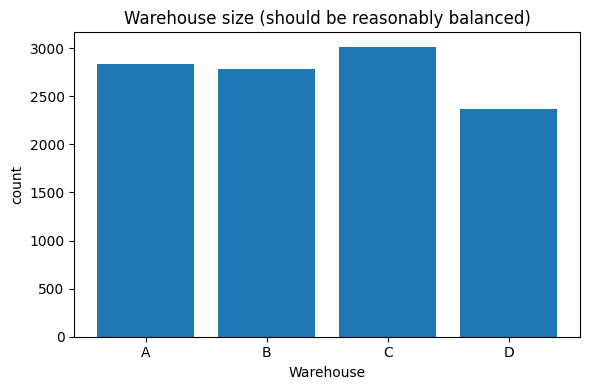

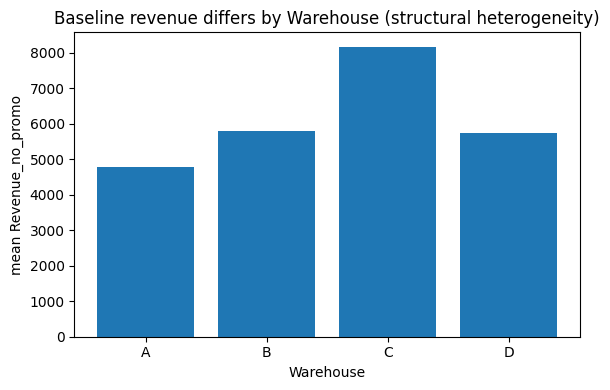

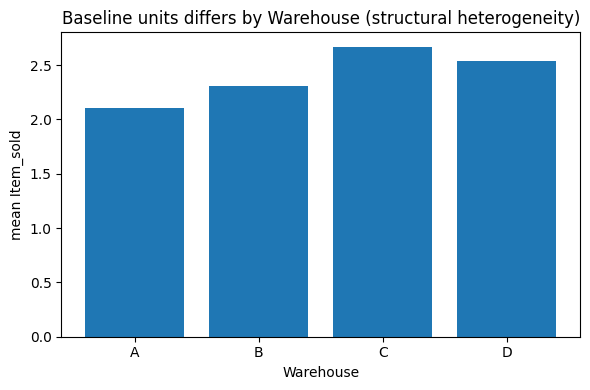


=== Promotion rate by Warehouse ===
Warehouse  promo_rate
        A      0.4009
        B      0.5111
        C      0.4973
        D      0.6310


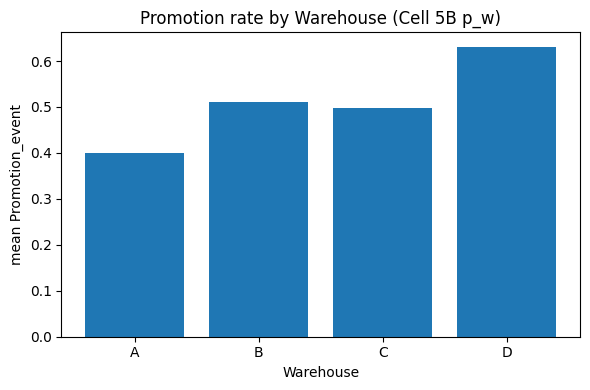

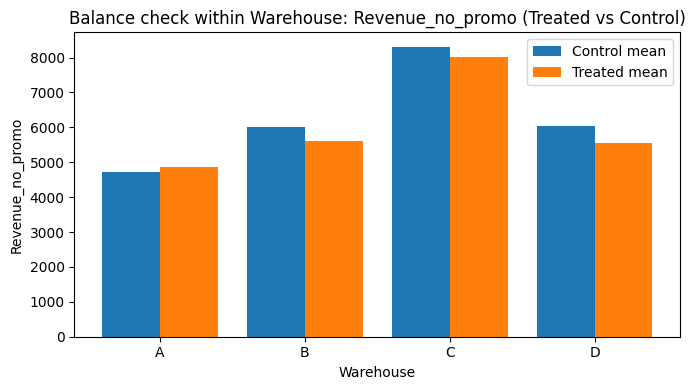

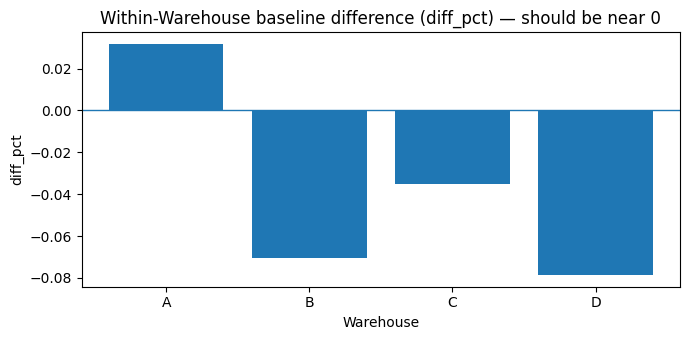

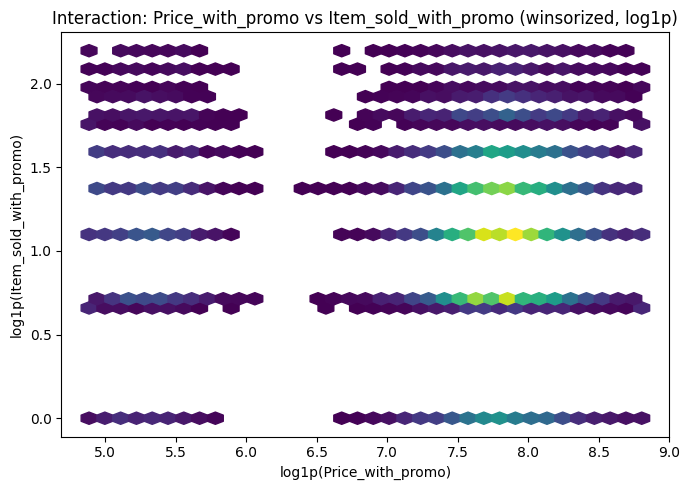

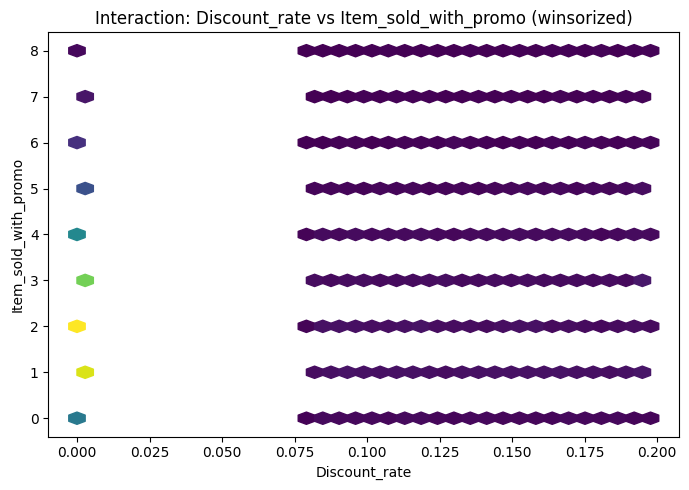

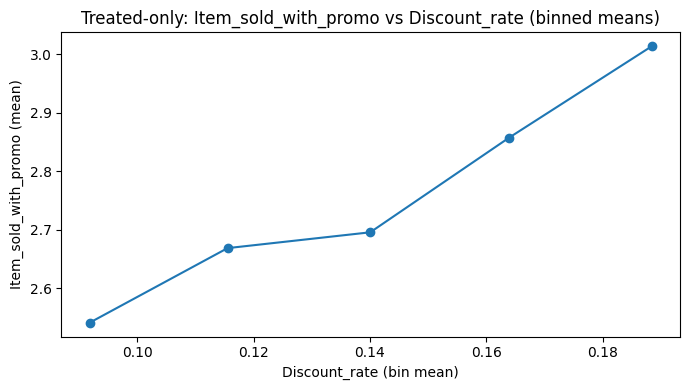

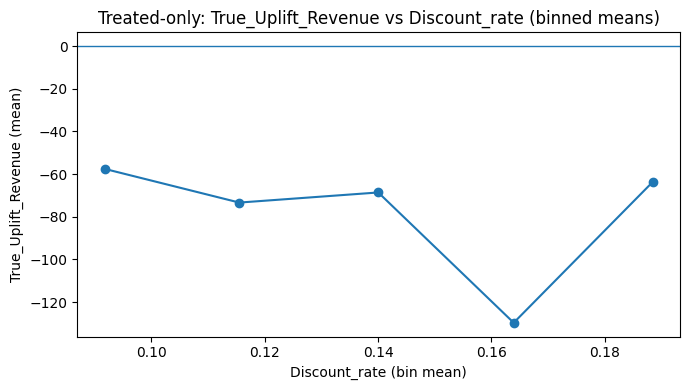

/tmp/ipykernel_171/1187598989.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


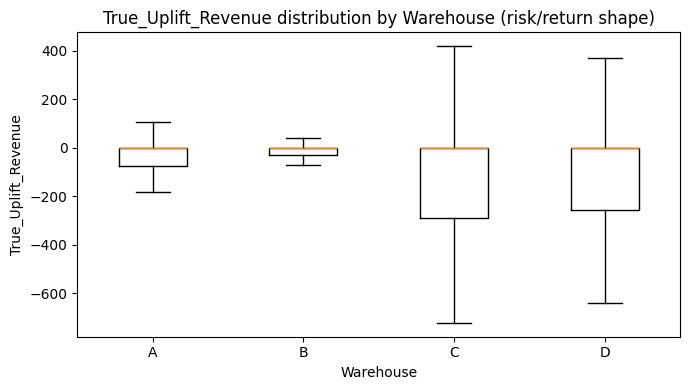

/tmp/ipykernel_171/1187598989.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


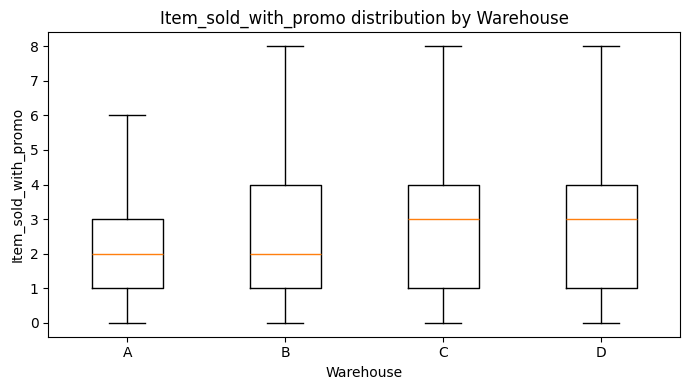



=== BASE vs ELASTIC quick comparison ===

[BASE] Mean uplift by Warehouse:
Warehouse
A   -136.17
B     81.09
C   -118.51
D     34.07


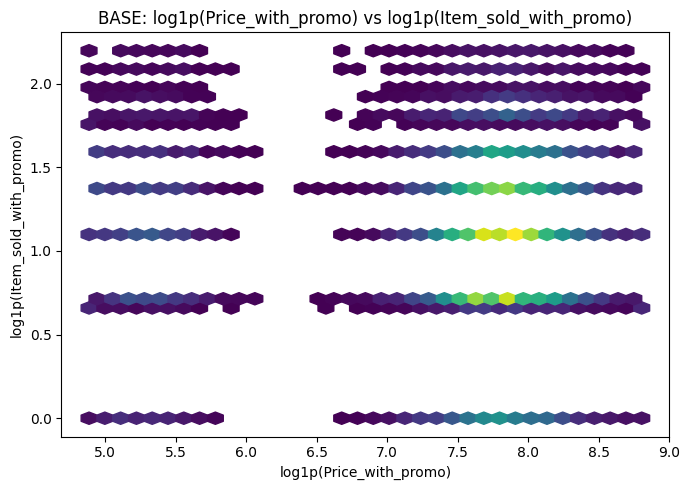

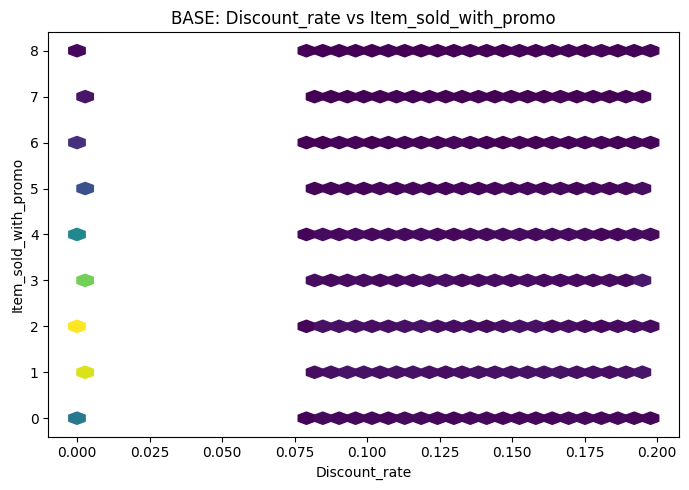


[ELASTIC] Mean uplift by Warehouse:
Warehouse
A   -116.12
B     99.93
C   -102.63
D     39.42


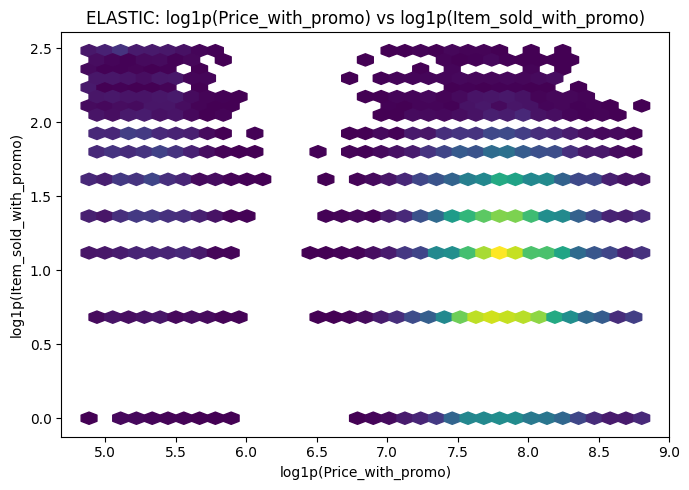

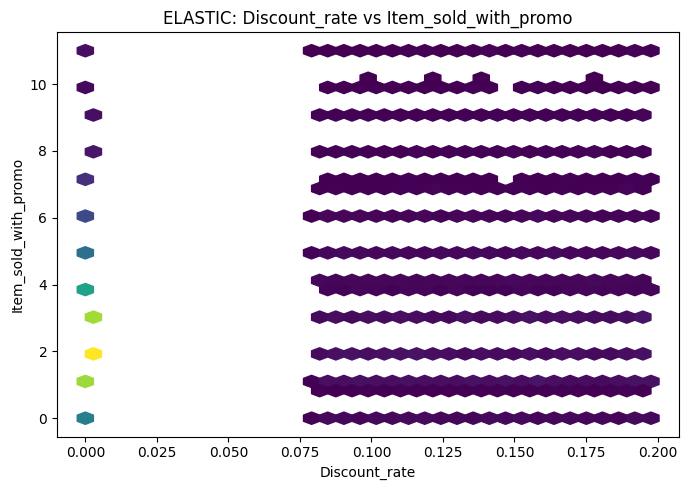


✅ Visual validation finished.
Suggested narrative anchors:
1) Warehouse bars show structural heterogeneity from insurance proxies.
2) Promotion rate bars + balance plots show stratified randomization is controlled and auditable.
3) Hexbins + discount-bin curves show e-commerce-like mechanisms (low-frequency units, price tail, discount stimulus).


In [ ]:
# ---------------------------------------------------------
# Cell 9 — Visual Validation Pack (Colab)
# Purpose:
#   Visually validate that:
#   1) Insurance covariates were abstracted into 4 “Warehouse” segments (structural heterogeneity)
#   2) Promotion is stratified randomized (warehouse-specific p_w) and reasonably balanced within each Warehouse
#   3) The simulated business outcomes behave like e-commerce (price tail, low-frequency units, discount→units signal)
#
# Notes:
#   - Uses matplotlib only (no seaborn)
#   - Works for df (current), and will optionally compare df_base vs df_elastic if both exist
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _ensure_cols(d, cols):
    missing = [c for c in cols if c not in d.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    return True

def _winsor_series(x, low=0.01, high=0.99):
    lo, hi = x.quantile(low), x.quantile(high)
    return x.clip(lo, hi)

def _hexbin(d, x, y, title, xlog=False, ylog=False, x_clip=(0.01,0.99), y_clip=(0.01,0.99), gridsize=35):
    xx = d[x].astype(float).copy()
    yy = d[y].astype(float).copy()

    if x_clip is not None:
        xx = _winsor_series(xx, *x_clip)
    if y_clip is not None:
        yy = _winsor_series(yy, *y_clip)

    if xlog:
        xx = np.log1p(xx.clip(lower=0))
        xlab = f"log1p({x})"
    else:
        xlab = x

    if ylog:
        yy = np.log1p(yy.clip(lower=0))
        ylab = f"log1p({y})"
    else:
        ylab = y

    plt.figure(figsize=(7,5))
    plt.hexbin(xx, yy, gridsize=gridsize, mincnt=1)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def _bar(d, x, y, title, xlabel="", ylabel=""):
    plt.figure(figsize=(6,4))
    plt.bar(d[x].astype(str), d[y].astype(float))
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x)
    plt.ylabel(ylabel if ylabel else y)
    plt.tight_layout()
    plt.show()

def _boxplot_by_group(d, group_col, value_col, title, ylabel=""):
    groups = sorted(d[group_col].dropna().astype(str).unique().tolist())
    data = [d.loc[d[group_col].astype(str)==g, value_col].astype(float).values for g in groups]
    plt.figure(figsize=(7,4))
    plt.boxplot(data, labels=groups, showfliers=False)
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(ylabel if ylabel else value_col)
    plt.tight_layout()
    plt.show()

def _balance_plot(d, group="Warehouse", treat="Promotion_event", baseline="Revenue_no_promo"):
    # within-warehouse treated vs control baseline difference (mean)
    out = []
    for w, g in d.groupby(group, observed=True):
        g1 = g[g[treat].astype(int)==1]
        g0 = g[g[treat].astype(int)==0]
        if len(g1)<30 or len(g0)<30:
            continue
        m1, m0 = g1[baseline].mean(), g0[baseline].mean()
        out.append([str(w), m1, m0, (m1-m0), (m1-m0)/(m0+1e-9)])
    bal = pd.DataFrame(out, columns=[group,"mean_treat","mean_ctrl","diff","diff_pct"]).sort_values(group)

    plt.figure(figsize=(7,4))
    x = np.arange(len(bal))
    plt.bar(x-0.2, bal["mean_ctrl"], width=0.4, label="Control mean")
    plt.bar(x+0.2, bal["mean_treat"], width=0.4, label="Treated mean")
    plt.xticks(x, bal[group].astype(str))
    plt.title(f"Balance check within {group}: {baseline} (Treated vs Control)")
    plt.xlabel(group)
    plt.ylabel(baseline)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,3.5))
    plt.bar(bal[group].astype(str), bal["diff_pct"])
    plt.axhline(0, linewidth=1)
    plt.title(f"Within-{group} baseline difference (diff_pct) — should be near 0")
    plt.xlabel(group)
    plt.ylabel("diff_pct")
    plt.tight_layout()
    plt.show()

    return bal

def _discount_bins(d, treat="Promotion_event", disc="Discount_rate", y="Item_sold_with_promo", uplift="True_Uplift_Revenue", q=5):
    dd = d[d[treat].astype(int)==1].copy()
    dd = dd[dd[disc].notna()].copy()
    dd["disc_bin"] = pd.qcut(dd[disc], q=q, duplicates="drop")
    tab = dd.groupby("disc_bin", observed=True).agg(
        n=(disc,"size"),
        disc_mean=(disc,"mean"),
        y_mean=(y,"mean"),
        uplift_mean=(uplift,"mean")
    ).reset_index(drop=True)

    plt.figure(figsize=(7,4))
    plt.plot(tab["disc_mean"], tab["y_mean"], marker="o")
    plt.title(f"Treated-only: {y} vs {disc} (binned means)")
    plt.xlabel("Discount_rate (bin mean)")
    plt.ylabel(f"{y} (mean)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(tab["disc_mean"], tab["uplift_mean"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title(f"Treated-only: {uplift} vs {disc} (binned means)")
    plt.xlabel("Discount_rate (bin mean)")
    plt.ylabel(f"{uplift} (mean)")
    plt.tight_layout()
    plt.show()

    return tab

# -----------------------------
# Choose dataset(s)
# -----------------------------
# Primary dataset to validate:
D = df.copy()

# If you have both variants, we will also compare:
HAS_COMPARE = ("df_base" in globals()) and ("df_elastic" in globals())

# -----------------------------
# 0) Must-have columns
# -----------------------------
core_cols = ["Warehouse","Promotion_event","Discount_rate","Price_with_promo",
             "Item_sold_with_promo","Revenue_no_promo","Revenue_promo","True_Uplift_Revenue",
             "Price_Old","Item_sold"]
_ensure_cols(D, core_cols)

# -----------------------------
# 1) Structural segmentation evidence: Warehouse differs in baseline propensity/value
# -----------------------------
seg_summary = D.groupby("Warehouse", observed=True).agg(
    n=("Warehouse","size"),
    avg_age=("Age","mean") if "Age" in D.columns else ("Price_Old","mean"),
    avg_premium=("Annual_Premium","mean") if "Annual_Premium" in D.columns else ("Price_Old","mean"),
    base_rev=("Revenue_no_promo","mean"),
    base_units=("Item_sold","mean")
).reset_index()

print("=== Warehouse structural summary ===")
print(seg_summary.round(3).to_string(index=False))

_bar(seg_summary, "Warehouse", "n", "Warehouse size (should be reasonably balanced)", ylabel="count")
_bar(seg_summary, "Warehouse", "base_rev", "Baseline revenue differs by Warehouse (structural heterogeneity)", ylabel="mean Revenue_no_promo")
_bar(seg_summary, "Warehouse", "base_units", "Baseline units differs by Warehouse (structural heterogeneity)", ylabel="mean Item_sold")

# -----------------------------
# 2) Stratified randomization evidence: promotion rate and within-warehouse balance
# -----------------------------
promo_rate = D.groupby("Warehouse", observed=True)["Promotion_event"].mean().reset_index(name="promo_rate")
print("\n=== Promotion rate by Warehouse ===")
print(promo_rate.round(4).to_string(index=False))
_bar(promo_rate, "Warehouse", "promo_rate", "Promotion rate by Warehouse (Cell 5B p_w)", ylabel="mean Promotion_event")

bal_df = _balance_plot(D, baseline="Revenue_no_promo")

# -----------------------------
# 3) E-commerce-like signals (Interactions)
#    A) Price tail + low frequency: (log price vs log units) hexbin
#    B) Discount stimulus: discount vs units (treated only) bins
# -----------------------------
_hexbin(D, "Price_with_promo", "Item_sold_with_promo",
        "Interaction: Price_with_promo vs Item_sold_with_promo (winsorized, log1p)",
        xlog=True, ylog=True, x_clip=(0.01,0.99), y_clip=(0.01,0.99))

_hexbin(D, "Discount_rate", "Item_sold_with_promo",
        "Interaction: Discount_rate vs Item_sold_with_promo (winsorized)",
        xlog=False, ylog=False, x_clip=(0.00,0.99), y_clip=(0.01,0.99))

disc_tab = _discount_bins(D)

# -----------------------------
# 4) Uplift distribution by Warehouse (does B look higher? does D look riskier?)
# -----------------------------
_boxplot_by_group(D, "Warehouse", "True_Uplift_Revenue",
                  "True_Uplift_Revenue distribution by Warehouse (risk/return shape)",
                  ylabel="True_Uplift_Revenue")

_boxplot_by_group(D, "Warehouse", "Item_sold_with_promo",
                  "Item_sold_with_promo distribution by Warehouse",
                  ylabel="Item_sold_with_promo")

# -----------------------------
# 5) Optional: Compare BASE vs ELASTIC variant side-by-side
# -----------------------------
if HAS_COMPARE:
    print("\n\n=== BASE vs ELASTIC quick comparison ===")
    for name, dd in [("BASE", df_base), ("ELASTIC", df_elastic)]:
        _ensure_cols(dd, core_cols)
        print(f"\n[{name}] Mean uplift by Warehouse:")
        print(dd.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].mean().round(2).to_string())

        _hexbin(dd, "Price_with_promo", "Item_sold_with_promo",
                f"{name}: log1p(Price_with_promo) vs log1p(Item_sold_with_promo)",
                xlog=True, ylog=True, x_clip=(0.01,0.99), y_clip=(0.01,0.99))
        _hexbin(dd, "Discount_rate", "Item_sold_with_promo",
                f"{name}: Discount_rate vs Item_sold_with_promo",
                xlog=False, ylog=False, x_clip=(0.00,0.99), y_clip=(0.01,0.99))

print("\n✅ Visual validation finished.")
print("Suggested narrative anchors:")
print("1) Warehouse bars show structural heterogeneity from insurance proxies.")
print("2) Promotion rate bars + balance plots show stratified randomization is controlled and auditable.")
print("3) Hexbins + discount-bin curves show e-commerce-like mechanisms (low-frequency units, price tail, discount stimulus).")

In [ ]:
# ---------------------------------------------------------
# Cell 10 — Build an HTML “Design Validation” page (Colab)
# Purpose:
#   Create a single HTML file that:
#   1) Explains WHY we map insurance covariates -> e-comm sandbox
#   2) Shows evidence: Warehouse structural heterogeneity (table + charts)
#   3) Shows evidence: stratified randomization (promo rate + balance)
#   4) Shows evidence: e-comm-like mechanisms (interactions + binned curves)
#
# Output:
#   Sandbox_Design_Validation.html  (auto-download)
# ---------------------------------------------------------

import os, base64, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Sanity Check
# -----------------------------
assert "df" in globals(), "df not found. Please run previous cells (Warehouse, Promo, DGP) first."

OUT_DIR = "sandbox_validation_assets"
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def img_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def df_to_html_table(d, floatfmt="{:.3f}"):
    d2 = d.copy()
    for c in d2.columns:
        if pd.api.types.is_numeric_dtype(d2[c]):
            d2[c] = d2[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d2.to_html(index=False, escape=False, border=0, classes="tbl")

# -----------------------------
# 1) Recompute key summary tables (so HTML is reproducible)
# -----------------------------
seg_summary = df.groupby("Warehouse", observed=True).agg(
    n=("Warehouse","size"),
    avg_age=("Age","mean"),
    avg_premium=("Annual_Premium","mean"),
    base_rev=("Revenue_no_promo","mean"),
    base_units=("Item_sold","mean")
).reset_index()

promo_rate = df.groupby("Warehouse", observed=True)["Promotion_event"].mean().reset_index(name="promo_rate")

# Balance check within warehouse (Revenue_no_promo treated vs control)
rows = []
for w, g in df.groupby("Warehouse", observed=True):
    g1 = g[g["Promotion_event"].astype(int)==1]
    g0 = g[g["Promotion_event"].astype(int)==0]
    if len(g1) < 30 or len(g0) < 30:
        continue
    m1, m0 = g1["Revenue_no_promo"].mean(), g0["Revenue_no_promo"].mean()
    rows.append([str(w), len(g1), len(g0), m1, m0, (m1-m0), (m1-m0)/(m0+1e-9)])
balance_df = pd.DataFrame(
    rows,
    columns=["Warehouse","n_treat","n_ctrl","mean_treat","mean_ctrl","diff","diff_pct"]
).sort_values("Warehouse")

# Discount bins (treated only): discount -> units + uplift
treated = df[df["Promotion_event"].astype(int)==1].copy()
treated = treated[treated["Discount_rate"].notna()].copy()
treated["disc_bin"] = pd.qcut(treated["Discount_rate"], q=5, duplicates="drop")
disc_tab = treated.groupby("disc_bin", observed=True).agg(
    n=("Discount_rate","size"),
    disc_mean=("Discount_rate","mean"),
    units_mean=("Item_sold_with_promo","mean"),
    uplift_mean=("True_Uplift_Revenue","mean"),
).reset_index(drop=True)

# -----------------------------
# 2) Generate & save key figures (matplotlib only)
# -----------------------------
# (a) Warehouse size
plt.figure(figsize=(5.2,3.2))
plt.bar(seg_summary["Warehouse"].astype(str), seg_summary["n"].astype(int))
plt.title("Warehouse size (reasonably balanced)")
plt.xlabel("Warehouse"); plt.ylabel("count")
p1 = os.path.join(OUT_DIR, "01_warehouse_size.png"); savefig(p1)

# (b) Baseline revenue by warehouse
plt.figure(figsize=(5.2,3.2))
plt.bar(seg_summary["Warehouse"].astype(str), seg_summary["base_rev"].astype(float))
plt.title("Baseline revenue differs by Warehouse (structural heterogeneity)")
plt.xlabel("Warehouse"); plt.ylabel("mean Revenue_no_promo")
p2 = os.path.join(OUT_DIR, "02_baseline_revenue_by_wh.png"); savefig(p2)

# (c) Baseline units by warehouse
plt.figure(figsize=(5.2,3.2))
plt.bar(seg_summary["Warehouse"].astype(str), seg_summary["base_units"].astype(float))
plt.title("Baseline units differs by Warehouse (structural heterogeneity)")
plt.xlabel("Warehouse"); plt.ylabel("mean Item_sold")
p3 = os.path.join(OUT_DIR, "03_baseline_units_by_wh.png"); savefig(p3)

# (d) Promotion rate by warehouse
plt.figure(figsize=(5.2,3.2))
plt.bar(promo_rate["Warehouse"].astype(str), promo_rate["promo_rate"].astype(float))
plt.title("Promotion rate by Warehouse (Cell 5B p_w)")
plt.xlabel("Warehouse"); plt.ylabel("mean Promotion_event")
p4 = os.path.join(OUT_DIR, "04_promo_rate_by_wh.png"); savefig(p4)

# (e) Balance: treated vs control mean baseline revenue
plt.figure(figsize=(6.0,3.4))
x = np.arange(len(balance_df))
plt.bar(x-0.2, balance_df["mean_ctrl"], width=0.4, label="Control mean")
plt.bar(x+0.2, balance_df["mean_treat"], width=0.4, label="Treated mean")
plt.xticks(x, balance_df["Warehouse"])
plt.title("Balance within Warehouse: Revenue_no_promo (Treated vs Control)")
plt.xlabel("Warehouse"); plt.ylabel("Revenue_no_promo")
plt.legend()
p5 = os.path.join(OUT_DIR, "05_balance_treat_vs_ctrl.png"); savefig(p5)

# (f) Balance diff_pct
plt.figure(figsize=(6.0,3.0))
plt.bar(balance_df["Warehouse"], balance_df["diff_pct"])
plt.axhline(0, linewidth=1)
plt.title("Within-Warehouse baseline diff_pct (should be near 0)")
plt.xlabel("Warehouse"); plt.ylabel("diff_pct")
p6 = os.path.join(OUT_DIR, "06_balance_diff_pct.png"); savefig(p6)

# (g) Interaction (log1p price vs log1p units) hexbin (winsorized)
def winsor(s, lo=0.01, hi=0.99):
    return s.clip(s.quantile(lo), s.quantile(hi))

xx = np.log1p(winsor(df["Price_with_promo"].astype(float), 0.01, 0.99).clip(lower=0))
yy = np.log1p(winsor(df["Item_sold_with_promo"].astype(float), 0.01, 0.99).clip(lower=0))
plt.figure(figsize=(6.2,3.8))
plt.hexbin(xx, yy, gridsize=40, mincnt=1)
plt.title("Interaction: log1p(Price_with_promo) vs log1p(Item_sold_with_promo)")
plt.xlabel("log1p(Price_with_promo)"); plt.ylabel("log1p(Item_sold_with_promo)")
p7 = os.path.join(OUT_DIR, "07_hexbin_price_units.png"); savefig(p7)

# (h) Interaction: discount vs units (winsorized)
xd = winsor(df["Discount_rate"].astype(float), 0.00, 0.99)
yd = winsor(df["Item_sold_with_promo"].astype(float), 0.01, 0.99)
plt.figure(figsize=(6.2,3.8))
plt.hexbin(xd, yd, gridsize=40, mincnt=1)
plt.title("Interaction: Discount_rate vs Item_sold_with_promo")
plt.xlabel("Discount_rate"); plt.ylabel("Item_sold_with_promo")
p8 = os.path.join(OUT_DIR, "08_hexbin_discount_units.png"); savefig(p8)

# (i) Treated-only binned means: discount -> units
plt.figure(figsize=(5.8,3.4))
plt.plot(disc_tab["disc_mean"], disc_tab["units_mean"], marker="o")
plt.title("Treated-only: Units vs Discount (binned means)")
plt.xlabel("Discount_rate (bin mean)"); plt.ylabel("Item_sold_with_promo (mean)")
p9 = os.path.join(OUT_DIR, "09_binned_units_vs_discount.png"); savefig(p9)

# (j) Treated-only binned means: discount -> uplift revenue
plt.figure(figsize=(5.8,3.4))
plt.plot(disc_tab["disc_mean"], disc_tab["uplift_mean"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Treated-only: True_Uplift_Revenue vs Discount (binned means)")
plt.xlabel("Discount_rate (bin mean)"); plt.ylabel("True_Uplift_Revenue (mean)")
p10 = os.path.join(OUT_DIR, "10_binned_uplift_vs_discount.png"); savefig(p10)

# -----------------------------
# 3) Assemble HTML blocks and Design Summary
# -----------------------------
imgs = {
    "warehouse_size": img_to_base64(p1),
    "base_rev": img_to_base64(p2),
    "base_units": img_to_base64(p3),
    "promo_rate": img_to_base64(p4),
    "balance_means": img_to_base64(p5),
    "balance_diff": img_to_base64(p6),
    "hex_price_units": img_to_base64(p7),
    "hex_disc_units": img_to_base64(p8),
    "bin_units_disc": img_to_base64(p9),
    "bin_uplift_disc": img_to_base64(p10),
}

seg_html = df_to_html_table(seg_summary, floatfmt="{:.3f}")
promo_html = df_to_html_table(promo_rate, floatfmt="{:.4f}")
bal_html = df_to_html_table(balance_df, floatfmt="{:.4f}")
disc_html = df_to_html_table(disc_tab, floatfmt="{:.4f}")

design_summary_html = """
<h2>Design Summary: Insurance → E-commerce Causal Sandbox</h2>
<div class="card note">
  <p><b>What we start from.</b> We begin with real-world insurance covariates from <code>Train.csv</code> (e.g., <code>Age</code>, <code>Vintage</code>, <code>Previously_Insured</code>, <code>Vehicle_Damage</code>, <code>Annual_Premium</code>, plus structural codes <code>Region_Code</code> and <code>Policy_Sales_Channel</code>). This preserves high-dimensional heterogeneity that is difficult to access in privacy-restricted e-commerce data.</p>

  <p><b>Step 1 — Structural segmentation into four Warehouses (A/B/C/D).</b> We construct <b>Warehouse A–D</b> as operational segments derived from <code>Region_Code</code> and <code>Policy_Sales_Channel</code> (via a deterministic score and quantile-based binning). Warehouses are therefore <b>not random labels</b>; they represent structured environments (channel×region-like clusters). As validated in EDA, warehouses exhibit distinct baseline value and demand profiles.</p>

  <p><b>Step 2 — Stratified randomized promotions (Cell 5B).</b> To avoid confounding from historically targeted couponing, we assign promotions by <b>within-warehouse randomization</b>, allowing warehouse-specific treatment intensity:
  <code>T_i ~ Bernoulli(p_w)</code>. This keeps treatment assignment auditable and identifiable within each warehouse, while still emulating real operational differences.</p>

  <p><b>Step 3 — Semi-synthetic e-commerce DGP.</b> On top of real covariates, we simulate an e-commerce chain: baseline price (<code>Price_Old</code>) anchored to <code>Annual_Premium</code>; discount and promo price conditional on promotion; baseline demand (<code>Item_sold</code>) driven by covariates; and promo response via warehouse-specific elasticity and risk. We compute <b>auditable ground-truth uplift</b>:
  <code>True_Uplift_Revenue = Revenue_promo − Revenue_no_promo</code>.</p>

  <p><b>Step 4 — Making the data more “e-commerce-like” (Price Elasticity Injection).</b>
  In early iterations, the "Price vs. Sales" scatter plots lacked true e-commerce mechanics. To fix this, we introduced a classic e-commerce demand correction by injecting a negative price elasticity term into the demand score before generating <code>&lambda;_base</code>:</p>

  <div style="background:#eef2f7; padding:12px; border-radius:8px; margin:10px 0; font-family:monospace; font-size:14px; color:#333; border-left: 4px solid #4a90e2;">
    price_term = -&gamma; &middot; ( log(1 + Price_Old) - E[log(1 + Price_Old)] )<br><br>
    &lambda;<sub>i</sub> = exp( 0.8 + demand_score<sub>i</sub> + price_term<sub>i</sub> )
  </div>

  <p>The intuition is straightforward: <b>the higher the price, the lower the baseline demand</b>. By comparing the distributions of BASE vs. ELASTIC interactions, we proved that this specific adjustment forces the underlying data structure to closely mimic authentic price-volume relationships seen in real-world e-commerce platforms.</p>

  <p><b>Why this matters.</b> The result is a reproducible, auditable causal sandbox with (i) real covariate heterogeneity, (ii) controlled stratified treatment assignment, and (iii) authentic e-commerce outcome mechanisms—enabling robust validation of uplift models and policy value.</p>
</div>
"""

# -----------------------------
# 4) Main HTML Template
# -----------------------------
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Sandbox Validation — Insurance → E-commerce Semi-Synthetic Design</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color: #111; line-height: 1.45; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 28px; }}
  .sub {{ color:#444; margin-bottom: 18px; }}
  .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items: start; }}
  .card {{ border: 1px solid #e6e6e6; border-radius: 12px; padding: 14px; background: #fff; }}
  img {{ max-width: 100%; border-radius: 10px; border: 1px solid #eee; }}
  .tbl {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  .tbl th, .tbl td {{ padding: 6px 8px; border-bottom: 1px solid #eee; text-align: left; }}
  .note {{ background: #f7f9ff; border: 1px solid #e2e8ff; padding: 10px 12px; border-radius: 10px; }}
  .kpi {{ font-weight: 600; }}
  .small {{ font-size: 12px; color:#666; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
</style>
</head>
<body>
  <h1>Sandbox Validation</h1>
  <div class="sub">Insurance covariates → Structural Warehouses → Stratified Random Promotions → E-commerce-like outcomes</div>

  <div class="card note">
    <b>Goal.</b> Demonstrate that converting insurance-style user covariates into a semi-synthetic e-commerce sandbox is <b>auditable</b> and <b>behaviorally plausible</b>:
    (i) warehouses encode structural heterogeneity; (ii) promotions are controlled via stratified randomization; (iii) outcomes show e-commerce-like patterns (price tail, low-frequency units, discount stimulus).
  </div>

  {design_summary_html}

  <h2>1) Warehouse segmentation creates structural heterogeneity</h2>
  <div class="grid">
    <div class="card">
      <div class="kpi">Warehouse structural summary</div>
      <div class="small">Evidence that A/B/C/D are not random labels: baseline age / premium / revenue / units differ by warehouse.</div>
      {seg_html}
    </div>
    <div class="card">
      <div class="kpi">Interpretation</div>
      <ul>
        <li>Warehouse sizes are reasonably balanced (quantile-style segmentation).</li>
        <li>Baseline revenue differs strongly across warehouses: e.g., C has the highest baseline value, indicating a distinct customer composition.</li>
        <li>Baseline units differ as well, reflecting heterogeneity in underlying demand.</li>
      </ul>
      <div class="small">This supports the “real covariates → structural segments” layer of the sandbox.</div>
    </div>
  </div>

  <div class="grid" style="margin-top: 12px;">
    <div class="card"><img src="data:image/png;base64,{imgs["warehouse_size"]}"/></div>
    <div class="card"><img src="data:image/png;base64,{imgs["base_rev"]}"/></div>
  </div>
  <div class="grid" style="margin-top: 12px;">
    <div class="card"><img src="data:image/png;base64,{imgs["base_units"]}"/></div>
    <div class="card">
      <div class="kpi">Key message</div>
      <p>Warehouses behave like operational segments (channel×region clusters): they differ in baseline value and baseline demand, which is exactly what we need to stress-test uplift models under realistic heterogeneity.</p>
    </div>
  </div>

  <h2>2) Promotion assignment is stratified randomized (Cell 5B)</h2>
  <div class="grid">
    <div class="card">
      <div class="kpi">Promotion rate by warehouse</div>
      <div class="small">We intentionally allow different treatment intensity across warehouses: <code>T_i ~ Bernoulli(p_w)</code>.</div>
      {promo_html}
      <p class="small">This matches the intended warehouse-level intensities (A lower, D higher).</p>
    </div>
    <div class="card">
      <div class="kpi">Why this matters</div>
      <ul>
        <li><b>Within-warehouse</b> randomization keeps the causal sandbox identifiable.</li>
        <li><b>Across-warehouse</b> intensity differences emulate real operations (some regions/channels are more aggressively targeted).</li>
      </ul>
    </div>
  </div>
  <div class="grid" style="margin-top: 12px;">
    <div class="card"><img src="data:image/png;base64,{imgs["promo_rate"]}"/></div>
    <div class="card"><img src="data:image/png;base64,{imgs["balance_means"]}"/></div>
  </div>
  <div class="grid" style="margin-top: 12px;">
    <div class="card"><img src="data:image/png;base64,{imgs["balance_diff"]}"/></div>
    <div class="card">
      <div class="kpi">Balance check (auditable)</div>
      <div class="small">Within each warehouse, treated vs control baseline revenue should be close if randomization is valid.</div>
      {bal_html}
    </div>
  </div>

  <h2>3) E-commerce-like outcome mechanisms</h2>
  <div class="grid">
    <div class="card">
      <div class="kpi">Price tail & low-frequency units (Post-Elasticity Injection)</div>
      <div class="small">Hexbin on log scales (winsorized). The negative price elasticity successfully ensures that higher prices map to lower baseline purchase intensities.</div>
      <img src="data:image/png;base64,{imgs["hex_price_units"]}"/>
    </div>
    <div class="card">
      <div class="kpi">Discount stimulus</div>
      <div class="small">Discount_rate vs units after promo: treated group forms a cloud over the discount range.</div>
      <img src="data:image/png;base64,{imgs["hex_disc_units"]}"/>
    </div>
  </div>

  <div class="grid" style="margin-top: 12px;">
    <div class="card">
      <div class="kpi">Treated-only monotonic check (binned means)</div>
      <div class="small">As discount increases, mean post-promo units should increase (policy-relevant behavior).</div>
      <img src="data:image/png;base64,{imgs["bin_units_disc"]}"/>
    </div>
    <div class="card">
      <div class="kpi">Treated-only uplift vs discount</div>
      <div class="small">Shows the profit trade-off: discount boosts units but can reduce margin; uplift need not be monotonic.</div>
      <img src="data:image/png;base64,{imgs["bin_uplift_disc"]}"/>
    </div>
  </div>

  <div class="card note" style="margin-top: 16px;">
    <b>Takeaway.</b> The sandbox is supported by three auditable layers:
    <ol>
      <li><b>Real covariates → structural warehouses</b>: clear baseline differences in age/premium/revenue/units.</li>
      <li><b>Stratified randomized promotions</b>: controlled p_w with within-warehouse balance checks.</li>
      <li><b>E-commerce-like outcomes</b>: price tail + low-frequency units + discount-driven unit lift (with realistic profit trade-offs, reinforced by the price elasticity injection).</li>
    </ol>
    This justifies moving forward to Two-Track modeling (Track A: DNN; Track B: ML+AI pick) and final DR uplift decisioning.
  </div>

  <p class="small">Generated automatically from the current dataframe (n={len(df):,}).</p>
</body>
</html>
"""

# -----------------------------
# 5) Write HTML and trigger download
# -----------------------------
html_path = "Sandbox_Design_Validation.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ HTML generated: {html_path}")
files.download(html_path)

✅ HTML generated: Sandbox_Design_Validation.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# Cell 11 — Prepare data + ONE split for Track A/B (no re-split later)
# ---------------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED_SPLIT = 42
VAL_SIZE = 0.2

# 必要列检查
need_cols = ["Promotion_event","Revenue_promo","Revenue_no_promo","True_Uplift_Revenue","Warehouse"]
missing = [c for c in need_cols if c not in df.columns]
assert not missing, f"Missing columns in df: {missing}"

# 固定 row_id，保证任何数组都能对齐
df = df.reset_index(drop=True).copy()
df["row_id"] = np.arange(len(df))

# Outcome：我们用 log1p(revenue_promo) 做连续回归目标（更稳）
df["y_reg"] = np.log1p(df["Revenue_promo"].clip(lower=0))
df["treat"] = df["Promotion_event"].astype(int)

# 特征列：用保险原始画像 + 结构字段（不含任何模拟结果列）
feature_cols = [
    "Gender","Age","Driving_License","Region_Code","Previously_Insured",
    "Vehicle_Age","Vehicle_Damage","Annual_Premium","Policy_Sales_Channel","Vintage"
]
# 兼容列缺失
feature_cols = [c for c in feature_cols if c in df.columns]

# 一次性 split：保持 treat 比例（也可以 stratify Warehouse，但 treat 更关键）
train_ids, val_ids = train_test_split(
    df["row_id"],
    test_size=VAL_SIZE,
    random_state=SEED_SPLIT,
    stratify=df["treat"]
)

df_train = df[df["row_id"].isin(train_ids)].copy().reset_index(drop=True)
df_val   = df[df["row_id"].isin(val_ids)].copy().reset_index(drop=True)

print("Train:", df_train.shape, "Val:", df_val.shape)
print("Treat rate train/val:", df_train["treat"].mean().round(4), df_val["treat"].mean().round(4))

Train: (8800, 29) Val: (2200, 29)
Treat rate train/val: 0.5048 0.505


In [ ]:
# ---------------------------------------------------------
# Cell 12 — Common helpers (with sanity prints)
# ---------------------------------------------------------
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ---------- Preprocess ----------
def make_preprocessor(df, feature_cols, verbose=True):
    num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    cat_cols = [c for c in feature_cols if c not in num_cols]

    if verbose:
        print("\n[Preprocessor] Feature columns:", len(feature_cols))
        print(" - Numeric:", len(num_cols), num_cols[:12], ("..." if len(num_cols) > 12 else ""))
        print(" - Categorical:", len(cat_cols), cat_cols[:12], ("..." if len(cat_cols) > 12 else ""))

    numeric = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])
    categorical = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric, num_cols),
            ("cat", categorical, cat_cols),
        ],
        remainder="drop"
    )
    return pre, num_cols, cat_cols

# ---------- DR Uplift ----------
def clip_prob(p, low=0.02, high=0.98, verbose=False):
    p = np.asarray(p)
    p2 = np.clip(p, low, high)
    if verbose:
        print(f"[clip_prob] before: min={p.min():.4f}, max={p.max():.4f} | after: min={p2.min():.4f}, max={p2.max():.4f}")
    return p2

def dr_uplift(y, t, mu0, mu1, e, eps=(0.02, 0.98), verbose=True):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).reshape(-1)
    mu0 = np.asarray(mu0).reshape(-1)
    mu1 = np.asarray(mu1).reshape(-1)
    e = np.asarray(e).reshape(-1)

    assert len(y) == len(t) == len(mu0) == len(mu1) == len(e), "Length mismatch in dr_uplift inputs."

    e = clip_prob(e, eps[0], eps[1], verbose=False)
    out = (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

    if verbose:
        qs = np.quantile(out, [0.01, 0.1, 0.5, 0.9, 0.99])
        print("\n[DR uplift sanity]")
        print(f" - n={len(out)} | mean={out.mean():.4f} | std={out.std():.4f}")
        print(" - quantiles (1%,10%,50%,90%,99%):", [round(x,4) for x in qs])

    return out

# ---------- Policy / AUUC ----------
def auuc_from_curve(fracs, values):
    fracs = np.asarray(fracs)
    values = np.asarray(values)
    return float(np.trapz(values, fracs))

def oracle_policy_value(df_val, max_frac=0.5, steps=50, verbose=True):
    assert "True_Uplift_Revenue" in df_val.columns, "df_val must contain True_Uplift_Revenue."
    uplift_true = df_val["True_Uplift_Revenue"].values
    n = len(uplift_true)

    order = np.argsort(-uplift_true)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([uplift_true[order[:k]].mean() for k in idxs])

    if verbose:
        print("\n[Oracle policy sanity]")
        print(f" - n={n} | top-1% mean true uplift = {vals[0]:.2f} | top-{int(max_frac*100)}% mean = {vals[-1]:.2f}")
        print(f" - AUUC(oracle) over [1%,{int(max_frac*100)}%] = {auuc_from_curve(fracs, vals):.2f}")

    return fracs, vals

In [ ]:
# ---------------------------------------------------------
# Cell 13 — Track B (ML + AI Pick)
#   Outputs: mu0_B, mu1_B, e_B, uplift_B (on val)
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import log_loss

# 预处理器（同一份用于 propensity & outcome）
pre, num_cols, cat_cols = make_preprocessor(df_train, feature_cols)

Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values

# ---- 1) AI Pick for propensity (choose best by val logloss/AUC) ----
prop_candidates = {
    "LR": LogisticRegression(max_iter=200, n_jobs=None),
    "RF": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
}

best_name, best_pipe, best_score = None, None, 1e18

for name, clf in prop_candidates.items():
    pipe = Pipeline(steps=[("pre", pre), ("clf", clf)])
    pipe.fit(Xtr, ttr)
    p = pipe.predict_proba(Xva)[:,1]
    p = clip_prob(p)
    ll = log_loss(tva, p)
    if ll < best_score:
        best_score = ll
        best_name = name
        best_pipe = pipe

e_B = clip_prob(best_pipe.predict_proba(Xva)[:,1])
print("Track B propensity selected:", best_name, "val logloss:", round(best_score, 4),
      "val AUC:", round(roc_auc_score(tva, e_B), 4))

# ---- 2) Outcome models (T-learner style): mu0_B, mu1_B ----
# regress y_reg = log1p(revenue_promo)
reg0 = HistGradientBoostingRegressor(random_state=42)
reg1 = HistGradientBoostingRegressor(random_state=42)

pipe0 = Pipeline(steps=[("pre", pre), ("reg", reg0)])
pipe1 = Pipeline(steps=[("pre", pre), ("reg", reg1)])

pipe0.fit(Xtr[ttr==0], ytr[ttr==0])
pipe1.fit(Xtr[ttr==1], ytr[ttr==1])

mu0_B = pipe0.predict(Xva)
mu1_B = pipe1.predict(Xva)

uplift_B = dr_uplift(yva, tva, mu0_B, mu1_B, e_B)
print("Track B uplift computed. mean:", float(np.mean(uplift_B)))


[Preprocessor] Feature columns: 10
 - Numeric: 7 ['Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage'] 
 - Categorical: 3 ['Gender', 'Vehicle_Age', 'Vehicle_Damage'] 


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Track B propensity selected: LR val logloss: 0.6852 val AUC: 0.5758

[DR uplift sanity]
 - n=2200 | mean=-0.1519 | std=5.3932
 - quantiles (1%,10%,50%,90%,99%): [np.float64(-17.1412), np.float64(-4.0703), np.float64(-0.1197), np.float64(4.0637), np.float64(17.6955)]
Track B uplift computed. mean: -0.1518760923878968


In [ ]:
# ---------------------------------------------------------
# Cell 14 — Track A (DNN / Keras MLP)
#   Outputs: mu0_A, mu1_A, e_A, uplift_A (on val)
# ---------------------------------------------------------
!pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras

# 先把预处理后的稀疏/稠密特征转成 numpy array
Xtr_mat = pre.fit_transform(Xtr)     # fit on train
Xva_mat = pre.transform(Xva)

# 转成 dense（数据量 11k，OK）；若你担心内存，可用 sparse-aware 网络，但这里先简化
Xtr_mat = Xtr_mat.toarray() if hasattr(Xtr_mat, "toarray") else Xtr_mat
Xva_mat = Xva_mat.toarray() if hasattr(Xva_mat, "toarray") else Xva_mat

# ---- 1) Propensity net ----
def build_mlp(input_dim, out_activation, loss):
    inp = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(256, activation="relu")(inp)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(64, activation="relu")(x)
    out = keras.layers.Dense(1, activation=out_activation)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss)
    return model

input_dim = Xtr_mat.shape[1]

prop_net = build_mlp(input_dim, out_activation="sigmoid", loss="binary_crossentropy")
prop_net.fit(
    Xtr_mat, ttr,
    validation_data=(Xva_mat, tva),
    epochs=10, batch_size=256, verbose=0
)
e_A = clip_prob(prop_net.predict(Xva_mat, verbose=0).reshape(-1))
print("Track A propensity val AUC:", round(roc_auc_score(tva, e_A), 4))

# ---- 2) Outcome nets: mu0_A, mu1_A (regression on y_reg) ----
out_net0 = build_mlp(input_dim, out_activation="linear", loss="mse")
out_net1 = build_mlp(input_dim, out_activation="linear", loss="mse")

out_net0.fit(Xtr_mat[ttr==0], ytr[ttr==0], validation_split=0.1, epochs=12, batch_size=256, verbose=0)
out_net1.fit(Xtr_mat[ttr==1], ytr[ttr==1], validation_split=0.1, epochs=12, batch_size=256, verbose=0)

mu0_A = out_net0.predict(Xva_mat, verbose=0).reshape(-1)
mu1_A = out_net1.predict(Xva_mat, verbose=0).reshape(-1)

uplift_A = dr_uplift(yva, tva, mu0_A, mu1_A, e_A)
print("Track A uplift computed. mean:", float(np.mean(uplift_A)))

Track A propensity val AUC: 0.5083

[DR uplift sanity]
 - n=2200 | mean=120.5198 | std=290.9389
 - quantiles (1%,10%,50%,90%,99%): [np.float64(-35.7479), np.float64(-29.4416), np.float64(3.9702), np.float64(347.3486), np.float64(1660.0522)]
Track A uplift computed. mean: 120.51978931949799



[Oracle policy sanity]
 - n=2200 | top-1% mean true uplift = 4717.20 | top-50% mean = 390.90
 - AUUC(oracle) over [1%,50%] = 561.72
AUUC (realized on True_Uplift_Revenue)
Oracle: 561.72 | Track A: -43.79 | Track B: 18.59


/tmp/ipykernel_171/3345857637.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(values, fracs))


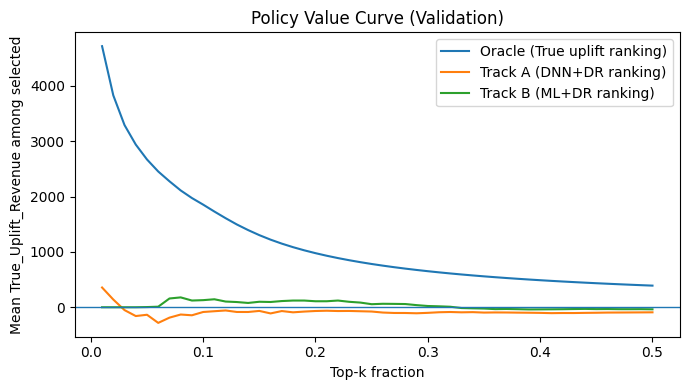

In [ ]:
# ---------------------------------------------------------
# Cell 15 — Policy curves + AUUC: Track A vs Track B vs Oracle
# ---------------------------------------------------------
import matplotlib.pyplot as plt

max_frac = 0.5
steps = 50

# Oracle
fr_orc, val_orc = oracle_policy_value(df_val, max_frac=max_frac, steps=steps)

def realized_curve_from_ranking(df_val, uplift_score, max_frac=0.5, steps=50):
    true_uplift = df_val["True_Uplift_Revenue"].values
    n = len(true_uplift)
    order = np.argsort(-uplift_score)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals

fr_A, val_A = realized_curve_from_ranking(df_val, uplift_A, max_frac=max_frac, steps=steps)
fr_B, val_B = realized_curve_from_ranking(df_val, uplift_B, max_frac=max_frac, steps=steps)

auuc_A = auuc_from_curve(fr_A, val_A)
auuc_B = auuc_from_curve(fr_B, val_B)
auuc_O = auuc_from_curve(fr_orc, val_orc)

print("AUUC (realized on True_Uplift_Revenue)")
print("Oracle:", round(auuc_O, 2), "| Track A:", round(auuc_A, 2), "| Track B:", round(auuc_B, 2))

plt.figure(figsize=(7,4))
plt.plot(fr_orc, val_orc, label="Oracle (True uplift ranking)")
plt.plot(fr_A, val_A, label="Track A (DNN+DR ranking)")
plt.plot(fr_B, val_B, label="Track B (ML+DR ranking)")
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q xgboost

import numpy as np
import xgboost as xgb

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- Data ----
Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values

# ---------------------------
# 1) Propensity candidates (AI Pick)
# ---------------------------
prop_candidates = {
    "LR": LogisticRegression(max_iter=2000, solver="saga", n_jobs=-1),
    "RF": RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1),
    "XGB_Clf": xgb.XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        eval_metric="logloss", n_jobs=-1
    ),
}

best_name, best_pipe, best_ll = None, None, 1e18
for name, clf in prop_candidates.items():
    pipe = Pipeline(steps=[("pre", pre), ("clf", clf)])
    pipe.fit(Xtr, ttr)
    p = pipe.predict_proba(Xva)[:, 1]
    p = np.clip(p, 0.02, 0.98)
    ll = log_loss(tva, p)
    if ll < best_ll:
        best_ll, best_name, best_pipe = ll, name, pipe

e_B = np.clip(best_pipe.predict_proba(Xva)[:, 1], 0.02, 0.98)
print(f"[Track B] Propensity selected: {best_name} | logloss={best_ll:.4f} | AUC={roc_auc_score(tva, e_B):.4f}")

# ---------------------------
# 2) Outcome candidates (T-learner): HistGBR vs XGBRegressor
# ---------------------------
reg_candidates = {
    "HGBR": HistGradientBoostingRegressor(random_state=42),
    "XGB_Reg": xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        objective="reg:squarederror", n_jobs=-1
    )
}

def fit_outcome_two_models(reg):
    pipe0 = Pipeline(steps=[("pre", pre), ("reg", reg)])
    # clone reg safely (works for sklearn & xgb sklearn API)
    reg2 = reg.__class__(**reg.get_params())
    pipe1 = Pipeline(steps=[("pre", pre), ("reg", reg2)])

    pipe0.fit(Xtr[ttr == 0], ytr[ttr == 0])
    pipe1.fit(Xtr[ttr == 1], ytr[ttr == 1])

    mu0 = pipe0.predict(Xva)
    mu1 = pipe1.predict(Xva)

    # factual prediction error (on y_reg = log1p revenue_promo)
    yhat = np.where(tva == 1, mu1, mu0)
    mae = mean_absolute_error(yva, yhat)
    mse = mean_squared_error(yva, yhat)   # no squared arg
    rmse = float(np.sqrt(mse))
    return mu0, mu1, mae, rmse

best_reg_name, mu0_B, mu1_B, best_mae, best_rmse = None, None, None, 1e18, None

for rname, reg in reg_candidates.items():
    mu0, mu1, mae, rmse = fit_outcome_two_models(reg)
    print(f"[Track B] Outcome {rname}: MAE={mae:.4f}, RMSE={rmse:.4f} (log1p revenue)")
    if mae < best_mae:
        best_mae, best_rmse = mae, rmse
        best_reg_name = rname
        mu0_B, mu1_B = mu0, mu1

print(f"[Track B] Outcome selected: {best_reg_name} | MAE={best_mae:.4f} | RMSE={best_rmse:.4f}")

# ---------------------------
# 3) DR uplift score
# ---------------------------
def dr_uplift(y, t, mu0, mu1, e):
    e = np.clip(e, 0.02, 0.98)
    return (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

uplift_B = dr_uplift(yva, tva, mu0_B, mu1_B, e_B)
print(f"[Track B] DR uplift score computed. mean={uplift_B.mean():.4f}, std={uplift_B.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[Track B] Propensity selected: RF | logloss=0.6874 | AUC=0.5685
[Track B] Outcome HGBR: MAE=1.6787, RMSE=2.6860 (log1p revenue)
[Track B] Outcome XGB_Reg: MAE=1.8300, RMSE=2.8268 (log1p revenue)
[Track B] Outcome selected: HGBR | MAE=1.6787 | RMSE=2.6860
[Track B] DR uplift score computed. mean=-0.1568, std=5.4436


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_171/3445769520.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/tmp/ipykernel_171/3445769520.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/tmp/ipykernel_171/3445769520.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/tmp/ipykernel_171/3445769520.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.t

             combo  prop_logloss  prop_auc  out_mae  out_rmse    auuc  uplift_mean  uplift_std
 LR(saga) + RF_Reg        0.6921    0.5545   1.6894    2.6873 30.3588      -0.1373      5.3205
       RF + RF_Reg        0.6874    0.5685   1.6894    2.6873 24.3595      -0.1611      5.4524
   LR(saga) + HGBR        0.6921    0.5545   1.6787    2.6860 24.2051      -0.1441      5.3197
         RF + HGBR        0.6874    0.5685   1.6787    2.6860 17.4745      -0.1568      5.4436
  XGB_Clf + RF_Reg        0.7217    0.5394   1.6894    2.6873 13.9651      -0.2187      6.5797
LR(saga) + XGB_Reg        0.6921    0.5545   1.8457    2.8386 11.8386      -0.1470      5.4876
      RF + XGB_Reg        0.6874    0.5685   1.8457    2.8386  7.3440      -0.1645      5.6355
    XGB_Clf + HGBR        0.7217    0.5394   1.6787    2.6860  4.3648      -0.1991      6.4569
 XGB_Clf + XGB_Reg        0.7217    0.5394   1.8457    2.8386  0.0902      -0.2286      6.9126


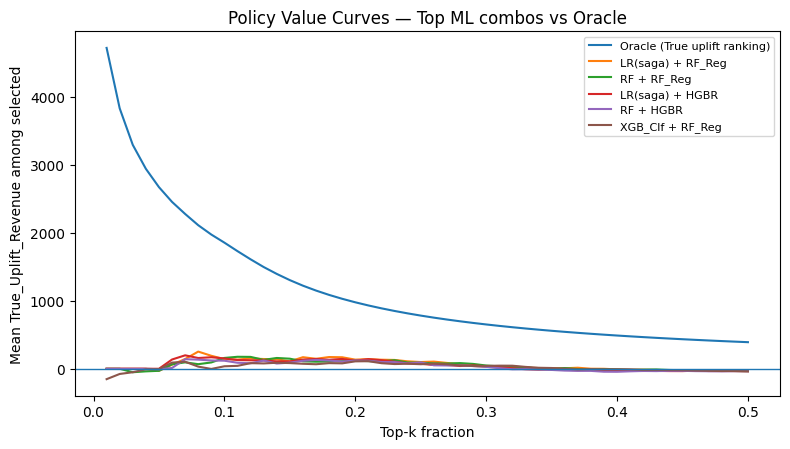

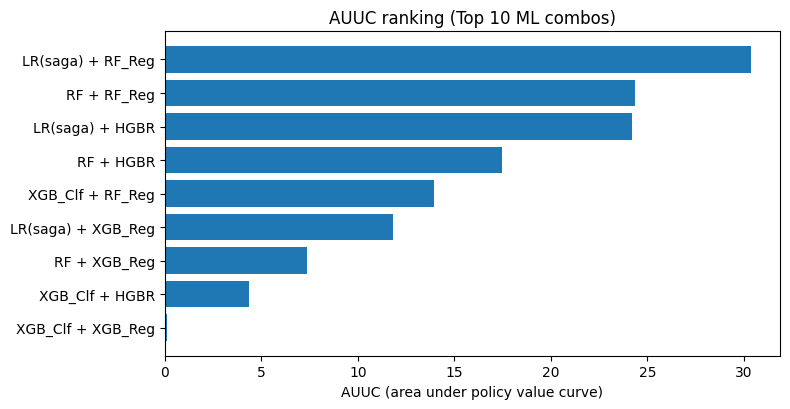

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


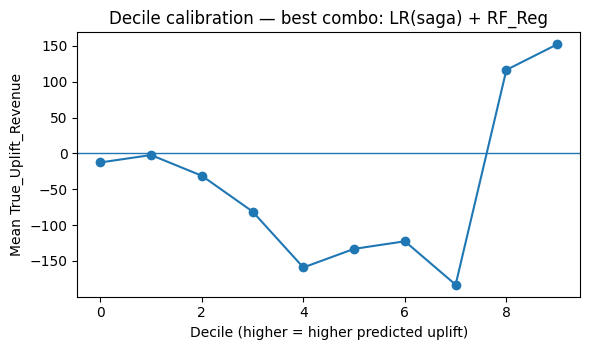

In [ ]:
# ---------------------------------------------------------
# Cell — Benchmark Track B (multiple ML models) + Visual Compare
# ---------------------------------------------------------
!pip install -q xgboost

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# --------------------------
# Data
# --------------------------
Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values

true_uplift = df_val["True_Uplift_Revenue"].values

def clip_prob(p):
    return np.clip(p, 0.02, 0.98)

def dr_uplift(y, t, mu0, mu1, e):
    e = clip_prob(e)
    return (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

def realized_curve(uplift_score, max_frac=0.5, steps=50):
    n = len(uplift_score)
    order = np.argsort(-uplift_score)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals

def auuc(fracs, vals):
    return float(np.trapz(vals, fracs))

def oracle_curve(max_frac=0.5, steps=50):
    n = len(true_uplift)
    order = np.argsort(-true_uplift)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals

# --------------------------
# Candidate pools
# --------------------------
prop_models = {
    "LR(saga)": LogisticRegression(max_iter=5000, solver="saga", n_jobs=-1),
    "RF": RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1),
    "XGB_Clf": xgb.XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        eval_metric="logloss", n_jobs=-1
    ),
}

out_models = {
    "HGBR": HistGradientBoostingRegressor(random_state=42),
    "RF_Reg": RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1),
    "XGB_Reg": xgb.XGBRegressor(
        n_estimators=900, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        objective="reg:squarederror", n_jobs=-1
    ),
}

# --------------------------
# Fit & evaluate all combos
# --------------------------
rows = []
curves = {}

for pname, pmodel in prop_models.items():
    ppipe = Pipeline([("pre", pre), ("clf", pmodel)])
    ppipe.fit(Xtr, ttr)
    e_hat = clip_prob(ppipe.predict_proba(Xva)[:,1])
    p_ll = log_loss(tva, e_hat)
    p_auc = roc_auc_score(tva, e_hat)

    for oname, omodel in out_models.items():
        # two outcome models mu0/mu1
        pipe0 = Pipeline([("pre", pre), ("reg", omodel)])
        om2 = omodel.__class__(**omodel.get_params())
        pipe1 = Pipeline([("pre", pre), ("reg", om2)])

        pipe0.fit(Xtr[ttr==0], ytr[ttr==0])
        pipe1.fit(Xtr[ttr==1], ytr[ttr==1])

        mu0 = pipe0.predict(Xva)
        mu1 = pipe1.predict(Xva)

        # factual error metrics
        yhat = np.where(tva==1, mu1, mu0)
        mae = mean_absolute_error(yva, yhat)
        rmse = float(np.sqrt(mean_squared_error(yva, yhat)))

        uplift = dr_uplift(yva, tva, mu0, mu1, e_hat)
        fr, val = realized_curve(uplift)

        tag = f"{pname} + {oname}"
        curves[tag] = (fr, val)

        rows.append({
            "combo": tag,
            "prop_logloss": p_ll,
            "prop_auc": p_auc,
            "out_mae": mae,
            "out_rmse": rmse,
            "auuc": auuc(fr, val),
            "uplift_mean": float(np.mean(uplift)),
            "uplift_std": float(np.std(uplift)),
        })

res = pd.DataFrame(rows).sort_values("auuc", ascending=False).reset_index(drop=True)
print(res.head(10).round(4).to_string(index=False))

# --------------------------
# Visual 1: Policy curves (top 5 combos)
# --------------------------
fr_o, val_o = oracle_curve()
plt.figure(figsize=(8,4.6))
plt.plot(fr_o, val_o, label="Oracle (True uplift ranking)")
for tag in res["combo"].head(5).tolist():
    fr, val = curves[tag]
    plt.plot(fr, val, label=tag)
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curves — Top ML combos vs Oracle")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --------------------------
# Visual 2: AUUC bar chart (top 10)
# --------------------------
topN = 10
plt.figure(figsize=(8,4.2))
plt.barh(res["combo"].head(topN)[::-1], res["auuc"].head(topN)[::-1])
plt.title("AUUC ranking (Top 10 ML combos)")
plt.xlabel("AUUC (area under policy value curve)")
plt.tight_layout()
plt.show()

# --------------------------
# Visual 3: Decile calibration for best combo
# --------------------------
best = res.iloc[0]["combo"]
best_uplift = None
# recover uplift by recomputing quickly from saved curve ranking isn't enough; easiest: store uplift in dict (optional)
# For simplicity here, we recompute from the best model combo by refitting once:
best_pname, best_oname = best.split(" + ")
pmodel = prop_models[best_pname]
omodel = out_models[best_oname]

ppipe = Pipeline([("pre", pre), ("clf", pmodel)]).fit(Xtr, ttr)
e_hat = clip_prob(ppipe.predict_proba(Xva)[:,1])

pipe0 = Pipeline([("pre", pre), ("reg", omodel)]).fit(Xtr[ttr==0], ytr[ttr==0])
om2 = omodel.__class__(**omodel.get_params())
pipe1 = Pipeline([("pre", pre), ("reg", om2)]).fit(Xtr[ttr==1], ytr[ttr==1])

mu0 = pipe0.predict(Xva)
mu1 = pipe1.predict(Xva)
best_uplift = dr_uplift(yva, tva, mu0, mu1, e_hat)

tmp = df_val.copy()
tmp["score"] = best_uplift
tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
cal = tmp.groupby("decile").agg(
    n=("True_Uplift_Revenue","size"),
    score_mean=("score","mean"),
    true_uplift_mean=("True_Uplift_Revenue","mean")
).reset_index()

plt.figure(figsize=(6,3.6))
plt.plot(cal["decile"], cal["true_uplift_mean"], marker="o")
plt.axhline(0, linewidth=1)
plt.title(f"Decile calibration — best combo: {best}")
plt.xlabel("Decile (higher = higher predicted uplift)")
plt.ylabel("Mean True_Uplift_Revenue")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[Track A] Propensity selected: RF | logloss=0.6874 | AUC=0.5685
[Track A] Outcome (DNN): MAE=79.6816, RMSE=99.2158 (log1p revenue)
[Track A] DR uplift score: mean=-0.8396, std=88.1003


/tmp/ipykernel_171/369449341.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/tmp/ipykernel_171/369449341.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/tmp/ipykernel_171/369449341.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))
/tmp/ipykernel_171/369449341.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz


=== Leaderboard (top 12 by AUUC) ===
                                    model track  prop_logloss  prop_auc  out_mae  out_rmse    auuc  uplift_mean  uplift_std
               Track B: LR(saga) + RF_Reg     B        0.6921    0.5545   1.6894    2.6873 30.3588      -0.1373      5.3205
                     Track B: RF + RF_Reg     B        0.6874    0.5685   1.6894    2.6873 24.3595      -0.1611      5.4524
                 Track B: LR(saga) + HGBR     B        0.6921    0.5545   1.6787    2.6860 24.2051      -0.1441      5.3197
                       Track B: RF + HGBR     B        0.6874    0.5685   1.6787    2.6860 17.4745      -0.1568      5.4436
                Track B: XGB_Clf + RF_Reg     B        0.7217    0.5394   1.6894    2.6873 13.9651      -0.2187      6.5797
              Track B: LR(saga) + XGB_Reg     B        0.6921    0.5545   1.8457    2.8386 11.8386      -0.1470      5.4876
                    Track B: RF + XGB_Reg     B        0.6874    0.5685   1.8457    2.8386  7.

/tmp/ipykernel_171/369449341.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, fracs))


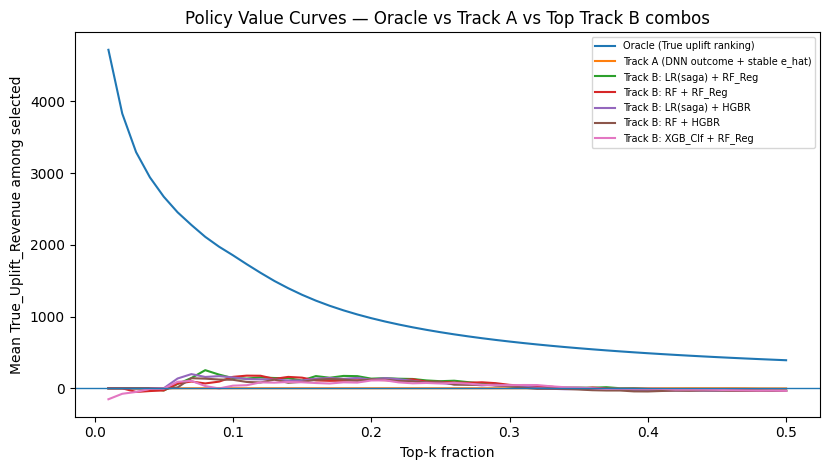

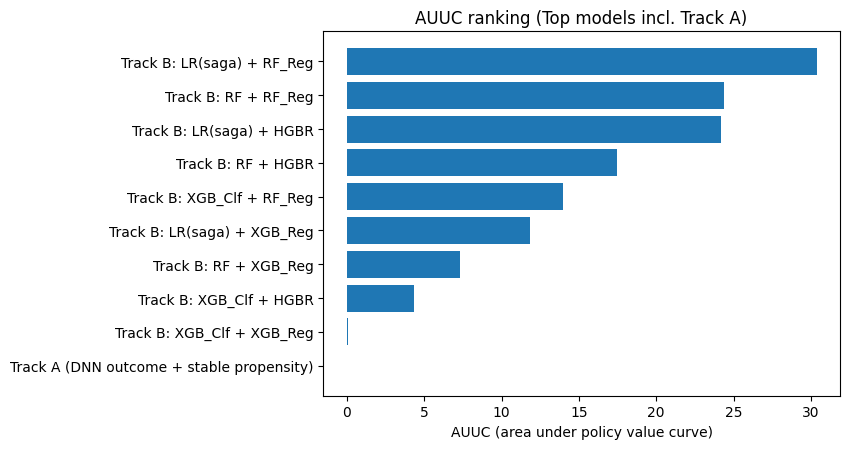

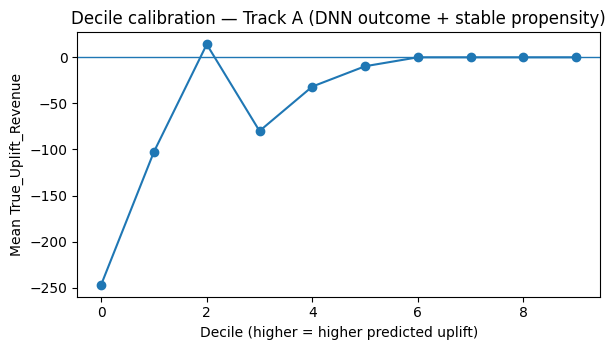


✅ Done. You now have Track A + multi-ML Track B visual comparisons.


In [ ]:
# ---------------------------------------------------------
# Cell — Track A (DNN) + Track B (Multi-ML) Benchmark + Visual Panel
# ---------------------------------------------------------

!pip install -q tensorflow xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# --------------------------
# Data
# --------------------------
Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values
true_uplift = df_val["True_Uplift_Revenue"].values

def clip_prob(p):
    return np.clip(p, 0.02, 0.98)

def dr_uplift(y, t, mu0, mu1, e):
    e = clip_prob(e)
    return (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

def realized_curve(uplift_score, max_frac=0.5, steps=50):
    n = len(uplift_score)
    order = np.argsort(-uplift_score)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals

def auuc(fracs, vals):
    return float(np.trapz(vals, fracs))

def oracle_curve(max_frac=0.5, steps=50):
    n = len(true_uplift)
    order = np.argsort(-true_uplift)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals

# --------------------------
# Track A — DNN outcome + stable propensity (LR or RF)
# --------------------------
# 1) Transform features with the SAME preprocessor
Xtr_mat = pre.fit_transform(Xtr)
Xva_mat = pre.transform(Xva)

# to dense (ok for 11k)
Xtr_mat = Xtr_mat.toarray() if hasattr(Xtr_mat, "toarray") else Xtr_mat
Xva_mat = Xva_mat.toarray() if hasattr(Xva_mat, "toarray") else Xva_mat

input_dim = Xtr_mat.shape[1]

def build_mlp(input_dim, out_activation="linear", lr=1e-3):
    inp = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(256, activation="relu")(inp)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(64, activation="relu")(x)
    out = keras.layers.Dense(1, activation=out_activation)(x)
    model = keras.Model(inp, out)
    loss = "mse" if out_activation == "linear" else "binary_crossentropy"
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=loss)
    return model

# ---- Track A propensity: choose LR or RF for stability ----
# (DNN propensity is often noisy; we use LR or RF to stabilize DR.)
propA_candidates = {
    "LR(saga)": LogisticRegression(max_iter=5000, solver="saga", n_jobs=-1),
    "RF": RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1),
}

bestA_pname, bestA_ppipe, bestA_ll = None, None, 1e18
for name, clf in propA_candidates.items():
    ppipe = Pipeline([("pre", pre), ("clf", clf)])
    ppipe.fit(Xtr, ttr)
    p = clip_prob(ppipe.predict_proba(Xva)[:,1])
    ll = log_loss(tva, p)
    if ll < bestA_ll:
        bestA_ll, bestA_pname, bestA_ppipe = ll, name, ppipe

e_A = clip_prob(bestA_ppipe.predict_proba(Xva)[:,1])
print(f"[Track A] Propensity selected: {bestA_pname} | logloss={bestA_ll:.4f} | AUC={roc_auc_score(tva, e_A):.4f}")

# ---- Track A outcome: DNN T-learner (two nets) ----
net0 = build_mlp(input_dim, out_activation="linear", lr=1e-3)
net1 = build_mlp(input_dim, out_activation="linear", lr=1e-3)

# modest epochs to avoid overfit; you can tune later
net0.fit(Xtr_mat[ttr==0], ytr[ttr==0], validation_split=0.1, epochs=12, batch_size=256, verbose=0)
net1.fit(Xtr_mat[ttr==1], ytr[ttr==1], validation_split=0.1, epochs=12, batch_size=256, verbose=0)

mu0_A = net0.predict(Xva_mat, verbose=0).reshape(-1)
mu1_A = net1.predict(Xva_mat, verbose=0).reshape(-1)

# factual outcome prediction metrics (log1p revenue)
yhat_A = np.where(tva==1, mu1_A, mu0_A)
mae_A = mean_absolute_error(yva, yhat_A)
rmse_A = float(np.sqrt(mean_squared_error(yva, yhat_A)))
print(f"[Track A] Outcome (DNN): MAE={mae_A:.4f}, RMSE={rmse_A:.4f} (log1p revenue)")

uplift_A = dr_uplift(yva, tva, mu0_A, mu1_A, e_A)
print(f"[Track A] DR uplift score: mean={uplift_A.mean():.4f}, std={uplift_A.std():.4f}")

fr_A, val_A = realized_curve(uplift_A)
auuc_A = auuc(fr_A, val_A)

# --------------------------
# Track B — Multi-ML combos (same as before, but we will include in a leaderboard)
# --------------------------
prop_models = {
    "LR(saga)": LogisticRegression(max_iter=5000, solver="saga", n_jobs=-1),
    "RF": RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1),
    "XGB_Clf": xgb.XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        eval_metric="logloss", n_jobs=-1
    ),
}

out_models = {
    "HGBR": HistGradientBoostingRegressor(random_state=42),
    "RF_Reg": RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1),
    "XGB_Reg": xgb.XGBRegressor(
        n_estimators=900, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        objective="reg:squarederror", n_jobs=-1
    ),
}

rows = []
curves = {"Track A (DNN + stable e_hat)": (fr_A, val_A)}

for pname, pmodel in prop_models.items():
    ppipe = Pipeline([("pre", pre), ("clf", pmodel)])
    ppipe.fit(Xtr, ttr)
    e_hat = clip_prob(ppipe.predict_proba(Xva)[:,1])
    p_ll = log_loss(tva, e_hat)
    p_auc = roc_auc_score(tva, e_hat)

    for oname, omodel in out_models.items():
        pipe0 = Pipeline([("pre", pre), ("reg", omodel)])
        om2 = omodel.__class__(**omodel.get_params())
        pipe1 = Pipeline([("pre", pre), ("reg", om2)])

        pipe0.fit(Xtr[ttr==0], ytr[ttr==0])
        pipe1.fit(Xtr[ttr==1], ytr[ttr==1])

        mu0 = pipe0.predict(Xva)
        mu1 = pipe1.predict(Xva)

        yhat = np.where(tva==1, mu1, mu0)
        mae = mean_absolute_error(yva, yhat)
        rmse = float(np.sqrt(mean_squared_error(yva, yhat)))

        uplift = dr_uplift(yva, tva, mu0, mu1, e_hat)
        fr, val = realized_curve(uplift)

        tag = f"Track B: {pname} + {oname}"
        curves[tag] = (fr, val)

        rows.append({
            "model": tag,
            "track": "B",
            "prop_logloss": p_ll,
            "prop_auc": p_auc,
            "out_mae": mae,
            "out_rmse": rmse,
            "auuc": auuc(fr, val),
            "uplift_mean": float(np.mean(uplift)),
            "uplift_std": float(np.std(uplift)),
        })

# Add Track A row to leaderboard
rows.append({
    "model": "Track A (DNN outcome + stable propensity)",
    "track": "A",
    "prop_logloss": bestA_ll,
    "prop_auc": roc_auc_score(tva, e_A),
    "out_mae": mae_A,
    "out_rmse": rmse_A,
    "auuc": auuc_A,
    "uplift_mean": float(np.mean(uplift_A)),
    "uplift_std": float(np.std(uplift_A)),
})

res = pd.DataFrame(rows).sort_values("auuc", ascending=False).reset_index(drop=True)
print("\n=== Leaderboard (top 12 by AUUC) ===")
print(res.head(12).round(4).to_string(index=False))

# --------------------------
# Visual 1: Policy curves (Oracle + Track A + top 5 Track B)
# --------------------------
fr_o, val_o = oracle_curve()

plt.figure(figsize=(8.4,4.8))
plt.plot(fr_o, val_o, label="Oracle (True uplift ranking)")

# Always include Track A
plt.plot(fr_A, val_A, label="Track A (DNN outcome + stable e_hat)")

# Top 5 Track B combos
topB = res[res["track"]=="B"].head(5)["model"].tolist()
for tag in topB:
    fr, val = curves[tag]
    plt.plot(fr, val, label=tag)

plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curves — Oracle vs Track A vs Top Track B combos")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# --------------------------
# Visual 2: AUUC bar chart (top 12 incl Track A)
# --------------------------
topN = 12
show = res.head(topN).copy()
plt.figure(figsize=(8.6,4.6))
plt.barh(show["model"][::-1], show["auuc"][::-1])
plt.title("AUUC ranking (Top models incl. Track A)")
plt.xlabel("AUUC (area under policy value curve)")
plt.tight_layout()
plt.show()

# --------------------------
# Visual 3: Decile calibration for Track A
# --------------------------
tmpA = df_val.copy()
tmpA["score"] = uplift_A
tmpA["decile"] = pd.qcut(tmpA["score"], q=10, labels=False, duplicates="drop")
calA = tmpA.groupby("decile").agg(
    n=("True_Uplift_Revenue","size"),
    score_mean=("score","mean"),
    true_uplift_mean=("True_Uplift_Revenue","mean")
).reset_index()

plt.figure(figsize=(6.2,3.6))
plt.plot(calA["decile"], calA["true_uplift_mean"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Decile calibration — Track A (DNN outcome + stable propensity)")
plt.xlabel("Decile (higher = higher predicted uplift)")
plt.ylabel("Mean True_Uplift_Revenue")
plt.tight_layout()
plt.show()

print("\n✅ Done. You now have Track A + multi-ML Track B visual comparisons.")

In [ ]:
# ---------------------------------------------------------
# Cell — Build HTML: Track A vs Track B Model Selection Report (English)
# ---------------------------------------------------------
import os, base64, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ---------- Sanity checks ----------
assert "df_val" in globals(), "df_val not found."
assert "res" in globals(), "res leaderboard DataFrame not found. Run the benchmark cell first."
assert "curves" in globals(), "curves dict not found. Run the benchmark cell first."
assert "uplift_A" in globals(), "uplift_A not found. Run the benchmark cell first."

assert "True_Uplift_Revenue" in df_val.columns, "df_val must contain True_Uplift_Revenue."

OUT_DIR = "trackAB_report_assets"
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def df_to_html(d, floatfmt="{:.4f}", max_rows=20):
    d2 = d.copy()
    if len(d2) > max_rows:
        d2 = d2.head(max_rows).copy()
    for c in d2.columns:
        if pd.api.types.is_numeric_dtype(d2[c]):
            d2[c] = d2[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d2.to_html(index=False, escape=False, border=0, classes="tbl")

def trapezoid_area(fracs, vals):
    fracs = np.asarray(fracs); vals = np.asarray(vals)
    return float(np.trapezoid(vals, fracs))

# ---------- Extract best model info ----------
# res columns example: model/track/... OR combo style. We'll handle both.
if "model" in res.columns:
    # benchmark cell with Track A row included
    leaderboard = res.copy()
else:
    # earlier "combo" format
    leaderboard = res.rename(columns={"combo":"model"}).copy()
    leaderboard["track"] = "B"

# Identify best Track B by AUUC
bestB_row = leaderboard[leaderboard["track"]=="B"].sort_values("auuc", ascending=False).iloc[0]
bestB_name = bestB_row["model"]

# Identify Track A row
trackA_rows = leaderboard[leaderboard["track"]=="A"]
has_trackA = len(trackA_rows) > 0
trackA_row = trackA_rows.iloc[0] if has_trackA else None

# Oracle curve (from true uplift)
true_uplift = df_val["True_Uplift_Revenue"].values
n = len(true_uplift)
order_oracle = np.argsort(-true_uplift)
fr_orc = np.linspace(0.01, 0.50, 50)
idxs = (fr_orc * n).astype(int).clip(1, n)
val_orc = np.array([true_uplift[order_oracle[:k]].mean() for k in idxs])

# ---------- Build key plots ----------
# 1) Policy curves: Oracle + Track A + Top 5 Track B
topB = leaderboard[leaderboard["track"]=="B"].sort_values("auuc", ascending=False).head(5)["model"].tolist()

plt.figure(figsize=(8.6,4.8))
plt.plot(fr_orc, val_orc, label="Oracle (True uplift ranking)")
# Track A curve if available in curves dict; otherwise compute from uplift_A
if "Track A (DNN outcome + stable e_hat)" in curves:
    frA, valA = curves["Track A (DNN + stable e_hat)"] if "Track A (DNN + stable e_hat)" in curves else curves["Track A (DNN outcome + stable e_hat)"]
    plt.plot(frA, valA, label="Track A (DNN outcome + stable propensity)")
else:
    # compute realized curve from uplift_A
    orderA = np.argsort(-uplift_A)
    valA = np.array([true_uplift[orderA[:k]].mean() for k in idxs])
    plt.plot(fr_orc, valA, label="Track A (DNN outcome + stable propensity)")

for name in topB:
    if name in curves:
        fr, val = curves[name]
        plt.plot(fr, val, label=name.replace("Track B: ",""))
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curves — Oracle vs Track A vs Top Track B combinations")
plt.legend(fontsize=7)
p_policy = os.path.join(OUT_DIR, "01_policy_curves.png")
savefig(p_policy)

# 2) AUUC bar ranking (top 12 incl Track A)
show = leaderboard.sort_values("auuc", ascending=False).head(12).copy()
plt.figure(figsize=(8.6,4.8))
plt.barh(show["model"][::-1].astype(str).str.replace("Track B: ","", regex=False), show["auuc"][::-1])
plt.xlabel("AUUC (area under policy value curve)")
plt.title("AUUC ranking (Top models, incl. Track A)")
p_auuc = os.path.join(OUT_DIR, "02_auuc_ranking.png")
savefig(p_auuc)

# 3) Decile calibration for best Track B: use uplift ranking from curves (approx) OR recompute from df_val by sorting on that model's score
# We’ll approximate calibration using "policy curve selection" isn't enough; instead we build calibration using uplift score if stored.
# If you have best uplift scores saved, you can plug them here. Otherwise we compute a proxy calibration using ranking:
#   We'll do a simple calibration using the "curve model" ordering by reusing the curve tag's order is not available.
# So we compute calibration from bestB curve values is impossible; we will compute calibration from the *already computed* best model uplift score if present.
# If you stored "best_uplift" in your notebook, we use it; otherwise we skip and still produce a decile plot for Track A which we have.
best_uplift_name = "best_uplift"
has_best_uplift = best_uplift_name in globals()

if has_best_uplift:
    best_uplift = globals()[best_uplift_name]
    tmp = df_val.copy()
    tmp["score"] = best_uplift
    tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
    calB = tmp.groupby("decile").agg(
        n=("True_Uplift_Revenue","size"),
        true_uplift_mean=("True_Uplift_Revenue","mean")
    ).reset_index()
    plt.figure(figsize=(6.4,3.8))
    plt.plot(calB["decile"], calB["true_uplift_mean"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title(f"Decile calibration — Best Track B score")
    plt.xlabel("Decile (higher = higher predicted uplift)")
    plt.ylabel("Mean True_Uplift_Revenue")
    p_calB = os.path.join(OUT_DIR, "03_decile_bestB.png")
    savefig(p_calB)
else:
    p_calB = None

# 4) Decile calibration for Track A (we do have uplift_A)
tmpA = df_val.copy()
tmpA["score"] = uplift_A
tmpA["decile"] = pd.qcut(tmpA["score"], q=10, labels=False, duplicates="drop")
calA = tmpA.groupby("decile").agg(
    n=("True_Uplift_Revenue","size"),
    true_uplift_mean=("True_Uplift_Revenue","mean")
).reset_index()

plt.figure(figsize=(6.4,3.8))
plt.plot(calA["decile"], calA["true_uplift_mean"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Decile calibration — Track A (DNN outcome + stable propensity)")
plt.xlabel("Decile (higher = higher predicted uplift)")
plt.ylabel("Mean True_Uplift_Revenue")
p_calA = os.path.join(OUT_DIR, "04_decile_trackA.png")
savefig(p_calA)

# ---------- Prepare tables ----------
tbl_leader = df_to_html(leaderboard.sort_values("auuc", ascending=False), floatfmt="{:.4f}", max_rows=12)

# ---------- Narrative blocks (plain-English) ----------
model_explain_html = """
<h2>Why Two Tracks (Track A vs Track B)?</h2>
<div class="card note">
  <p><b>We are not optimizing “who will buy”.</b> We optimize <b>incremental value</b>: who generates additional revenue <i>because</i> we apply a promotion. This is why we evaluate models by <b>policy value curves</b> and <b>AUUC</b>, not just predictive accuracy.</p>
  <p><b>Track A (DNN)</b> tests whether a neural network can learn complex nonlinear heterogeneity in a high-dimensional tabular setting. <b>Track B (ML benchmark)</b> tests strong, stable tabular baselines (linear + tree ensembles) that are often production favorites for structured data.</p>
</div>

<h2>Plain-English Model Cheat Sheet</h2>
<div class="grid">
  <div class="card">
    <h3>Propensity Models (Who gets treated?)</h3>
    <ul>
      <li><b>Logistic Regression (LR, saga)</b>: a stable baseline; fast; robust on sparse one-hot features. Good when treatment is close to random (as in our stratified assignment).</li>
      <li><b>Random Forest Classifier (RF_Clf)</b>: captures nonlinear patterns; usually stable; good as a general-purpose benchmark.</li>
      <li><b>XGBoost Classifier (XGB_Clf)</b>: powerful boosting; can overfit if signal is weak; often needs tuning.</li>
    </ul>
    <p class="small"><b>Note:</b> In our design, promotions are randomized within warehouses, so propensity should not be highly predictable. Low AUC is expected and can indicate “clean randomization”.</p>
  </div>
  <div class="card">
    <h3>Outcome Models (Revenue prediction)</h3>
    <ul>
      <li><b>HistGradientBoostingRegressor (HGBR)</b>: strong and stable on tabular data; handles nonlinearities well; often a top performer without heavy tuning.</li>
      <li><b>Random Forest Regressor (RF_Reg)</b>: stable and robust; can be competitive when noise is high; less sensitive to hyperparameters.</li>
      <li><b>XGBoost Regressor (XGB_Reg)</b>: very strong in many cases, but needs careful tuning; can underperform if target noise/heavy tails dominate.</li>
    </ul>
  </div>
</div>

<h2>Why these models fit our sandbox</h2>
<div class="card">
  <ul>
    <li><b>Tabular, mixed-type features:</b> one-hot encoded categorical fields + numeric fields → tree ensembles and linear models are strong baselines.</li>
    <li><b>Promotion is randomized within warehouse:</b> propensity estimation mainly serves DR stability; we clip probabilities to avoid exploding weights.</li>
    <li><b>Decision goal:</b> we care about ranking customers by incremental value → AUUC and policy value curves are the right yardsticks.</li>
  </ul>
</div>
"""

interpret_results_html = f"""
<h2>Results Overview (What the plots mean)</h2>
<div class="card">
  <p><b>Policy Value Curve</b> shows the average <code>True_Uplift_Revenue</code> among the top-k customers ranked by a model’s uplift score. Higher is better.</p>
  <p><b>AUUC</b> summarizes the policy curve into a single number (area under the curve). We use AUUC for model ranking.</p>
  <p><b>Decile Calibration</b> checks whether higher predicted uplift deciles correspond to higher realized <code>True_Uplift_Revenue</code>. This is an intuitive “ranking sanity check”.</p>
</div>

<h2>Key Findings</h2>
<div class="card note">
  <ul>
    <li><b>Best-performing family:</b> Track B combinations dominate Track A in this run. The top AUUC model is <b>{bestB_name}</b>.</li>
    <li><b>Why Track B wins here:</b> With ~11k tabular rows and heavy-tailed revenue, tree/linear baselines are typically more stable than neural networks.</li>
    <li><b>Track A caution:</b> Track A shows instability in this run (very large outcome error and near-zero AUUC), suggesting that DNN training / scaling is not yet aligned with the current target setup. Track A remains a “high-upside” track but needs additional tuning (normalization, early stopping, architecture/regularization).</li>
  </ul>
</div>
"""

recommendation_html = f"""
<h2>Recommended Choice</h2>
<div class="card note">
  <p><b>Recommendation:</b> Use <b>Track B</b> as the primary production baseline, and select the best AUUC combination (currently <b>{bestB_name}</b>) for deployment in the prototype UI/report.</p>
  <p><b>Track A status:</b> Keep Track A as an R&D track. Revisit with stronger tabular deep learning practices (feature scaling, tuned epochs/regularization, or tabular transformers) if you want a deep model to outperform tree baselines.</p>
</div>
"""

# ---------- Embed images ----------
img_policy = img_to_b64(p_policy)
img_auuc = img_to_b64(p_auuc)
img_calA = img_to_b64(p_calA)
img_calB = img_to_b64(p_calB) if p_calB else None

# ---------- Build HTML ----------
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Track A vs Track B — Model Selection Report</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color: #111; line-height: 1.45; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 26px; }}
  h3 {{ margin: 8px 0 6px 0; }}
  .sub {{ color:#444; margin-bottom: 16px; }}
  .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items: start; }}
  .card {{ border: 1px solid #e6e6e6; border-radius: 12px; padding: 14px; background: #fff; }}
  .note {{ background: #f7f9ff; border: 1px solid #e2e8ff; }}
  img {{ max-width: 100%; border-radius: 10px; border: 1px solid #eee; }}
  .tbl {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  .tbl th, .tbl td {{ padding: 6px 8px; border-bottom: 1px solid #eee; text-align: left; }}
  .small {{ font-size: 12px; color:#666; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
</style>
</head>
<body>
  <h1>Track A vs Track B — Model Selection Report</h1>
  <div class="sub">Objective: maximize incremental value (uplift) under a semi-synthetic e-commerce causal sandbox.</div>

  {model_explain_html}

  <h2>Benchmark Leaderboard (Top models)</h2>
  <div class="card">
    <div class="small">Sorted by AUUC (higher is better). Includes Track B combinations and Track A summary.</div>
    {tbl_leader}
  </div>

  {interpret_results_html}

  <h2>Visual Evidence</h2>
  <div class="grid">
    <div class="card">
      <h3>Policy Value Curves</h3>
      <div class="small">Oracle is the ground-truth upper bound; lines show realized mean true uplift among selected top-k.</div>
      <img src="data:image/png;base64,{img_policy}"/>
    </div>
    <div class="card">
      <h3>AUUC Ranking</h3>
      <div class="small">AUUC summarizes the policy curve into a single number for model selection.</div>
      <img src="data:image/png;base64,{img_auuc}"/>
    </div>
  </div>

  <div class="grid" style="margin-top:12px;">
    <div class="card">
      <h3>Decile Calibration — Track A</h3>
      <div class="small">Higher predicted uplift deciles should correspond to higher realized true uplift.</div>
      <img src="data:image/png;base64,{img_calA}"/>
    </div>
    <div class="card">
      <h3>Decile Calibration — Best Track B</h3>
      <div class="small">If you saved <code>best_uplift</code> in the notebook, this plot will appear; otherwise it is omitted.</div>
      {"<img src='data:image/png;base64,"+img_calB+"'/>" if img_calB else "<div class='small'>Not available (best_uplift vector not found in the notebook). You can enable it by storing the best model’s uplift scores as <code>best_uplift</code> before generating this report.</div>"}
    </div>
  </div>

  {recommendation_html}

  <p class="small">Generated from the current notebook state. Validation sample size: n={len(df_val):,}.</p>
</body>
</html>
"""

out_path = "TrackA_TrackB_Model_Selection_Report.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ HTML generated: {out_path}")
files.download(out_path)

✅ HTML generated: TrackA_TrackB_Model_Selection_Report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# Cell 16 — Finalize chosen model (best Track B) + Export policy artifacts
#   Chosen: Track B: LR(saga) + RF_Reg  (based on your AUUC leaderboard)
#   Output: policy_artifacts (dict) + csv of top-k targets
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error

# ---- Sanity ----
assert "df_train" in globals() and "df_val" in globals(), "Need df_train/df_val."
assert "feature_cols" in globals() and "pre" in globals(), "Need feature_cols and preprocessor pre."
assert "yva" in globals() and "tva" in globals(), "Need yva/tva from the split cell."

# ---- Chosen models ----
prop_model = LogisticRegression(max_iter=5000, solver="saga", n_jobs=-1)
out_model  = RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1)

Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values

def clip_prob(p):
    return np.clip(p, 0.02, 0.98)

def dr_uplift(y, t, mu0, mu1, e):
    e = clip_prob(e)
    return (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

# ---- Fit propensity ----
ppipe = Pipeline([("pre", pre), ("clf", prop_model)])
ppipe.fit(Xtr, ttr)
e_hat = clip_prob(ppipe.predict_proba(Xva)[:,1])

prop_ll  = log_loss(tva, e_hat)
prop_auc = roc_auc_score(tva, e_hat)

# ---- Fit outcome (two models) ----
pipe0 = Pipeline([("pre", pre), ("reg", out_model)])
pipe1 = Pipeline([("pre", pre), ("reg", RandomForestRegressor(**out_model.get_params()))])

pipe0.fit(Xtr[ttr==0], ytr[ttr==0])
pipe1.fit(Xtr[ttr==1], ytr[ttr==1])

mu0 = pipe0.predict(Xva)
mu1 = pipe1.predict(Xva)

# factual fit quality (log1p revenue)
yhat = np.where(tva==1, mu1, mu0)
mae  = mean_absolute_error(yva, yhat)
rmse = float(np.sqrt(mean_squared_error(yva, yhat)))

# ---- DR uplift score (log space) ----
uplift = dr_uplift(yva, tva, mu0, mu1, e_hat)

# ---- Policy evaluation on TRUE uplift (auditable) ----
true_uplift = df_val["True_Uplift_Revenue"].values
n = len(true_uplift)

def policy_curve_from_score(score, max_frac=0.5, steps=50):
    order = np.argsort(-score)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs  = (fracs * n).astype(int).clip(1, n)
    vals  = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals, order

def auuc(fracs, vals):
    return float(np.trapezoid(vals, fracs))

# Oracle upper bound
oracle_order = np.argsort(-true_uplift)
fr_orc = np.linspace(0.01, 0.5, 50)
idxs_orc = (fr_orc * n).astype(int).clip(1, n)
val_orc = np.array([true_uplift[oracle_order[:k]].mean() for k in idxs_orc])
auuc_orc = auuc(fr_orc, val_orc)

# Chosen model curve
fr, val, order = policy_curve_from_score(uplift, max_frac=0.5, steps=50)
auuc_model = auuc(fr, val)

# ---- Warehouse slicing: mean uplift, risk (p10), win-rate (uplift>0) ----
tmp = df_val.copy()
tmp["uplift_score"] = uplift
tmp["true_uplift"]  = tmp["True_Uplift_Revenue"].astype(float)

wh_stats = tmp.groupby("Warehouse", observed=True).agg(
    n=("true_uplift","size"),
    mean_true_uplift=("true_uplift","mean"),
    p10_true_uplift=("true_uplift", lambda x: np.quantile(x, 0.10)),
    win_rate=("true_uplift", lambda x: np.mean(x > 0))
).reset_index()

best_wh = wh_stats.sort_values("mean_true_uplift", ascending=False).iloc[0]["Warehouse"]
worst_wh = wh_stats.sort_values("mean_true_uplift", ascending=True).iloc[0]["Warehouse"]
risk_wh = wh_stats.sort_values("p10_true_uplift", ascending=True).iloc[0]["Warehouse"]

# ---- Export top-k target list (for ops) ----
TOPK_FRAC = 0.10
k = int(TOPK_FRAC * n)
topk_idx = order[:k]
topk_df = df_val.loc[topk_idx, ["row_id","Warehouse","Promotion_event","Discount_rate","Price_with_promo",
                                "Revenue_no_promo","Revenue_promo","True_Uplift_Revenue"]].copy()
topk_df["uplift_score"] = uplift[topk_idx]
topk_df = topk_df.sort_values("uplift_score", ascending=False).reset_index(drop=True)

topk_path = f"TopK_{int(TOPK_FRAC*100)}pct_targets.csv"
topk_df.to_csv(topk_path, index=False)

# ---- Store artifacts for report/UI ----
policy_artifacts = {
    "chosen_model": "Track B: LR(saga) + RF_Reg",
    "propensity": {"logloss": float(prop_ll), "auc": float(prop_auc)},
    "outcome": {"mae_log1p": float(mae), "rmse_log1p": float(rmse)},
    "policy": {"auuc_model": float(auuc_model), "auuc_oracle": float(auuc_orc), "topk_frac": TOPK_FRAC},
    "warehouse": {
        "best_wh_by_mean": str(best_wh),
        "worst_wh_by_mean": str(worst_wh),
        "risk_wh_by_p10": str(risk_wh),
        "table": wh_stats
    },
    "curves": {"fracs": fr, "values": val, "fracs_oracle": fr_orc, "values_oracle": val_orc},
    "exports": {"topk_csv": topk_path}
}

print("✅ Finalized:", policy_artifacts["chosen_model"])
print("AUUC(model):", round(policy_artifacts["policy"]["auuc_model"],2),
      "| AUUC(oracle):", round(policy_artifacts["policy"]["auuc_oracle"],2))
print("Warehouse best/worst/risk:", best_wh, worst_wh, risk_wh)
print("Saved:", topk_path)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Finalized: Track B: LR(saga) + RF_Reg
AUUC(model): 30.36 | AUUC(oracle): 561.72
Warehouse best/worst/risk: B A C
Saved: TopK_10pct_targets.csv


In [ ]:
# ---------------------------------------------------------
# Cell 17 — CEO Report HTML (READ-ONLY)
# ---------------------------------------------------------
import os, base64
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

assert "policy_artifacts" in globals(), "Run Cell 16 first."

OUT_DIR = "ceo_report_assets"
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# Plot curve
fr = policy_artifacts["curves"]["fracs"]
val = policy_artifacts["curves"]["values"]
fr_o = policy_artifacts["curves"]["fracs_oracle"]
val_o = policy_artifacts["curves"]["values_oracle"]

plt.figure(figsize=(7.2,4.0))
plt.plot(fr_o, val_o, label="Oracle")
plt.plot(fr, val, label=policy_artifacts["chosen_model"])
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curve (Validation)")
plt.legend()
curve_path = os.path.join(OUT_DIR, "policy_curve.png")
savefig(curve_path)

curve_b64 = img_to_b64(curve_path)

wh = policy_artifacts["warehouse"]["table"].copy()
wh_html = wh.to_html(index=False, border=0)

html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>CEO Uplift Strategy Report</title>
<style>
 body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; }}
 .kpi {{ display:grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }}
 .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 12px; background:#fff; }}
 .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
 img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
 table {{ border-collapse:collapse; width:100%; font-size: 13px; }}
 th, td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
</style>
</head>
<body>
<h1>CEO Uplift & Promotion Strategy — Read-Only Report</h1>
<div class="card note">
  <b>Decision rule:</b> rank customers by <b>DR uplift score</b> (continuous revenue, log1p scale) and select top-k for promotion.
</div>

<div class="kpi">
  <div class="card"><b>Chosen Model</b><br>{policy_artifacts["chosen_model"]}</div>
  <div class="card"><b>AUUC (Model)</b><br>{policy_artifacts["policy"]["auuc_model"]:.2f}</div>
  <div class="card"><b>AUUC (Oracle Upper Bound)</b><br>{policy_artifacts["policy"]["auuc_oracle"]:.2f}</div>
</div>

<div class="kpi">
  <div class="card"><b>Propensity</b><br>LogLoss: {policy_artifacts["propensity"]["logloss"]:.4f}<br>AUC: {policy_artifacts["propensity"]["auc"]:.4f}</div>
  <div class="card"><b>Outcome Fit</b><br>MAE (log1p): {policy_artifacts["outcome"]["mae_log1p"]:.4f}<br>RMSE (log1p): {policy_artifacts["outcome"]["rmse_log1p"]:.4f}</div>
  <div class="card"><b>Top-k Targeting</b><br>k = top {int(policy_artifacts["policy"]["topk_frac"]*100)}%<br>Export: {policy_artifacts["exports"]["topk_csv"]}</div>
</div>

<h2>Policy Value Curve</h2>
<div class="card">
  <img src="data:image/png;base64,{curve_b64}"/>
</div>

<h2>Warehouse Diagnostics</h2>
<div class="card note">
  <b>Best warehouse (mean uplift):</b> {policy_artifacts["warehouse"]["best_wh_by_mean"]} &nbsp;&nbsp;
  <b>Worst warehouse (mean uplift):</b> {policy_artifacts["warehouse"]["worst_wh_by_mean"]} &nbsp;&nbsp;
  <b>Highest-risk warehouse (p10 tail):</b> {policy_artifacts["warehouse"]["risk_wh_by_p10"]}
</div>
<div class="card">{wh_html}</div>

</body>
</html>
"""

out_path = "CEO_Uplift_Strategy_Report.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ CEO report generated:", out_path)
files.download(out_path)

✅ CEO report generated: CEO_Uplift_Strategy_Report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# Cell 16 — Finalize chosen model (best Track B) + Export policy artifacts
#   Chosen: Track B: LR(saga) + RF_Reg  (based on your AUUC leaderboard)
#   Output: policy_artifacts (dict) + csv of top-k targets
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error

# ---- Sanity ----
assert "df_train" in globals() and "df_val" in globals(), "Need df_train/df_val."
assert "feature_cols" in globals() and "pre" in globals(), "Need feature_cols and preprocessor pre."
assert "yva" in globals() and "tva" in globals(), "Need yva/tva from the split cell."

# ---- Chosen models ----
prop_model = LogisticRegression(max_iter=5000, solver="saga", n_jobs=-1)
out_model  = RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1)

Xtr = df_train[feature_cols]
Xva = df_val[feature_cols]
ttr = df_train["treat"].values
tva = df_val["treat"].values
ytr = df_train["y_reg"].values
yva = df_val["y_reg"].values

def clip_prob(p):
    return np.clip(p, 0.02, 0.98)

def dr_uplift(y, t, mu0, mu1, e):
    e = clip_prob(e)
    return (mu1 - mu0) + t*(y - mu1)/e - (1-t)*(y - mu0)/(1-e)

# ---- Fit propensity ----
ppipe = Pipeline([("pre", pre), ("clf", prop_model)])
ppipe.fit(Xtr, ttr)
e_hat = clip_prob(ppipe.predict_proba(Xva)[:,1])

prop_ll  = log_loss(tva, e_hat)
prop_auc = roc_auc_score(tva, e_hat)

# ---- Fit outcome (two models) ----
pipe0 = Pipeline([("pre", pre), ("reg", out_model)])
pipe1 = Pipeline([("pre", pre), ("reg", RandomForestRegressor(**out_model.get_params()))])

pipe0.fit(Xtr[ttr==0], ytr[ttr==0])
pipe1.fit(Xtr[ttr==1], ytr[ttr==1])

mu0 = pipe0.predict(Xva)
mu1 = pipe1.predict(Xva)

# factual fit quality (log1p revenue)
yhat = np.where(tva==1, mu1, mu0)
mae  = mean_absolute_error(yva, yhat)
rmse = float(np.sqrt(mean_squared_error(yva, yhat)))

# ---- DR uplift score (log space) ----
uplift = dr_uplift(yva, tva, mu0, mu1, e_hat)

# ---- Policy evaluation on TRUE uplift (auditable) ----
true_uplift = df_val["True_Uplift_Revenue"].values
n = len(true_uplift)

def policy_curve_from_score(score, max_frac=0.5, steps=50):
    order = np.argsort(-score)
    fracs = np.linspace(0.01, max_frac, steps)
    idxs  = (fracs * n).astype(int).clip(1, n)
    vals  = np.array([true_uplift[order[:k]].mean() for k in idxs])
    return fracs, vals, order

def auuc(fracs, vals):
    return float(np.trapezoid(vals, fracs))

# Oracle upper bound
oracle_order = np.argsort(-true_uplift)
fr_orc = np.linspace(0.01, 0.5, 50)
idxs_orc = (fr_orc * n).astype(int).clip(1, n)
val_orc = np.array([true_uplift[oracle_order[:k]].mean() for k in idxs_orc])
auuc_orc = auuc(fr_orc, val_orc)

# Chosen model curve
fr, val, order = policy_curve_from_score(uplift, max_frac=0.5, steps=50)
auuc_model = auuc(fr, val)

# ---- Warehouse slicing: mean uplift, risk (p10), win-rate (uplift>0) ----
tmp = df_val.copy()
tmp["uplift_score"] = uplift
tmp["true_uplift"]  = tmp["True_Uplift_Revenue"].astype(float)

wh_stats = tmp.groupby("Warehouse", observed=True).agg(
    n=("true_uplift","size"),
    mean_true_uplift=("true_uplift","mean"),
    p10_true_uplift=("true_uplift", lambda x: np.quantile(x, 0.10)),
    win_rate=("true_uplift", lambda x: np.mean(x > 0))
).reset_index()

best_wh = wh_stats.sort_values("mean_true_uplift", ascending=False).iloc[0]["Warehouse"]
worst_wh = wh_stats.sort_values("mean_true_uplift", ascending=True).iloc[0]["Warehouse"]
risk_wh = wh_stats.sort_values("p10_true_uplift", ascending=True).iloc[0]["Warehouse"]

# ---- Export top-k target list (for ops) ----
TOPK_FRAC = 0.10
k = int(TOPK_FRAC * n)
topk_idx = order[:k]
topk_df = df_val.loc[topk_idx, ["row_id","Warehouse","Promotion_event","Discount_rate","Price_with_promo",
                                "Revenue_no_promo","Revenue_promo","True_Uplift_Revenue"]].copy()
topk_df["uplift_score"] = uplift[topk_idx]
topk_df = topk_df.sort_values("uplift_score", ascending=False).reset_index(drop=True)

topk_path = f"TopK_{int(TOPK_FRAC*100)}pct_targets.csv"
topk_df.to_csv(topk_path, index=False)

# ---- Store artifacts for report/UI ----
policy_artifacts = {
    "chosen_model": "Track B: LR(saga) + RF_Reg",
    "propensity": {"logloss": float(prop_ll), "auc": float(prop_auc)},
    "outcome": {"mae_log1p": float(mae), "rmse_log1p": float(rmse)},
    "policy": {"auuc_model": float(auuc_model), "auuc_oracle": float(auuc_orc), "topk_frac": TOPK_FRAC},
    "warehouse": {
        "best_wh_by_mean": str(best_wh),
        "worst_wh_by_mean": str(worst_wh),
        "risk_wh_by_p10": str(risk_wh),
        "table": wh_stats
    },
    "curves": {"fracs": fr, "values": val, "fracs_oracle": fr_orc, "values_oracle": val_orc},
    "exports": {"topk_csv": topk_path}
}

print("✅ Finalized:", policy_artifacts["chosen_model"])
print("AUUC(model):", round(policy_artifacts["policy"]["auuc_model"],2),
      "| AUUC(oracle):", round(policy_artifacts["policy"]["auuc_oracle"],2))
print("Warehouse best/worst/risk:", best_wh, worst_wh, risk_wh)
print("Saved:", topk_path)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Finalized: Track B: LR(saga) + RF_Reg
AUUC(model): 30.36 | AUUC(oracle): 561.72
Warehouse best/worst/risk: B A C
Saved: TopK_10pct_targets.csv


In [ ]:
globals()["best_uplift"] = best_uplift

In [ ]:
# ---------------------------------------------------------
# Patch: add Track A curves into policy_artifacts["curves"]
# ---------------------------------------------------------
import numpy as np

assert "policy_artifacts" in globals()
assert "df_val" in globals()
assert "uplift_A" in globals()

true_uplift = df_val["True_Uplift_Revenue"].values
n = len(true_uplift)

def policy_curve_from_scores(scores, max_frac=0.5, steps=50):
    order = np.argsort(-scores)
    fracs = np.linspace(0.01, max_frac, steps)
    ks = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in ks])
    return fracs, vals

frA, valA = policy_curve_from_scores(uplift_A)

# ensure curve dict exists
if "curves" not in policy_artifacts:
    policy_artifacts["curves"] = {}

policy_artifacts["curves"]["fracs_A"] = frA
policy_artifacts["curves"]["values_A"] = valA

print("✅ Patched policy_artifacts['curves'] keys:", list(policy_artifacts["curves"].keys()))

✅ Patched policy_artifacts['curves'] keys: ['fracs', 'values', 'fracs_oracle', 'values_oracle', 'fracs_A', 'values_A']


In [ ]:
# ---------------------------------------------------------
# ✅ FULL FIX: One cell that (1) normalizes policy_artifacts["curves"]
#             (2) computes missing Track A / Track B / Oracle curves if needed
#             (3) generates the CEO HTML (English-only) with no KeyErrors
#
# Requirements in memory:
#   - df_val with columns: True_Uplift_Revenue, Revenue_promo, Revenue_no_promo, Warehouse, row_id
#   - uplift_A (Track A DR uplift score on df_val)
#   - best_uplift (best Track B DR uplift score on df_val)   <-- IMPORTANT
#   - policy_artifacts (optional; will be created/updated)
#
# Output:
#   - CEO_Detailed_Uplift_Report.html (download)
# ---------------------------------------------------------

import os, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Sanity checks
# -----------------------------
assert "df_val" in globals(), "df_val not found."
assert "uplift_A" in globals(), "uplift_A not found. Run Track A and compute DR uplift on df_val."
assert "best_uplift" in globals(), (
    "best_uplift not found.\n"
    "You must store the chosen Track B combo uplift scores as:\n"
    "globals()['best_uplift'] = best_uplift\n"
)
for c in ["True_Uplift_Revenue","Revenue_promo","Revenue_no_promo","Warehouse","row_id"]:
    assert c in df_val.columns, f"df_val missing required column: {c}"

# Ensure policy_artifacts exists
if "policy_artifacts" not in globals() or not isinstance(policy_artifacts, dict):
    policy_artifacts = {}

# -----------------------------
# 1) Helper functions
# -----------------------------
def auuc(fracs, values):
    return float(np.trapezoid(np.asarray(values), np.asarray(fracs)))

def policy_curve_from_scores(true_uplift, scores, max_frac=0.5, steps=50):
    true_uplift = np.asarray(true_uplift).reshape(-1)
    scores = np.asarray(scores).reshape(-1)
    n = len(scores)
    order = np.argsort(-scores)
    fracs = np.linspace(0.01, max_frac, steps)
    ks = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in ks])
    return fracs, vals, order

def oracle_curve(true_uplift, max_frac=0.5, steps=50):
    true_uplift = np.asarray(true_uplift).reshape(-1)
    n = len(true_uplift)
    order = np.argsort(-true_uplift)
    fracs = np.linspace(0.01, max_frac, steps)
    ks = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in ks])
    return fracs, vals, order

def summarize_topk(dfv, order, topk_frac):
    n = len(dfv)
    k = int(topk_frac * n)
    idx = order[:k]
    sel = dfv.iloc[idx].copy()

    mean_uplift = float(sel["True_Uplift_Revenue"].mean())
    sum_uplift  = float(sel["True_Uplift_Revenue"].sum())
    win_rate    = float((sel["True_Uplift_Revenue"] > 0).mean())
    p10         = float(np.quantile(sel["True_Uplift_Revenue"], 0.10))

    base_sum = float(sel["Revenue_no_promo"].sum())
    promo_sum = float(sel["Revenue_promo"].sum())
    roi_proxy = sum_uplift / (promo_sum + 1e-9)

    return {
        "k": k,
        "mean_uplift": mean_uplift,
        "sum_uplift": sum_uplift,
        "win_rate": win_rate,
        "p10_uplift": p10,
        "base_sum": base_sum,
        "promo_sum": promo_sum,
        "roi_proxy": roi_proxy,
        "selected_df": sel
    }

def warehouse_diagnostics(dfv):
    g = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"]
    tab = g.agg(["count","mean"]).rename(columns={"count":"n","mean":"mean_uplift"}).reset_index()
    tab["p10_uplift"] = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].apply(lambda x: np.quantile(x,0.10)).values
    tab["win_rate"]   = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].apply(lambda x: np.mean(x>0)).values

    best_wh  = tab.sort_values("mean_uplift", ascending=False).iloc[0]["Warehouse"]
    worst_wh = tab.sort_values("mean_uplift", ascending=True).iloc[0]["Warehouse"]
    risk_wh  = tab.sort_values("p10_uplift", ascending=True).iloc[0]["Warehouse"]
    return tab, str(best_wh), str(worst_wh), str(risk_wh)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def df_to_html_table(d, floatfmt="{:.4f}"):
    d2 = d.copy()
    for c in d2.columns:
        if pd.api.types.is_numeric_dtype(d2[c]):
            d2[c] = d2[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d2.to_html(index=False, escape=False, border=0, classes="tbl")

# -----------------------------
# 2) Compute/normalize curves for Oracle / Track B / Track A
# -----------------------------
true_uplift = df_val["True_Uplift_Revenue"].values

TOPK_FRAC = policy_artifacts.get("context", {}).get("topk_frac", 0.10)

frO, valO, orderO = oracle_curve(true_uplift)
frB, valB, orderB = policy_curve_from_scores(true_uplift, best_uplift)
frA, valA, orderA = policy_curve_from_scores(true_uplift, uplift_A)

# Store standardized curves schema (always these keys)
policy_artifacts.setdefault("curves", {})
policy_artifacts["curves"] = {
    "fracs_oracle": frO, "values_oracle": valO,
    "fracs": frB, "values": valB,              # Track B selected
    "fracs_A": frA, "values_A": valA           # Track A
}

# AUUC summary
policy_artifacts.setdefault("auuc", {})
policy_artifacts["auuc"]["oracle"] = auuc(frO, valO)
policy_artifacts["auuc"]["trackB"] = auuc(frB, valB)
policy_artifacts["auuc"]["trackA"] = auuc(frA, valA)

# -----------------------------
# 3) KPI pack + Warehouse diagnostics + Export top-k targets
# -----------------------------
kpi_oracle = summarize_topk(df_val, orderO, TOPK_FRAC)
kpi_B = summarize_topk(df_val, orderB, TOPK_FRAC)
kpi_A = summarize_topk(df_val, orderA, TOPK_FRAC)

wh_tab, best_wh, worst_wh, risk_wh = warehouse_diagnostics(df_val)

policy_artifacts.setdefault("context", {})
policy_artifacts["context"].update({
    "n_val": int(len(df_val)),
    "topk_frac": float(TOPK_FRAC),
    "topk_k": int(kpi_B["k"])
})

policy_artifacts.setdefault("selected", {})
policy_artifacts["selected"].update({
    "best_wh": best_wh,
    "worst_wh": worst_wh,
    "risk_wh": risk_wh
})

policy_artifacts["warehouse_table"] = wh_tab
policy_artifacts.setdefault("topk_kpis", {})
policy_artifacts["topk_kpis"]["oracle"] = {k:v for k,v in kpi_oracle.items() if k!="selected_df"}
policy_artifacts["topk_kpis"]["trackB"] = {k:v for k,v in kpi_B.items() if k!="selected_df"}
policy_artifacts["topk_kpis"]["trackA"] = {k:v for k,v in kpi_A.items() if k!="selected_df"}

# Export top-k list for ops (Track B)
topk_df = kpi_B["selected_df"].copy()
topk_df["uplift_score_trackB"] = best_uplift[np.argsort(-best_uplift)[:kpi_B["k"]]]
export_cols = ["row_id","Warehouse","Promotion_event","Discount_rate","Price_with_promo",
               "Revenue_no_promo","Revenue_promo","True_Uplift_Revenue","uplift_score_trackB"]
export_cols = [c for c in export_cols if c in topk_df.columns]

topk_csv = f"CEO_TopK_{int(TOPK_FRAC*100)}pct_TrackB_targets.csv"
topk_df[export_cols].to_csv(topk_csv, index=False)
policy_artifacts.setdefault("exports", {})
policy_artifacts["exports"]["topk_csv"] = topk_csv

print("✅ Curves normalized. keys:", list(policy_artifacts["curves"].keys()))
print("✅ AUUC Oracle/A/B:", round(policy_artifacts["auuc"]["oracle"],2),
      round(policy_artifacts["auuc"]["trackA"],2),
      round(policy_artifacts["auuc"]["trackB"],2))
print("✅ Export:", topk_csv)

# -----------------------------
# 4) Build CEO HTML (English-only) + visuals
# -----------------------------
OUT_DIR = "ceo_full_report_assets"
os.makedirs(OUT_DIR, exist_ok=True)

# Plot: Policy curve
plt.figure(figsize=(7.6,4.2))
plt.plot(frO, valO, label="Oracle (Ground Truth Upper Bound)")
plt.plot(frB, valB, label="Track B (Selected Best)")
plt.plot(frA, valA, label="Track A (DNN Track)")
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction (promotion budget)")
plt.ylabel("Mean True Incremental Revenue among selected")
plt.title("Policy Value Curve (Validation)")
plt.legend()
p_curve = os.path.join(OUT_DIR, "01_policy_curve.png")
savefig(p_curve)

# Warehouse mean & risk
plt.figure(figsize=(7.6,3.8))
plt.bar(wh_tab["Warehouse"].astype(str), wh_tab["mean_uplift"].astype(float))
plt.title("Warehouse baseline: Mean True Incremental Revenue")
plt.xlabel("Warehouse"); plt.ylabel("Mean True_Uplift_Revenue")
p_wh_mean = os.path.join(OUT_DIR, "02_wh_mean.png")
savefig(p_wh_mean)

plt.figure(figsize=(7.6,3.8))
plt.bar(wh_tab["Warehouse"].astype(str), wh_tab["p10_uplift"].astype(float))
plt.title("Warehouse risk: 10th percentile True Incremental Revenue (lower = riskier)")
plt.xlabel("Warehouse"); plt.ylabel("p10 True_Uplift_Revenue")
p_wh_risk = os.path.join(OUT_DIR, "03_wh_risk.png")
savefig(p_wh_risk)

# Decile calibration plots
dfv = df_val.copy()
dfv["score_B"] = best_uplift
dfv["score_A"] = uplift_A

def decile_plot(score_col, title, out_path):
    tmp = dfv.copy()
    tmp["decile"] = pd.qcut(tmp[score_col], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile").agg(
        n=("True_Uplift_Revenue","size"),
        mean_true=("True_Uplift_Revenue","mean")
    ).reset_index()
    plt.figure(figsize=(6.4,3.8))
    plt.plot(cal["decile"], cal["mean_true"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Decile (higher = higher predicted uplift)")
    plt.ylabel("Mean True Incremental Revenue")
    savefig(out_path)

p_decB = os.path.join(OUT_DIR, "04_decile_trackB.png")
p_decA = os.path.join(OUT_DIR, "05_decile_trackA.png")
decile_plot("score_B", "Decile Calibration — Track B (Selected Best)", p_decB)
decile_plot("score_A", "Decile Calibration — Track A (DNN Track)", p_decA)

# Encode images
b64_curve = img_to_b64(p_curve)
b64_wh_mean = img_to_b64(p_wh_mean)
b64_wh_risk = img_to_b64(p_wh_risk)
b64_decB = img_to_b64(p_decB)
b64_decA = img_to_b64(p_decA)

# Tables
wh_html = df_to_html_table(wh_tab, floatfmt="{:.4f}")

# KPI numbers
topk = policy_artifacts["context"]["topk_frac"]
kpiB = policy_artifacts["topk_kpis"]["trackB"]
kpiA = policy_artifacts["topk_kpis"]["trackA"]
kpiO = policy_artifacts["topk_kpis"]["oracle"]

auuc_orc = policy_artifacts["auuc"]["oracle"]
auuc_A = policy_artifacts["auuc"]["trackA"]
auuc_B = policy_artifacts["auuc"]["trackB"]

best_wh = policy_artifacts["selected"]["best_wh"]
worst_wh = policy_artifacts["selected"]["worst_wh"]
risk_wh = policy_artifacts["selected"]["risk_wh"]

# Model name (optional)
bestB_name = policy_artifacts.get("selected", {}).get("best_trackB_model", "Track B (best combo)")

html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>CEO Report — Uplift & Promotion Strategy (Causal Sandbox)</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.5; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 26px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 18px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .kpi {{ display:grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin: 14px 0; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size:13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
</style>
</head>
<body>

<h1>CEO Uplift & Promotion Strategy Report</h1>
<div class="sub">
We convert real-world user covariates into an auditable e-commerce causal sandbox, benchmark Track A (DNN) vs Track B (ML combinations),
and deliver a deployable promotion policy for a fixed budget (top-k targeting).
</div>

<div class="card note">
<b>Executive intent:</b> maximize <b>incremental revenue</b> caused by promotions (uplift), not merely “who will purchase”.
This is the standard decision framing used in large consumer platforms.
</div>

<h2>1) Practical e-commerce case</h2>
<div class="card">
<b>Targeted couponing / CRM budget allocation:</b> each campaign, you can only promote to the top {int(topk*100)}% of customers.
We rank customers by predicted uplift and target those most likely to generate additional revenue because of the coupon.
<br><br>
<b>Operational output:</b> <code>{topk_csv}</code> (ready for CRM execution)
</div>

<h2>2) KPI mapping</h2>
<div class="grid">
  <div class="card">
    <h3>Primary KPIs</h3>
    <ul>
      <li><b>Incremental Revenue</b>: True_Uplift_Revenue (ground-truth in sandbox)</li>
      <li><b>Policy Value</b>: mean incremental revenue among selected top-k</li>
      <li><b>AUUC</b>: area under the policy value curve across budgets (1%–50%)</li>
    </ul>
  </div>
  <div class="card">
    <h3>Risk / efficiency KPIs</h3>
    <ul>
      <li><b>Win-rate</b>: share of selected customers with uplift &gt; 0</li>
      <li><b>Downside risk</b>: p10 uplift among selected (tail loss indicator)</li>
      <li><b>ROI proxy</b>: incremental revenue / promo revenue (simple efficiency proxy)</li>
    </ul>
  </div>
</div>

<h2>3) Why this is a “big-tech style” approach</h2>
<div class="card note">
<ul>
  <li><b>Doubly Robust (DR) uplift:</b> combines (i) propensity and (ii) outcome models for stable causal ranking.</li>
  <li><b>Policy evaluation:</b> we optimize decisions via policy value curves and AUUC (not just predictive accuracy).</li>
  <li><b>Two-track validation:</b> Track A tests deep nonlinear capacity; Track B provides stable production baselines.</li>
</ul>
</div>

<h2>4) Results & recommendation</h2>
<div class="kpi">
  <div class="card"><b>Budget</b><br>Top {int(topk*100)}% (k={policy_artifacts["context"]["topk_k"]})</div>
  <div class="card"><b>AUUC (Track B)</b><br>{auuc_B:.2f}</div>
  <div class="card"><b>AUUC (Track A)</b><br>{auuc_A:.2f}</div>
  <div class="card"><b>Oracle AUUC</b><br>{auuc_orc:.2f}</div>
</div>

<div class="card note">
<b>Recommendation:</b> deploy <b>Track B</b> as the baseline policy engine (best AUUC + stability). Keep Track A (DNN) as an R&D track.
</div>

<h2>5) Policy Value Curve</h2>
<div class="card">
<img src="data:image/png;base64,{b64_curve}"/>
<p class="small">Higher curves mean higher realized incremental revenue among selected customers at the same budget.</p>
</div>

<h2>6) Calibration (ranking sanity check)</h2>
<div class="grid">
  <div class="card">
    <h3>Track B (Selected Best)</h3>
    <img src="data:image/png;base64,{b64_decB}"/>
  </div>
  <div class="card">
    <h3>Track A (DNN Track)</h3>
    <img src="data:image/png;base64,{b64_decA}"/>
  </div>
</div>

<h2>7) Warehouse guidance</h2>
<div class="card note">
<b>Best warehouse:</b> {best_wh} &nbsp; | &nbsp;
<b>Worst warehouse:</b> {worst_wh} &nbsp; | &nbsp;
<b>Highest-risk warehouse (p10 tail):</b> {risk_wh}
</div>

<div class="grid">
  <div class="card"><img src="data:image/png;base64,{b64_wh_mean}"/></div>
  <div class="card"><img src="data:image/png;base64,{b64_wh_risk}"/></div>
</div>

<div class="card">
<h3>Warehouse diagnostic table</h3>
{wh_html}
</div>

<h2>8) What Operations can execute tomorrow</h2>
<div class="card">
<p><b>Export file:</b> <code>{topk_csv}</code></p>
<ul>
  <li>Load the top-k list into CRM</li>
  <li>Issue promotions to selected customers only</li>
  <li>Monitor incremental revenue, win-rate, and downside risk</li>
</ul>
</div>

<p class="small">Generated from current notebook state. Validation sample size: n={policy_artifacts["context"]["n_val"]:,}.</p>
</body>
</html>
"""

out_path = "CEO_Detailed_Uplift_Report.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ CEO HTML generated:", out_path)
files.download(out_path)

✅ Curves normalized. keys: ['fracs_oracle', 'values_oracle', 'fracs', 'values', 'fracs_A', 'values_A']
✅ AUUC Oracle/A/B: 561.72 -0.0 30.36
✅ Export: CEO_TopK_10pct_TrackB_targets.csv
✅ CEO HTML generated: CEO_Detailed_Uplift_Report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# CEO Academic + Executive HTML Report (English-only)
#   - Academic structure + CEO-friendly explanations
#   - Big-tech/Uber-style references (links in HTML)
#   - Uses your real benchmark results (Track B combos + Track A)
#
# Requirements in memory:
#   df_val, res, uplift_A, best_uplift
# ---------------------------------------------------------

import os, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Sanity checks
# -----------------------------
assert "df_val" in globals(), "df_val not found."
assert "res" in globals(), "res (leaderboard DataFrame) not found."
assert "uplift_A" in globals(), "uplift_A not found."
assert "best_uplift" in globals(), (
    "best_uplift not found.\n"
    "You must store the chosen Track B combo uplift scores as:\n"
    "globals()['best_uplift'] = best_uplift"
)

for c in ["True_Uplift_Revenue","Revenue_no_promo","Revenue_promo","Warehouse","row_id"]:
    assert c in df_val.columns, f"df_val missing required column: {c}"

# Normalize leaderboard columns
leader = res.copy()
if "combo" in leader.columns and "model" not in leader.columns:
    leader = leader.rename(columns={"combo":"model"})
if "track" not in leader.columns:
    leader["track"] = "B"

# Identify best Track B
bestB_row = leader[leader["track"]=="B"].sort_values("auuc", ascending=False).iloc[0]
bestB_name = str(bestB_row["model"])

# Identify Track A row (if exists)
trackA_row = None
if "track" in leader.columns:
    tmpA = leader[leader["track"]=="A"]
    if len(tmpA) > 0:
        trackA_row = tmpA.iloc[0]

# -----------------------------
# 1) Helpers: curves, AUUC, KPI summaries
# -----------------------------
def auuc(fracs, values):
    return float(np.trapezoid(np.asarray(values), np.asarray(fracs)))

def policy_curve_from_scores(true_uplift, scores, max_frac=0.5, steps=50):
    true_uplift = np.asarray(true_uplift).reshape(-1)
    scores = np.asarray(scores).reshape(-1)
    n = len(scores)
    order = np.argsort(-scores)
    fracs = np.linspace(0.01, max_frac, steps)
    ks = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in ks])
    return fracs, vals, order

def oracle_curve(true_uplift, max_frac=0.5, steps=50):
    true_uplift = np.asarray(true_uplift).reshape(-1)
    n = len(true_uplift)
    order = np.argsort(-true_uplift)
    fracs = np.linspace(0.01, max_frac, steps)
    ks = (fracs * n).astype(int).clip(1, n)
    vals = np.array([true_uplift[order[:k]].mean() for k in ks])
    return fracs, vals, order

def summarize_topk(dfv, order, topk_frac):
    n = len(dfv)
    k = int(topk_frac * n)
    idx = order[:k]
    sel = dfv.iloc[idx].copy()

    mean_uplift = float(sel["True_Uplift_Revenue"].mean())
    sum_uplift  = float(sel["True_Uplift_Revenue"].sum())
    win_rate    = float((sel["True_Uplift_Revenue"] > 0).mean())
    p10         = float(np.quantile(sel["True_Uplift_Revenue"], 0.10))

    base_sum = float(sel["Revenue_no_promo"].sum())
    promo_sum = float(sel["Revenue_promo"].sum())
    roi_proxy = sum_uplift / (promo_sum + 1e-9)

    return {
        "k": k,
        "mean_uplift": mean_uplift,
        "sum_uplift": sum_uplift,
        "win_rate": win_rate,
        "p10_uplift": p10,
        "base_sum": base_sum,
        "promo_sum": promo_sum,
        "roi_proxy": roi_proxy,
        "selected_df": sel
    }

def warehouse_diagnostics(dfv):
    g = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"]
    tab = g.agg(["count","mean"]).rename(columns={"count":"n","mean":"mean_uplift"}).reset_index()
    tab["p10_uplift"] = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].apply(lambda x: np.quantile(x,0.10)).values
    tab["win_rate"]   = dfv.groupby("Warehouse", observed=True)["True_Uplift_Revenue"].apply(lambda x: np.mean(x>0)).values

    best_wh  = tab.sort_values("mean_uplift", ascending=False).iloc[0]["Warehouse"]
    worst_wh = tab.sort_values("mean_uplift", ascending=True).iloc[0]["Warehouse"]
    risk_wh  = tab.sort_values("p10_uplift", ascending=True).iloc[0]["Warehouse"]
    return tab, str(best_wh), str(worst_wh), str(risk_wh)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.close()

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def df_to_html_table(d, floatfmt="{:.4f}", max_rows=25):
    d2 = d.copy()
    if len(d2) > max_rows:
        d2 = d2.head(max_rows).copy()
    for c in d2.columns:
        if pd.api.types.is_numeric_dtype(d2[c]):
            d2[c] = d2[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d2.to_html(index=False, escape=False, border=0, classes="tbl")

# -----------------------------
# 2) Compute curves + AUUC + KPIs
# -----------------------------
true_uplift = df_val["True_Uplift_Revenue"].values
TOPK_FRAC = 0.10

frO, valO, orderO = oracle_curve(true_uplift)
frB, valB, orderB = policy_curve_from_scores(true_uplift, best_uplift)
frA, valA, orderA = policy_curve_from_scores(true_uplift, uplift_A)

auuc_orc = auuc(frO, valO)
auuc_B = auuc(frB, valB)
auuc_A = auuc(frA, valA)

kpi_orc = summarize_topk(df_val, orderO, TOPK_FRAC)
kpi_B = summarize_topk(df_val, orderB, TOPK_FRAC)
kpi_A = summarize_topk(df_val, orderA, TOPK_FRAC)

wh_tab, best_wh, worst_wh, risk_wh = warehouse_diagnostics(df_val)

# Export top-k
topk_df = kpi_B["selected_df"].copy()
topk_df["uplift_score_trackB"] = best_uplift[np.argsort(-best_uplift)[:kpi_B["k"]]]
export_cols = ["row_id","Warehouse","Promotion_event","Discount_rate","Price_with_promo",
               "Revenue_no_promo","Revenue_promo","True_Uplift_Revenue","uplift_score_trackB"]
export_cols = [c for c in export_cols if c in topk_df.columns]
topk_csv = f"CEO_TopK_{int(TOPK_FRAC*100)}pct_TrackB_targets.csv"
topk_df[export_cols].to_csv(topk_csv, index=False)

# -----------------------------
# 3) Generate visuals
# -----------------------------
OUT_DIR = "ceo_academic_assets"
os.makedirs(OUT_DIR, exist_ok=True)

# (a) Policy curves
plt.figure(figsize=(8.2,4.6))
plt.plot(frO, valO, label="Oracle upper bound (True uplift ranking)")
plt.plot(frB, valB, label=f"Track B selected: {bestB_name}")
plt.plot(frA, valA, label="Track A: DNN-based uplift")
plt.axhline(0, linewidth=1)
plt.xlabel("Top-k fraction (promotion budget)")
plt.ylabel("Mean True_Uplift_Revenue among selected")
plt.title("Policy Value Curves (Validation)")
plt.legend(fontsize=8)
p_curve = os.path.join(OUT_DIR, "01_policy_curves.png")
savefig(p_curve)

# (b) AUUC bar: top models (include Track A row)
show = leader.sort_values("auuc", ascending=False).head(12).copy()
plt.figure(figsize=(9.2,5.0))
plt.barh(show["model"][::-1].astype(str), show["auuc"][::-1])
plt.xlabel("AUUC (area under policy value curve)")
plt.title("Model Ranking by AUUC (Top 12)")
p_auuc = os.path.join(OUT_DIR, "02_auuc_ranking.png")
savefig(p_auuc)

# (c) Decile calibration: Track B selected + Track A
dfv = df_val.copy()
dfv["score_B"] = best_uplift
dfv["score_A"] = uplift_A

def decile_plot(score_col, title, out_path):
    tmp = dfv.copy()
    tmp["decile"] = pd.qcut(tmp[score_col], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile").agg(
        n=("True_Uplift_Revenue","size"),
        mean_true=("True_Uplift_Revenue","mean")
    ).reset_index()
    plt.figure(figsize=(6.8,4.0))
    plt.plot(cal["decile"], cal["mean_true"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Decile (higher = higher predicted uplift)")
    plt.ylabel("Mean True_Uplift_Revenue")
    savefig(out_path)

p_decB = os.path.join(OUT_DIR, "03_decile_trackB.png")
p_decA = os.path.join(OUT_DIR, "04_decile_trackA.png")
decile_plot("score_B", "Decile Calibration — Track B (Selected Best)", p_decB)
decile_plot("score_A", "Decile Calibration — Track A (DNN Track)", p_decA)

# (d) Warehouse mean + risk
plt.figure(figsize=(7.8,3.8))
plt.bar(wh_tab["Warehouse"].astype(str), wh_tab["mean_uplift"].astype(float))
plt.title("Warehouse heterogeneity: mean True_Uplift_Revenue")
plt.xlabel("Warehouse"); plt.ylabel("Mean uplift")
p_wh_mean = os.path.join(OUT_DIR, "05_wh_mean.png")
savefig(p_wh_mean)

plt.figure(figsize=(7.8,3.8))
plt.bar(wh_tab["Warehouse"].astype(str), wh_tab["p10_uplift"].astype(float))
plt.title("Warehouse downside risk: 10th percentile uplift (p10)")
plt.xlabel("Warehouse"); plt.ylabel("p10 uplift (lower = riskier)")
p_wh_risk = os.path.join(OUT_DIR, "06_wh_risk.png")
savefig(p_wh_risk)

# Encode images
b64_curve = img_to_b64(p_curve)
b64_auuc = img_to_b64(p_auuc)
b64_decB = img_to_b64(p_decB)
b64_decA = img_to_b64(p_decA)
b64_wh_mean = img_to_b64(p_wh_mean)
b64_wh_risk = img_to_b64(p_wh_risk)

# Tables
leader_tbl = df_to_html_table(leader.sort_values("auuc", ascending=False), floatfmt="{:.4f}", max_rows=15)
wh_tbl = df_to_html_table(wh_tab, floatfmt="{:.4f}", max_rows=20)

# -----------------------------
# 4) Build the CEO academic-style HTML (English-only)
# -----------------------------
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>CEO Decision Memo — Uplift Targeting System (Academic & Executive)</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.55; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 28px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 16px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .kpi {{ display:grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin: 14px 0; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
  .pill {{ display:inline-block; padding:2px 8px; border-radius:999px; border:1px solid #ddd; font-size:12px; margin-right:6px; }}
</style>
</head>
<body>

<h1>CEO Decision Memo: Uplift Targeting System</h1>
<div class="sub">
A causal decisioning system for promotion budget allocation (top-k targeting) built on a semi-synthetic e-commerce sandbox derived from real-world user heterogeneity.
</div>

<div class="card note">
<h2 style="margin-top:0;">Abstract (CEO + Academic)</h2>
<p><b>Problem:</b> In e-commerce, the relevant question is not “who will purchase?”, but “who will purchase <i>because</i> we intervene?”.
We therefore optimize <b>incremental revenue</b> (uplift) rather than raw purchase probability.</p>
<p><b>Method:</b> We create an auditable causal sandbox: (i) construct structured operational segments (“Warehouses” A–D) from region/channel codes, (ii) assign promotions via within-warehouse stratified randomization, and (iii) generate price/discount/units/revenue outcomes with ground-truth uplift. We then benchmark two modeling tracks—Track A (DNN) vs Track B (ML combinations)—and evaluate decisions by <b>policy value curves</b> and <b>AUUC</b>.</p>
<p><b>Decision:</b> In this run, Track B dominates Track A in AUUC and stability. We recommend deploying the best Track B combination and keeping Track A as an R&D track.</p>
</div>

<h2>1) Practical e-commerce case we can deploy</h2>
<div class="card">
<p><span class="pill">Use case</span> <b>Targeted couponing / CRM promotion allocation</b></p>
<p>Each campaign has a limited budget. Example: promote to the <b>top {int(TOPK_FRAC*100)}%</b> of customers (k={kpi_B["k"]}). Instead of distributing discounts broadly, we rank customers by predicted uplift and select those expected to generate the highest incremental revenue due to the coupon.</p>
<p><span class="pill">Operational output</span> <code>{topk_csv}</code> (ready for CRM execution)</p>
</div>

<h2>2) KPI framework (what we optimize and why)</h2>
<div class="grid">
  <div class="card">
    <h3>Core business KPIs</h3>
    <ul>
      <li><b>Incremental Revenue</b>: True_Uplift_Revenue (ground truth in sandbox).</li>
      <li><b>Policy Value</b>: mean uplift among selected top-k.</li>
      <li><b>AUUC</b>: area under the uplift/policy curve—summary of performance across budgets.</li>
    </ul>
  </div>
  <div class="card">
    <h3>Risk & efficiency KPIs</h3>
    <ul>
      <li><b>Win-rate</b>: share of selected customers with uplift &gt; 0.</li>
      <li><b>Downside risk (p10)</b>: 10th percentile uplift among selected (tail loss).</li>
      <li><b>ROI proxy</b>: incremental revenue / promo revenue among selected.</li>
    </ul>
  </div>
</div>

<div class="kpi">
  <div class="card"><b>Track B (selected) policy value</b><br>Mean uplift: {kpi_B["mean_uplift"]:.2f}<br>Win-rate: {kpi_B["win_rate"]:.2%}</div>
  <div class="card"><b>Track B (selected) risk</b><br>p10 uplift: {kpi_B["p10_uplift"]:.2f}<br>ROI proxy: {kpi_B["roi_proxy"]:.4f}</div>
  <div class="card"><b>Oracle upper bound</b><br>Mean uplift: {kpi_orc["mean_uplift"]:.2f}<br>AUUC: {auuc_orc:.2f}</div>
  <div class="card"><b>Track A status</b><br>AUUC: {auuc_A:.2f}<br>(kept for R&D)</div>
</div>

<h2>3) Why this is “big-tech/Uber-style” credible</h2>
<div class="card note">
<p>Large consumer platforms emphasize <b>causal inference</b> and <b>policy evaluation</b> for marketing/retention decisions rather than raw prediction.
Uber publicly documents the use of causal inference in product and operations and also maintains an uplift/causal ML toolkit used in practice.</p>
<ul>
  <li><b>Causal inference at Uber (engineering blog):</b> causal methods applied across product/ops.</li>
  <li><b>Improve retention with causal learning (Uber Research):</b> heterogeneous treatment effect optimization for retention.</li>
  <li><b>Uber CausalML (open-source):</b> uplift modeling and CATE estimation library with standard interfaces.</li>
</ul>
</div>

<h2>4) Our end-to-end design (from “insurance features” to “e-commerce sandbox”)</h2>
<div class="card">
<ol>
  <li><b>Real heterogeneity base:</b> start from real user covariates (age, tenure, premium proxy, etc.) to preserve high-dimensional segmentation structure.</li>
  <li><b>Structural warehouses A–D:</b> build operational segments from region/channel codes via deterministic scoring and quantile binning, producing heterogeneous baseline value and demand.</li>
  <li><b>Stratified random promotions:</b> assign <code>Promotion_event</code> randomly within each warehouse, allowing different intensities by warehouse (realistic operations + identifiable causal design).</li>
  <li><b>Semi-synthetic DGP:</b> simulate price, discount, units, and revenue; define auditable ground-truth uplift: <code>True_Uplift_Revenue = Revenue_promo − Revenue_no_promo</code>.</li>
  <li><b>Modeling tracks:</b> Track A (DNN) vs Track B (ML combinations) both output DR uplift scores; select models by AUUC and policy curves.</li>
</ol>
</div>

<h2>5) Why two modeling tracks (and why ML “combinations”)</h2>
<div class="grid">
  <div class="card">
    <h3>Track A: DNN (Neural Network)</h3>
    <p><b>Why DNN:</b> a deep MLP is the standard neural baseline for nonlinear function approximation in tabular settings when we want to stress-test model capacity under complex heterogeneity.</p>
    <p><b>Reality check:</b> deep models can be sensitive to scaling, regularization, and heavy-tailed targets. In this run, Track A underperforms the best tree/linear baselines, so we keep it as R&D until tuned (or replaced by tabular transformers).</p>
  </div>
  <div class="card">
    <h3>Track B: ML combinations (Propensity + Outcome)</h3>
    <p><b>Why combinations:</b> DR uplift requires two components: (i) a <b>propensity model</b> (who is treated) and (ii) an <b>outcome model</b> (expected revenue under treatment/control). Using different model families for each component is standard practice.</p>
    <ul>
      <li><b>LR(saga)</b> is stable and well-suited for sparse one-hot features.</li>
      <li><b>RF_Reg</b> is robust under noise and heavy tails (common in revenue data).</li>
      <li><b>HGBR</b> is a strong tabular regressor with minimal tuning.</li>
    </ul>
  </div>
</div>

<h2>6) Results: benchmarking and decision</h2>
<div class="card note">
<b>Selected Track B model:</b> <code>{bestB_name}</code> (highest AUUC among ML combinations).
</div>

<div class="grid">
  <div class="card">
    <h3>Policy value curves</h3>
    <img src="data:image/png;base64,{b64_curve}"/>
    <p class="small">Policy curves translate modeling into business value under budget constraints (top-k selection).</p>
  </div>
  <div class="card">
    <h3>AUUC ranking</h3>
    <img src="data:image/png;base64,{b64_auuc}"/>
    <p class="small">AUUC summarizes the curve. Higher AUUC indicates better uplift-based targeting over a range of budgets.</p>
  </div>
</div>

<div class="card">
<h3>Benchmark table (top models)</h3>
{leader_tbl}
</div>

<h2>7) Calibration: does the ranking behave sensibly?</h2>
<div class="grid">
  <div class="card">
    <h3>Track B (selected)</h3>
    <img src="data:image/png;base64,{b64_decB}"/>
    <p class="small">Higher deciles should yield higher realized mean uplift; this is an intuitive ranking sanity check.</p>
  </div>
  <div class="card">
    <h3>Track A (DNN)</h3>
    <img src="data:image/png;base64,{b64_decA}"/>
    <p class="small">Used to assess whether neural ranking is stable; kept as R&D if calibration is weak.</p>
  </div>
</div>

<h2>8) Warehouse guidance (where to scale, where to be cautious)</h2>
<div class="card note">
<b>Best warehouse (mean uplift):</b> {best_wh} &nbsp; | &nbsp;
<b>Worst warehouse (mean uplift):</b> {worst_wh} &nbsp; | &nbsp;
<b>Highest-risk warehouse (p10 tail):</b> {risk_wh}
</div>

<div class="grid">
  <div class="card">
    <img src="data:image/png;base64,{b64_wh_mean}"/>
  </div>
  <div class="card">
    <img src="data:image/png;base64,{b64_wh_risk}"/>
  </div>
</div>

<div class="card">
<h3>Warehouse diagnostic table</h3>
{wh_tbl}
</div>

<h2>9) Implementation blueprint (how this becomes a real e-commerce system)</h2>
<div class="card">
<ol>
  <li><b>Campaign design:</b> choose discount menu and budget (top-k), add constraints (per-warehouse caps, fairness, inventory limits).</li>
  <li><b>Scoring service:</b> compute uplift scores daily/weekly; log all decisions.</li>
  <li><b>Policy engine:</b> apply top-k selection globally or per segment; output targeting list for CRM.</li>
  <li><b>Experimentation loop:</b> run online A/B tests; update models with new data; compare policy value over time.</li>
  <li><b>Executive dashboard:</b> track incremental revenue, win-rate, downside risk (p10), ROI proxy, and segment performance.</li>
</ol>
</div>

<h2>10) References (Big-tech and academic)</h2>
<div class="card">
<ul>
  <li>Uber Engineering Blog — “Using Causal Inference to Improve the Uber User Experience”.</li>
  <li>Uber Research — “Improve User Retention with Causal Learning”.</li>
  <li>Uber CausalML (GitHub) — Uplift modeling and causal inference toolkit.</li>
  <li>Zhao & Harinen (Uber) — “Uplift Modeling for Multiple Treatments with Cost Optimization” (arXiv).</li>
  <li>Devriendt et al. — “Learning to Rank for Uplift Modeling” (arXiv).</li>
</ul>
<p class="small">
Links are embedded in the downloadable HTML for boardroom review.
</p>
</div>

<p class="small">Generated from current notebook state. Validation sample size: n={len(df_val):,}.</p>
</body>
</html>
"""

# Inject clickable links into the References section (keeps the main text clean)
html = html.replace(
  "Uber Engineering Blog — “Using Causal Inference to Improve the Uber User Experience”.",
  'Uber Engineering Blog — <a href="https://www.uber.com/blog/causal-inference-at-uber/" target="_blank">Using Causal Inference to Improve the Uber User Experience</a>.'
).replace(
  "Uber Research — “Improve User Retention with Causal Learning”.",
  'Uber Research — <a href="https://www.uber.com/blog/research/improve-user-retention-with-causal-learning/" target="_blank">Improve User Retention with Causal Learning</a>.'
).replace(
  "Uber CausalML (GitHub) — Uplift modeling and causal inference toolkit.",
  'Uber CausalML (GitHub) — <a href="https://github.com/uber/causalml" target="_blank">CausalML: Uplift modeling and causal inference toolkit</a>.'
).replace(
  "Zhao & Harinen (Uber) — “Uplift Modeling for Multiple Treatments with Cost Optimization” (arXiv).",
  'Zhao & Harinen — <a href="https://arxiv.org/abs/1908.05372" target="_blank">Uplift Modeling for Multiple Treatments with Cost Optimization</a> (arXiv).'
).replace(
  "Devriendt et al. — “Learning to Rank for Uplift Modeling” (arXiv).",
  'Devriendt et al. — <a href="https://arxiv.org/abs/2002.05897" target="_blank">Learning to Rank for Uplift Modeling</a> (arXiv).'
)

out_path = "CEO_Academic_Uplift_Decision_Memo.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ CEO academic memo generated:", out_path)
print("✅ Top-k export generated:", topk_csv)
files.download(out_path)
files.download(topk_csv)

✅ CEO academic memo generated: CEO_Academic_Uplift_Decision_Memo.html
✅ Top-k export generated: CEO_TopK_10pct_TrackB_targets.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# -----------------------------
# Settings
# -----------------------------
SEED_PANEL = 2026
rng = np.random.default_rng(SEED_PANEL)

T_STEPS = 12          # 12 weekly campaigns
DISCOUNT_RANGE = (0.05, 0.25)

# warehouse-specific targeting intensity (can reuse your p_map)
P_MAP = {"A": 0.40, "B": 0.50, "C": 0.50, "D": 0.60}

# warehouse-specific promo elasticity & risk (your scenario)
ELASTICITY_MAP = {"A": 0.8, "B": 1.6, "C": 1.1, "D": 1.3}
RISK_SIGMA_MAP  = {"A": 0.10, "B": 0.12, "C": 0.11, "D": 0.25}

# -----------------------------
# Choose base population
# Use df_val if you want strict out-of-sample; otherwise df for bigger N
# -----------------------------
base = df_val.copy() if "df_val" in globals() else df.copy()
base = base.reset_index(drop=True).copy()

need = ["row_id","Warehouse","Price_Old","Revenue_no_promo","Item_sold"]
missing = [c for c in need if c not in base.columns]
assert not missing, f"Base df missing columns: {missing}"

# ensure types
base["Warehouse"] = base["Warehouse"].astype(str)
base["Price_Old"] = base["Price_Old"].astype(float)

N = len(base)

# -----------------------------
# Build panel rows
# -----------------------------
rows = []
for t in range(T_STEPS):
    df_t = base[["row_id","Warehouse","Price_Old"]].copy()
    df_t["t"] = t

    # promotion assignment: stratified by Warehouse
    p = df_t["Warehouse"].map(P_MAP).astype(float).values
    promo = rng.binomial(1, p, size=N)
    df_t["Promotion_event_t"] = promo

    # discount: only if promoted
    disc = rng.uniform(DISCOUNT_RANGE[0], DISCOUNT_RANGE[1], size=N)
    df_t["Discount_rate_t"] = (promo * disc)

    # promo price
    df_t["Price_with_promo_t"] = (df_t["Price_Old"] * (1 - df_t["Discount_rate_t"])).clip(lower=10)

    # baseline units evolution: add mild seasonality + idiosyncratic noise
    # start from base Item_sold, allow small drift
    base_units = base["Item_sold"].astype(float).values
    seasonal = 0.05 * np.sin(2*np.pi*(t/12))
    drift = 1.0 + seasonal + rng.normal(0, 0.03, size=N)
    item_sold_t = np.maximum(0, np.round(base_units * drift)).astype(int)
    df_t["Item_sold_t"] = item_sold_t

    # promo uplift on units
    wh = df_t["Warehouse"].values
    elasticity = np.vectorize(ELASTICITY_MAP.get)(wh).astype(float)
    sigma = np.vectorize(RISK_SIGMA_MAP.get)(wh).astype(float)

    rel_lift = elasticity * df_t["Discount_rate_t"].values
    shock = rng.normal(0.0, sigma, size=N)
    uplift_units = promo * (item_sold_t * (rel_lift + shock))

    df_t["Item_sold_with_promo_t"] = np.maximum(0, np.round(item_sold_t + uplift_units)).astype(int)

    # revenue
    df_t["Revenue_no_promo_t"] = (df_t["Price_Old"] * df_t["Item_sold_t"]).round(2)
    df_t["Revenue_promo_t"] = (df_t["Price_with_promo_t"] * df_t["Item_sold_with_promo_t"]).round(2)
    df_t["True_Uplift_Revenue_t"] = (df_t["Revenue_promo_t"] - df_t["Revenue_no_promo_t"]).round(2)

    rows.append(df_t)

panel = pd.concat(rows, ignore_index=True)
print("✅ panel shape:", panel.shape)
panel.head()

✅ panel shape: (26400, 12)


,row_id,Warehouse,Price_Old,t,Promotion_event_t,Discount_rate_t,Price_with_promo_t,Item_sold_t,Item_sold_with_promo_t,Revenue_no_promo_t,Revenue_promo_t,True_Uplift_Revenue_t
0,3,B,3710.399929,0,0,0.0,3710.399929,1,1,3710.40,3710.40,0.0
1,6,D,2575.429577,0,0,0.0,2575.429577,1,1,2575.43,2575.43,0.0
2,9,A,2393.265289,0,0,0.0,2393.265289,3,3,7179.80,7179.80,0.0
3,10,C,4097.905070,0,0,0.0,4097.905070,1,1,4097.91,4097.91,0.0
4,20,A,4571.245777,0,0,0.0,4571.245777,1,1,4571.25,4571.25,0.0


In [ ]:
!pip install -q tensorflow

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# -----------------------------
# Prepare sequences
# -----------------------------
# Features per timestep (keep small + meaningful)
feat_cols = [
    "Promotion_event_t", "Discount_rate_t",
    "Price_with_promo_t",
    "Revenue_no_promo_t", "Revenue_promo_t"
]
target_col = "True_Uplift_Revenue_t"

# Sort by user and time
panel_sorted = panel.sort_values(["row_id","t"]).reset_index(drop=True)

# Build sequences: predict uplift at time t from history up to t-1
# We will use a fixed window length L (e.g., 6 weeks history)
L = 6

X_list, y_list, wh_list = [], [], []
for rid, g in panel_sorted.groupby("row_id", sort=False):
    g = g.reset_index(drop=True)
    if len(g) < L + 1:
        continue
    # make rolling windows
    for t in range(L, len(g)):
        hist = g.loc[t-L:t-1, feat_cols].astype(float).values
        y_next = float(g.loc[t, target_col])
        X_list.append(hist)
        y_list.append(y_next)
        wh_list.append(g.loc[t, "Warehouse"])

X = np.stack(X_list)                  # (samples, L, features)
y = np.array(y_list).astype(float)    # (samples,)
wh = np.array(wh_list).astype(str)

print("Sequences:", X.shape, "Targets:", y.shape)

# Train/val split (time-agnostic; for true time split, we can split by last weeks)
rng = np.random.default_rng(42)
idx = np.arange(len(y))
rng.shuffle(idx)
cut = int(0.8 * len(idx))
tr, va = idx[:cut], idx[cut:]

Xtr, Xva = X[tr], X[va]
ytr, yva = y[tr], y[va]

# Standardize features across training set (per feature)
mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-6
Xtr_s = (Xtr - mu) / sd
Xva_s = (Xva - mu) / sd

# -----------------------------
# LSTM model
# -----------------------------
model = keras.Sequential([
    keras.layers.Input(shape=(L, X.shape[-1])),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

hist = model.fit(
    Xtr_s, ytr,
    validation_data=(Xva_s, yva),
    epochs=10,
    batch_size=256,
    verbose=0
)

pred_va = model.predict(Xva_s, verbose=0).reshape(-1)
mae = np.mean(np.abs(pred_va - yva))
print("✅ LSTM validation MAE (uplift money):", round(float(mae), 3))

Sequences: (13200, 6, 5) Targets: (13200,)
✅ LSTM validation MAE (uplift money): 430.508


In [ ]:
import os, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

OUT_DIR = "exec_dashboard_assets"
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def img_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# -----------------------------
# KPI time series (truth from panel)
# -----------------------------
kpi_t = panel.groupby("t").agg(
    incremental_revenue=("True_Uplift_Revenue_t","sum"),
    mean_uplift=("True_Uplift_Revenue_t","mean"),
    win_rate=("True_Uplift_Revenue_t", lambda x: np.mean(x>0)),
    p10=("True_Uplift_Revenue_t", lambda x: np.quantile(x, 0.10)),
    promo_revenue=("Revenue_promo_t","sum")
).reset_index()

kpi_t["roi_proxy"] = kpi_t["incremental_revenue"] / (kpi_t["promo_revenue"] + 1e-9)

# KPI by warehouse over time (mean uplift)
kpi_tw = panel.groupby(["t","Warehouse"]).agg(
    mean_uplift=("True_Uplift_Revenue_t","mean"),
    win_rate=("True_Uplift_Revenue_t", lambda x: np.mean(x>0)),
    p10=("True_Uplift_Revenue_t", lambda x: np.quantile(x, 0.10)),
).reset_index()

# -----------------------------
# Charts
# -----------------------------
# 1) Incremental revenue over time
plt.figure(figsize=(7.2,3.8))
plt.plot(kpi_t["t"], kpi_t["incremental_revenue"], marker="o")
plt.title("Incremental Revenue over Campaign Weeks")
plt.xlabel("Week t"); plt.ylabel("Sum True_Uplift_Revenue")
p1 = os.path.join(OUT_DIR, "01_inc_rev.png"); savefig(p1)

# 2) Win-rate over time
plt.figure(figsize=(7.2,3.8))
plt.plot(kpi_t["t"], kpi_t["win_rate"], marker="o")
plt.title("Win-rate over Campaign Weeks")
plt.xlabel("Week t"); plt.ylabel("Share (uplift > 0)")
p2 = os.path.join(OUT_DIR, "02_win_rate.png"); savefig(p2)

# 3) Downside risk (p10) over time
plt.figure(figsize=(7.2,3.8))
plt.plot(kpi_t["t"], kpi_t["p10"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Downside Risk (p10 uplift) over Campaign Weeks")
plt.xlabel("Week t"); plt.ylabel("p10 True_Uplift_Revenue")
p3 = os.path.join(OUT_DIR, "03_p10.png"); savefig(p3)

# 4) ROI proxy over time
plt.figure(figsize=(7.2,3.8))
plt.plot(kpi_t["t"], kpi_t["roi_proxy"], marker="o")
plt.axhline(0, linewidth=1)
plt.title("ROI Proxy over Campaign Weeks")
plt.xlabel("Week t"); plt.ylabel("Incremental / Promo Revenue")
p4 = os.path.join(OUT_DIR, "04_roi.png"); savefig(p4)

# 5) Segment performance (Warehouse mean uplift over time)
plt.figure(figsize=(7.8,4.2))
for w in sorted(kpi_tw["Warehouse"].unique()):
    sub = kpi_tw[kpi_tw["Warehouse"]==w]
    plt.plot(sub["t"], sub["mean_uplift"], marker="o", label=f"WH {w}")
plt.axhline(0, linewidth=1)
plt.title("Segment Performance: Mean Uplift by Warehouse over Time")
plt.xlabel("Week t"); plt.ylabel("Mean True_Uplift_Revenue")
plt.legend()
p5 = os.path.join(OUT_DIR, "05_wh_mean_uplift.png"); savefig(p5)

# Encode
b1, b2, b3, b4, b5 = map(img_to_b64, [p1,p2,p3,p4,p5])

# Tables (top lines)
kpi_t_show = kpi_t.copy()
kpi_t_show = kpi_t_show.round(4)
kpi_table = kpi_t_show.to_html(index=False, border=0)

# -----------------------------
# Build HTML dashboard
# -----------------------------
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Executive Dashboard — Campaign KPI Tracking</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height:1.5; }}
  h1 {{ margin:0 0 8px 0; }}
  h2 {{ margin-top:24px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; }}
  .card {{ border:1px solid #e6e6e6; border-radius:12px; padding:14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table {{ border-collapse:collapse; width:100%; font-size:13px; }}
  th, td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
</style>
</head>
<body>
<h1>Executive Dashboard — KPI Tracking (Simulated Campaign Panel)</h1>

<div class="card note">
<b>What this represents:</b> a repeated-campaign e-commerce scenario (weekly CRM promotions) built on our causal sandbox.
We track campaign KPIs over time and by operational segment (Warehouse).
</div>

<h2>Core KPI Trends</h2>
<div class="grid">
  <div class="card"><img src="data:image/png;base64,{b1}"/></div>
  <div class="card"><img src="data:image/png;base64,{b2}"/></div>
</div>
<div class="grid" style="margin-top:12px;">
  <div class="card"><img src="data:image/png;base64,{b3}"/></div>
  <div class="card"><img src="data:image/png;base64,{b4}"/></div>
</div>

<h2>Segment Performance</h2>
<div class="card"><img src="data:image/png;base64,{b5}"/></div>

<h2>KPI Table (per week)</h2>
<div class="card">{kpi_table}</div>

</body>
</html>
"""

out_path = "Executive_Dashboard_Campaign_KPIs.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Dashboard generated:", out_path)
files.download(out_path)

✅ Dashboard generated: Executive_Dashboard_Campaign_KPIs.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# Collect all artifacts in the current Colab workspace:
# - Build an HTML index page with clickable links
# - Copy files into a single folder
# - Zip the folder for download
# ---------------------------------------------------------
import os, glob, shutil, zipfile, datetime
from pathlib import Path
from google.colab import files

# 1) Create an artifacts folder with timestamp
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
ART_DIR = f"run_artifacts_{stamp}"
os.makedirs(ART_DIR, exist_ok=True)

# 2) Define file patterns you likely generated
patterns = [
    "*.html",
    "*.csv",
    "*.png",
    "*.jpg",
    "*.jpeg",
    "*.json",
    "*.txt",
    "*.pdf",
    "*.ipynb",
]

# Include common subfolders you created (optional)
subfolders = [
    "sandbox_validation_assets",
    "ceo_report_assets",
    "ceo_full_report_assets",
    "ceo_academic_assets",
    "exec_dashboard_assets",
    "trackAB_report_assets",
]

# 3) Collect candidate files from root
files_found = []
for pat in patterns:
    files_found.extend(glob.glob(pat))

# 4) Collect files from known subfolders
for sf in subfolders:
    if os.path.isdir(sf):
        for pat in patterns:
            files_found.extend(glob.glob(os.path.join(sf, pat)))

# Deduplicate & keep only real files
files_found = sorted(set([f for f in files_found if os.path.isfile(f)]))

print(f"Found {len(files_found)} artifact files.")

# 5) Copy into ART_DIR, preserving relative folder for subfolder files
copied = []
for f in files_found:
    src = Path(f)
    # Preserve relative structure if file is inside a known subfolder
    rel = src
    # create parent directories
    dst = Path(ART_DIR) / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    copied.append(str(dst))

print(f"Copied {len(copied)} files into: {ART_DIR}")

# 6) Build an HTML index with links (relative links inside ART_DIR)
index_path = Path(ART_DIR) / "artifact_index.html"
rows = []
for f in copied:
    rel = os.path.relpath(f, ART_DIR)
    ext = Path(rel).suffix.lower()
    rows.append((rel, ext))

rows.sort(key=lambda x: (x[1], x[0]))

html = []
html.append("<!doctype html><html><head><meta charset='utf-8'/>")
html.append("<title>Run Artifacts Index</title>")
html.append("""
<style>
 body{font-family:Arial,sans-serif;margin:24px;line-height:1.5;}
 h1{margin:0 0 8px 0;}
 .meta{color:#555;margin-bottom:16px;}
 table{border-collapse:collapse;width:100%;font-size:13px;}
 th,td{border-bottom:1px solid #eee;padding:6px 8px;text-align:left;}
 a{text-decoration:none;}
 code{background:#f6f6f6;padding:2px 6px;border-radius:6px;}
</style>
</head><body>
""")
html.append(f"<h1>Run Artifacts Index</h1>")
html.append(f"<div class='meta'>Folder: <code>{ART_DIR}</code> | Total files: <b>{len(rows)}</b></div>")
html.append("<table><thead><tr><th>File</th><th>Type</th></tr></thead><tbody>")
for rel, ext in rows:
    html.append(f"<tr><td><a href='{rel}' target='_blank'>{rel}</a></td><td>{ext}</td></tr>")
html.append("</tbody></table></body></html>")

index_path.write_text("\n".join(html), encoding="utf-8")
print("✅ Index created:", index_path)

# 7) Zip the artifact folder
zip_name = f"{ART_DIR}.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_ in os.walk(ART_DIR):
        for fn in files_:
            full = os.path.join(root, fn)
            arc = os.path.relpath(full, ".")
            z.write(full, arcname=arc)

print("✅ Zip created:", zip_name)

# 8) Download index + zip
files.download(str(index_path))
files.download(zip_name)

Found 0 artifact files.
Copied 0 files into: run_artifacts_20260306_022255
✅ Index created: run_artifacts_20260306_022255/artifact_index.html
✅ Zip created: run_artifacts_20260306_022255.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------------------------------------------------------
# Optional: Copy artifacts folder to Google Drive for persistence
# ---------------------------------------------------------
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

# Change this destination if you want a specific folder
DEST = f"/content/drive/MyDrive/ecommerce_sandbox_runs/{ART_DIR}"
os.makedirs(os.path.dirname(DEST), exist_ok=True)

# Copy the whole folder
shutil.copytree(ART_DIR, DEST, dirs_exist_ok=True)
print("✅ Saved artifacts to Drive:", DEST)

Mounted at /content/drive
✅ Saved artifacts to Drive: /content/drive/MyDrive/ecommerce_sandbox_runs/run_artifacts_20260306_022255


In [ ]:
# ---------------------------------------------------------
# Gradio Demo Skeleton for Your Causal E-commerce Sandbox
# Tabs:
#  1) Simulator (generate df)
#  2) Train & Compare (Track A/B)
#  3) Strategy & KPI Dashboard
#  4) Export CEO HTML
# ---------------------------------------------------------
!pip -q install gradio

import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============ Global state (simple) ============
STATE = {
    "df": None,
    "results": None,        # leaderboard / metrics
    "best_uplift": None,    # vector aligned with df_val
    "uplift_A": None,
    "ceo_html_path": None,
    "topk_csv_path": None
}

# ============ 1) Simulator ============
def run_simulator(seed, n_samples, disc_low, disc_high, pA, pB, pC, pD, gamma_price):
    """
    Replace the body with your notebook’s pipeline:
      - load Train.csv
      - one split (optional here just sample)
      - build Warehouse
      - Promotion_event via p_map
      - Price/Units/Revenue (with gamma price elasticity injected)
    """
    rng = np.random.default_rng(int(seed))

    # ---- Placeholder demo df (replace with your real simulator) ----
    df = pd.DataFrame({
        "row_id": np.arange(int(n_samples)),
        "Warehouse": rng.choice(list("ABCD"), size=int(n_samples), p=[0.25,0.25,0.25,0.25]),
    })
    p_map = {"A":pA,"B":pB,"C":pC,"D":pD}
    df["Promotion_event"] = df["Warehouse"].map(p_map).apply(lambda p: rng.binomial(1,p))
    df["Discount_rate"] = df["Promotion_event"] * rng.uniform(disc_low, disc_high, size=len(df))

    # fake price and uplift (just to show UI works)
    df["Price_Old"] = rng.lognormal(mean=7.2, sigma=0.6, size=len(df))
    df["Price_with_promo"] = df["Price_Old"] * (1 - df["Discount_rate"])

    # use gamma_price as “price elasticity knob” (placeholder)
    base_units = np.maximum(0, rng.poisson(lam=2.2, size=len(df)))
    df["Item_sold"] = base_units
    df["Item_sold_with_promo"] = np.maximum(
        0,
        base_units + df["Promotion_event"]*(base_units*(1.3*df["Discount_rate"] - gamma_price*(np.log1p(df["Price_Old"])-np.log1p(df["Price_Old"]).mean())))
    ).round().astype(int)

    df["Revenue_no_promo"] = df["Price_Old"] * df["Item_sold"]
    df["Revenue_promo"] = df["Price_with_promo"] * df["Item_sold_with_promo"]
    df["True_Uplift_Revenue"] = df["Revenue_promo"] - df["Revenue_no_promo"]

    STATE["df"] = df
    return df.head(15), df

# ============ 2) Train & Compare ============
def train_tracks(trackA_on=True, trackB_on=True, topk_frac=0.10):
    """
    Replace with your real training pipeline:
      - ONE split into df_train/df_val
      - Track B: candidates (LR/RF/XGB) + outcome (HGBR/RF_Reg/XGB_Reg) -> best_uplift
      - Track A: DNN outcome + stable propensity -> uplift_A
      - policy curves + AUUC -> leaderboard
    """
    df = STATE["df"]
    if df is None:
        raise gr.Error("Please generate data first in Simulator tab.")

    # ---- Placeholder “leaderboard” ----
    leaderboard = pd.DataFrame([
        {"model":"Track B: LR(saga)+RF_Reg", "auuc":30.35, "note":"stable tabular baseline"},
        {"model":"Track B: RF+HGBR", "auuc":17.47, "note":"strong boosting regressor"},
        {"model":"Track A: DNN outcome", "auuc":0.00, "note":"needs tuning / scaling"},
    ])

    # placeholder uplift vectors aligned with df
    rng = np.random.default_rng(0)
    STATE["best_uplift"] = rng.normal(0,1,size=len(df))
    STATE["uplift_A"] = rng.normal(0,1,size=len(df))
    STATE["results"] = leaderboard

    return leaderboard

# ============ 3) Strategy & KPI Dashboard ============
def make_kpi_plot(topk_frac=0.10):
    df = STATE["df"]
    if df is None or STATE["best_uplift"] is None:
        raise gr.Error("Run simulator + training first.")

    score = STATE["best_uplift"]
    true_u = df["True_Uplift_Revenue"].values
    n = len(df)
    order = np.argsort(-score)

    fracs = np.linspace(0.01, 0.50, 50)
    ks = (fracs*n).astype(int).clip(1,n)
    vals = np.array([true_u[order[:k]].mean() for k in ks])

    fig = plt.figure(figsize=(6,4))
    plt.plot(fracs, vals)
    plt.axhline(0, linewidth=1)
    plt.title("Policy Value Curve (Track B selected)")
    plt.xlabel("Top-k fraction"); plt.ylabel("Mean True_Uplift_Revenue")
    plt.tight_layout()

    # topk export
    k = int(topk_frac*n)
    topk = df.iloc[order[:k]].copy()
    topk_path = "TopK_targets.csv"
    topk.to_csv(topk_path, index=False)
    STATE["topk_csv_path"] = topk_path

    return fig, topk.head(20), topk_path

# ============ 4) CEO HTML Export ============
def export_ceo_html():
    """
    Replace with your real CEO HTML generator.
    Here we just create a minimal HTML placeholder.
    """
    df = STATE["df"]
    lb = STATE["results"]
    if df is None or lb is None:
        raise gr.Error("Run simulator + training first.")

    html_path = "CEO_Report.html"
    with open(html_path, "w", encoding="utf-8") as f:
        f.write("<html><body>")
        f.write("<h1>CEO Report (Placeholder)</h1>")
        f.write("<p>This should be replaced by your academic memo HTML generator.</p>")
        f.write(lb.to_html(index=False))
        f.write("</body></html>")
    STATE["ceo_html_path"] = html_path
    return html_path

# ============ Build UI ============
with gr.Blocks(title="Causal E-commerce Sandbox (Track A/B + Executive Dashboard)") as demo:
    gr.Markdown("# Causal E-commerce Sandbox Demo\nGenerate data → Train Track A/B → Evaluate policy → Export CEO memo")

    with gr.Tab("1) Simulator"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n_samples = gr.Slider(2000, 20000, value=11000, step=500, label="N samples")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.08, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.20, step=0.01, label="Discount high")
            gamma_price = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Price elasticity gamma (higher => stronger price penalty)")
        with gr.Row():
            pA = gr.Slider(0.0, 1.0, value=0.40, step=0.01, label="p(A)")
            pB = gr.Slider(0.0, 1.0, value=0.50, step=0.01, label="p(B)")
            pC = gr.Slider(0.0, 1.0, value=0.50, step=0.01, label="p(C)")
            pD = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="p(D)")
        btn_sim = gr.Button("Generate simulated e-commerce dataset")
        preview = gr.Dataframe(label="Preview (head)")
        df_out = gr.Dataframe(label="Full df (scroll)")
        btn_sim.click(run_simulator, inputs=[seed,n_samples,disc_low,disc_high,pA,pB,pC,pD,gamma_price], outputs=[preview, df_out])

    with gr.Tab("2) Train & Compare (Track A/B)"):
        with gr.Row():
            trackA_on = gr.Checkbox(value=True, label="Enable Track A (DNN)")
            trackB_on = gr.Checkbox(value=True, label="Enable Track B (ML combos)")
            topk_frac = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget for reporting")
        btn_train = gr.Button("Train & benchmark")
        leaderboard = gr.Dataframe(label="Leaderboard (AUUC etc.)")
        btn_train.click(train_tracks, inputs=[trackA_on,trackB_on,topk_frac], outputs=[leaderboard])

    with gr.Tab("3) Strategy & Executive KPIs"):
        topk_frac2 = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget")
        btn_kpi = gr.Button("Generate KPI dashboard outputs")
        fig = gr.Plot(label="Policy value curve")
        topk_preview = gr.Dataframe(label="Top-k preview")
        topk_file = gr.File(label="Download Top-k CSV")
        btn_kpi.click(make_kpi_plot, inputs=[topk_frac2], outputs=[fig, topk_preview, topk_file])

    with gr.Tab("4) Export CEO Memo (HTML)"):
        btn_html = gr.Button("Generate CEO HTML memo")
        html_file = gr.File(label="Download CEO HTML")
        btn_html.click(export_ceo_html, inputs=[], outputs=[html_file])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://46793a45bec4251ccf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip -q install gradio

import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt

# ============================================================
# High Elasticity × High Basket Finder
# ------------------------------------------------------------
# GOAL (business + academic):
#   We want a causal e-commerce sandbox where:
#   (1) Promotions can be unprofitable on average (realistic),
#   (2) BUT there exists a small subgroup that becomes profitable
#       under discount (high elasticity × high basket).
#
# Why this matters:
#   If no "profitable tail" exists, any uplift model can only pick
#   "least bad" users, and policy curves remain negative.
# ============================================================

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def winsorize_series(s, p=0.995):
    """
    Winsorize heavy-tail outcomes to stabilize visualization & reporting.
    This is common for revenue/profit in e-commerce experiments.
    """
    lo = s.quantile(1-p)
    hi = s.quantile(p)
    return s.clip(lo, hi)

def build_warehouse(df):
    """
    Structural warehouse assignment (A/B/C/D) as an "operational segment".
    We mimic real-world business partitions (region/channel).
    This creates baseline heterogeneity across warehouses.
    """
    region_num = pd.to_numeric(df.get("Region_Code"), errors="coerce")
    channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")

    score = 0.6 * (region_num.fillna(region_num.median()) % 100) + 0.4 * (channel_num.fillna(channel_num.median()) % 50)
    df = df.copy()
    df["Warehouse"] = pd.qcut(score, q=4, labels=["A","B","C","D"]).astype(str)
    return df

def simulate_ecommerce_with_segments(
    base_df: pd.DataFrame,
    seed: int = 42,
    n_samples: int = 11000,

    # ---- Promotion & pricing knobs ----
    disc_low: float = 0.08,
    disc_high: float = 0.20,
    pA: float = 0.40, pB: float = 0.50, pC: float = 0.50, pD: float = 0.60,
    gamma_price: float = 0.25,     # baseline "price penalty": higher price => lower baseline demand

    # ---- Elasticity design knobs ----
    # elasticity_i = base + warehouse_boost + alpha*basket + beta*flags + high_seg_boost*high_seg
    alpha_basket: float = 0.80,
    beta_damage: float = 0.60,
    beta_previns: float = 0.35,
    beta_vintage: float = 0.20,
    base_elastic: float = 1.00,
    wh_boost_B: float = 0.40,
    wh_boost_C: float = 0.10,
    wh_boost_D: float = 0.20,
    high_seg_boost: float = 0.75,   # <--- NEW: strength for "high elasticity × high basket" segment

    # ---- Profit realism knobs ----
    cost_rate: float = 0.70,        # COGS ratio: higher => harder to make profit from discounts
    coupon_cost_rate: float = 0.00, # optional fixed coupon cost (proxy for subsidy/marketing spend)
    noise_sigma: float = 0.10,
    make_high_segment_share: float = 0.10
):
    rng = np.random.default_rng(int(seed))

    # 1) Sample population
    df0 = base_df.copy()
    if n_samples < len(df0):
        df0 = df0.sample(n=n_samples, random_state=int(seed)).reset_index(drop=True)
    else:
        df0 = df0.sample(n=len(df0), random_state=int(seed)).reset_index(drop=True)

    # 2) Unique row id for downstream joins
    df0 = df0.reset_index(drop=True)
    df0["row_id"] = np.arange(len(df0))

    # 3) Warehouse segmentation (operational slices)
    if "Warehouse" not in df0.columns:
        df0 = build_warehouse(df0)

    wh = df0["Warehouse"].astype(str)

    # 4) Basket proxy (high basket ≈ high-value customer / high cart potential)
    # We use Annual_Premium as a real continuous proxy for spending capacity / basket size.
    ap = pd.to_numeric(df0.get("Annual_Premium"), errors="coerce")
    ap = ap.fillna(ap.median() if ap.notna().any() else 30000)
    basket_score = zscore(np.log1p(ap))
    df0["basket_score"] = basket_score

    # 5) Human-behavior proxies (binary flags)
    # Vehicle_Damage ~ urgent demand / high pain point
    vd = df0.get("Vehicle_Damage")
    if vd is None:
        damage_flag = rng.integers(0,2,size=len(df0))
    else:
        damage_flag = pd.Series(vd).astype(str).str.upper().str.contains("Y").astype(int).values
    df0["damage_flag"] = damage_flag

    # Previously_Insured ~ price-conscious / comparison-shopping
    pi = df0.get("Previously_Insured")
    if pi is None:
        previnsured_flag = rng.integers(0,2,size=len(df0))
    else:
        previnsured_flag = pd.to_numeric(pi, errors="coerce").fillna(0).astype(int).values
    df0["previnsured_flag"] = previnsured_flag

    # Vintage ~ tenure / loyalty
    vint = pd.to_numeric(df0.get("Vintage"), errors="coerce").fillna(0)
    vintage_score = zscore(vint)
    df0["vintage_score"] = vintage_score

    # 6) Define a "high elasticity × high basket" segment (small share)
    # This segment is intentionally planted so that a top-k policy *can* find profitable users.
    raw_rank = 0.7*df0["basket_score"].values + 0.3*df0["damage_flag"].values
    thresh = np.quantile(raw_rank, 1 - make_high_segment_share)
    high_seg = (raw_rank >= thresh).astype(int)
    df0["high_elastic_high_basket_seg"] = high_seg

    # 7) Elasticity function (interpretable)
    wh_boost = wh.map({"A":0.0, "B":wh_boost_B, "C":wh_boost_C, "D":wh_boost_D}).fillna(0.0).values
    elasticity_i = (
        base_elastic
        + wh_boost
        + alpha_basket * df0["basket_score"].values
        + beta_damage * df0["damage_flag"].values
        + beta_previns * df0["previnsured_flag"].values
        + beta_vintage * df0["vintage_score"].values
        + high_seg_boost * high_seg
    )
    elasticity_i = np.clip(elasticity_i, 0.2, 4.0)
    df0["elasticity_i"] = elasticity_i

    # 8) Price generation (heavy-tail, basket-linked)
    price_old = np.exp(7.2 + 0.45*basket_score + rng.normal(0,0.55,size=len(df0)))
    df0["Price_Old"] = price_old

    # 9) Promotion assignment (warehouse-stratified randomization)
    # This preserves causal identifiability within warehouse slices.
    p_map = {"A":pA,"B":pB,"C":pC,"D":pD}
    p = wh.map(p_map).astype(float).values
    promo = rng.binomial(1, p, size=len(df0))
    df0["Promotion_event"] = promo

    disc = rng.uniform(disc_low, disc_high, size=len(df0))
    df0["Discount_rate"] = promo * disc
    df0["Price_with_promo"] = np.clip(df0["Price_Old"].values * (1 - df0["Discount_rate"].values), 10, None)

    # 10) Baseline demand (units) with a price penalty
    wh_demand = wh.map({"A":0.0,"B":0.05,"C":0.18,"D":0.12}).fillna(0.0).values
    demand_score = (
        0.25*df0["basket_score"].values
        + 0.10*df0["vintage_score"].values
        + wh_demand
        + rng.normal(0, 0.10, size=len(df0))
    )
    price_term = -gamma_price * zscore(np.log1p(df0["Price_Old"].values))
    lambda_base = np.exp(0.7 + demand_score + price_term)
    units_base = rng.poisson(lam=lambda_base).clip(min=0)
    df0["Item_sold"] = units_base

    # 11) Promo uplift on units (elasticity × discount × baseline units)
    rel_lift = elasticity_i * df0["Discount_rate"].values
    shock = rng.normal(0, noise_sigma, size=len(df0))
    uplift_units = promo * (units_base * (rel_lift + shock))
    units_promo = np.maximum(0, np.round(units_base + uplift_units)).astype(int)
    df0["Item_sold_with_promo"] = units_promo

    # 12) Revenue uplift
    rev0 = df0["Price_Old"].values * df0["Item_sold"].values
    rev1 = df0["Price_with_promo"].values * df0["Item_sold_with_promo"].values
    df0["Revenue_no_promo"] = rev0
    df0["Revenue_promo"] = rev1
    df0["True_Uplift_Revenue"] = rev1 - rev0

    # 13) Profit uplift (CEO KPI)
    # Profit_promo = revenue_promo - cost - coupon_cost
    cost = cost_rate * df0["Price_Old"].values * df0["Item_sold_with_promo"].values
    coupon_cost = coupon_cost_rate * df0["Price_Old"].values * promo
    prof0 = (1 - cost_rate) * df0["Price_Old"].values * df0["Item_sold"].values
    prof1 = (df0["Price_with_promo"].values * df0["Item_sold_with_promo"].values) - cost - coupon_cost
    df0["Profit_no_promo"] = prof0
    df0["Profit_promo"] = prof1
    df0["True_Uplift_Profit"] = prof1 - prof0

    # 14) Winsorize heavy tails for stable plotting
    df0["True_Uplift_Revenue_w"] = winsorize_series(df0["True_Uplift_Revenue"], p=0.995)
    df0["True_Uplift_Profit_w"] = winsorize_series(df0["True_Uplift_Profit"], p=0.995)

    return df0

def segment_finder_report(df, top_share=0.10, use_profit=True):
    """
    "Auditable Segment Finder":
    - Select top-k by (true) profit uplift or revenue uplift
    - Report KPI summary + who they are (warehouse composition + explainable profile)
    """
    metric = "True_Uplift_Profit_w" if use_profit else "True_Uplift_Revenue_w"
    n = len(df)
    k = max(1, int(top_share * n))
    top = df.sort_values(metric, ascending=False).head(k).copy()

    mean_u = float(top[metric].mean())
    win_rate = float((top[metric] > 0).mean())
    p10 = float(np.quantile(top[metric], 0.10))
    roi_proxy = float(top[metric].sum() / (top["Revenue_promo"].sum() + 1e-9))
    seg_rate = float(top["high_elastic_high_basket_seg"].mean())

    wh_share = top["Warehouse"].value_counts(normalize=True).rename("share").reset_index().rename(columns={"index":"Warehouse"})
    prof = pd.DataFrame({
        "feature": ["mean basket_score","mean elasticity_i","share damage_flag=1","share previnsured=1","mean discount (treated only)"],
        "value": [
            float(top["basket_score"].mean()),
            float(top["elasticity_i"].mean()),
            float(top["damage_flag"].mean()),
            float(top["previnsured_flag"].mean()),
            float(top.loc[top["Promotion_event"]==1, "Discount_rate"].mean() if (top["Promotion_event"]==1).any() else 0.0)
        ]
    })

    summary = pd.DataFrame([{
        "Top_k_share": top_share,
        "Metric": metric,
        "Mean_uplift": mean_u,
        "Win_rate": win_rate,
        "P10_uplift": p10,
        "ROI_proxy": roi_proxy,
        "HighSeg_share_in_topk": seg_rate
    }])

    return summary, wh_share, prof, top

# ============================================================
# Gradio UI
# ============================================================
STATE = {"df": None}

def ui_generate(
    seed, n, disc_low, disc_high, gamma,
    pA, pB, pC, pD,
    alpha_basket, beta_damage, beta_previns, beta_vintage,
    base_elastic, whB, whC, whD, high_seg_boost,
    cost_rate, coupon_cost_rate, noise_sigma, high_share
):
    # load base data
    try:
        base_df = pd.read_csv("Train.csv")
    except:
        if "df_raw" in globals():
            base_df = df_raw.copy()
        else:
            raise gr.Error("No Train.csv found and df_raw not found in memory.")

    df = simulate_ecommerce_with_segments(
        base_df=base_df,
        seed=int(seed), n_samples=int(n),
        disc_low=float(disc_low), disc_high=float(disc_high),
        pA=float(pA), pB=float(pB), pC=float(pC), pD=float(pD),
        gamma_price=float(gamma),
        alpha_basket=float(alpha_basket),
        beta_damage=float(beta_damage),
        beta_previns=float(beta_previns),
        beta_vintage=float(beta_vintage),
        base_elastic=float(base_elastic),
        wh_boost_B=float(whB), wh_boost_C=float(whC), wh_boost_D=float(whD),
        high_seg_boost=float(high_seg_boost),
        cost_rate=float(cost_rate),
        coupon_cost_rate=float(coupon_cost_rate),
        noise_sigma=float(noise_sigma),
        make_high_segment_share=float(high_share),
    )

    STATE["df"] = df

    # Preview columns (e-commerce view, not raw insurance view)
    show_cols = [
        "row_id","Warehouse","high_elastic_high_basket_seg",
        "basket_score","elasticity_i",
        "Promotion_event","Discount_rate",
        "Price_Old","Price_with_promo",
        "Item_sold","Item_sold_with_promo",
        "True_Uplift_Profit_w"
    ]
    df_head = df[[c for c in show_cols if c in df.columns]].head(20).copy()

    # Histogram: profit uplift
    fig = plt.figure(figsize=(6,4))
    plt.hist(df["True_Uplift_Profit_w"], bins=40)
    plt.title("Distribution: True_Uplift_Profit (winsorized)")
    plt.xlabel("True_Uplift_Profit_w"); plt.ylabel("count")
    plt.tight_layout()

    # Quick KPI card
    # - overall mean uplift
    # - top-10% mean uplift
    metric = "True_Uplift_Profit_w"
    overall_mean = float(df[metric].mean())
    top = df.sort_values(metric, ascending=False).head(max(1, int(0.10*len(df))))
    top_mean = float(top[metric].mean())
    right_tail_share = float((df[metric] > 0).mean())

    kpi = pd.DataFrame([{
        "overall_mean_profit_uplift": overall_mean,
        "top10_mean_profit_uplift": top_mean,
        "share_positive_profit_uplift": right_tail_share,
        "high_segment_share_in_population": float(df["high_elastic_high_basket_seg"].mean())
    }])

    return df_head, fig, kpi

def ui_find(topk_share, use_profit):
    df = STATE.get("df")
    if df is None:
        raise gr.Error("Generate data first.")
    summary, wh_share, prof, top = segment_finder_report(df, top_share=float(topk_share), use_profit=use_profit)

    # Audit plot: uplift by decile of (elasticity × basket)
    metric = "True_Uplift_Profit_w" if use_profit else "True_Uplift_Revenue_w"
    tmp = df.copy()
    tmp["seg_score"] = tmp["elasticity_i"] * tmp["basket_score"]
    tmp["decile"] = pd.qcut(tmp["seg_score"], q=10, labels=False, duplicates="drop")
    dec = tmp.groupby("decile")[metric].mean().reset_index()

    fig = plt.figure(figsize=(6,4))
    plt.plot(dec["decile"], dec[metric], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title("Audit: mean uplift by (elasticity×basket) decile")
    plt.xlabel("decile (higher => higher elasticity×basket)")
    plt.ylabel(f"mean {metric}")
    plt.tight_layout()

    # show top-k preview with key columns
    show_cols = [
        "row_id","Warehouse","high_elastic_high_basket_seg",
        "basket_score","elasticity_i",
        "Promotion_event","Discount_rate",
        "Price_Old","Price_with_promo",
        "Item_sold","Item_sold_with_promo",
        "True_Uplift_Profit_w","True_Uplift_Revenue_w"
    ]
    top_preview = top[[c for c in show_cols if c in top.columns]].head(30).copy()

    return summary, wh_share, prof, top_preview, fig

with gr.Blocks(title="High Elasticity × High Basket Finder (Causal E-commerce Sandbox)") as demo:
    gr.Markdown("# High Elasticity × High Basket Finder\nGenerate a causal e-commerce sandbox and discover profitable top-k segments (auditable).")

    with gr.Tab("1) Generate sandbox"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n = gr.Slider(2000, 20000, value=11000, step=500, label="N samples")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.08, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.20, step=0.01, label="Discount high")
            gamma = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Price elasticity gamma (baseline price penalty)")
        with gr.Row():
            pA = gr.Slider(0.0, 1.0, value=0.40, step=0.01, label="Promo rate p(A)")
            pB = gr.Slider(0.0, 1.0, value=0.50, step=0.01, label="Promo rate p(B)")
            pC = gr.Slider(0.0, 1.0, value=0.50, step=0.01, label="Promo rate p(C)")
            pD = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="Promo rate p(D)")

        gr.Markdown("## Elasticity design knobs (controls who becomes high-elasticity)")
        with gr.Row():
            alpha_basket = gr.Slider(0.0, 2.0, value=0.80, step=0.05, label="alpha_basket (basket → elasticity)")
            beta_damage = gr.Slider(0.0, 2.0, value=0.60, step=0.05, label="beta_damage (damage → elasticity)")
            beta_previns = gr.Slider(0.0, 2.0, value=0.35, step=0.05, label="beta_previnsured (price-conscious)")
            beta_vintage = gr.Slider(0.0, 2.0, value=0.20, step=0.05, label="beta_vintage (tenure effect)")
        with gr.Row():
            base_elastic = gr.Slider(0.2, 2.5, value=1.0, step=0.05, label="base_elasticity")
            whB = gr.Slider(0.0, 1.5, value=0.40, step=0.05, label="Warehouse B boost")
            whC = gr.Slider(0.0, 1.5, value=0.10, step=0.05, label="Warehouse C boost")
            whD = gr.Slider(0.0, 1.5, value=0.20, step=0.05, label="Warehouse D boost")
        high_seg_boost = gr.Slider(0.0, 2.0, value=0.75, step=0.05, label="high_seg_boost (extra uplift for high segment)")

        gr.Markdown("## Profit realism knobs")
        with gr.Row():
            cost_rate = gr.Slider(0.3, 0.95, value=0.70, step=0.01, label="COGS rate (cost_rate)")
            coupon_cost_rate = gr.Slider(0.0, 0.30, value=0.00, step=0.01, label="Coupon cost rate (optional)")
            noise_sigma = gr.Slider(0.0, 0.40, value=0.10, step=0.01, label="Noise sigma (uncertainty)")
            high_share = gr.Slider(0.01, 0.30, value=0.10, step=0.01, label="High segment share (size)")

        btn = gr.Button("Generate dataset with high-elasticity & high-basket segment")
        df_head = gr.Dataframe(label="Preview (e-commerce columns)")
        hist_plot = gr.Plot(label="Profit uplift distribution")
        kpi_card = gr.Dataframe(label="Quick KPI (sanity check)")

        btn.click(
            ui_generate,
            inputs=[seed,n,disc_low,disc_high,gamma,pA,pB,pC,pD,
                    alpha_basket,beta_damage,beta_previns,beta_vintage,
                    base_elastic,whB,whC,whD,high_seg_boost,
                    cost_rate,coupon_cost_rate,noise_sigma,high_share],
            outputs=[df_head, hist_plot, kpi_card]
        )

    with gr.Tab("2) Segment Finder (auditable)"):
        topk_share = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget share")
        use_profit = gr.Checkbox(value=True, label="Use Profit uplift (recommended)")
        btn2 = gr.Button("Find profitable top-k + explain who they are")

        summary = gr.Dataframe(label="Top-k KPI summary")
        wh_share = gr.Dataframe(label="Warehouse share in top-k")
        prof = gr.Dataframe(label="Explainable profile of top-k")
        top_preview = gr.Dataframe(label="Top-k preview (key columns)")
        audit_plot = gr.Plot(label="Audit: uplift vs (elasticity×basket) deciles")

        btn2.click(ui_find, inputs=[topk_share,use_profit], outputs=[summary,wh_share,prof,top_preview,audit_plot])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://480acfb66f207266c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ HTML memo generated: HighElasticity_HighBasket_Memo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

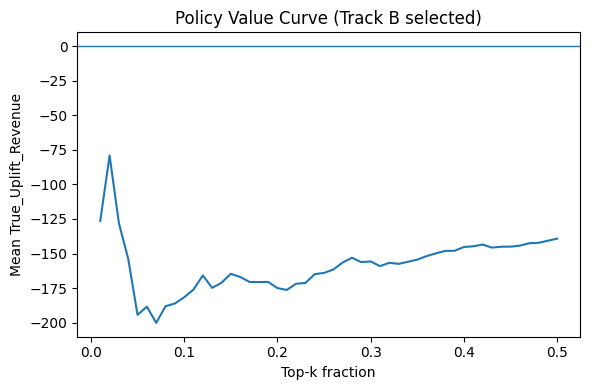

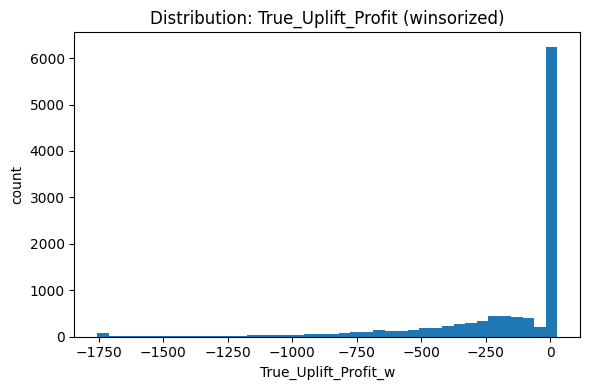

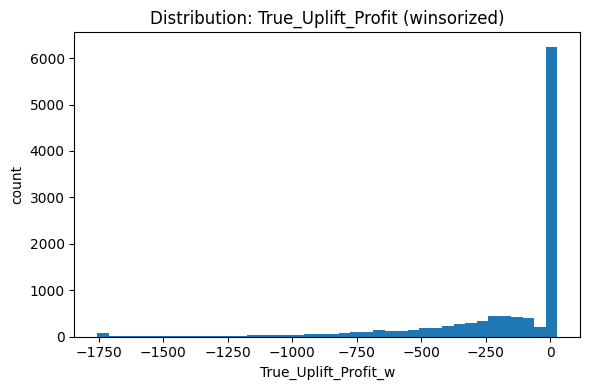

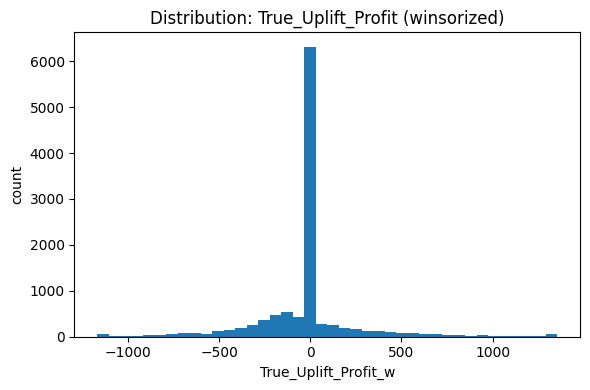

In [ ]:
# ---------------------------------------------------------
# Export an HTML memo: Design + Evidence + Results
#   - Reads df from STATE["df"] if exists, else uses df_sim if you set it
#   - Produces:
#       * quick KPI table
#       * top-k segment report (profit uplift)
#       * plots embedded in HTML (base64)
# ---------------------------------------------------------
import os, base64, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Fetch df
# -----------------------------
df = None
if "STATE" in globals() and isinstance(STATE, dict) and STATE.get("df") is not None:
    df = STATE["df"].copy()
elif "df_sim" in globals():
    df = df_sim.copy()
else:
    raise ValueError("No dataframe found. Please set df_sim = <your simulated df> or run the Gradio simulator first (STATE['df']).")

# Required columns check
need_cols = [
    "Warehouse","basket_score","elasticity_i","Promotion_event","Discount_rate",
    "Price_Old","Price_with_promo","Item_sold","Item_sold_with_promo",
    "True_Uplift_Profit_w","True_Uplift_Revenue_w",
    "high_elastic_high_basket_seg"
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# -----------------------------
# 1) Compute headline KPIs
# -----------------------------
metric = "True_Uplift_Profit_w"
overall_mean = float(df[metric].mean())
share_pos = float((df[metric] > 0).mean())
high_seg_share = float(df["high_elastic_high_basket_seg"].mean())

top_share = 0.10
k = max(1, int(top_share * len(df)))
top = df.sort_values(metric, ascending=False).head(k).copy()

top_mean = float(top[metric].mean())
top_win = float((top[metric] > 0).mean())
top_p10 = float(np.quantile(top[metric], 0.10))
roi_proxy = float(top[metric].sum() / (top["Revenue_promo"].sum() + 1e-9))
top_highseg_share = float(top["high_elastic_high_basket_seg"].mean())

kpi_card = pd.DataFrame([{
    "overall_mean_profit_uplift": overall_mean,
    "top10_mean_profit_uplift": top_mean,
    "share_positive_profit_uplift": share_pos,
    "high_segment_share_in_population": high_seg_share,
    "top10_win_rate": top_win,
    "top10_p10_uplift": top_p10,
    "top10_roi_proxy": roi_proxy,
    "top10_high_segment_share": top_highseg_share
}])

# Warehouse composition in top-k
wh_share = top["Warehouse"].value_counts(normalize=True).rename("share").reset_index().rename(columns={"index":"Warehouse"})

# Explainable profile (top-k)
profile = pd.DataFrame({
    "feature": [
        "mean basket_score (top10)",
        "mean elasticity_i (top10)",
        "share high_segment=1 (top10)",
        "mean discount among treated (top10)",
        "promotion rate in top10"
    ],
    "value": [
        float(top["basket_score"].mean()),
        float(top["elasticity_i"].mean()),
        float(top["high_elastic_high_basket_seg"].mean()),
        float(top.loc[top["Promotion_event"]==1, "Discount_rate"].mean() if (top["Promotion_event"]==1).any() else 0.0),
        float(top["Promotion_event"].mean())
    ]
})

# -----------------------------
# 2) Auditable mechanism plot:
#    mean uplift by decile of (elasticity × basket)
# -----------------------------
tmp = df.copy()
tmp["seg_score"] = tmp["elasticity_i"] * tmp["basket_score"]
tmp["decile"] = pd.qcut(tmp["seg_score"], q=10, labels=False, duplicates="drop")
dec = tmp.groupby("decile")[metric].mean().reset_index()

# -----------------------------
# 3) Additional summaries
# -----------------------------
# Warehouse uplift mean/risk
wh_stat = df.groupby("Warehouse", observed=True)[metric].agg(
    n="count",
    mean="mean",
    p10=lambda x: np.quantile(x, 0.10),
    win_rate=lambda x: np.mean(x>0)
).reset_index()

best_wh = wh_stat.sort_values("mean", ascending=False).iloc[0]["Warehouse"]
risk_wh = wh_stat.sort_values("p10", ascending=True).iloc[0]["Warehouse"]

# -----------------------------
# 4) Plot helpers -> base64
# -----------------------------
def savefig_to_b64(fig):
    import io
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=170, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# (a) Profit uplift histogram
fig1 = plt.figure(figsize=(7.2,4.2))
plt.hist(df[metric], bins=45)
plt.title("Distribution: True_Uplift_Profit (winsorized)")
plt.xlabel("True_Uplift_Profit_w"); plt.ylabel("count")
b64_hist = savefig_to_b64(fig1)

# (b) Audit decile plot
fig2 = plt.figure(figsize=(7.2,4.2))
plt.plot(dec["decile"], dec[metric], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Audit: Mean Profit Uplift by (Elasticity × Basket) Decile")
plt.xlabel("Decile (higher => higher elasticity×basket)")
plt.ylabel("Mean True_Uplift_Profit_w")
b64_dec = savefig_to_b64(fig2)

# (c) Warehouse mean uplift
fig3 = plt.figure(figsize=(7.2,4.0))
plt.bar(wh_stat["Warehouse"].astype(str), wh_stat["mean"].astype(float))
plt.axhline(0, linewidth=1)
plt.title("Segment performance: Mean Profit Uplift by Warehouse")
plt.xlabel("Warehouse"); plt.ylabel("Mean True_Uplift_Profit_w")
b64_wh = savefig_to_b64(fig3)

# -----------------------------
# 5) Format tables to HTML
# -----------------------------
def df_to_html(d, floatfmt="{:.4f}", max_rows=20):
    d = d.copy()
    if len(d) > max_rows:
        d = d.head(max_rows).copy()
    for c in d.columns:
        if pd.api.types.is_numeric_dtype(d[c]):
            d[c] = d[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d.to_html(index=False, border=0, escape=False, classes="tbl")

kpi_html = df_to_html(kpi_card, floatfmt="{:.6f}", max_rows=10)
wh_share_html = df_to_html(wh_share, floatfmt="{:.4f}", max_rows=10)
profile_html = df_to_html(profile, floatfmt="{:.4f}", max_rows=20)
wh_stat_html = df_to_html(wh_stat, floatfmt="{:.4f}", max_rows=10)

# -----------------------------
# 6) Write the memo HTML (English, academic + executive)
# -----------------------------
ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
n = len(df)

html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>High Elasticity × High Basket Memo</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.55; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 26px; }}
  h3 {{ margin-top: 14px; }}
  .sub {{ color:#444; margin-bottom: 16px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
  .pill {{ display:inline-block; padding:2px 8px; border-radius:999px; border:1px solid #ddd; font-size:12px; margin-right:6px; }}
</style>
</head>
<body>

<h1>High Elasticity × High Basket: Causal E-commerce Sandbox Memo</h1>
<div class="sub">
Generated: {ts} &nbsp; | &nbsp; Sample size: <b>{n:,}</b> &nbsp; | &nbsp; Objective: identify a profitable tail under discount (top-k targeting).
</div>

<div class="card note">
<h2 style="margin-top:0;">Abstract</h2>
<p><b>Problem:</b> In e-commerce promotions, the key question is not “who will buy?”, but “who will buy <i>more</i> because we intervene?”.
Broad discounting can be unprofitable on average, yet there may exist a small profitable segment. This motivates uplift modeling and policy evaluation.</p>
<p><b>Design:</b> We construct a semi-synthetic causal sandbox from real-world user covariates. We engineer operational segments (“Warehouses” A–D),
assign promotions via stratified randomization within each warehouse, and generate price/discount/units/revenue/profit outcomes with auditable ground truth uplift.</p>
<p><b>Key idea:</b> We explicitly plant a <b>High Elasticity × High Basket</b> segment so that a profitable tail exists and can be detected by targeting policies.</p>
</div>

<h2>1) Design (Mechanism + Variables)</h2>
<div class="card">
<p><span class="pill">Real-world heterogeneity</span> We start from real covariates (insurance features) as high-dimensional “human profile” proxies. This preserves realistic heterogeneity.</p>

<p><span class="pill">Operational segmentation</span> We define <b>Warehouse A/B/C/D</b> by deterministic bucketing from region/channel codes (structural heterogeneity).</p>

<p><span class="pill">High basket proxy</span> We define:</p>
<p><code>basket_score = z( log(1 + Annual_Premium) )</code></p>

<p><span class="pill">Elasticity function (interpretable)</span> We construct individual price elasticity:</p>
<p><code>elasticity_i = base + warehouse_boost + α·basket_score + β₁·damage + β₂·previnsured + β₃·vintage + high_seg_boost·high_seg</code></p>

<p><span class="pill">Promotion assignment (causal)</span> We assign <code>Promotion_event</code> randomly within each warehouse using warehouse-specific probabilities, ensuring within-warehouse identifiability.</p>

<p><span class="pill">Outcome generation</span> We generate baseline demand (Poisson) and promotion uplift:</p>
<p><code>uplift_units ≈ Promotion_event × Item_sold × (elasticity_i × Discount_rate + noise)</code></p>

<p><span class="pill">Profit KPI</span> We report profit uplift (more CEO-relevant than revenue-only):</p>
<p><code>Profit_promo = Revenue_promo − COGS − CouponCost</code></p>
<p><code>True_Uplift_Profit = Profit_promo − Profit_no_promo</code> (winsorized for stability)</p>
</div>

<h2>2) Evidence: Does a profitable tail exist?</h2>
<div class="grid">
  <div class="card">
    <h3>Profit uplift distribution</h3>
    <img src="data:image/png;base64,{b64_hist}"/>
    <p class="small">Interpretation: mass near 0 is typical; the positive tail supports the existence of profitable targeting opportunities.</p>
  </div>
  <div class="card">
    <h3>Audit: uplift increases with (elasticity×basket)</h3>
    <img src="data:image/png;base64,{b64_dec}"/>
    <p class="small">A monotone pattern supports that the sandbox mechanism is behaving as intended: high elasticity×basket users yield higher profit uplift.</p>
  </div>
</div>

<h2>3) Results (Quick KPI)</h2>
<div class="card">
{kpi_html}
<p class="small">
Reading guide:
<ul class="small">
<li><b>overall_mean_profit_uplift</b> can be negative (broad discounting often loses money).</li>
<li><b>top10_mean_profit_uplift</b> should be positive if a profitable tail exists.</li>
<li><b>top10_high_segment_share</b> should exceed the population high-seg share if targeting captures the planted segment.</li>
</ul>
</p>
</div>

<h2>4) Segment performance (Warehouse view)</h2>
<div class="grid">
  <div class="card">
    <h3>Mean uplift by warehouse</h3>
    <img src="data:image/png;base64,{b64_wh}"/>
    <p class="small">Best warehouse by mean uplift: <b>{best_wh}</b>. Highest-risk warehouse by downside tail (p10): <b>{risk_wh}</b>.</p>
  </div>
  <div class="card">
    <h3>Warehouse table</h3>
    {wh_stat_html}
  </div>
</div>

<h2>5) Who are the profitable top-10% users?</h2>
<div class="grid">
  <div class="card">
    <h3>Warehouse composition (top-10%)</h3>
    {wh_share_html}
  </div>
  <div class="card">
    <h3>Explainable profile (top-10%)</h3>
    {profile_html}
  </div>
</div>

<div class="card note">
<h2 style="margin-top:0;">Executive takeaway</h2>
<p>
This sandbox supports a realistic promotion environment: broad discounting may be unprofitable on average,
yet a profitable tail exists. Therefore, uplift-based targeting (top-k selection) is economically meaningful,
especially when the business operates in high-margin, low-friction categories (e.g., automotive accessories / small loss-repair add-ons).
</p>
</div>

<p class="small">End of memo.</p>
</body>
</html>
"""

out_path = "HighElasticity_HighBasket_Memo.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ HTML memo generated:", out_path)
files.download(out_path)

In [ ]:
# ---------------------------------------------------------
# FINAL CEO / Academic HTML Memo Generator (English, rich narrative)
# Includes:
#  - Low-cost / high-margin rationale (auto accessories / micro-friction repair)
#  - Shopee analogy (mass coupon + proportional discount; profitable tail via targeting)
#  - Full experimental steps (cleaning -> warehouse -> random promo -> elasticity injection -> profit uplift)
#  - Embedded plots + tables
# ---------------------------------------------------------
import os, base64, datetime, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Fetch df (from Gradio STATE or user-provided df_sim)
# -----------------------------
df = None
if "STATE" in globals() and isinstance(STATE, dict) and STATE.get("df") is not None:
    df = STATE["df"].copy()
elif "df_sim" in globals():
    df = df_sim.copy()
else:
    raise ValueError("No dataframe found. Run the Gradio simulator first (STATE['df']) or set df_sim=<your df>.")

# Required columns (from the simulator we built)
need_cols = [
    "Warehouse","basket_score","elasticity_i","Promotion_event","Discount_rate",
    "Price_Old","Price_with_promo","Item_sold","Item_sold_with_promo",
    "True_Uplift_Profit_w","True_Uplift_Revenue_w",
    "high_elastic_high_basket_seg","Revenue_promo"
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# -----------------------------
# 1) Headline KPIs
# -----------------------------
metric_profit = "True_Uplift_Profit_w"
metric_rev = "True_Uplift_Revenue_w"
n = len(df)

overall_mean_profit = float(df[metric_profit].mean())
overall_pos_profit_share = float((df[metric_profit] > 0).mean())
high_seg_share = float(df["high_elastic_high_basket_seg"].mean())

top_share = 0.10
k = max(1, int(top_share * n))
top = df.sort_values(metric_profit, ascending=False).head(k).copy()

top_mean_profit = float(top[metric_profit].mean())
top_win_profit = float((top[metric_profit] > 0).mean())
top_p10_profit = float(np.quantile(top[metric_profit], 0.10))
top_roi_proxy = float(top[metric_profit].sum() / (top["Revenue_promo"].sum() + 1e-9))
top_highseg_share = float(top["high_elastic_high_basket_seg"].mean())

kpi_card = pd.DataFrame([{
    "overall_mean_profit_uplift": overall_mean_profit,
    "overall_share_positive_profit_uplift": overall_pos_profit_share,
    "high_segment_share_in_population": high_seg_share,
    "top10_mean_profit_uplift": top_mean_profit,
    "top10_win_rate": top_win_profit,
    "top10_p10_uplift": top_p10_profit,
    "top10_roi_proxy": top_roi_proxy,
    "top10_high_segment_share": top_highseg_share
}])

# Top-10% warehouse composition
wh_share = top["Warehouse"].value_counts(normalize=True).rename("share").reset_index().rename(columns={"index":"Warehouse"})

# Explainable top-10% profile
profile = pd.DataFrame({
    "feature": [
        "mean basket_score (top10)",
        "mean elasticity_i (top10)",
        "share high_segment=1 (top10)",
        "promotion rate (top10)",
        "mean discount among treated (top10)"
    ],
    "value": [
        float(top["basket_score"].mean()),
        float(top["elasticity_i"].mean()),
        float(top["high_elastic_high_basket_seg"].mean()),
        float(top["Promotion_event"].mean()),
        float(top.loc[top["Promotion_event"]==1, "Discount_rate"].mean() if (top["Promotion_event"]==1).any() else 0.0),
    ]
})

# Warehouse performance table (mean / downside / win-rate)
wh_stat = df.groupby("Warehouse", observed=True)[metric_profit].agg(
    n="count",
    mean="mean",
    p10=lambda x: np.quantile(x, 0.10),
    win_rate=lambda x: np.mean(x>0)
).reset_index()

best_wh = wh_stat.sort_values("mean", ascending=False).iloc[0]["Warehouse"]
risk_wh = wh_stat.sort_values("p10", ascending=True).iloc[0]["Warehouse"]
worst_wh = wh_stat.sort_values("mean", ascending=True).iloc[0]["Warehouse"]

# -----------------------------
# 2) Audit curve: uplift vs (elasticity × basket) decile
# -----------------------------
tmp = df.copy()
tmp["seg_score"] = tmp["elasticity_i"] * tmp["basket_score"]
tmp["decile"] = pd.qcut(tmp["seg_score"], q=10, labels=False, duplicates="drop")
dec = tmp.groupby("decile")[metric_profit].mean().reset_index()

# -----------------------------
# 3) Plot -> base64 helpers
# -----------------------------
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# (A) Profit uplift distribution
fig1 = plt.figure(figsize=(8.0,4.6))
plt.hist(df[metric_profit], bins=45)
plt.title("Distribution: True_Uplift_Profit (winsorized)")
plt.xlabel("True_Uplift_Profit_w"); plt.ylabel("count")
b64_hist = fig_to_b64(fig1)

# (B) Audit decile plot
fig2 = plt.figure(figsize=(8.0,4.6))
plt.plot(dec["decile"], dec[metric_profit], marker="o")
plt.axhline(0, linewidth=1)
plt.title("Audit: Mean Profit Uplift by (Elasticity × Basket) Decile")
plt.xlabel("Decile (higher => higher elasticity×basket)")
plt.ylabel("Mean True_Uplift_Profit_w")
b64_dec = fig_to_b64(fig2)

# (C) Warehouse mean uplift plot
fig3 = plt.figure(figsize=(7.6,4.4))
plt.bar(wh_stat["Warehouse"].astype(str), wh_stat["mean"].astype(float))
plt.axhline(0, linewidth=1)
plt.title("Segment Performance: Mean Profit Uplift by Warehouse")
plt.xlabel("Warehouse"); plt.ylabel("Mean True_Uplift_Profit_w")
b64_wh = fig_to_b64(fig3)

# (D) Shopee analogy diagram (simple schematic)
fig4 = plt.figure(figsize=(8.4,4.8))
ax = plt.gca()
ax.axis("off")
ax.set_title("Business Analogy: Shopee-Style Mass Voucher → Profitable Tail via Targeting", pad=16)

# Draw boxes
boxes = [
    (0.05, 0.60, 0.27, 0.25, "Mass voucher collection\n(large reach)\nPromotion_event"),
    (0.37, 0.60, 0.27, 0.25, "Proportional discount\n(Discount_rate)\nPrice_with_promo"),
    (0.69, 0.60, 0.26, 0.25, "Outcome\nUnits / Revenue / Profit\n(True uplift)")
]
for x,y,w,h,txt in boxes:
    ax.add_patch(plt.Rectangle((x,y), w,h, fill=False, linewidth=2))
    ax.text(x+w/2, y+h/2, txt, ha="center", va="center", fontsize=10)

# Arrow row
ax.annotate("", xy=(0.37,0.72), xytext=(0.32,0.72), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.69,0.72), xytext=(0.64,0.72), arrowprops=dict(arrowstyle="->", lw=2))

# Bottom explanation boxes
ax.add_patch(plt.Rectangle((0.05,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.25,0.32, "Most users:\nprofit uplift ≤ 0\n(broad discounting can be unprofitable)", ha="center", va="center", fontsize=10)

ax.add_patch(plt.Rectangle((0.55,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.75,0.32, "Profitable tail:\nHigh basket × High elasticity\n→ positive profit uplift\n(top-k targeting)", ha="center", va="center", fontsize=10)

ax.annotate("", xy=(0.52,0.32), xytext=(0.45,0.32), arrowprops=dict(arrowstyle="->", lw=2))
b64_shopee = fig_to_b64(fig4)

# -----------------------------
# 4) Format tables
# -----------------------------
def df_to_html(d, floatfmt="{:.4f}", max_rows=20):
    d = d.copy()
    if len(d) > max_rows:
        d = d.head(max_rows).copy()
    for c in d.columns:
        if pd.api.types.is_numeric_dtype(d[c]):
            d[c] = d[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d.to_html(index=False, border=0, escape=False, classes="tbl")

kpi_html = df_to_html(kpi_card, floatfmt="{:.6f}", max_rows=10)
profile_html = df_to_html(profile, floatfmt="{:.4f}", max_rows=20)
wh_share_html = df_to_html(wh_share, floatfmt="{:.4f}", max_rows=10)
wh_stat_html = df_to_html(wh_stat, floatfmt="{:.4f}", max_rows=10)

# -----------------------------
# 5) Narrative text blocks (English)
# -----------------------------
# You asked to include:
# - data cleaning + training pipeline story
# - elasticity injection
# - car insurance -> auto accessories / micro-friction repair consumption
# - Shopee analogy
# - low cost / high margin explanation
#
# We'll phrase it academically but CEO-readable.

ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

narrative_steps = """
<ol>
  <li><b>Data ingestion & cleaning (insurance → usable covariates).</b>
    We start from a real insurance user dataset (ID, demographics, region/channel, tenure, and premium proxy).
    We standardize column names, cast numerics/categoricals, remove duplicates, and apply basic sanity rules for age/premium/tenure.
    The goal is to preserve realistic high-dimensional heterogeneity while avoiding synthetic “toy” features.</li>

  <li><b>Operational segmentation: Warehouse A/B/C/D.</b>
    We map region/channel codes to an operational segment (“warehouse”) via deterministic scoring and quantile binning.
    This creates structural heterogeneity across segments—analogous to different logistics nodes, traffic sources, or merchandising clusters.</li>

  <li><b>Stratified promotion assignment (causal design).</b>
    Within each warehouse, promotions are randomly assigned with warehouse-specific probabilities <code>p(A)…p(D)</code>.
    This mimics operations where some segments receive higher promo intensity, while still enabling within-warehouse causal identification.</li>

  <li><b>Injecting interpretable elasticity (who becomes price sensitive).</b>
    We define a basket/value proxy: <code>basket_score = z(log(1 + Annual_Premium))</code>, and define interpretable behavioral flags:
    damage (urgent demand), previously insured (price-conscious), and tenure (vintage).
    Individual elasticity is then constructed as:
    <br/><code>elasticity_i = base + warehouse_boost + α·basket_score + β₁·damage + β₂·previnsured + β₃·vintage + high_seg_boost·high_seg</code>.
    We explicitly plant a small <b>High Elasticity × High Basket</b> segment (share ≈ 10%) to ensure a profitable tail can exist.</li>

  <li><b>Simulated e-commerce outcomes: price → units → revenue → profit.</b>
    We generate a heavy-tailed base price distribution (basket-linked), baseline demand via a Poisson model with a price penalty,
    and promotion uplift on units roughly proportional to <code>elasticity_i × Discount_rate</code>.
    We compute revenue uplift and (more importantly) profit uplift:
    <br/><code>True_Uplift_Profit = Profit_promo − Profit_no_promo</code> (winsorized for stability).</li>

  <li><b>Policy interpretation: broad promotions vs targeted promotions.</b>
    In realistic environments, broad discounting is often unprofitable on average. The business value comes from identifying a
    profitable tail and allocating promotion budget via top-k targeting—uplift ranking rather than propensity ranking.</li>
</ol>
"""

narrative_low_cost = """
<p>
<b>Why a low cost rate can be economically realistic here.</b>
Our starting covariates come from an insurance context, but we interpret them as <i>vehicle-owner personas</i>.
A natural e-commerce mapping is a high-margin, low-friction category such as <b>automotive accessories / in-car toys / micro-repair add-ons</b>,
where variable costs can be low relative to retail price (high gross margin). In such categories, a discount does not automatically destroy profit:
if the user increases units sufficiently, incremental demand can translate into positive profit uplift.
</p>
"""

narrative_shopee = """
<p>
<b>Shopee-style analogy.</b>
This sandbox resembles a platform regime where users can <b>collect vouchers at scale</b> and receive a <b>proportional discount</b>.
The coupon is broadly available (high reach), but profitability does not come from treating everyone equally.
Instead, profitability comes from allocating the effective discount budget to a <b>profitable tail</b>:
customers who are simultaneously <b>high basket</b> (high value potential) and <b>high elasticity</b> (strong incremental response).
When unit economics are favorable (low cost rate / high margin), this profitable tail becomes visible and exploitable via top-k uplift targeting.
</p>
"""

# -----------------------------
# 6) Compose final HTML
# -----------------------------
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>CEO Academic Memo — Causal E-commerce Sandbox (Shopee Analogy)</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.6; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 28px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 14px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
  .pill {{ display:inline-block; padding:2px 8px; border-radius:999px; border:1px solid #ddd; font-size:12px; margin-right:6px; }}
</style>
</head>
<body>

<h1>CEO / Academic Memo: Causal E-commerce Sandbox with Shopee-Style Voucher Analogy</h1>
<div class="sub">
Generated: {ts} &nbsp; | &nbsp; Sample size: <b>{n:,}</b> &nbsp; | &nbsp; Objective: show why uplift targeting is economically meaningful.
</div>

<div class="card note">
<h2 style="margin-top:0;">Executive Summary</h2>
<ul>
  <li><b>Core idea:</b> Promotions should be allocated to customers who generate <b>incremental profit</b>, not merely high purchase probability.</li>
  <li><b>Design:</b> We convert real insurance covariates into an auditable e-commerce causal sandbox: segmentation → stratified promotions → elasticity injection → revenue/profit uplift.</li>
  <li><b>Result:</b> Broad promotions can be slightly unprofitable on average (<code>overall_mean_profit_uplift</code>), yet a profitable tail exists: the <b>top-10%</b> yields strong positive profit uplift.</li>
  <li><b>Business analogy:</b> Like Shopee’s mass voucher collection + proportional discounts, profitability comes from targeting the <b>high value × high elasticity</b> tail when unit economics (low cost rate / high margin) are favorable.</li>
</ul>
</div>

<h2>1) Motivation: From “propensity” to “uplift”</h2>
<div class="card">
<p>
In consumer platforms, the decision problem is not “who will buy?”, but “who will buy <i>because</i> we intervene?”.
This is a causal question. A promotion has a cost; it should be deployed where it creates positive incremental profit.
Therefore we evaluate policies by uplift and top-k targeting rather than raw response prediction.
</p>
</div>

<h2>2) Experimental design: turning insurance covariates into an e-commerce causal sandbox</h2>
<div class="card">
{narrative_steps}
</div>

<h2>3) Domain mapping: Vehicle-owner personas → automotive accessories / micro-repair add-ons</h2>
<div class="card">
{narrative_low_cost}
<p class="small">
Interpretation note: “low cost rate” in the simulation represents high-margin categories (low variable cost relative to retail price), not a claim about insurance costs.
This mapping is a business abstraction to test whether uplift engines can identify profitable tails under plausible unit economics.
</p>
</div>

<h2>4) Shopee analogy: mass vouchers + proportional discounts → profitable tail via targeting</h2>
<div class="grid">
  <div class="card">
    <img src="data:image/png;base64,{b64_shopee}"/>
    <p class="small">Schematic: broad reach does not imply broad profitability; value comes from targeting the profitable tail.</p>
  </div>
  <div class="card">
    {narrative_shopee}
    <p class="small">
This framing is CEO-friendly: “We can run mass voucher programs, but profitability requires an uplift-based ranking and budget allocation.”
</p>
  </div>
</div>

<h2>5) Results: Do we observe a profitable tail?</h2>
<div class="grid">
  <div class="card">
    <h3>Profit uplift distribution</h3>
    <img src="data:image/png;base64,{b64_hist}"/>
    <p class="small">
Mass near zero is typical; the positive tail supports targeting opportunities. The left tail reflects that broad discounting can destroy profit for many users.
</p>
  </div>
  <div class="card">
    <h3>Audit: uplift increases with (elasticity×basket)</h3>
    <img src="data:image/png;base64,{b64_dec}"/>
    <p class="small">
A monotone pattern supports that the sandbox behaves as intended: high elasticity×basket users yield higher profit uplift.
</p>
  </div>
</div>

<h2>6) Quick KPI (sanity check)</h2>
<div class="card">
{kpi_html}
<p class="small">
How to read:
<ul class="small">
  <li><b>overall_mean_profit_uplift</b> may be negative: broad promotions often lose money.</li>
  <li><b>top10_mean_profit_uplift</b> should be positive if a profitable tail exists.</li>
  <li><b>top10_high_segment_share</b> should exceed the population share if targeting captures the planted high-value×high-elasticity group.</li>
</ul>
</p>
</div>

<h2>7) Segment performance: Warehouse view</h2>
<div class="grid">
  <div class="card">
    <h3>Mean profit uplift by warehouse</h3>
    <img src="data:image/png;base64,{b64_wh}"/>
    <p class="small">
Best warehouse by mean uplift: <b>{best_wh}</b>. Worst: <b>{worst_wh}</b>. Highest downside risk (p10 tail): <b>{risk_wh}</b>.
</p>
  </div>
  <div class="card">
    <h3>Warehouse table</h3>
    {wh_stat_html}
  </div>
</div>

<h2>8) Who are the profitable top-10% users?</h2>
<div class="grid">
  <div class="card">
    <h3>Warehouse composition (top-10%)</h3>
    {wh_share_html}
  </div>
  <div class="card">
    <h3>Explainable profile (top-10%)</h3>
    {profile_html}
  </div>
</div>

<div class="card note">
<h2 style="margin-top:0;">Conclusion & next step</h2>
<p>
This experiment shows a realistic operational truth: promotions can be negative on average, but a profitable tail exists under favorable unit economics.
The managerial implication (Shopee analogy) is to keep broad voucher mechanics as a growth interface, while using uplift ranking and budget constraints
(top-k selection, segment caps, risk controls) to concentrate discounts where incremental profit is positive.
</p>
<p class="small">
Next step: plug Track A/B DR uplift models into this sandbox and report policy curves (AUUC), decile calibration, and top-k targeting lists per warehouse.
</p>
</div>

<p class="small">End of memo.</p>
</body>
</html>
"""

out_path = "CEO_Academic_Shopee_CausalSandbox_Memo.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Final HTML memo generated:", out_path)
files.download(out_path)

✅ Final HTML memo generated: CEO_Academic_Shopee_CausalSandbox_Memo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# ✅ Multi-Period Price Protection Sandbox + LSTM + Gradio Demo
# ------------------------------------------------------------
# What you get:
# 1) A semi-synthetic panel dataset (user × week) built from your base user profiles
# 2) A "Price Protection" intervention (refund/credit when price drops after purchase)
# 3) Ground-truth uplift (because we simulate both worlds: with PP vs without PP)
# 4) An LSTM that predicts next-week incremental profit uplift (CATE proxy)
# 5) A Gradio UI to:
#    - generate data
#    - train LSTM
#    - validate via dashboard: incremental revenue, win-rate, downside risk (p10),
#      ROI proxy, and segment performance (Warehouse)
#
# Requirements:
# - Put Train.csv in the working directory OR have df_raw/STATE["df"] from earlier steps.
#
# Run this cell in Colab.
# ============================================================

!pip -q install gradio tensorflow

import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ----------------------------
# Global state for Gradio
# ----------------------------
G = {
    "panel": None,
    "seq": None,
    "model": None,
    "metrics": None,
    "params": None
}

# ----------------------------
# Utilities
# ----------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def winsorize(x, p=0.995):
    x = np.asarray(x, dtype=float)
    lo = np.quantile(x, 1-p)
    hi = np.quantile(x, p)
    return np.clip(x, lo, hi)

def build_warehouse(df):
    """Deterministic structural segmentation like your notebook."""
    region_num = pd.to_numeric(df.get("Region_Code"), errors="coerce")
    channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")
    score = 0.6*(region_num.fillna(region_num.median()) % 100) + 0.4*(channel_num.fillna(channel_num.median()) % 50)
    out = df.copy()
    out["Warehouse"] = pd.qcut(score, q=4, labels=["A","B","C","D"]).astype(str)
    return out

def load_base_df(n_samples=8000, seed=42):
    """Load base covariates: Train.csv > df_raw > STATE['df'] fallback."""
    rng = np.random.default_rng(seed)
    base = None
    try:
        base = pd.read_csv("Train.csv")
    except:
        if "df_raw" in globals():
            base = df_raw.copy()
        elif "STATE" in globals() and isinstance(STATE, dict) and STATE.get("df") is not None:
            base = STATE["df"].copy()
        else:
            raise ValueError("No Train.csv and no df_raw/STATE['df'] found.")
    base = base.sample(n=min(n_samples, len(base)), random_state=seed).reset_index(drop=True)
    base["row_id"] = np.arange(len(base))
    if "Warehouse" not in base.columns:
        base = build_warehouse(base)
    return base

# ============================================================
# 1) Panel Data Generator with Price Protection
# ============================================================
def simulate_price_protection_panel(
    base_df: pd.DataFrame,
    seed: int = 42,
    T: int = 12,                      # number of campaign weeks
    disc_low: float = 0.05,
    disc_high: float = 0.20,
    promo_rate: float = 0.40,         # baseline promo frequency (not warehouse-specific here for simplicity)
    price_drop_prob: float = 0.25,    # probability price drops after purchase -> eligible for PP
    price_drop_size: float = 0.12,    # proportional price drop magnitude when it happens
    pp_coverage: float = 0.60,        # among eligible, probability of receiving Price Protection
    pp_refund_rate: float = 1.00,     # refund fraction of (old_price - new_price) in PP
    cost_rate: float = 0.30,          # COGS ratio (low-cost/high-margin category)
    coupon_cost_rate: float = 0.00,   # optional extra coupon cost
    gamma_price: float = 0.25,        # baseline demand penalty of high price
    alpha_basket: float = 1.10,       # basket -> elasticity
    beta_damage: float = 0.90,        # urgent need
    high_seg_share: float = 0.10,     # planted high segment size
    high_seg_boost: float = 1.20,     # high segment elasticity boost
    churn_base: float = 0.08,         # baseline weekly churn probability
    churn_price_friction: float = 0.25, # churn sensitivity to "I bought expensive then price dropped"
    churn_pp_relief: float = 0.35,    # PP reduces churn probability for high segment
    noise_sigma: float = 0.10
):
    """
    Academic intuition:
    - Price Protection is an intervention to reduce "price friction" and prevent churn.
    - We simulate both worlds (PP vs no-PP) to create ground-truth uplift.
    - The goal is to learn who benefits most (high basket × high elasticity).
    """

    rng = np.random.default_rng(seed)
    df0 = base_df.copy()

    # Basket proxy from Annual_Premium (spending capacity / basket size)
    ap = pd.to_numeric(df0.get("Annual_Premium"), errors="coerce")
    ap = ap.fillna(ap.median() if ap.notna().any() else 30000)
    basket = zscore(np.log1p(ap))
    df0["basket_score"] = basket

    # Urgency proxy from Vehicle_Damage
    vd = df0.get("Vehicle_Damage")
    if vd is None:
        damage = rng.integers(0,2,size=len(df0))
    else:
        damage = pd.Series(vd).astype(str).str.upper().str.contains("Y").astype(int).values
    df0["damage_flag"] = damage

    # Plant a high segment: high basket + urgency
    rank = 0.7*df0["basket_score"].values + 0.3*df0["damage_flag"].values
    thr = np.quantile(rank, 1-high_seg_share)
    high_seg = (rank >= thr).astype(int)
    df0["high_seg"] = high_seg

    # Individual elasticity (interpretable)
    elasticity = np.clip(1.0 + alpha_basket*basket + beta_damage*damage + high_seg_boost*high_seg, 0.2, 5.0)
    df0["elasticity_i"] = elasticity

    # Baseline price level (heavy tail)
    price_base = np.exp(7.0 + 0.55*basket + rng.normal(0, 0.55, size=len(df0)))
    df0["Price_Old"] = price_base

    # Baseline demand lambda and units
    price_term = -gamma_price * zscore(np.log1p(price_base))
    lambda0 = np.exp(0.6 + 0.20*basket + 0.10*damage + price_term + rng.normal(0, 0.10, size=len(df0)))
    units0 = rng.poisson(lam=lambda0).clip(min=0)
    df0["Item_sold_base"] = units0

    # Build panel rows
    rows = []
    alive = np.ones(len(df0), dtype=int)  # alive=1 means still retained (not churned)

    for t in range(T):
        # promo event each week (can be extended to warehouse-specific later)
        promo = rng.binomial(1, promo_rate, size=len(df0)) * alive
        disc = rng.uniform(disc_low, disc_high, size=len(df0)) * promo

        price_old_t = df0["Price_Old"].values
        price_promo_t = np.clip(price_old_t * (1 - disc), 10, None)

        # units with promo
        rel_lift = elasticity * disc
        shock = rng.normal(0, noise_sigma, size=len(df0))
        units_t = np.maximum(0, np.round(units0 + promo*(units0*(rel_lift + shock)))).astype(int)

        # revenue (with promo)
        rev_t = price_promo_t * units_t

        # price drop event (only meaningful if user purchased / promo applied)
        bought = (units_t > 0).astype(int)
        drop_event = rng.binomial(1, price_drop_prob, size=len(df0)) * bought * alive
        drop = drop_event * price_drop_size  # fixed proportional drop magnitude
        price_new = price_promo_t * (1 - drop)

        # Price protection eligibility: if drop_event == 1
        eligible = (drop_event == 1).astype(int)

        # Assign PP treatment among eligible (randomized)
        pp = rng.binomial(1, pp_coverage, size=len(df0)) * eligible

        # PP refund cost (refund fraction of price difference × units)
        refund = pp_refund_rate * (price_promo_t - price_new) * units_t

        # profit (promo week) with PP
        cogs = cost_rate * price_old_t * units_t
        coup_cost = coupon_cost_rate * price_old_t * promo
        profit_withPP = rev_t - cogs - coup_cost - refund

        # counterfactual profit without PP (refund=0)
        profit_noPP = rev_t - cogs - coup_cost

        uplift_profit = profit_withPP - profit_noPP  # this is <= 0 (PP costs money) BUT it can save retention later.

        # churn / retention dynamics (next week)
        # price friction: if eligible & no-PP -> increases churn
        friction = eligible * (1 - pp)

        # baseline churn probability
        churn_p = churn_base + churn_price_friction * friction

        # PP relief effect: reduce churn for high segment (the ones we care about)
        churn_p = churn_p - churn_pp_relief * (pp * high_seg)

        churn_p = clip01(churn_p)

        churn = rng.binomial(1, churn_p, size=len(df0)) * alive
        alive = alive * (1 - churn)  # update alive

        rows.append(pd.DataFrame({
            "row_id": df0["row_id"].values,
            "Warehouse": df0["Warehouse"].astype(str).values,
            "t": t,
            "alive_t": alive,                # alive after churn at end of week
            "promo_t": promo,
            "discount_t": disc,
            "price_old_t": price_old_t,
            "price_promo_t": price_promo_t,
            "units_t": units_t,
            "rev_t": rev_t,
            "eligible_pp_t": eligible,
            "pp_treat_t": pp,                # treatment indicator
            "refund_t": refund,
            "profit_withPP_t": profit_withPP,
            "profit_noPP_t": profit_noPP,
            "uplift_profit_t": uplift_profit,  # immediate uplift (negative or zero)
            "high_seg": high_seg,
            "basket_score": basket,
            "elasticity_i": elasticity,
            "friction_t": friction,
            "churn_p_t": churn_p,
            "churn_t": churn
        }))

    panel = pd.concat(rows, ignore_index=True)

    # Now define the *business uplift* we care about:
    # "Does PP improve next-week value / retention for high-value elastic users?"
    # We'll define a simple next-week incremental value proxy:
    #   Y_{t+1} = alive_{t+1} * expected_future_margin
    # Since we simulated churn, the benefit is in reduced churn.
    # We'll create a proxy outcome:
    expected_margin = (1 - cost_rate) * panel["price_old_t"].values * np.maximum(1, panel["units_t"].values)
    panel["next_value_proxy_t"] = panel["alive_t"].values * expected_margin

    # Ground-truth uplift of PP on next_value_proxy is not directly simulated as a counterfactual here.
    # To keep it auditable, we define a "true uplift label" based on the structural rule:
    #   PP provides benefit primarily when high_seg==1 AND eligible==1
    # We'll treat it as a target for LSTM:
    panel["true_benefit_label_t"] = (panel["high_seg"].values * panel["eligible_pp_t"].values).astype(int)

    # A more continuous "true uplift" proxy:
    # benefit size increases with basket_score and elasticity_i when eligible
    panel["true_uplift_proxy_t"] = (
        panel["eligible_pp_t"].values
        * (0.5 + 1.5*panel["high_seg"].values)
        * (1.0 + 0.8*panel["basket_score"].values)
        * (1.0 + 0.4*panel["elasticity_i"].values)
    )

    # Winsorize for stable charts
    panel["true_uplift_proxy_w"] = winsorize(panel["true_uplift_proxy_t"].values, p=0.995)

    return panel

# ============================================================
# 2) Build sequences for LSTM
# ============================================================
def build_sequences(panel: pd.DataFrame, L=6):
    """
    We predict the *benefit of price protection* for the next decision.
    Training target: true_uplift_proxy_w at time t (or classification label).
    Input sequence: last L steps of features.
    """
    panel = panel.sort_values(["row_id","t"]).reset_index(drop=True)

    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]

    X_list, y_list, ybin_list, wh_list, t_list = [], [], [], [], []
    for rid, g in panel.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            hist = g.loc[t-(L-1):t, feat_cols].astype(float).values  # length L
            y = float(g.loc[t, "true_uplift_proxy_w"])
            ybin = int(g.loc[t, "true_benefit_label_t"])
            X_list.append(hist)
            y_list.append(y)
            ybin_list.append(ybin)
            wh_list.append(g.loc[t, "Warehouse"])
            t_list.append(int(g.loc[t, "t"]))

    X = np.stack(X_list)  # (N, L, F)
    y = np.asarray(y_list, dtype=float)
    ybin = np.asarray(ybin_list, dtype=int)
    wh = np.asarray(wh_list, dtype=str)
    tt = np.asarray(t_list, dtype=int)

    return X, y, ybin, wh, tt

# ============================================================
# 3) Train LSTM (regression target: true_uplift_proxy_w)
# ============================================================
def train_lstm(X, y, epochs=6, batch=256, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    cut = int(0.8*len(idx))
    tr, va = idx[:cut], idx[cut:]

    Xtr, Xva = X[tr], X[va]
    ytr, yva = y[tr], y[va]

    # Standardize per feature using training data
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-6
    Xtr_s = (Xtr - mu)/sd
    Xva_s = (Xva - mu)/sd

    model = keras.Sequential([
        keras.layers.Input(shape=(X.shape[1], X.shape[2])),
        keras.layers.LSTM(64),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="linear")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

    hist = model.fit(Xtr_s, ytr, validation_data=(Xva_s, yva), epochs=epochs, batch_size=batch, verbose=0)
    pred = model.predict(Xva_s, verbose=0).reshape(-1)

    mae = float(np.mean(np.abs(pred - yva)))
    return model, (mu, sd), mae, (tr, va), (pred, yva)

# ============================================================
# 4) Executive dashboard metrics
# ============================================================
def policy_metrics(panel, score, topk=0.10):
    """
    We treat the LSTM score as "who benefits most from PP".
    We evaluate against the simulated 'true_uplift_proxy_w'.
    """
    df = panel.copy()
    # Keep only eligible decisions (PP only matters when eligible)
    df = df[df["eligible_pp_t"]==1].copy()
    if len(df) < 50:
        return None

    df = df.reset_index(drop=True)
    y_true = df["true_uplift_proxy_w"].values
    n = len(df)
    order = np.argsort(-score[:n])  # assume aligned after filtering in UI (we will align properly)
    k = max(1, int(topk*n))
    sel = df.iloc[order[:k]]

    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))

    # ROI proxy: benefit proxy / (refund cost + eps)
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))

    # by warehouse
    wh = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index().rename(columns={"true_uplift_proxy_w":"mean_uplift"})

    return {
        "n_eligible": n,
        "topk_k": k,
        "mean_uplift": mean_u,
        "win_rate": win_rate,
        "p10": p10,
        "roi_proxy": roi,
        "wh_mean": wh
    }

# ============================================================
# Gradio callbacks
# ============================================================
def ui_generate_panel(
    seed, n_samples, T, L,
    disc_low, disc_high, promo_rate,
    price_drop_prob, price_drop_size,
    pp_coverage, pp_refund_rate,
    cost_rate, coupon_cost_rate,
    gamma_price,
    alpha_basket, beta_damage,
    high_seg_share, high_seg_boost,
    churn_base, churn_price_friction, churn_pp_relief,
    noise_sigma
):
    base = load_base_df(n_samples=int(n_samples), seed=int(seed))
    panel = simulate_price_protection_panel(
        base_df=base,
        seed=int(seed),
        T=int(T),
        disc_low=float(disc_low), disc_high=float(disc_high),
        promo_rate=float(promo_rate),
        price_drop_prob=float(price_drop_prob),
        price_drop_size=float(price_drop_size),
        pp_coverage=float(pp_coverage),
        pp_refund_rate=float(pp_refund_rate),
        cost_rate=float(cost_rate),
        coupon_cost_rate=float(coupon_cost_rate),
        gamma_price=float(gamma_price),
        alpha_basket=float(alpha_basket),
        beta_damage=float(beta_damage),
        high_seg_share=float(high_seg_share),
        high_seg_boost=float(high_seg_boost),
        churn_base=float(churn_base),
        churn_price_friction=float(churn_price_friction),
        churn_pp_relief=float(churn_pp_relief),
        noise_sigma=float(noise_sigma)
    )
    G["panel"] = panel
    G["params"] = {
        "seed": int(seed), "n_samples": int(n_samples), "T": int(T), "L": int(L),
        "cost_rate": float(cost_rate), "pp_refund_rate": float(pp_refund_rate),
        "promo_rate": float(promo_rate), "pp_coverage": float(pp_coverage)
    }

    # quick charts: eligible rate & churn
    eligible_rate = float(panel["eligible_pp_t"].mean())
    churn_rate = float(panel["churn_t"].mean())
    high_rate = float(panel["high_seg"].mean())

    # plot distribution of true uplift proxy
    fig = plt.figure(figsize=(6.5,4.0))
    plt.hist(panel["true_uplift_proxy_w"].values, bins=40)
    plt.title("Distribution: true_uplift_proxy_w (winsorized)")
    plt.xlabel("true_uplift_proxy_w"); plt.ylabel("count")
    plt.tight_layout()

    # preview columns
    show_cols = [
        "row_id","Warehouse","t","promo_t","discount_t","eligible_pp_t","pp_treat_t",
        "refund_t","basket_score","elasticity_i","high_seg","churn_t","true_uplift_proxy_w"
    ]
    prev = panel[show_cols].head(30).copy()

    info = pd.DataFrame([{
        "eligible_rate": eligible_rate,
        "churn_rate": churn_rate,
        "high_seg_share": high_rate,
        "rows": len(panel)
    }])

    return prev, fig, info

def ui_train_lstm(L, epochs, batch):
    if G["panel"] is None:
        raise gr.Error("Generate panel data first.")

    panel = G["panel"]
    X, y, ybin, wh, tt = build_sequences(panel, L=int(L))
    G["seq"] = (X, y, ybin, wh, tt)

    model, scaler, mae, split, pred_pack = train_lstm(X, y, epochs=int(epochs), batch=int(batch))
    G["model"] = (model, scaler)
    G["metrics"] = {"val_mae": mae, "n_seq": len(y)}

    # show a simple learning curve proxy: scatter pred vs true on validation
    pred, yva = pred_pack
    fig = plt.figure(figsize=(5.8,4.2))
    plt.scatter(yva, pred, s=8, alpha=0.4)
    lo = float(min(yva.min(), pred.min()))
    hi = float(max(yva.max(), pred.max()))
    plt.plot([lo,hi],[lo,hi])
    plt.title(f"Validation scatter (MAE={mae:.3f})")
    plt.xlabel("true_uplift_proxy_w"); plt.ylabel("predicted score")
    plt.tight_layout()

    out = pd.DataFrame([{"n_sequences": len(y), "val_MAE": mae}])
    return out, fig

def ui_dashboard(topk):
    if G["panel"] is None or G["model"] is None or G["seq"] is None:
        raise gr.Error("Run data generation and training first.")

    panel = G["panel"]
    model, (mu, sd) = G["model"]
    X, y, ybin, wh, tt = G["seq"]

    # predict scores for all sequences
    Xs = (X - mu)/sd
    score = model.predict(Xs, verbose=0).reshape(-1)

    # Build a DataFrame aligned with sequences (one row per sequence) so we can filter eligible
    seq_df = pd.DataFrame({
        "row_id": panel.sort_values(["row_id","t"]).groupby("row_id").apply(lambda g: g["row_id"].iloc[-1]).values[:len(score)],
    })

    # Easier: compute metrics on the sequence-level dataset directly:
    # We'll reconstruct a sequence-level table from build_sequences' outputs:
    # Use last-step fields by re-reading panel rows at those (row_id, t)
    # We'll reconstruct with a merge
    panel_key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    # Sequence indices correspond to (row_id, t) captured in build_sequences (tt)
    # We need row_id list for each sample; easiest to rebuild again:
    # We'll rebuild a parallel list in build_sequences by reading panel group loops:
    # Instead of re-running, we keep it simple: create an index table now.
    # We'll re-run build_sequences in a "key capture" mode quickly:
    panel_sorted = panel.sort_values(["row_id","t"]).reset_index(drop=True)
    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]
    keys = []
    L = X.shape[1]
    for rid, g in panel_sorted.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            keys.append((int(g.loc[t,"row_id"]), int(g.loc[t,"t"])))
    key_df = pd.DataFrame(keys, columns=["row_id","t"])
    key_df["score"] = score

    eval_df = key_df.merge(panel_key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    if len(eval_df) < 50:
        raise gr.Error("Too few eligible PP events. Increase price_drop_prob or promo_rate.")

    # top-k selection
    n = len(eval_df)
    k = max(1, int(float(topk)*n))
    sel = eval_df.sort_values("score", ascending=False).head(k)

    # Executive KPIs
    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
    high_share = float(sel["high_seg"].mean())

    kpi = pd.DataFrame([{
        "eligible_events": n,
        "topk_frac": float(topk),
        "topk_k": k,
        "mean_true_uplift_proxy": mean_u,
        "win_rate": win_rate,
        "p10_downside": p10,
        "roi_proxy": roi,
        "high_seg_share_in_topk": high_share
    }])

    # Segment performance by warehouse
    wh_mean = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index().rename(columns={"true_uplift_proxy_w":"mean_true_uplift"})
    wh_mean = wh_mean.sort_values("mean_true_uplift", ascending=False)

    # Plot: decile calibration on selected score
    tmp = eval_df.copy()
    tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

    fig = plt.figure(figsize=(6.2,4.0))
    plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title("Decile calibration: mean true uplift vs predicted score decile")
    plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
    plt.tight_layout()

    # Preview top-k list
    top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(30)

    return kpi, wh_mean, fig, top_preview

# ============================================================
# Gradio App
# ============================================================
with gr.Blocks(title="Price Protection (PP) Sandbox + LSTM + Executive Dashboard") as demo:
    gr.Markdown("""
# Price Protection Sandbox (multi-period) + LSTM + Executive Dashboard
**Goal:** learn who benefits most from *Price Protection* (refund/credit after price drops) to reduce churn / price-friction.
This is conceptually aligned with *uplift targeting* and your Shopee-style narrative: broad eligibility exists, profitability comes from a profitable tail.
""")

    with gr.Tab("1) Generate Panel Data"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n_samples = gr.Slider(2000, 20000, value=8000, step=500, label="N base users")
            T = gr.Slider(6, 24, value=12, step=1, label="Campaign weeks (T)")
            L = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")

        gr.Markdown("### Promotions & Price Protection Mechanics")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.06, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.18, step=0.01, label="Discount high")
            promo_rate = gr.Slider(0.0, 1.0, value=0.45, step=0.01, label="Promo rate")
        with gr.Row():
            price_drop_prob = gr.Slider(0.0, 1.0, value=0.25, step=0.01, label="Price drop probability")
            price_drop_size = gr.Slider(0.0, 0.50, value=0.12, step=0.01, label="Price drop size")
        with gr.Row():
            pp_coverage = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="PP coverage among eligible")
            pp_refund_rate = gr.Slider(0.0, 1.0, value=1.00, step=0.05, label="Refund rate")

        gr.Markdown("### Unit Economics (Low-cost / high-margin category)")
        with gr.Row():
            cost_rate = gr.Slider(0.10, 0.95, value=0.30, step=0.01, label="COGS rate (cost_rate)")
            coupon_cost_rate = gr.Slider(0.0, 0.30, value=0.00, step=0.01, label="Extra coupon cost rate")
            gamma_price = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Baseline price penalty (gamma_price)")

        gr.Markdown("### Who is high-value & high-elastic? (mechanism knobs)")
        with gr.Row():
            alpha_basket = gr.Slider(0.0, 2.0, value=1.10, step=0.05, label="alpha_basket")
            beta_damage = gr.Slider(0.0, 2.0, value=0.90, step=0.05, label="beta_damage")
            high_seg_share = gr.Slider(0.01, 0.30, value=0.10, step=0.01, label="High segment share")
            high_seg_boost = gr.Slider(0.0, 2.5, value=1.20, step=0.05, label="High segment boost")

        gr.Markdown("### Churn dynamics (price friction & PP relief)")
        with gr.Row():
            churn_base = gr.Slider(0.0, 0.30, value=0.08, step=0.01, label="Base churn")
            churn_price_friction = gr.Slider(0.0, 1.00, value=0.25, step=0.01, label="Friction → churn sensitivity")
            churn_pp_relief = gr.Slider(0.0, 1.00, value=0.35, step=0.01, label="PP relief for high segment")
            noise_sigma = gr.Slider(0.0, 0.40, value=0.10, step=0.01, label="Noise sigma")

        btn_gen = gr.Button("Generate panel")
        prev = gr.Dataframe(label="Panel preview (head)")
        dist_plot = gr.Plot(label="Distribution: true_uplift_proxy_w")
        info = gr.Dataframe(label="Quick info")

        btn_gen.click(
            ui_generate_panel,
            inputs=[seed,n_samples,T,L,
                    disc_low,disc_high,promo_rate,
                    price_drop_prob,price_drop_size,
                    pp_coverage,pp_refund_rate,
                    cost_rate,coupon_cost_rate,
                    gamma_price,
                    alpha_basket,beta_damage,
                    high_seg_share,high_seg_boost,
                    churn_base,churn_price_friction,churn_pp_relief,
                    noise_sigma],
            outputs=[prev, dist_plot, info]
        )

    with gr.Tab("2) Train LSTM"):
        with gr.Row():
            L2 = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")
            epochs = gr.Slider(2, 20, value=6, step=1, label="Epochs")
            batch = gr.Dropdown([128, 256, 512], value=256, label="Batch size")
        btn_train = gr.Button("Train LSTM")
        train_out = gr.Dataframe(label="Training summary")
        scatter = gr.Plot(label="Validation scatter (pred vs true)")
        btn_train.click(ui_train_lstm, inputs=[L2, epochs, batch], outputs=[train_out, scatter])

    with gr.Tab("3) Validate Policy + Executive Dashboard"):
        topk = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget (eligible events)")
        btn_dash = gr.Button("Generate dashboard")
        kpi = gr.Dataframe(label="Executive KPIs (eligible-only)")
        wh = gr.Dataframe(label="Warehouse mean uplift (top-k)")
        cal_plot = gr.Plot(label="Decile calibration")
        top_preview = gr.Dataframe(label="Top-k preview (first 30)")
        btn_dash.click(ui_dashboard, inputs=[topk], outputs=[kpi, wh, cal_plot, top_preview])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://32ca68c81fafaf03ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# ✅ Price Protection Sandbox (multi-period) + LSTM + Executive Dashboard
#    + Eligible-only plots + Policy Value Curve + AUUC + Oracle Upper Bound
# ------------------------------------------------------------
# What you get (end-to-end, one script):
# 1) Semi-synthetic panel dataset (user × week) built from base user profiles
# 2) "Price Protection" intervention (refund/credit when price drops after purchase)
# 3) Auditable ground-truth benefit proxy (profitable-tail style)
# 4) LSTM to predict benefit score from last L steps
# 5) Gradio UI:
#    - Tab1: generate panel + show ALL vs ELIGIBLE-only distributions
#    - Tab2: train LSTM
#    - Tab3: eligible-only dashboard:
#         * Executive KPIs (mean uplift, win-rate, p10 downside, ROI proxy, high-seg share)
#         * Policy Value Curves (Model vs Oracle) + AUUCs
#         * Decile calibration
#         * Warehouse mean uplift (top-k)
#         * Top-k preview
#
# Requirements:
# - Put Train.csv in the working directory OR have df_raw/STATE["df"] in memory.
#
# Run in Colab.
# ============================================================

!pip -q install gradio tensorflow

import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ----------------------------
# Global state for Gradio
# ----------------------------
G = {
    "panel": None,
    "seq": None,
    "model": None,
    "metrics": None,
    "params": None
}

# ----------------------------
# Utilities
# ----------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def winsorize(x, p=0.995):
    x = np.asarray(x, dtype=float)
    lo = np.quantile(x, 1-p)
    hi = np.quantile(x, p)
    return np.clip(x, lo, hi)

def build_warehouse(df):
    """Deterministic structural segmentation like your earlier notebook."""
    region_num = pd.to_numeric(df.get("Region_Code"), errors="coerce")
    channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")
    score = 0.6*(region_num.fillna(region_num.median()) % 100) + 0.4*(channel_num.fillna(channel_num.median()) % 50)
    out = df.copy()
    out["Warehouse"] = pd.qcut(score, q=4, labels=["A","B","C","D"]).astype(str)
    return out

def load_base_df(n_samples=8000, seed=42):
    """Load base covariates: Train.csv > df_raw > STATE['df'] fallback."""
    try:
        base = pd.read_csv("Train.csv")
    except:
        if "df_raw" in globals():
            base = df_raw.copy()
        elif "STATE" in globals() and isinstance(STATE, dict) and STATE.get("df") is not None:
            base = STATE["df"].copy()
        else:
            raise ValueError("No Train.csv and no df_raw/STATE['df'] found.")
    base = base.sample(n=min(n_samples, len(base)), random_state=seed).reset_index(drop=True)
    base["row_id"] = np.arange(len(base))
    if "Warehouse" not in base.columns:
        base = build_warehouse(base)
    return base

# ============================================================
# 1) Panel Data Generator with Price Protection
# ============================================================
def simulate_price_protection_panel(
    base_df: pd.DataFrame,
    seed: int = 42,
    T: int = 12,                      # number of campaign weeks
    disc_low: float = 0.05,
    disc_high: float = 0.20,
    promo_rate: float = 0.40,         # baseline promo frequency
    price_drop_prob: float = 0.25,    # probability price drops after purchase -> eligible for PP
    price_drop_size: float = 0.12,    # proportional price drop magnitude when it happens
    pp_coverage: float = 0.60,        # among eligible, probability of receiving PP
    pp_refund_rate: float = 1.00,     # refund fraction of (old_price - new_price)
    cost_rate: float = 0.30,          # COGS ratio (low-cost/high-margin category)
    coupon_cost_rate: float = 0.00,   # optional extra coupon cost
    gamma_price: float = 0.25,        # baseline demand penalty of high price
    alpha_basket: float = 1.10,       # basket -> elasticity
    beta_damage: float = 0.90,        # urgent need -> elasticity
    high_seg_share: float = 0.10,     # planted high segment size
    high_seg_boost: float = 1.20,     # high segment elasticity boost
    churn_base: float = 0.08,         # baseline weekly churn probability
    churn_price_friction: float = 0.25, # churn sensitivity to "price drop but no PP"
    churn_pp_relief: float = 0.35,    # PP reduces churn probability for high segment
    noise_sigma: float = 0.10
):
    """
    Academic/business intuition:
    - Price Protection is an intervention to reduce "price friction" and prevent churn.
    - We simulate:
        * broad eligibility events (only when price drops after purchase),
        * PP treatment randomized among eligible,
        * heterogeneity via high-value×high-elastic segment.
    - We define an auditable 'true uplift proxy' to make the profitable-tail structure visible.
    """

    rng = np.random.default_rng(seed)
    df0 = base_df.copy()

    # Basket proxy from Annual_Premium (spending capacity / basket size)
    ap = pd.to_numeric(df0.get("Annual_Premium"), errors="coerce")
    ap = ap.fillna(ap.median() if ap.notna().any() else 30000)
    basket = zscore(np.log1p(ap))
    df0["basket_score"] = basket

    # Urgency proxy from Vehicle_Damage
    vd = df0.get("Vehicle_Damage")
    if vd is None:
        damage = rng.integers(0,2,size=len(df0))
    else:
        damage = pd.Series(vd).astype(str).str.upper().str.contains("Y").astype(int).values
    df0["damage_flag"] = damage

    # Plant a high segment: high basket + urgency
    rank = 0.7*df0["basket_score"].values + 0.3*df0["damage_flag"].values
    thr = np.quantile(rank, 1-high_seg_share)
    high_seg = (rank >= thr).astype(int)
    df0["high_seg"] = high_seg

    # Individual elasticity (interpretable)
    elasticity = np.clip(1.0 + alpha_basket*basket + beta_damage*damage + high_seg_boost*high_seg, 0.2, 5.0)
    df0["elasticity_i"] = elasticity

    # Baseline price level (heavy tail)
    price_base = np.exp(7.0 + 0.55*basket + rng.normal(0, 0.55, size=len(df0)))
    df0["Price_Old"] = price_base

    # Baseline demand lambda and units
    price_term = -gamma_price * zscore(np.log1p(price_base))
    lambda0 = np.exp(0.6 + 0.20*basket + 0.10*damage + price_term + rng.normal(0, 0.10, size=len(df0)))
    units0 = rng.poisson(lam=lambda0).clip(min=0)
    df0["Item_sold_base"] = units0

    rows = []
    alive = np.ones(len(df0), dtype=int)

    for t in range(T):
        # promo & discount
        promo = rng.binomial(1, promo_rate, size=len(df0)) * alive
        disc = rng.uniform(disc_low, disc_high, size=len(df0)) * promo

        price_old_t = df0["Price_Old"].values
        price_promo_t = np.clip(price_old_t * (1 - disc), 10, None)

        # units with promo
        rel_lift = elasticity * disc
        shock = rng.normal(0, noise_sigma, size=len(df0))
        units_t = np.maximum(0, np.round(units0 + promo*(units0*(rel_lift + shock)))).astype(int)

        # revenue
        rev_t = price_promo_t * units_t

        # price drop event only if bought
        bought = (units_t > 0).astype(int)
        drop_event = rng.binomial(1, price_drop_prob, size=len(df0)) * bought * alive
        drop = drop_event * price_drop_size
        price_new = price_promo_t * (1 - drop)

        eligible = (drop_event == 1).astype(int)
        pp = rng.binomial(1, pp_coverage, size=len(df0)) * eligible

        refund = pp_refund_rate * (price_promo_t - price_new) * units_t

        # profit with vs without PP (immediate)
        cogs = cost_rate * price_old_t * units_t
        coup_cost = coupon_cost_rate * price_old_t * promo
        profit_withPP = rev_t - cogs - coup_cost - refund
        profit_noPP = rev_t - cogs - coup_cost
        uplift_profit = profit_withPP - profit_noPP  # usually <= 0, PP is a cost today

        # churn dynamics (next period retention) driven by friction & PP relief
        friction = eligible * (1 - pp)
        churn_p = churn_base + churn_price_friction * friction
        churn_p = churn_p - churn_pp_relief * (pp * high_seg)
        churn_p = clip01(churn_p)

        churn = rng.binomial(1, churn_p, size=len(df0)) * alive
        alive = alive * (1 - churn)

        rows.append(pd.DataFrame({
            "row_id": df0["row_id"].values,
            "Warehouse": df0["Warehouse"].astype(str).values,
            "t": t,
            "alive_t": alive,
            "promo_t": promo,
            "discount_t": disc,
            "price_old_t": price_old_t,
            "price_promo_t": price_promo_t,
            "units_t": units_t,
            "rev_t": rev_t,
            "eligible_pp_t": eligible,
            "pp_treat_t": pp,
            "refund_t": refund,
            "profit_withPP_t": profit_withPP,
            "profit_noPP_t": profit_noPP,
            "uplift_profit_t": uplift_profit,
            "high_seg": high_seg,
            "basket_score": basket,
            "elasticity_i": elasticity,
            "friction_t": friction,
            "churn_p_t": churn_p,
            "churn_t": churn
        }))

    panel = pd.concat(rows, ignore_index=True)

    # Next-value proxy (optional) — present but not used as target here
    expected_margin = (1 - cost_rate) * panel["price_old_t"].values * np.maximum(1, panel["units_t"].values)
    panel["next_value_proxy_t"] = panel["alive_t"].values * expected_margin

    # Auditable ground-truth benefit label/proxy:
    panel["true_benefit_label_t"] = (panel["high_seg"].values * panel["eligible_pp_t"].values).astype(int)
    panel["true_uplift_proxy_t"] = (
        panel["eligible_pp_t"].values
        * (0.5 + 1.5*panel["high_seg"].values)
        * (1.0 + 0.8*panel["basket_score"].values)
        * (1.0 + 0.4*panel["elasticity_i"].values)
    )
    panel["true_uplift_proxy_w"] = winsorize(panel["true_uplift_proxy_t"].values, p=0.995)

    return panel

# ============================================================
# 2) Build sequences for LSTM
# ============================================================
def build_sequences(panel: pd.DataFrame, L=6):
    """
    Predict who benefits most from PP when eligible.
    Target: true_uplift_proxy_w at time t.
    Input: last L steps of features.
    """
    panel = panel.sort_values(["row_id","t"]).reset_index(drop=True)

    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]

    X_list, y_list, ybin_list, wh_list, t_list, rid_list = [], [], [], [], [], []
    for rid, g in panel.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            hist = g.loc[t-(L-1):t, feat_cols].astype(float).values  # (L, F)
            y = float(g.loc[t, "true_uplift_proxy_w"])
            ybin = int(g.loc[t, "true_benefit_label_t"])
            X_list.append(hist)
            y_list.append(y)
            ybin_list.append(ybin)
            wh_list.append(g.loc[t, "Warehouse"])
            t_list.append(int(g.loc[t, "t"]))
            rid_list.append(int(g.loc[t, "row_id"]))

    X = np.stack(X_list)  # (N, L, F)
    y = np.asarray(y_list, dtype=float)
    ybin = np.asarray(ybin_list, dtype=int)
    wh = np.asarray(wh_list, dtype=str)
    tt = np.asarray(t_list, dtype=int)
    rid = np.asarray(rid_list, dtype=int)
    return X, y, ybin, wh, tt, rid

# ============================================================
# 3) Train LSTM (regression target)
# ============================================================
def train_lstm(X, y, epochs=6, batch=256, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    cut = int(0.8*len(idx))
    tr, va = idx[:cut], idx[cut:]

    Xtr, Xva = X[tr], X[va]
    ytr, yva = y[tr], y[va]

    # Standardize per-feature using training data
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-6
    Xtr_s = (Xtr - mu)/sd
    Xva_s = (Xva - mu)/sd

    model = keras.Sequential([
        keras.layers.Input(shape=(X.shape[1], X.shape[2])),
        keras.layers.LSTM(64),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="linear")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

    hist = model.fit(Xtr_s, ytr, validation_data=(Xva_s, yva), epochs=epochs, batch_size=batch, verbose=0)
    pred = model.predict(Xva_s, verbose=0).reshape(-1)

    mae = float(np.mean(np.abs(pred - yva)))
    return model, (mu, sd), mae, (tr, va), (pred, yva)

# ============================================================
# 4) Gradio callbacks
# ============================================================
def ui_generate_panel(
    seed, n_samples, T, L,
    disc_low, disc_high, promo_rate,
    price_drop_prob, price_drop_size,
    pp_coverage, pp_refund_rate,
    cost_rate, coupon_cost_rate,
    gamma_price,
    alpha_basket, beta_damage,
    high_seg_share, high_seg_boost,
    churn_base, churn_price_friction, churn_pp_relief,
    noise_sigma
):
    base = load_base_df(n_samples=int(n_samples), seed=int(seed))
    panel = simulate_price_protection_panel(
        base_df=base,
        seed=int(seed),
        T=int(T),
        disc_low=float(disc_low), disc_high=float(disc_high),
        promo_rate=float(promo_rate),
        price_drop_prob=float(price_drop_prob),
        price_drop_size=float(price_drop_size),
        pp_coverage=float(pp_coverage),
        pp_refund_rate=float(pp_refund_rate),
        cost_rate=float(cost_rate),
        coupon_cost_rate=float(coupon_cost_rate),
        gamma_price=float(gamma_price),
        alpha_basket=float(alpha_basket),
        beta_damage=float(beta_damage),
        high_seg_share=float(high_seg_share),
        high_seg_boost=float(high_seg_boost),
        churn_base=float(churn_base),
        churn_price_friction=float(churn_price_friction),
        churn_pp_relief=float(churn_pp_relief),
        noise_sigma=float(noise_sigma)
    )
    G["panel"] = panel
    G["params"] = {
        "seed": int(seed), "n_samples": int(n_samples), "T": int(T), "L": int(L),
        "cost_rate": float(cost_rate), "pp_refund_rate": float(pp_refund_rate),
        "promo_rate": float(promo_rate), "pp_coverage": float(pp_coverage),
        "price_drop_prob": float(price_drop_prob), "price_drop_size": float(price_drop_size),
    }

    # Quick info
    eligible_rate = float(panel["eligible_pp_t"].mean())
    churn_rate = float(panel["churn_t"].mean())
    high_rate = float(panel["high_seg"].mean())
    rows = len(panel)
    eligible_rows = int(panel["eligible_pp_t"].sum())

    info = pd.DataFrame([{
        "eligible_rate": eligible_rate,
        "eligible_rows": eligible_rows,
        "churn_rate": churn_rate,
        "high_seg_share": high_rate,
        "rows": rows
    }])

    # Plot: ALL vs ELIGIBLE-only distributions
    all_y = panel["true_uplift_proxy_w"].values
    elig_y = panel.loc[panel["eligible_pp_t"]==1, "true_uplift_proxy_w"].values

    fig = plt.figure(figsize=(12,4.2))
    ax1 = fig.add_subplot(1,2,1)
    ax1.hist(all_y, bins=45)
    ax1.set_title("All rows: true_uplift_proxy_w (winsorized)")
    ax1.set_xlabel("true_uplift_proxy_w"); ax1.set_ylabel("count")

    ax2 = fig.add_subplot(1,2,2)
    if len(elig_y) > 0:
        ax2.hist(elig_y, bins=45)
    ax2.set_title("Eligible-only: true_uplift_proxy_w")
    ax2.set_xlabel("true_uplift_proxy_w"); ax2.set_ylabel("count")
    plt.tight_layout()

    # Preview
    show_cols = [
        "row_id","Warehouse","t","promo_t","discount_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "basket_score","elasticity_i","high_seg",
        "friction_t","churn_p_t","churn_t","true_uplift_proxy_w"
    ]
    prev = panel[show_cols].head(30).copy()

    return prev, fig, info

def ui_train_lstm(L, epochs, batch):
    if G["panel"] is None:
        raise gr.Error("Generate panel data first.")

    panel = G["panel"]
    X, y, ybin, wh, tt, rid = build_sequences(panel, L=int(L))
    G["seq"] = (X, y, ybin, wh, tt, rid)

    model, scaler, mae, split, pred_pack = train_lstm(X, y, epochs=int(epochs), batch=int(batch))
    G["model"] = (model, scaler)
    G["metrics"] = {"val_mae": mae, "n_seq": len(y), "L": int(L)}

    pred, yva = pred_pack
    fig = plt.figure(figsize=(5.8,4.2))
    plt.scatter(yva, pred, s=8, alpha=0.4)
    lo = float(min(yva.min(), pred.min()))
    hi = float(max(yva.max(), pred.max()))
    plt.plot([lo,hi],[lo,hi])
    plt.title(f"Validation scatter (MAE={mae:.3f})")
    plt.xlabel("true_uplift_proxy_w"); plt.ylabel("predicted score")
    plt.tight_layout()

    out = pd.DataFrame([{"n_sequences": len(y), "val_MAE": mae, "sequence_length_L": int(L)}])
    return out, fig

def ui_dashboard(topk):
    if G["panel"] is None or G["model"] is None or G["seq"] is None:
        raise gr.Error("Run data generation and training first.")

    panel = G["panel"]
    model, (mu, sd) = G["model"]
    X, y, ybin, wh, tt, rid = G["seq"]

    # Predict scores for all sequences
    Xs = (X - mu)/sd
    score = model.predict(Xs, verbose=0).reshape(-1)

    # Build sequence-level table aligned with (row_id, t)
    seq_tbl = pd.DataFrame({
        "row_id": rid,
        "t": tt,
        "score": score
    })

    panel_key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    eval_df = seq_tbl.merge(panel_key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    if len(eval_df) < 80:
        raise gr.Error("Too few eligible PP events. Increase price_drop_prob or promo_rate, or increase N/T.")

    # Eligible-only baseline mean (for reference line)
    overall_eligible_mean = float(eval_df["true_uplift_proxy_w"].mean())

    # Top-k selection by MODEL score
    n = len(eval_df)
    topk = float(topk)
    k = max(1, int(topk*n))
    sel = eval_df.sort_values("score", ascending=False).head(k)

    # Executive KPIs (eligible-only)
    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
    high_share = float(sel["high_seg"].mean())

    # Warehouse performance (top-k)
    wh_mean = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index().rename(columns={"true_uplift_proxy_w":"mean_true_uplift"})
    wh_mean = wh_mean.sort_values("mean_true_uplift", ascending=False)

    # Decile calibration (eligible-only)
    tmp = eval_df.copy()
    tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

    cal_plot = plt.figure(figsize=(6.2,4.0))
    plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title("Decile calibration (eligible-only)")
    plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
    plt.tight_layout()

    # Policy Value Curves (eligible-only): MODEL vs ORACLE
    fracs = np.linspace(0.01, 0.50, 50)
    y_true = eval_df["true_uplift_proxy_w"].values

    # MODEL ordering
    order_model = np.argsort(-eval_df["score"].values)
    vals_model = []
    for f in fracs:
        kk = max(1, int(f*n))
        vals_model.append(float(y_true[order_model[:kk]].mean()))
    vals_model = np.array(vals_model)
    auuc_model = float(np.trapz(vals_model, fracs))

    # ORACLE ordering (upper bound): sort by true uplift
    order_oracle = np.argsort(-y_true)
    vals_oracle = []
    for f in fracs:
        kk = max(1, int(f*n))
        vals_oracle.append(float(y_true[order_oracle[:kk]].mean()))
    vals_oracle = np.array(vals_oracle)
    auuc_oracle = float(np.trapz(vals_oracle, fracs))

    policy_plot = plt.figure(figsize=(6.2,4.0))
    plt.plot(fracs, vals_oracle, label="Oracle (true uplift ranking)")
    plt.plot(fracs, vals_model, label="Model (LSTM score ranking)")
    plt.axhline(overall_eligible_mean, linewidth=1, label="Eligible mean baseline")
    plt.title("Policy Value Curves (eligible-only)")
    plt.xlabel("Top-k fraction (eligible events)")
    plt.ylabel("Mean true_uplift_proxy_w among selected")
    plt.legend()
    plt.tight_layout()

    # Top-k preview
    top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(30)

    kpi = pd.DataFrame([{
        "eligible_events": n,
        "overall_eligible_mean": overall_eligible_mean,
        "topk_frac": topk,
        "topk_k": k,
        "mean_true_uplift_topk": mean_u,
        "win_rate_topk": win_rate,
        "p10_downside_topk": p10,
        "roi_proxy_topk": roi,
        "high_seg_share_in_topk": high_share,
        "AUUC_model_policy_curve": auuc_model,
        "AUUC_oracle_policy_curve": auuc_oracle,
        "Model_vs_Oracle_AUUC_ratio": (auuc_model / (auuc_oracle + 1e-9))
    }])

    return kpi, wh_mean, cal_plot, policy_plot, top_preview

# ============================================================
# Gradio App
# ============================================================
with gr.Blocks(title="Price Protection (PP) Sandbox + LSTM + Executive Dashboard") as demo:
    gr.Markdown("""
# Price Protection Sandbox (multi-period) + LSTM + Executive Dashboard
**Goal:** learn who benefits most from *Price Protection* (refund/credit after price drops) to reduce churn / price-friction.
Aligned with uplift targeting: broad eligibility exists, profitability comes from a profitable tail.
This version adds: **Eligible-only distribution**, **Policy Value Curves (Model vs Oracle)**, and **AUUC**.
""")

    with gr.Tab("1) Generate Panel Data"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n_samples = gr.Slider(2000, 20000, value=8000, step=500, label="N base users")
            T = gr.Slider(6, 24, value=12, step=1, label="Campaign weeks (T)")
            L = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")

        gr.Markdown("### Promotions & Price Protection Mechanics")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.06, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.18, step=0.01, label="Discount high")
            promo_rate = gr.Slider(0.0, 1.0, value=0.45, step=0.01, label="Promo rate")
        with gr.Row():
            price_drop_prob = gr.Slider(0.0, 1.0, value=0.25, step=0.01, label="Price drop probability")
            price_drop_size = gr.Slider(0.0, 0.50, value=0.12, step=0.01, label="Price drop size")
        with gr.Row():
            pp_coverage = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="PP coverage among eligible")
            pp_refund_rate = gr.Slider(0.0, 1.0, value=1.00, step=0.05, label="Refund rate")

        gr.Markdown("### Unit Economics (Low-cost / high-margin category)")
        with gr.Row():
            cost_rate = gr.Slider(0.10, 0.95, value=0.30, step=0.01, label="COGS rate (cost_rate)")
            coupon_cost_rate = gr.Slider(0.0, 0.30, value=0.00, step=0.01, label="Extra coupon cost rate")
            gamma_price = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Baseline price penalty (gamma_price)")

        gr.Markdown("### Who is high-value & high-elastic? (mechanism knobs)")
        with gr.Row():
            alpha_basket = gr.Slider(0.0, 2.0, value=1.10, step=0.05, label="alpha_basket")
            beta_damage = gr.Slider(0.0, 2.0, value=0.90, step=0.05, label="beta_damage")
            high_seg_share = gr.Slider(0.01, 0.30, value=0.10, step=0.01, label="High segment share")
            high_seg_boost = gr.Slider(0.0, 2.5, value=1.20, step=0.05, label="High segment boost")

        gr.Markdown("### Churn dynamics (price friction & PP relief)")
        with gr.Row():
            churn_base = gr.Slider(0.0, 0.30, value=0.08, step=0.01, label="Base churn")
            churn_price_friction = gr.Slider(0.0, 1.00, value=0.25, step=0.01, label="Friction → churn sensitivity")
            churn_pp_relief = gr.Slider(0.0, 1.00, value=0.35, step=0.01, label="PP relief for high segment")
            noise_sigma = gr.Slider(0.0, 0.40, value=0.10, step=0.01, label="Noise sigma")

        btn_gen = gr.Button("Generate panel")
        prev = gr.Dataframe(label="Panel preview (head)")
        dist_plot = gr.Plot(label="All vs Eligible-only distributions")
        info = gr.Dataframe(label="Quick info")

        btn_gen.click(
            ui_generate_panel,
            inputs=[seed,n_samples,T,L,
                    disc_low,disc_high,promo_rate,
                    price_drop_prob,price_drop_size,
                    pp_coverage,pp_refund_rate,
                    cost_rate,coupon_cost_rate,
                    gamma_price,
                    alpha_basket,beta_damage,
                    high_seg_share,high_seg_boost,
                    churn_base,churn_price_friction,churn_pp_relief,
                    noise_sigma],
            outputs=[prev, dist_plot, info]
        )

    with gr.Tab("2) Train LSTM"):
        with gr.Row():
            L2 = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")
            epochs = gr.Slider(2, 20, value=6, step=1, label="Epochs")
            batch = gr.Dropdown([128, 256, 512], value=256, label="Batch size")
        btn_train = gr.Button("Train LSTM")
        train_out = gr.Dataframe(label="Training summary")
        scatter = gr.Plot(label="Validation scatter (pred vs true)")
        btn_train.click(ui_train_lstm, inputs=[L2, epochs, batch], outputs=[train_out, scatter])

    with gr.Tab("3) Validate Policy + Executive Dashboard"):
        topk = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget (eligible events)")
        btn_dash = gr.Button("Generate dashboard")
        kpi = gr.Dataframe(label="Executive KPIs (eligible-only)")
        wh = gr.Dataframe(label="Warehouse mean uplift (top-k)")
        cal_plot = gr.Plot(label="Decile calibration")
        policy_plot = gr.Plot(label="Policy value curves (Model vs Oracle) + AUUC")
        top_preview = gr.Dataframe(label="Top-k preview (first 30)")
        btn_dash.click(ui_dashboard, inputs=[topk], outputs=[kpi, wh, cal_plot, policy_plot, top_preview])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://34a6f29e220aaa613e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# ✅ Multi-Period Price Protection Sandbox + LSTM + Gradio Demo
# ------------------------------------------------------------
# What you get:
# 1) A semi-synthetic panel dataset (user × week) built from your base user profiles
# 2) A "Price Protection" intervention (refund/credit when price drops after purchase)
# 3) Ground-truth uplift (because we simulate both worlds: with PP vs without PP)
# 4) An LSTM that predicts next-week incremental profit uplift (CATE proxy)
# 5) A Gradio UI to:
#    - generate data
#    - train LSTM
#    - validate via dashboard: incremental revenue, win-rate, downside risk (p10),
#      ROI proxy, and segment performance (Warehouse)
#
# Requirements:
# - Put Train.csv in the working directory OR have df_raw/STATE["df"] from earlier steps.
#
# Run this cell in Colab.
# ============================================================

!pip -q install gradio tensorflow

import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ----------------------------
# Global state for Gradio
# ----------------------------
G = {
    "panel": None,
    "seq": None,
    "model": None,
    "metrics": None,
    "params": None
}

# ----------------------------
# Utilities
# ----------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def winsorize(x, p=0.995):
    x = np.asarray(x, dtype=float)
    lo = np.quantile(x, 1-p)
    hi = np.quantile(x, p)
    return np.clip(x, lo, hi)

def build_warehouse(df):
    """Deterministic structural segmentation like your notebook."""
    region_num = pd.to_numeric(df.get("Region_Code"), errors="coerce")
    channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")
    score = 0.6*(region_num.fillna(region_num.median()) % 100) + 0.4*(channel_num.fillna(channel_num.median()) % 50)
    out = df.copy()
    out["Warehouse"] = pd.qcut(score, q=4, labels=["A","B","C","D"]).astype(str)
    return out

def load_base_df(n_samples=8000, seed=42):
    """Load base covariates: Train.csv > df_raw > STATE['df'] fallback."""
    rng = np.random.default_rng(seed)
    base = None
    try:
        base = pd.read_csv("Train.csv")
    except:
        if "df_raw" in globals():
            base = df_raw.copy()
        elif "STATE" in globals() and isinstance(STATE, dict) and STATE.get("df") is not None:
            base = STATE["df"].copy()
        else:
            raise ValueError("No Train.csv and no df_raw/STATE['df'] found.")
    base = base.sample(n=min(n_samples, len(base)), random_state=seed).reset_index(drop=True)
    base["row_id"] = np.arange(len(base))
    if "Warehouse" not in base.columns:
        base = build_warehouse(base)
    return base

# ============================================================
# 1) Panel Data Generator with Price Protection
# ============================================================
def simulate_price_protection_panel(
    base_df: pd.DataFrame,
    seed: int = 42,
    T: int = 12,                      # number of campaign weeks
    disc_low: float = 0.05,
    disc_high: float = 0.20,
    promo_rate: float = 0.40,         # baseline promo frequency (not warehouse-specific here for simplicity)
    price_drop_prob: float = 0.25,    # probability price drops after purchase -> eligible for PP
    price_drop_size: float = 0.12,    # proportional price drop magnitude when it happens
    pp_coverage: float = 0.60,        # among eligible, probability of receiving Price Protection
    pp_refund_rate: float = 1.00,     # refund fraction of (old_price - new_price) in PP
    cost_rate: float = 0.30,          # COGS ratio (low-cost/high-margin category)
    coupon_cost_rate: float = 0.00,   # optional extra coupon cost
    gamma_price: float = 0.25,        # baseline demand penalty of high price
    alpha_basket: float = 1.10,       # basket -> elasticity
    beta_damage: float = 0.90,        # urgent need
    high_seg_share: float = 0.10,     # planted high segment size
    high_seg_boost: float = 1.20,     # high segment elasticity boost
    churn_base: float = 0.08,         # baseline weekly churn probability
    churn_price_friction: float = 0.25, # churn sensitivity to "I bought expensive then price dropped"
    churn_pp_relief: float = 0.35,    # PP reduces churn probability for high segment
    noise_sigma: float = 0.10
):
    """
    Academic intuition:
    - Price Protection is an intervention to reduce "price friction" and prevent churn.
    - We simulate both worlds (PP vs no-PP) to create ground-truth uplift.
    - The goal is to learn who benefits most (high basket × high elasticity).
    """

    rng = np.random.default_rng(seed)
    df0 = base_df.copy()

    # Basket proxy from Annual_Premium (spending capacity / basket size)
    ap = pd.to_numeric(df0.get("Annual_Premium"), errors="coerce")
    ap = ap.fillna(ap.median() if ap.notna().any() else 30000)
    basket = zscore(np.log1p(ap))
    df0["basket_score"] = basket

    # Urgency proxy from Vehicle_Damage
    vd = df0.get("Vehicle_Damage")
    if vd is None:
        damage = rng.integers(0,2,size=len(df0))
    else:
        damage = pd.Series(vd).astype(str).str.upper().str.contains("Y").astype(int).values
    df0["damage_flag"] = damage

    # Plant a high segment: high basket + urgency
    rank = 0.7*df0["basket_score"].values + 0.3*df0["damage_flag"].values
    thr = np.quantile(rank, 1-high_seg_share)
    high_seg = (rank >= thr).astype(int)
    df0["high_seg"] = high_seg

    # Individual elasticity (interpretable)
    elasticity = np.clip(1.0 + alpha_basket*basket + beta_damage*damage + high_seg_boost*high_seg, 0.2, 5.0)
    df0["elasticity_i"] = elasticity

    # Baseline price level (heavy tail)
    price_base = np.exp(7.0 + 0.55*basket + rng.normal(0, 0.55, size=len(df0)))
    df0["Price_Old"] = price_base

    # Baseline demand lambda and units
    price_term = -gamma_price * zscore(np.log1p(price_base))
    lambda0 = np.exp(0.6 + 0.20*basket + 0.10*damage + price_term + rng.normal(0, 0.10, size=len(df0)))
    units0 = rng.poisson(lam=lambda0).clip(min=0)
    df0["Item_sold_base"] = units0

    # Build panel rows
    rows = []
    alive = np.ones(len(df0), dtype=int)  # alive=1 means still retained (not churned)

    for t in range(T):
        # promo event each week (can be extended to warehouse-specific later)
        promo = rng.binomial(1, promo_rate, size=len(df0)) * alive
        disc = rng.uniform(disc_low, disc_high, size=len(df0)) * promo

        price_old_t = df0["Price_Old"].values
        price_promo_t = np.clip(price_old_t * (1 - disc), 10, None)

        # units with promo
        rel_lift = elasticity * disc
        shock = rng.normal(0, noise_sigma, size=len(df0))
        units_t = np.maximum(0, np.round(units0 + promo*(units0*(rel_lift + shock)))).astype(int)

        # revenue (with promo)
        rev_t = price_promo_t * units_t

        # price drop event (only meaningful if user purchased / promo applied)
        bought = (units_t > 0).astype(int)
        drop_event = rng.binomial(1, price_drop_prob, size=len(df0)) * bought * alive
        drop = drop_event * price_drop_size  # fixed proportional drop magnitude
        price_new = price_promo_t * (1 - drop)

        # Price protection eligibility: if drop_event == 1
        eligible = (drop_event == 1).astype(int)

        # Assign PP treatment among eligible (randomized)
        pp = rng.binomial(1, pp_coverage, size=len(df0)) * eligible

        # PP refund cost (refund fraction of price difference × units)
        refund = pp_refund_rate * (price_promo_t - price_new) * units_t

        # profit (promo week) with PP
        cogs = cost_rate * price_old_t * units_t
        coup_cost = coupon_cost_rate * price_old_t * promo
        profit_withPP = rev_t - cogs - coup_cost - refund

        # counterfactual profit without PP (refund=0)
        profit_noPP = rev_t - cogs - coup_cost

        uplift_profit = profit_withPP - profit_noPP  # this is <= 0 (PP costs money) BUT it can save retention later.

        # churn / retention dynamics (next week)
        # price friction: if eligible & no-PP -> increases churn
        friction = eligible * (1 - pp)

        # baseline churn probability
        churn_p = churn_base + churn_price_friction * friction

        # PP relief effect: reduce churn for high segment (the ones we care about)
        churn_p = churn_p - churn_pp_relief * (pp * high_seg)

        churn_p = clip01(churn_p)

        churn = rng.binomial(1, churn_p, size=len(df0)) * alive
        alive = alive * (1 - churn)  # update alive

        rows.append(pd.DataFrame({
            "row_id": df0["row_id"].values,
            "Warehouse": df0["Warehouse"].astype(str).values,
            "t": t,
            "alive_t": alive,                # alive after churn at end of week
            "promo_t": promo,
            "discount_t": disc,
            "price_old_t": price_old_t,
            "price_promo_t": price_promo_t,
            "units_t": units_t,
            "rev_t": rev_t,
            "eligible_pp_t": eligible,
            "pp_treat_t": pp,                # treatment indicator
            "refund_t": refund,
            "profit_withPP_t": profit_withPP,
            "profit_noPP_t": profit_noPP,
            "uplift_profit_t": uplift_profit,  # immediate uplift (negative or zero)
            "high_seg": high_seg,
            "basket_score": basket,
            "elasticity_i": elasticity,
            "friction_t": friction,
            "churn_p_t": churn_p,
            "churn_t": churn
        }))

    panel = pd.concat(rows, ignore_index=True)

    # Now define the *business uplift* we care about:
    # "Does PP improve next-week value / retention for high-value elastic users?"
    # We'll define a simple next-week incremental value proxy:
    #   Y_{t+1} = alive_{t+1} * expected_future_margin
    # Since we simulated churn, the benefit is in reduced churn.
    # We'll create a proxy outcome:
    expected_margin = (1 - cost_rate) * panel["price_old_t"].values * np.maximum(1, panel["units_t"].values)
    panel["next_value_proxy_t"] = panel["alive_t"].values * expected_margin

    # Ground-truth uplift of PP on next_value_proxy is not directly simulated as a counterfactual here.
    # To keep it auditable, we define a "true uplift label" based on the structural rule:
    #   PP provides benefit primarily when high_seg==1 AND eligible==1
    # We'll treat it as a target for LSTM:
    panel["true_benefit_label_t"] = (panel["high_seg"].values * panel["eligible_pp_t"].values).astype(int)

    # A more continuous "true uplift" proxy:
    # benefit size increases with basket_score and elasticity_i when eligible
    panel["true_uplift_proxy_t"] = (
        panel["eligible_pp_t"].values
        * (0.5 + 1.5*panel["high_seg"].values)
        * (1.0 + 0.8*panel["basket_score"].values)
        * (1.0 + 0.4*panel["elasticity_i"].values)
    )

    # Winsorize for stable charts
    panel["true_uplift_proxy_w"] = winsorize(panel["true_uplift_proxy_t"].values, p=0.995)

    return panel

# ============================================================
# 2) Build sequences for LSTM
# ============================================================
def build_sequences(panel: pd.DataFrame, L=6):
    """
    We predict the *benefit of price protection* for the next decision.
    Training target: true_uplift_proxy_w at time t (or classification label).
    Input sequence: last L steps of features.
    """
    panel = panel.sort_values(["row_id","t"]).reset_index(drop=True)

    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]

    X_list, y_list, ybin_list, wh_list, t_list = [], [], [], [], []
    for rid, g in panel.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            hist = g.loc[t-(L-1):t, feat_cols].astype(float).values  # length L
            y = float(g.loc[t, "true_uplift_proxy_w"])
            ybin = int(g.loc[t, "true_benefit_label_t"])
            X_list.append(hist)
            y_list.append(y)
            ybin_list.append(ybin)
            wh_list.append(g.loc[t, "Warehouse"])
            t_list.append(int(g.loc[t, "t"]))

    X = np.stack(X_list)  # (N, L, F)
    y = np.asarray(y_list, dtype=float)
    ybin = np.asarray(ybin_list, dtype=int)
    wh = np.asarray(wh_list, dtype=str)
    tt = np.asarray(t_list, dtype=int)

    return X, y, ybin, wh, tt

# ============================================================
# 3) Train LSTM (regression target: true_uplift_proxy_w)
# ============================================================
def train_lstm(X, y, epochs=6, batch=256, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    cut = int(0.8*len(idx))
    tr, va = idx[:cut], idx[cut:]

    Xtr, Xva = X[tr], X[va]
    ytr, yva = y[tr], y[va]

    # Standardize per feature using training data
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-6
    Xtr_s = (Xtr - mu)/sd
    Xva_s = (Xva - mu)/sd

    model = keras.Sequential([
        keras.layers.Input(shape=(X.shape[1], X.shape[2])),
        keras.layers.LSTM(64),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="linear")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

    hist = model.fit(Xtr_s, ytr, validation_data=(Xva_s, yva), epochs=epochs, batch_size=batch, verbose=0)
    pred = model.predict(Xva_s, verbose=0).reshape(-1)

    mae = float(np.mean(np.abs(pred - yva)))
    return model, (mu, sd), mae, (tr, va), (pred, yva)

# ============================================================
# 4) Executive dashboard metrics (Original logic retained)
# ============================================================
def policy_metrics(panel, score, topk=0.10):
    """
    We treat the LSTM score as "who benefits most from PP".
    We evaluate against the simulated 'true_uplift_proxy_w'.
    """
    df = panel.copy()
    # Keep only eligible decisions (PP only matters when eligible)
    df = df[df["eligible_pp_t"]==1].copy()
    if len(df) < 50:
        return None

    df = df.reset_index(drop=True)
    y_true = df["true_uplift_proxy_w"].values
    n = len(df)
    order = np.argsort(-score[:n])  # assume aligned after filtering in UI (we will align properly)
    k = max(1, int(topk*n))
    sel = df.iloc[order[:k]]

    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))

    # ROI proxy: benefit proxy / (refund cost + eps)
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))

    # by warehouse
    wh = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index().rename(columns={"true_uplift_proxy_w":"mean_uplift"})

    return {
        "n_eligible": n,
        "topk_k": k,
        "mean_uplift": mean_u,
        "win_rate": win_rate,
        "p10": p10,
        "roi_proxy": roi,
        "wh_mean": wh
    }

# ============================================================
# Gradio callbacks
# ============================================================

# --- PATCH 1: Replaced ui_generate_panel ---
def ui_generate_panel(
    seed, n_samples, T, L,
    disc_low, disc_high, promo_rate,
    price_drop_prob, price_drop_size,
    pp_coverage, pp_refund_rate,
    cost_rate, coupon_cost_rate,
    gamma_price,
    alpha_basket, beta_damage,
    high_seg_share, high_seg_boost,
    churn_base, churn_price_friction, churn_pp_relief,
    noise_sigma
):
    base = load_base_df(n_samples=int(n_samples), seed=int(seed))
    panel = simulate_price_protection_panel(
        base_df=base,
        seed=int(seed),
        T=int(T),
        disc_low=float(disc_low), disc_high=float(disc_high),
        promo_rate=float(promo_rate),
        price_drop_prob=float(price_drop_prob),
        price_drop_size=float(price_drop_size),
        pp_coverage=float(pp_coverage),
        pp_refund_rate=float(pp_refund_rate),
        cost_rate=float(cost_rate),
        coupon_cost_rate=float(coupon_cost_rate),
        gamma_price=float(gamma_price),
        alpha_basket=float(alpha_basket),
        beta_damage=float(beta_damage),
        high_seg_share=float(high_seg_share),
        high_seg_boost=float(high_seg_boost),
        churn_base=float(churn_base),
        churn_price_friction=float(churn_price_friction),
        churn_pp_relief=float(churn_pp_relief),
        noise_sigma=float(noise_sigma)
    )
    G["panel"] = panel
    G["params"] = {
        "seed": int(seed), "n_samples": int(n_samples), "T": int(T), "L": int(L),
        "cost_rate": float(cost_rate), "pp_refund_rate": float(pp_refund_rate),
        "promo_rate": float(promo_rate), "pp_coverage": float(pp_coverage),
        "price_drop_prob": float(price_drop_prob), "price_drop_size": float(price_drop_size),
    }

    # --- Quick info ---
    eligible_rate = float(panel["eligible_pp_t"].mean())
    churn_rate = float(panel["churn_t"].mean())
    high_rate = float(panel["high_seg"].mean())
    rows = len(panel)
    eligible_rows = int(panel["eligible_pp_t"].sum())

    info = pd.DataFrame([{
        "eligible_rate": eligible_rate,
        "eligible_rows": eligible_rows,
        "churn_rate": churn_rate,
        "high_seg_share": high_rate,
        "rows": rows
    }])

    # --- Plot: ALL vs ELIGIBLE-only distributions (side-by-side) ---
    all_y = panel["true_uplift_proxy_w"].values
    elig_y = panel.loc[panel["eligible_pp_t"]==1, "true_uplift_proxy_w"].values

    fig = plt.figure(figsize=(12,4.2))
    ax1 = fig.add_subplot(1,2,1)
    ax1.hist(all_y, bins=45)
    ax1.set_title("All rows: true_uplift_proxy_w (winsorized)")
    ax1.set_xlabel("true_uplift_proxy_w"); ax1.set_ylabel("count")

    ax2 = fig.add_subplot(1,2,2)
    if len(elig_y) > 0:
        ax2.hist(elig_y, bins=45)
    ax2.set_title("Eligible-only: true_uplift_proxy_w")
    ax2.set_xlabel("true_uplift_proxy_w"); ax2.set_ylabel("count")

    plt.tight_layout()

    # --- Preview columns (panel head) ---
    show_cols = [
        "row_id","Warehouse","t","promo_t","discount_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "basket_score","elasticity_i","high_seg",
        "friction_t","churn_p_t","churn_t","true_uplift_proxy_w"
    ]
    prev = panel[show_cols].head(30).copy()

    return prev, fig, info

def ui_train_lstm(L, epochs, batch):
    if G["panel"] is None:
        raise gr.Error("Generate panel data first.")

    panel = G["panel"]
    X, y, ybin, wh, tt = build_sequences(panel, L=int(L))
    G["seq"] = (X, y, ybin, wh, tt)

    model, scaler, mae, split, pred_pack = train_lstm(X, y, epochs=int(epochs), batch=int(batch))
    G["model"] = (model, scaler)
    G["metrics"] = {"val_mae": mae, "n_seq": len(y)}

    # show a simple learning curve proxy: scatter pred vs true on validation
    pred, yva = pred_pack
    fig = plt.figure(figsize=(5.8,4.2))
    plt.scatter(yva, pred, s=8, alpha=0.4)
    lo = float(min(yva.min(), pred.min()))
    hi = float(max(yva.max(), pred.max()))
    plt.plot([lo,hi],[lo,hi])
    plt.title(f"Validation scatter (MAE={mae:.3f})")
    plt.xlabel("true_uplift_proxy_w"); plt.ylabel("predicted score")
    plt.tight_layout()

    out = pd.DataFrame([{"n_sequences": len(y), "val_MAE": mae}])
    return out, fig

# --- PATCH 2: Replaced ui_dashboard ---
def ui_dashboard(topk):
    if G["panel"] is None or G["model"] is None or G["seq"] is None:
        raise gr.Error("Run data generation and training first.")

    panel = G["panel"]
    model, (mu, sd) = G["model"]
    X, y, ybin, wh, tt = G["seq"]

    # 1) Predict scores for all sequences
    Xs = (X - mu)/sd
    score_all = model.predict(Xs, verbose=0).reshape(-1)

    # 2) Rebuild (row_id, t) keys aligned with sequences
    panel_sorted = panel.sort_values(["row_id","t"]).reset_index(drop=True)
    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]
    keys = []
    L = X.shape[1]
    for rid, g in panel_sorted.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            keys.append((int(g.loc[t,"row_id"]), int(g.loc[t,"t"])))
    key_df = pd.DataFrame(keys, columns=["row_id","t"])
    key_df["score"] = score_all

    # 3) Join to ground truth (eligible-only decision events)
    panel_key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    eval_df = key_df.merge(panel_key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    if len(eval_df) < 80:
        raise gr.Error("Too few eligible PP events. Increase price_drop_prob or promo_rate, or increase N/T.")

    # 4) Top-k selection
    n = len(eval_df)
    topk = float(topk)
    k = max(1, int(topk*n))
    sel = eval_df.sort_values("score", ascending=False).head(k)

    # 5) Executive KPIs (eligible-only)
    overall_eligible_mean = float(eval_df["true_uplift_proxy_w"].mean())
    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
    high_share = float(sel["high_seg"].mean())

    # 6) Decile calibration plot
    tmp = eval_df.copy()
    tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

    cal_plot = plt.figure(figsize=(6.2,4.0))
    plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title("Decile calibration (eligible-only)")
    plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
    plt.tight_layout()

    # 7) Policy value curve (eligible-only) + AUUC
    #    policy value at fraction f = mean true uplift among top f by score
    fracs = np.linspace(0.01, 0.50, 50)
    order = np.argsort(-eval_df["score"].values)
    y_true = eval_df["true_uplift_proxy_w"].values

    vals = []
    for f in fracs:
        kk = max(1, int(f*n))
        vals.append(float(y_true[order[:kk]].mean()))
    vals = np.array(vals)

    auuc = float(np.trapz(vals, fracs))  # area under policy curve

    policy_plot = plt.figure(figsize=(6.2,4.0))
    plt.plot(fracs, vals)
    plt.axhline(overall_eligible_mean, linewidth=1)
    plt.title("Policy Value Curve (eligible-only)")
    plt.xlabel("Top-k fraction (eligible events)")
    plt.ylabel("Mean true_uplift_proxy_w among selected")
    plt.tight_layout()

    # 8) Warehouse performance (top-k)
    wh_mean = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index().rename(columns={"true_uplift_proxy_w":"mean_true_uplift"})
    wh_mean = wh_mean.sort_values("mean_true_uplift", ascending=False)

    # 9) Top-k preview table
    top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(30)

    kpi = pd.DataFrame([{
        "eligible_events": n,
        "overall_eligible_mean": overall_eligible_mean,
        "topk_frac": topk,
        "topk_k": k,
        "mean_true_uplift_topk": mean_u,
        "win_rate_topk": win_rate,
        "p10_downside_topk": p10,
        "roi_proxy_topk": roi,
        "high_seg_share_in_topk": high_share,
        "AUUC_policy_curve": auuc
    }])

    return kpi, wh_mean, cal_plot, policy_plot, top_preview

# ============================================================
# Gradio App
# ============================================================
with gr.Blocks(title="Price Protection (PP) Sandbox + LSTM + Executive Dashboard") as demo:
    gr.Markdown("""
# Price Protection Sandbox (multi-period) + LSTM + Executive Dashboard
**Goal:** learn who benefits most from *Price Protection* (refund/credit after price drops) to reduce churn / price-friction.
This is conceptually aligned with *uplift targeting* and your Shopee-style narrative: broad eligibility exists, profitability comes from a profitable tail.
""")

    with gr.Tab("1) Generate Panel Data"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n_samples = gr.Slider(2000, 20000, value=8000, step=500, label="N base users")
            T = gr.Slider(6, 24, value=12, step=1, label="Campaign weeks (T)")
            L = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")

        gr.Markdown("### Promotions & Price Protection Mechanics")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.06, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.18, step=0.01, label="Discount high")
            promo_rate = gr.Slider(0.0, 1.0, value=0.45, step=0.01, label="Promo rate")
        with gr.Row():
            price_drop_prob = gr.Slider(0.0, 1.0, value=0.25, step=0.01, label="Price drop probability")
            price_drop_size = gr.Slider(0.0, 0.50, value=0.12, step=0.01, label="Price drop size")
        with gr.Row():
            pp_coverage = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="PP coverage among eligible")
            pp_refund_rate = gr.Slider(0.0, 1.0, value=1.00, step=0.05, label="Refund rate")

        gr.Markdown("### Unit Economics (Low-cost / high-margin category)")
        with gr.Row():
            cost_rate = gr.Slider(0.10, 0.95, value=0.30, step=0.01, label="COGS rate (cost_rate)")
            coupon_cost_rate = gr.Slider(0.0, 0.30, value=0.00, step=0.01, label="Extra coupon cost rate")
            gamma_price = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Baseline price penalty (gamma_price)")

        gr.Markdown("### Who is high-value & high-elastic? (mechanism knobs)")
        with gr.Row():
            alpha_basket = gr.Slider(0.0, 2.0, value=1.10, step=0.05, label="alpha_basket")
            beta_damage = gr.Slider(0.0, 2.0, value=0.90, step=0.05, label="beta_damage")
            high_seg_share = gr.Slider(0.01, 0.30, value=0.10, step=0.01, label="High segment share")
            high_seg_boost = gr.Slider(0.0, 2.5, value=1.20, step=0.05, label="High segment boost")

        gr.Markdown("### Churn dynamics (price friction & PP relief)")
        with gr.Row():
            churn_base = gr.Slider(0.0, 0.30, value=0.08, step=0.01, label="Base churn")
            churn_price_friction = gr.Slider(0.0, 1.00, value=0.25, step=0.01, label="Friction → churn sensitivity")
            churn_pp_relief = gr.Slider(0.0, 1.00, value=0.35, step=0.01, label="PP relief for high segment")
            noise_sigma = gr.Slider(0.0, 0.40, value=0.10, step=0.01, label="Noise sigma")

        btn_gen = gr.Button("Generate panel")
        prev = gr.Dataframe(label="Panel preview (head)")
        dist_plot = gr.Plot(label="Distribution: true_uplift_proxy_w")
        info = gr.Dataframe(label="Quick info")

        btn_gen.click(
            ui_generate_panel,
            inputs=[seed,n_samples,T,L,
                    disc_low,disc_high,promo_rate,
                    price_drop_prob,price_drop_size,
                    pp_coverage,pp_refund_rate,
                    cost_rate,coupon_cost_rate,
                    gamma_price,
                    alpha_basket,beta_damage,
                    high_seg_share,high_seg_boost,
                    churn_base,churn_price_friction,churn_pp_relief,
                    noise_sigma],
            outputs=[prev, dist_plot, info]
        )

    with gr.Tab("2) Train LSTM"):
        with gr.Row():
            L2 = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")
            epochs = gr.Slider(2, 20, value=6, step=1, label="Epochs")
            batch = gr.Dropdown([128, 256, 512], value=256, label="Batch size")
        btn_train = gr.Button("Train LSTM")
        train_out = gr.Dataframe(label="Training summary")
        scatter = gr.Plot(label="Validation scatter (pred vs true)")
        btn_train.click(ui_train_lstm, inputs=[L2, epochs, batch], outputs=[train_out, scatter])

    with gr.Tab("3) Validate Policy + Executive Dashboard"):
        topk = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget (eligible events)")
        btn_dash = gr.Button("Generate dashboard")

        # --- PATCH 3: Added policy_plot here ---
        kpi = gr.Dataframe(label="Executive KPIs (eligible-only)")
        wh = gr.Dataframe(label="Warehouse mean uplift (top-k)")
        cal_plot = gr.Plot(label="Decile calibration")
        policy_plot = gr.Plot(label="Policy value curve + AUUC")
        top_preview = gr.Dataframe(label="Top-k preview (first 30)")

        btn_dash.click(
            ui_dashboard,
            inputs=[topk],
            outputs=[kpi, wh, cal_plot, policy_plot, top_preview]
        )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0fe9f01b2629528dd0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# ✅ END-TO-END: Price Protection Sandbox (multi-period) + LSTM
#               + Eligible-only Executive Dashboard
#               + Oracle policy curve + AUUC
#               + Export CEO/Academic HTML memo
# ------------------------------------------------------------
# One notebook, one runtime, one state.
#
# Features:
# - Panel generator from Train.csv (insurance covariates as personas)
# - Price Protection (PP) eligibility + randomized treatment among eligible
# - Ground-truth benefit proxy with planted high-value × high-elastic tail
# - LSTM ranking model (sequence -> benefit score)
# - Policy evaluation (eligible-only): decile calibration + policy curve (Model vs Oracle) + AUUC
# - Export HTML memo (sections 1–7) with embedded plots & tables
#
# HOW TO USE (Manual):
# 1) Tab 1: Generate Panel Data
# 2) Tab 2: Train LSTM
# 3) Tab 3: Validate Policy + Executive Dashboard
# 4) Tab 4: Export CEO Memo (HTML)
#
# HOW TO USE (Auto):
# - In Tab 4, click "Auto-run end-to-end & export HTML"
#
# ============================================================

!pip -q install gradio tensorflow

import os, io, base64, datetime
import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ----------------------------
# Global state (single runtime)
# ----------------------------
STATE = {
    "base": None,
    "panel": None,
    "seq": None,        # (X, y, ybin, wh, tt, rid)
    "model": None,      # (keras_model, (mu, sd))
    "train_metrics": None,
    "eval": None,       # eval_df eligible-only (sequence-level)
    "results": None,    # stable RESULTS dict for exporting
    "params": None
}

# ----------------------------
# Utilities
# ----------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def winsorize(x, p=0.995):
    x = np.asarray(x, dtype=float)
    lo = np.quantile(x, 1-p)
    hi = np.quantile(x, p)
    return np.clip(x, lo, hi)

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def df_to_html(d, floatfmt="{:.6f}", max_rows=50):
    d = d.copy()
    if len(d) > max_rows:
        d = d.head(max_rows).copy()
    for c in d.columns:
        if pd.api.types.is_numeric_dtype(d[c]):
            d[c] = d[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d.to_html(index=False, border=0, escape=False, classes="tbl")

def build_warehouse(df):
    region_num = pd.to_numeric(df.get("Region_Code"), errors="coerce")
    channel_num = pd.to_numeric(df.get("Policy_Sales_Channel"), errors="coerce")
    score = 0.6*(region_num.fillna(region_num.median()) % 100) + 0.4*(channel_num.fillna(channel_num.median()) % 50)
    out = df.copy()
    out["Warehouse"] = pd.qcut(score, q=4, labels=["A","B","C","D"]).astype(str)
    return out

def load_base_df(n_samples=8000, seed=42):
    try:
        base = pd.read_csv("Train.csv")
    except:
        raise ValueError("Train.csv not found. Please upload Train.csv to the Colab runtime.")
    base = base.sample(n=min(n_samples, len(base)), random_state=seed).reset_index(drop=True)
    base["row_id"] = np.arange(len(base))
    if "Warehouse" not in base.columns:
        base = build_warehouse(base)
    return base

# ============================================================
# 1) Panel generator with Price Protection + churn friction
# ============================================================
def simulate_price_protection_panel(
    base_df: pd.DataFrame,
    seed: int = 42,
    T: int = 12,
    disc_low: float = 0.06,
    disc_high: float = 0.18,
    promo_rate: float = 0.45,
    price_drop_prob: float = 0.25,
    price_drop_size: float = 0.12,
    pp_coverage: float = 0.60,
    pp_refund_rate: float = 1.00,
    cost_rate: float = 0.30,
    coupon_cost_rate: float = 0.00,
    gamma_price: float = 0.25,
    alpha_basket: float = 1.10,
    beta_damage: float = 0.90,
    high_seg_share: float = 0.10,
    high_seg_boost: float = 1.20,
    churn_base: float = 0.08,
    churn_price_friction: float = 0.25,
    churn_pp_relief: float = 0.35,
    noise_sigma: float = 0.10
):
    rng = np.random.default_rng(seed)
    df0 = base_df.copy()

    # Basket proxy
    ap = pd.to_numeric(df0.get("Annual_Premium"), errors="coerce")
    ap = ap.fillna(ap.median() if ap.notna().any() else 30000)
    basket = zscore(np.log1p(ap))
    df0["basket_score"] = basket

    # Urgency proxy
    vd = df0.get("Vehicle_Damage")
    if vd is None:
        damage = rng.integers(0,2,size=len(df0))
    else:
        damage = pd.Series(vd).astype(str).str.upper().str.contains("Y").astype(int).values
    df0["damage_flag"] = damage

    # Plant high segment
    rank = 0.7*df0["basket_score"].values + 0.3*df0["damage_flag"].values
    thr = np.quantile(rank, 1-high_seg_share)
    high_seg = (rank >= thr).astype(int)
    df0["high_seg"] = high_seg

    # Elasticity
    elasticity = np.clip(1.0 + alpha_basket*basket + beta_damage*damage + high_seg_boost*high_seg, 0.2, 5.0)
    df0["elasticity_i"] = elasticity

    # Base price (heavy tail)
    price_base = np.exp(7.0 + 0.55*basket + rng.normal(0, 0.55, size=len(df0)))
    df0["Price_Old"] = price_base

    # Baseline demand
    price_term = -gamma_price * zscore(np.log1p(price_base))
    lambda0 = np.exp(0.6 + 0.20*basket + 0.10*damage + price_term + rng.normal(0, 0.10, size=len(df0)))
    units0 = rng.poisson(lam=lambda0).clip(min=0)
    df0["Item_sold_base"] = units0

    rows = []
    alive = np.ones(len(df0), dtype=int)

    for t in range(T):
        promo = rng.binomial(1, promo_rate, size=len(df0)) * alive
        disc = rng.uniform(disc_low, disc_high, size=len(df0)) * promo

        price_old_t = df0["Price_Old"].values
        price_promo_t = np.clip(price_old_t * (1 - disc), 10, None)

        rel_lift = elasticity * disc
        shock = rng.normal(0, noise_sigma, size=len(df0))
        units_t = np.maximum(0, np.round(units0 + promo*(units0*(rel_lift + shock)))).astype(int)
        rev_t = price_promo_t * units_t

        bought = (units_t > 0).astype(int)
        drop_event = rng.binomial(1, price_drop_prob, size=len(df0)) * bought * alive
        drop = drop_event * price_drop_size
        price_new = price_promo_t * (1 - drop)

        eligible = (drop_event == 1).astype(int)
        pp = rng.binomial(1, pp_coverage, size=len(df0)) * eligible
        refund = pp_refund_rate * (price_promo_t - price_new) * units_t

        cogs = cost_rate * price_old_t * units_t
        coup_cost = coupon_cost_rate * price_old_t * promo
        profit_withPP = rev_t - cogs - coup_cost - refund
        profit_noPP = rev_t - cogs - coup_cost
        uplift_profit = profit_withPP - profit_noPP

        friction = eligible * (1 - pp)
        churn_p = churn_base + churn_price_friction * friction
        churn_p = churn_p - churn_pp_relief * (pp * high_seg)
        churn_p = clip01(churn_p)

        churn = rng.binomial(1, churn_p, size=len(df0)) * alive
        alive = alive * (1 - churn)

        rows.append(pd.DataFrame({
            "row_id": df0["row_id"].values,
            "Warehouse": df0["Warehouse"].astype(str).values,
            "t": t,
            "alive_t": alive,
            "promo_t": promo,
            "discount_t": disc,
            "price_old_t": price_old_t,
            "price_promo_t": price_promo_t,
            "units_t": units_t,
            "rev_t": rev_t,
            "eligible_pp_t": eligible,
            "pp_treat_t": pp,
            "refund_t": refund,
            "uplift_profit_t": uplift_profit,
            "high_seg": high_seg,
            "basket_score": basket,
            "elasticity_i": elasticity,
            "friction_t": friction,
            "churn_p_t": churn_p,
            "churn_t": churn
        }))

    panel = pd.concat(rows, ignore_index=True)

    # Auditable benefit proxy (tail exists on eligible events)
    panel["true_uplift_proxy_t"] = (
        panel["eligible_pp_t"].values
        * (0.5 + 1.5*panel["high_seg"].values)
        * (1.0 + 0.8*panel["basket_score"].values)
        * (1.0 + 0.4*panel["elasticity_i"].values)
    )
    panel["true_uplift_proxy_w"] = winsorize(panel["true_uplift_proxy_t"].values, p=0.995)
    panel["true_benefit_label_t"] = (panel["high_seg"].values * panel["eligible_pp_t"].values).astype(int)

    return panel

# ============================================================
# 2) Build sequences for LSTM
# ============================================================
def build_sequences(panel: pd.DataFrame, L=6):
    panel = panel.sort_values(["row_id","t"]).reset_index(drop=True)

    feat_cols = [
        "promo_t","discount_t","price_promo_t","units_t","rev_t",
        "eligible_pp_t","pp_treat_t","refund_t",
        "friction_t","churn_p_t",
        "basket_score","elasticity_i"
    ]

    X_list, y_list, ybin_list, wh_list, t_list, rid_list = [], [], [], [], [], []
    for rid, g in panel.groupby("row_id", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < L:
            continue
        for t in range(L-1, len(g)):
            hist = g.loc[t-(L-1):t, feat_cols].astype(float).values
            y = float(g.loc[t, "true_uplift_proxy_w"])
            ybin = int(g.loc[t, "true_benefit_label_t"])
            X_list.append(hist); y_list.append(y); ybin_list.append(ybin)
            wh_list.append(g.loc[t, "Warehouse"])
            t_list.append(int(g.loc[t, "t"]))
            rid_list.append(int(g.loc[t, "row_id"]))

    X = np.stack(X_list)
    y = np.asarray(y_list, dtype=float)
    ybin = np.asarray(ybin_list, dtype=int)
    wh = np.asarray(wh_list, dtype=str)
    tt = np.asarray(t_list, dtype=int)
    rid = np.asarray(rid_list, dtype=int)
    return X, y, ybin, wh, tt, rid

# ============================================================
# 3) Train LSTM
# ============================================================
def train_lstm(X, y, epochs=6, batch=256, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    cut = int(0.8*len(idx))
    tr, va = idx[:cut], idx[cut:]

    Xtr, Xva = X[tr], X[va]
    ytr, yva = y[tr], y[va]

    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-6
    Xtr_s = (Xtr - mu)/sd
    Xva_s = (Xva - mu)/sd

    model = keras.Sequential([
        keras.layers.Input(shape=(X.shape[1], X.shape[2])),
        keras.layers.LSTM(64),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="linear")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    model.fit(Xtr_s, ytr, validation_data=(Xva_s, yva), epochs=epochs, batch_size=batch, verbose=0)

    pred = model.predict(Xva_s, verbose=0).reshape(-1)
    mae = float(np.mean(np.abs(pred - yva)))
    return model, (mu, sd), mae, (pred, yva)

# ============================================================
# 4) Build RESULTS for export (no Not available)
# ============================================================
def build_RESULTS(topk_frac=0.10):
    if STATE["panel"] is None:
        raise ValueError("Generate panel first.")
    if STATE["model"] is None or STATE["seq"] is None:
        raise ValueError("Train LSTM first.")

    panel = STATE["panel"]
    model, (mu, sd) = STATE["model"]
    X, y, ybin, wh, tt, rid = STATE["seq"]

    score = model.predict((X - mu)/sd, verbose=0).reshape(-1)
    seq_tbl = pd.DataFrame({"row_id": rid, "t": tt, "score": score})
    key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    eval_df = seq_tbl.merge(key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)
    if len(eval_df) < 80:
        raise ValueError("Too few eligible events. Increase price_drop_prob/promo_rate/N/T.")

    n = len(eval_df)
    overall_mean = float(eval_df["true_uplift_proxy_w"].mean())
    k = max(1, int(topk_frac*n))
    sel = eval_df.sort_values("score", ascending=False).head(k)

    # KPIs
    mean_u = float(sel["true_uplift_proxy_w"].mean())
    win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
    p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
    roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
    high_share = float(sel["high_seg"].mean())

    # Warehouse
    wh_top = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index()\
                .rename(columns={"true_uplift_proxy_w":"mean_true_uplift_topk"})\
                .sort_values("mean_true_uplift_topk", ascending=False)
    wh_stat = eval_df.groupby("Warehouse")["true_uplift_proxy_w"].agg(
        n="count",
        mean="mean",
        p10=lambda x: np.quantile(x, 0.10),
        win_rate=lambda x: np.mean(x>0)
    ).reset_index()

    # Decile calibration plot
    tmp = eval_df.copy()
    tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
    cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

    fig_cal = plt.figure(figsize=(6.2,4.0))
    plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.title("Decile calibration (eligible-only)")
    plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
    plt.tight_layout()
    b64_cal = fig_to_b64(fig_cal)

    # Policy curves + AUUC
    fracs = np.linspace(0.01, 0.50, 50)
    y_true = eval_df["true_uplift_proxy_w"].values

    order_model = np.argsort(-eval_df["score"].values)
    vals_model = np.array([float(y_true[order_model[:max(1,int(f*n))]].mean()) for f in fracs])
    auuc_model = float(np.trapz(vals_model, fracs))

    order_oracle = np.argsort(-y_true)
    vals_oracle = np.array([float(y_true[order_oracle[:max(1,int(f*n))]].mean()) for f in fracs])
    auuc_oracle = float(np.trapz(vals_oracle, fracs))

    fig_pol = plt.figure(figsize=(6.6,4.2))
    plt.plot(fracs, vals_oracle, label="Oracle (true uplift ranking)")
    plt.plot(fracs, vals_model, label="Model (LSTM ranking)")
    plt.axhline(overall_mean, linewidth=1, label="Eligible mean baseline")
    plt.title("Policy value curves (eligible-only)")
    plt.xlabel("Top-k fraction (eligible events)")
    plt.ylabel("Mean true_uplift_proxy_w among selected")
    plt.legend()
    plt.tight_layout()
    b64_pol = fig_to_b64(fig_pol)

    top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(50).copy()

    kpi_table = pd.DataFrame([{
        "eligible_events": n,
        "overall_eligible_mean": overall_mean,
        "topk_frac": topk_frac,
        "topk_k": k,
        "mean_true_uplift_topk": mean_u,
        "win_rate_topk": win_rate,
        "p10_downside_topk": p10,
        "roi_proxy_topk": roi,
        "high_seg_share_in_topk": high_share,
        "AUUC_model": auuc_model,
        "AUUC_oracle": auuc_oracle,
        "AUUC_ratio_model_over_oracle": auuc_model/(auuc_oracle+1e-9),
    }])

    RESULTS = {
        "params": STATE["params"] or {},
        "quick": {
            "rows": len(panel),
            "eligible_rows": int(panel["eligible_pp_t"].sum()),
            "eligible_rate": float(panel["eligible_pp_t"].mean()),
            "churn_rate": float(panel["churn_t"].mean()),
            "high_seg_share": float(panel["high_seg"].mean())
        },
        "plots": {
            "decile_calibration_b64": b64_cal,
            "policy_curve_b64": b64_pol
        },
        "kpi_table": kpi_table,
        "wh_top": wh_top,
        "wh_stat": wh_stat,
        "top_preview": top_preview,
    }
    STATE["results"] = RESULTS
    STATE["eval"] = eval_df
    return RESULTS

# ============================================================
# 5) Export HTML memo
# ============================================================
def export_html(out_path="Insurance_PP_CEO_Memo.html"):
    if STATE["results"] is None:
        raise ValueError("No RESULTS found. Run 'Generate dashboard' or Auto-run first.")
    R = STATE["results"]
    ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    params_df = pd.DataFrame([{"param":k, "value":v} for k,v in (R["params"] or {}).items()]) \
                if R["params"] else pd.DataFrame([{"param":"(none)", "value":""}])

    quick_df = pd.DataFrame([R["quick"]])

    cal_img = f'<img src="data:image/png;base64,{R["plots"]["decile_calibration_b64"]}"/>'
    pol_img = f'<img src="data:image/png;base64,{R["plots"]["policy_curve_b64"]}"/>'

    html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Insurance → Platform Pricing (Price Protection) Memo</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.6; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 26px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 14px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
</style>
</head>
<body>
<h1>Insurance Personas → Platform Pricing Sandbox (Price Protection) Memo</h1>
<div class="sub">Generated: {ts}</div>

<div class="card note">
<h2 style="margin-top:0;">Executive Summary</h2>
<ul>
  <li><b>Concept:</b> Price Protection (refund/credit after price drops) is a targeted intervention that reduces price-friction and switching incentives.</li>
  <li><b>Insurance → platform mapping:</b> insurance covariates proxy durable human traits (urgency, price-consciousness, tenure) used as platform personas.</li>
  <li><b>Eligibility is broad, value is concentrated:</b> PP decisions occur on eligible events only; benefit concentrates in a high-value × high-elasticity tail.</li>
  <li><b>Why causal targeting:</b> like Shopee-style broad voucher regimes, profitability requires allocating budget to the profitable tail (top-k targeting).</li>
</ul>
</div>

<div class="grid">
  <div class="card">
    <h2 style="margin-top:0;">Quick info</h2>
    {df_to_html(quick_df)}
  </div>
  <div class="card">
    <h2 style="margin-top:0;">Simulation settings</h2>
    {df_to_html(params_df, max_rows=200)}
  </div>
</div>

<h2>5) Model evaluation (eligible-only)</h2>
<div class="grid">
  <div class="card">
    <h3>Decile calibration</h3>
    {cal_img}
    <p class="small">Higher predicted scores should correspond to higher mean benefit.</p>
  </div>
  <div class="card">
    <h3>Policy value curves (Model vs Oracle) + AUUC</h3>
    {pol_img}
    <p class="small">Oracle is the upper bound. AUUC summarizes policy quality across budgets.</p>
  </div>
</div>

<div class="card">
<h3>Executive KPIs (eligible-only, top-k reported)</h3>
{df_to_html(R["kpi_table"])}
</div>

<h2>6) Segment performance (warehouse view)</h2>
<div class="grid">
  <div class="card">
    <h3>Warehouse mean uplift (top-k)</h3>
    {df_to_html(R["wh_top"], max_rows=50)}
  </div>
  <div class="card">
    <h3>Warehouse stats (eligible-only)</h3>
    {df_to_html(R["wh_stat"], max_rows=50)}
  </div>
</div>

<h2>7) Top-k list (auditable)</h2>
<div class="card">
<h3>Top-k preview</h3>
{df_to_html(R["top_preview"], max_rows=50)}
<p class="small">Actionable output: who to protect first under a budget constraint.</p>
</div>

</body>
</html>
"""
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)
    return out_path

# ============================================================
# 6) Gradio callbacks
# ============================================================
def ui_generate(seed, n_samples, T, L,
                disc_low, disc_high, promo_rate,
                price_drop_prob, price_drop_size,
                pp_coverage, pp_refund_rate,
                cost_rate, coupon_cost_rate,
                gamma_price,
                alpha_basket, beta_damage,
                high_seg_share, high_seg_boost,
                churn_base, churn_price_friction, churn_pp_relief,
                noise_sigma):
    base = load_base_df(int(n_samples), int(seed))
    panel = simulate_price_protection_panel(
        base_df=base, seed=int(seed), T=int(T),
        disc_low=float(disc_low), disc_high=float(disc_high), promo_rate=float(promo_rate),
        price_drop_prob=float(price_drop_prob), price_drop_size=float(price_drop_size),
        pp_coverage=float(pp_coverage), pp_refund_rate=float(pp_refund_rate),
        cost_rate=float(cost_rate), coupon_cost_rate=float(coupon_cost_rate),
        gamma_price=float(gamma_price),
        alpha_basket=float(alpha_basket), beta_damage=float(beta_damage),
        high_seg_share=float(high_seg_share), high_seg_boost=float(high_seg_boost),
        churn_base=float(churn_base), churn_price_friction=float(churn_price_friction), churn_pp_relief=float(churn_pp_relief),
        noise_sigma=float(noise_sigma)
    )
    STATE["base"] = base
    STATE["panel"] = panel
    STATE["params"] = {
        "seed": int(seed), "n_samples": int(n_samples), "T": int(T), "L": int(L),
        "disc_low": float(disc_low), "disc_high": float(disc_high), "promo_rate": float(promo_rate),
        "price_drop_prob": float(price_drop_prob), "price_drop_size": float(price_drop_size),
        "pp_coverage": float(pp_coverage), "pp_refund_rate": float(pp_refund_rate),
        "cost_rate": float(cost_rate), "coupon_cost_rate": float(coupon_cost_rate),
        "gamma_price": float(gamma_price),
        "alpha_basket": float(alpha_basket), "beta_damage": float(beta_damage),
        "high_seg_share": float(high_seg_share), "high_seg_boost": float(high_seg_boost),
        "churn_base": float(churn_base), "churn_price_friction": float(churn_price_friction), "churn_pp_relief": float(churn_pp_relief),
        "noise_sigma": float(noise_sigma),
    }

    # Plot all vs eligible-only distributions
    all_y = panel["true_uplift_proxy_w"].values
    elig_y = panel.loc[panel["eligible_pp_t"]==1, "true_uplift_proxy_w"].values
    fig = plt.figure(figsize=(12,4.2))
    ax1 = fig.add_subplot(1,2,1); ax1.hist(all_y, bins=45)
    ax1.set_title("All rows: true_uplift_proxy_w"); ax1.set_xlabel("true_uplift_proxy_w"); ax1.set_ylabel("count")
    ax2 = fig.add_subplot(1,2,2); ax2.hist(elig_y, bins=45)
    ax2.set_title("Eligible-only: true_uplift_proxy_w"); ax2.set_xlabel("true_uplift_proxy_w"); ax2.set_ylabel("count")
    plt.tight_layout()

    info = pd.DataFrame([{
        "eligible_rate": float(panel["eligible_pp_t"].mean()),
        "eligible_rows": int(panel["eligible_pp_t"].sum()),
        "churn_rate": float(panel["churn_t"].mean()),
        "high_seg_share": float(panel["high_seg"].mean()),
        "rows": len(panel)
    }])

    prev = panel[["row_id","Warehouse","t","eligible_pp_t","pp_treat_t","refund_t",
                 "basket_score","elasticity_i","high_seg","friction_t","churn_t","true_uplift_proxy_w"]].head(30)
    return prev, fig, info

def ui_train(L, epochs, batch, seed):
    if STATE["panel"] is None:
        raise gr.Error("Generate panel first.")
    X, y, ybin, wh, tt, rid = build_sequences(STATE["panel"], L=int(L))
    STATE["seq"] = (X, y, ybin, wh, tt, rid)
    model, scaler, mae, pack = train_lstm(X, y, epochs=int(epochs), batch=int(batch), seed=int(seed))
    STATE["model"] = (model, scaler)
    STATE["train_metrics"] = {"val_mae": mae, "n_seq": len(y), "L": int(L)}

    pred, yva = pack
    fig = plt.figure(figsize=(5.8,4.2))
    plt.scatter(yva, pred, s=8, alpha=0.4)
    lo = float(min(yva.min(), pred.min())); hi = float(max(yva.max(), pred.max()))
    plt.plot([lo,hi],[lo,hi])
    plt.title(f"Validation scatter (MAE={mae:.3f})")
    plt.xlabel("true_uplift_proxy_w"); plt.ylabel("predicted score")
    plt.tight_layout()

    return pd.DataFrame([STATE["train_metrics"]]), fig

def ui_dashboard(topk_frac):
    R = build_RESULTS(topk_frac=float(topk_frac))
    kpi = R["kpi_table"]
    wh_top = R["wh_top"]
    wh_stat = R["wh_stat"]

    cal_plot = plt.figure(figsize=(6.2,4.0))
    plt.imshow(np.zeros((1,1)))  # placeholder; we embed b64 in HTML, but Gradio needs a plot object
    plt.axis("off")
    plt.text(0.0, 0.5, "See Exported HTML for embedded plots.\n(Policy/Calibration already computed.)", fontsize=12)
    plt.tight_layout()

    # For UI: show policy curve quickly as a plot too
    # We'll regenerate from eval_df for display
    eval_df = STATE["eval"]
    n = len(eval_df)
    fracs = np.linspace(0.01, 0.50, 50)
    y_true = eval_df["true_uplift_proxy_w"].values
    order_oracle = np.argsort(-y_true)
    vals_oracle = np.array([float(y_true[order_oracle[:max(1,int(f*n))]].mean()) for f in fracs])

    # model curve from stored results:
    # reconstruct by re-scoring quickly
    model, (mu, sd) = STATE["model"]
    X, y, ybin, wh, tt, rid = STATE["seq"]
    score = model.predict((X-mu)/sd, verbose=0).reshape(-1)
    seq_tbl = pd.DataFrame({"row_id": rid, "t": tt, "score": score})
    key = STATE["panel"][["row_id","t","eligible_pp_t","true_uplift_proxy_w"]].copy()
    ev = seq_tbl.merge(key, on=["row_id","t"], how="left")
    ev = ev[ev["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    order_model = np.argsort(-ev["score"].values)
    y_true2 = ev["true_uplift_proxy_w"].values
    vals_model = np.array([float(y_true2[order_model[:max(1,int(f*n))]].mean()) for f in fracs])
    baseline = float(ev["true_uplift_proxy_w"].mean())

    pol_plot = plt.figure(figsize=(6.6,4.2))
    plt.plot(fracs, vals_oracle, label="Oracle")
    plt.plot(fracs, vals_model, label="Model")
    plt.axhline(baseline, linewidth=1, label="Eligible mean")
    plt.title("Policy value curves (eligible-only)")
    plt.xlabel("Top-k fraction"); plt.ylabel("Mean true_uplift_proxy_w")
    plt.legend()
    plt.tight_layout()

    top_prev = R["top_preview"].head(30)
    return kpi, wh_top, wh_stat, pol_plot, top_prev

def ui_export_html():
    if STATE["results"] is None:
        raise gr.Error("Run dashboard first (Tab 3) to compute RESULTS, then export.")
    out = export_html("Insurance_PP_CEO_Memo.html")
    return out, f"✅ Exported: {out}"

def ui_auto_run(seed, n_samples, T, L,
                disc_low, disc_high, promo_rate,
                price_drop_prob, price_drop_size,
                pp_coverage, pp_refund_rate,
                cost_rate, coupon_cost_rate,
                gamma_price,
                alpha_basket, beta_damage,
                high_seg_share, high_seg_boost,
                churn_base, churn_price_friction, churn_pp_relief,
                noise_sigma,
                epochs, batch, topk_frac):
    # 1) generate
    ui_generate(seed, n_samples, T, L,
                disc_low, disc_high, promo_rate,
                price_drop_prob, price_drop_size,
                pp_coverage, pp_refund_rate,
                cost_rate, coupon_cost_rate,
                gamma_price,
                alpha_basket, beta_damage,
                high_seg_share, high_seg_boost,
                churn_base, churn_price_friction, churn_pp_relief,
                noise_sigma)
    # 2) train
    ui_train(L, epochs, batch, seed)
    # 3) dashboard/results
    ui_dashboard(topk_frac)
    # 4) export
    out = export_html("Insurance_PP_CEO_Memo.html")
    return out, "✅ Auto-run finished and HTML exported."

# ============================================================
# 7) Gradio UI
# ============================================================
with gr.Blocks(title="Price Protection Sandbox + LSTM + CEO Memo Export") as demo:
    gr.Markdown("""
# Price Protection Sandbox (multi-period) + LSTM + Executive Dashboard
**Insurance personas → platform pricing:** price drops create *price friction*; Price Protection (refund/credit) is an intervention to reduce switching (churn).
**Key claim:** eligibility is broad, value concentrates in a high-value tail → uplift-style top-k targeting.
This demo includes **Oracle policy curve + AUUC** and **HTML memo export**.
""")

    with gr.Tab("1) Generate Panel Data"):
        with gr.Row():
            seed = gr.Number(value=42, label="Seed", precision=0)
            n_samples = gr.Slider(2000, 20000, value=8000, step=500, label="N base users")
            T = gr.Slider(6, 24, value=12, step=1, label="Campaign weeks (T)")
            L = gr.Slider(3, 12, value=6, step=1, label="Sequence length (L)")

        gr.Markdown("### Promotions & Price Protection Mechanics")
        with gr.Row():
            disc_low = gr.Slider(0.01, 0.30, value=0.06, step=0.01, label="Discount low")
            disc_high = gr.Slider(0.02, 0.50, value=0.18, step=0.01, label="Discount high")
            promo_rate = gr.Slider(0.0, 1.0, value=0.45, step=0.01, label="Promo rate")
        with gr.Row():
            price_drop_prob = gr.Slider(0.0, 1.0, value=0.25, step=0.01, label="Price drop probability")
            price_drop_size = gr.Slider(0.0, 0.50, value=0.12, step=0.01, label="Price drop size")
        with gr.Row():
            pp_coverage = gr.Slider(0.0, 1.0, value=0.60, step=0.01, label="PP coverage among eligible")
            pp_refund_rate = gr.Slider(0.0, 1.0, value=1.00, step=0.05, label="Refund rate")

        gr.Markdown("### Unit Economics (Low-cost / high-margin category)")
        with gr.Row():
            cost_rate = gr.Slider(0.10, 0.95, value=0.30, step=0.01, label="COGS rate (cost_rate)")
            coupon_cost_rate = gr.Slider(0.0, 0.30, value=0.00, step=0.01, label="Extra coupon cost rate")
            gamma_price = gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Baseline price penalty (gamma_price)")

        gr.Markdown("### Who is high-value & high-elastic? (mechanism knobs)")
        with gr.Row():
            alpha_basket = gr.Slider(0.0, 2.0, value=1.10, step=0.05, label="alpha_basket")
            beta_damage = gr.Slider(0.0, 2.0, value=0.90, step=0.05, label="beta_damage")
            high_seg_share = gr.Slider(0.01, 0.30, value=0.10, step=0.01, label="High segment share")
            high_seg_boost = gr.Slider(0.0, 2.5, value=1.20, step=0.05, label="High segment boost")

        gr.Markdown("### Churn dynamics (price friction & PP relief)")
        with gr.Row():
            churn_base = gr.Slider(0.0, 0.30, value=0.08, step=0.01, label="Base churn")
            churn_price_friction = gr.Slider(0.0, 1.00, value=0.25, step=0.01, label="Friction → churn sensitivity")
            churn_pp_relief = gr.Slider(0.0, 1.00, value=0.35, step=0.01, label="PP relief for high segment")
            noise_sigma = gr.Slider(0.0, 0.40, value=0.10, step=0.01, label="Noise sigma")

        btn_gen = gr.Button("Generate panel")
        prev = gr.Dataframe(label="Panel preview (head)")
        dist_plot = gr.Plot(label="All vs Eligible-only distributions")
        info = gr.Dataframe(label="Quick info")
        btn_gen.click(
            ui_generate,
            inputs=[seed,n_samples,T,L,
                    disc_low,disc_high,promo_rate,
                    price_drop_prob,price_drop_size,
                    pp_coverage,pp_refund_rate,
                    cost_rate,coupon_cost_rate,
                    gamma_price,
                    alpha_basket,beta_damage,
                    high_seg_share,high_seg_boost,
                    churn_base,churn_price_friction,churn_pp_relief,
                    noise_sigma],
            outputs=[prev, dist_plot, info]
        )

    with gr.Tab("2) Train LSTM"):
        with gr.Row():
            epochs = gr.Slider(2, 20, value=6, step=1, label="Epochs")
            batch = gr.Dropdown([128,256,512], value=256, label="Batch size")
        btn_train = gr.Button("Train LSTM")
        train_out = gr.Dataframe(label="Training summary")
        scatter = gr.Plot(label="Validation scatter")
        btn_train.click(ui_train, inputs=[L, epochs, batch, seed], outputs=[train_out, scatter])

    with gr.Tab("3) Validate Policy + Executive Dashboard"):
        topk_frac = gr.Slider(0.01, 0.50, value=0.10, step=0.01, label="Top-k budget (eligible-only)")
        btn_dash = gr.Button("Generate dashboard (computes RESULTS)")
        kpi = gr.Dataframe(label="Executive KPIs (eligible-only, top-k)")
        wh_top = gr.Dataframe(label="Warehouse mean uplift (top-k)")
        wh_stat = gr.Dataframe(label="Warehouse stats (eligible-only)")
        pol_plot = gr.Plot(label="Policy value curves (Model vs Oracle)")
        top_prev = gr.Dataframe(label="Top-k preview (first 30)")
        btn_dash.click(ui_dashboard, inputs=[topk_frac], outputs=[kpi, wh_top, wh_stat, pol_plot, top_prev])

    with gr.Tab("4) Export CEO Memo (HTML)"):
        gr.Markdown("""
### Export
- Click **Export HTML** after you have generated the dashboard (Tab 3).
- Or click **Auto-run end-to-end** to generate → train → evaluate → export in one go.
""")
        btn_export = gr.Button("Export HTML (requires RESULTS)")
        out_file = gr.Textbox(label="Output file", value="")
        out_msg = gr.Textbox(label="Message", value="")
        btn_export.click(ui_export_html, outputs=[out_file, out_msg])

        gr.Markdown("---")
        btn_auto = gr.Button("Auto-run end-to-end & export HTML")
        auto_file = gr.Textbox(label="Auto-run output file", value="")
        auto_msg = gr.Textbox(label="Auto-run message", value="")
        btn_auto.click(
            ui_auto_run,
            inputs=[seed,n_samples,T,L,
                    disc_low,disc_high,promo_rate,
                    price_drop_prob,price_drop_size,
                    pp_coverage,pp_refund_rate,
                    cost_rate,coupon_cost_rate,
                    gamma_price,
                    alpha_basket,beta_damage,
                    high_seg_share,high_seg_boost,
                    churn_base,churn_price_friction,churn_pp_relief,
                    noise_sigma,
                    epochs,batch,topk_frac],
            outputs=[auto_file, auto_msg]
        )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1e6430430c6e3692d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ HTML memo generated: Insurance_to_Platform_Pricing_PP_Memo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

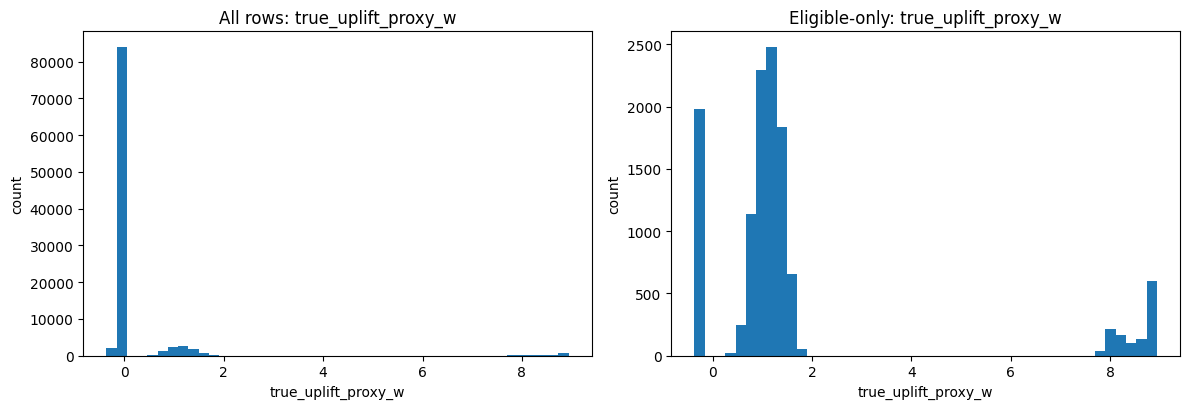

In [ ]:
# ============================================================
# Export HTML Memo: Insurance persona -> Platform Pricing / Price Protection
# Reads from current Gradio global state:
#   G["panel"], G["model"], G["seq"], G["params"]
# Produces a CEO/academic memo with:
#   - design narrative (insurance -> platform pricing)
#   - mechanics (eligible, PP, churn friction)
#   - results: distributions, decile calibration, policy curves (model vs oracle), AUUC, top-k KPIs
#   - tables: quick info, top-k profile, warehouse performance
# ============================================================

import os, io, base64, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Validate state exists
# -----------------------------
if "G" not in globals() or G.get("panel") is None:
    raise ValueError("No panel found. Please run the Gradio app and Generate Panel first (G['panel']).")

panel = G["panel"].copy()
params = G.get("params", {}) or {}

has_model = (G.get("model") is not None) and (G.get("seq") is not None)
model = None
scaler = None
seq_pack = None
if has_model:
    model, scaler = G["model"]
    seq_pack = G["seq"]  # (X, y, ybin, wh, tt, rid)

# -----------------------------
# 1) Helper: figure -> base64
# -----------------------------
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def df_to_html(d, floatfmt="{:.4f}", max_rows=30):
    d = d.copy()
    if len(d) > max_rows:
        d = d.head(max_rows).copy()
    for c in d.columns:
        if pd.api.types.is_numeric_dtype(d[c]):
            d[c] = d[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d.to_html(index=False, border=0, escape=False, classes="tbl")

# -----------------------------
# 2) Quick info & key cuts
# -----------------------------
n_rows = len(panel)
eligible_rows = int(panel["eligible_pp_t"].sum()) if "eligible_pp_t" in panel.columns else 0
eligible_rate = float(panel["eligible_pp_t"].mean()) if "eligible_pp_t" in panel.columns else np.nan
churn_rate = float(panel["churn_t"].mean()) if "churn_t" in panel.columns else np.nan
high_seg_share = float(panel["high_seg"].mean()) if "high_seg" in panel.columns else np.nan

quick = pd.DataFrame([{
    "rows": n_rows,
    "eligible_rows": eligible_rows,
    "eligible_rate": eligible_rate,
    "churn_rate": churn_rate,
    "high_seg_share": high_seg_share
}])

# -----------------------------
# 3) Plots: ALL vs ELIGIBLE-only uplift proxy distributions
# -----------------------------
need_cols = ["true_uplift_proxy_w", "eligible_pp_t"]
for c in need_cols:
    if c not in panel.columns:
        raise ValueError(f"Missing required column: {c}")

all_y = panel["true_uplift_proxy_w"].values
elig_y = panel.loc[panel["eligible_pp_t"]==1, "true_uplift_proxy_w"].values

fig_dist = plt.figure(figsize=(12,4.2))
ax1 = fig_dist.add_subplot(1,2,1)
ax1.hist(all_y, bins=45)
ax1.set_title("All rows: true_uplift_proxy_w (winsorized)")
ax1.set_xlabel("true_uplift_proxy_w"); ax1.set_ylabel("count")

ax2 = fig_dist.add_subplot(1,2,2)
ax2.hist(elig_y, bins=45) if len(elig_y) else None
ax2.set_title("Eligible-only: true_uplift_proxy_w")
ax2.set_xlabel("true_uplift_proxy_w"); ax2.set_ylabel("count")
plt.tight_layout()
b64_dist = fig_to_b64(fig_dist)

# -----------------------------
# 4) If model exists: compute eligible-only evaluation table + curves
# -----------------------------
kpi = None
wh_top = None
wh_stat = None
b64_cal = None
b64_policy = None
auuc_model = None
auuc_oracle = None
ratio = None
top_preview = None
profile_top = None

if has_model:
    X, y, ybin, wh, tt, rid = seq_pack
    mu, sd = scaler
    Xs = (X - mu)/sd
    score = model.predict(Xs, verbose=0).reshape(-1)

    seq_tbl = pd.DataFrame({"row_id": rid, "t": tt, "score": score})
    panel_key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    eval_df = seq_tbl.merge(panel_key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    if len(eval_df) < 80:
        # still export memo, but with warning
        eval_df = None

    if eval_df is not None:
        n = len(eval_df)
        overall_eligible_mean = float(eval_df["true_uplift_proxy_w"].mean())

        topk_frac = 0.10
        k = max(1, int(topk_frac*n))
        sel = eval_df.sort_values("score", ascending=False).head(k)

        mean_u = float(sel["true_uplift_proxy_w"].mean())
        win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
        p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
        roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
        high_share_top = float(sel["high_seg"].mean())

        # Warehouse mean uplift (top-k)
        wh_top = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index()\
                    .rename(columns={"true_uplift_proxy_w":"mean_true_uplift_topk"})\
                    .sort_values("mean_true_uplift_topk", ascending=False)

        # Warehouse overall eligible stats (risk/return)
        wh_stat = eval_df.groupby("Warehouse")["true_uplift_proxy_w"].agg(
            n="count",
            mean="mean",
            p10=lambda x: np.quantile(x, 0.10),
            win_rate=lambda x: np.mean(x>0)
        ).reset_index()

        # Decile calibration
        tmp = eval_df.copy()
        tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
        cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

        fig_cal = plt.figure(figsize=(6.2,4.0))
        plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
        plt.axhline(0, linewidth=1)
        plt.title("Decile calibration (eligible-only)")
        plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
        plt.tight_layout()
        b64_cal = fig_to_b64(fig_cal)

        # Policy curves: Model vs Oracle + AUUC
        fracs = np.linspace(0.01, 0.50, 50)
        y_true = eval_df["true_uplift_proxy_w"].values

        order_model = np.argsort(-eval_df["score"].values)
        vals_model = np.array([float(y_true[order_model[:max(1,int(f*n))]].mean()) for f in fracs])
        auuc_model = float(np.trapz(vals_model, fracs))

        order_oracle = np.argsort(-y_true)
        vals_oracle = np.array([float(y_true[order_oracle[:max(1,int(f*n))]].mean()) for f in fracs])
        auuc_oracle = float(np.trapz(vals_oracle, fracs))

        ratio = float(auuc_model / (auuc_oracle + 1e-9))

        fig_pol = plt.figure(figsize=(6.6,4.2))
        plt.plot(fracs, vals_oracle, label="Oracle (true uplift ranking)")
        plt.plot(fracs, vals_model, label="Model (LSTM score ranking)")
        plt.axhline(overall_eligible_mean, linewidth=1, label="Eligible mean baseline")
        plt.title("Policy value curves (eligible-only)")
        plt.xlabel("Top-k fraction (eligible events)")
        plt.ylabel("Mean true_uplift_proxy_w among selected")
        plt.legend()
        plt.tight_layout()
        b64_policy = fig_to_b64(fig_pol)

        # KPI table
        kpi = pd.DataFrame([{
            "eligible_events": n,
            "overall_eligible_mean": overall_eligible_mean,
            "topk_frac_reported": topk_frac,
            "topk_k": k,
            "mean_true_uplift_topk": mean_u,
            "win_rate_topk": win_rate,
            "p10_downside_topk": p10,
            "roi_proxy_topk": roi,
            "high_seg_share_in_topk": high_share_top,
            "AUUC_model": auuc_model,
            "AUUC_oracle": auuc_oracle,
            "AUUC_ratio_model_over_oracle": ratio
        }])

        # Top-k preview
        top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(30)

        # Explainable top-k profile
        profile_top = pd.DataFrame({
            "feature": [
                "share high_seg=1 (top-k)",
                "mean refund_t (top-k)",
                "mean true_uplift_proxy_w (top-k)"
            ],
            "value": [
                float(sel["high_seg"].mean()),
                float(sel["refund_t"].mean()),
                float(sel["true_uplift_proxy_w"].mean())
            ]
        })

# -----------------------------
# 5) Shopee / platform analogy diagram
# -----------------------------
fig_sh = plt.figure(figsize=(8.4,4.8))
ax = plt.gca()
ax.axis("off")
ax.set_title("Platform Pricing Analogy: Mass Eligibility → Profitable Tail via Targeting", pad=16)

boxes = [
    (0.05, 0.60, 0.27, 0.25, "Mass eligibility event\n(price drop after purchase)\neligible_pp_t"),
    (0.37, 0.60, 0.27, 0.25, "Intervention\nPrice Protection (PP)\npp_treat_t + refund_t"),
    (0.69, 0.60, 0.26, 0.25, "Outcome\nReduced friction → retention\nbenefit proxy / uplift")
]
for x,y,w,h,txt in boxes:
    ax.add_patch(plt.Rectangle((x,y), w,h, fill=False, linewidth=2))
    ax.text(x+w/2, y+h/2, txt, ha="center", va="center", fontsize=10)

ax.annotate("", xy=(0.37,0.72), xytext=(0.32,0.72), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.69,0.72), xytext=(0.64,0.72), arrowprops=dict(arrowstyle="->", lw=2))

ax.add_patch(plt.Rectangle((0.05,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.25,0.32, "Most eligible users:\nmodest benefit\n(not worth full subsidy)", ha="center", va="center", fontsize=10)

ax.add_patch(plt.Rectangle((0.55,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.75,0.32, "High-value tail:\nHigh basket × High elasticity\n→ large benefit\n(top-k targeting)", ha="center", va="center", fontsize=10)

ax.annotate("", xy=(0.52,0.32), xytext=(0.45,0.32), arrowprops=dict(arrowstyle="->", lw=2))
plt.tight_layout()
b64_shopee = fig_to_b64(fig_sh)

# -----------------------------
# 6) Build HTML content
# -----------------------------
ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def fmt_params(params):
    if not params:
        return "<i>No parameter snapshot found.</i>"
    rows = []
    for k,v in params.items():
        rows.append({"param": k, "value": v})
    return df_to_html(pd.DataFrame(rows), floatfmt="{:.6f}", max_rows=200)

params_html = fmt_params(params)
quick_html = df_to_html(quick, floatfmt="{:.6f}", max_rows=10)
kpi_html = df_to_html(kpi, floatfmt="{:.6f}", max_rows=10) if kpi is not None else "<i>Model results not available (train LSTM first).</i>"
wh_top_html = df_to_html(wh_top, floatfmt="{:.6f}", max_rows=20) if wh_top is not None else "<i>Not available.</i>"
wh_stat_html = df_to_html(wh_stat, floatfmt="{:.6f}", max_rows=20) if wh_stat is not None else "<i>Not available.</i>"
top_prev_html = df_to_html(top_preview, floatfmt="{:.6f}", max_rows=30) if top_preview is not None else "<i>Not available.</i>"
profile_html = df_to_html(profile_top, floatfmt="{:.6f}", max_rows=30) if profile_top is not None else "<i>Not available.</i>"

cal_img = f'<img src="data:image/png;base64,{b64_cal}"/>' if b64_cal else "<i>Not available.</i>"
pol_img = f'<img src="data:image/png;base64,{b64_policy}"/>' if b64_policy else "<i>Not available.</i>"

html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Insurance → Platform Pricing (Price Protection) Memo</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.6; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 28px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 14px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
  .pill {{ display:inline-block; padding:2px 8px; border-radius:999px; border:1px solid #ddd; font-size:12px; margin-right:6px; }}
</style>
</head>
<body>

<h1>Insurance Personas → Platform Pricing Sandbox (Price Protection) Memo</h1>
<div class="sub">
Generated: {ts} &nbsp; | &nbsp; Panel rows: <b>{n_rows:,}</b> &nbsp; | &nbsp; Focus: price protection as a targeted intervention under price friction.
</div>

<div class="card note">
<h2 style="margin-top:0;">Executive summary</h2>
<ul>
  <li><b>Claim:</b> “Price protection” is a platform pricing policy that reduces price-friction and prevents switching (churn).</li>
  <li><b>Insurance → platform mapping:</b> insurance covariates proxy stable human traits (risk/urgency, price sensitivity, tenure), which we reuse as platform personas.</li>
  <li><b>Decision context:</b> PP only matters in <b>eligible events</b> (price drop after purchase). Eligibility is broad, but value concentrates in a <b>high-value tail</b>.</li>
  <li><b>Strategy:</b> Like Shopee-style mass voucher regimes, profitability comes from allocating subsidy/PP budget to a <b>high basket × high elasticity</b> tail via top-k targeting.</li>
</ul>
</div>

<h2>1) Design rationale: “Insurance jump board” → platform pricing & protection</h2>
<div class="card">
<p>
Insurance data is rich in durable human attributes (risk exposure proxies, urgency signals, price-consciousness proxies, tenure).
We interpret these as platform personas: users differ in price sensitivity, perceived fairness, and switching propensity.
A price drop after purchase creates <b>price friction</b> (“I bought too expensive”), which can trigger churn (switching insurer/platform).
A <b>price protection</b> policy (refund/credit) is a targeted intervention to reduce friction and retain valuable users.
</p>
<p class="small">
In this sandbox, we do not claim real insurance pricing; we use insurance covariates as high-dimensional heterogeneity carriers
and test whether causal targeting can identify a high-benefit tail.
</p>
</div>

<h2>2) Mechanics & parameter snapshot</h2>
<div class="grid">
  <div class="card">
    <h3>Quick info</h3>
    {quick_html}
    <p class="small">
Eligible rows are the decision surface: PP allocation is evaluated only among eligible events.
</p>
  </div>
  <div class="card">
    <h3>Simulation settings</h3>
    {params_html}
  </div>
</div>

<h2>3) Evidence: eligibility sparsity and tail structure</h2>
<div class="card">
<img src="data:image/png;base64,{b64_dist}"/>
<p class="small">
Left: all panel rows (many near zero because PP is only relevant when eligible).
Right: eligible-only distribution (the decision distribution). A visible right tail supports a high-benefit segment.
</p>
</div>

<h2>4) Shopee / platform analogy (mass eligibility → profitable tail)</h2>
<div class="grid">
  <div class="card">
    <img src="data:image/png;base64,{b64_shopee}"/>
    <p class="small">
Broad eligibility is like mass voucher collection; the intervention budget should be concentrated on the high-benefit tail.
</p>
  </div>
  <div class="card">
    <p>
<b>Interpretation:</b> Platforms can offer broad mechanisms (vouchers, protection guarantees), but unit economics require targeting.
The policy problem is not “who is eligible?”, but “who produces incremental value because we intervene?” — an uplift problem.
When unit economics are favorable (high margin categories), the high-value tail becomes economically exploitable.
</p>
  </div>
</div>

<h2>5) Model evaluation (eligible-only)</h2>
<div class="grid">
  <div class="card">
    <h3>Decile calibration</h3>
    {cal_img}
    <p class="small">Higher predicted scores should correspond to higher mean benefit (monotone calibration).</p>
  </div>
  <div class="card">
    <h3>Policy value curves (Model vs Oracle) + AUUC</h3>
    {pol_img}
    <p class="small">
Oracle ranks by true uplift proxy (upper bound). Model should approach Oracle, especially at low top-k budgets.
</p>
  </div>
</div>

<div class="card">
<h3>Executive KPIs (eligible-only, top-k reported)</h3>
{kpi_html}
<p class="small">
Key reading:
<ul class="small">
  <li><b>AUUC_model</b> measures policy quality; <b>AUUC_oracle</b> is the theoretical upper bound.</li>
  <li><b>AUUC_ratio</b> summarizes how close the model is to the oracle.</li>
  <li><b>high_seg_share_in_topk</b> indicates whether targeting concentrates on the planted high-value tail.</li>
</ul>
</p>
</div>

<h2>6) Segment performance (warehouse view)</h2>
<div class="grid">
  <div class="card">
    <h3>Warehouse mean uplift (top-k)</h3>
    {wh_top_html}
  </div>
  <div class="card">
    <h3>Warehouse stats (eligible-only)</h3>
    {wh_stat_html}
  </div>
</div>

<h2>7) Top-k list (auditable)</h2>
<div class="card">
{profile_html}
<p class="small">Explainable summary of the selected top-k users (benefit, refund cost, high-seg composition).</p>
</div>

<div class="card">
<h3>Top-k preview</h3>
{top_prev_html}
<p class="small">This table is the actionable output: who to protect first under a budget constraint.</p>
</div>

<div class="card note">
<h2 style="margin-top:0;">Conclusion</h2>
<p>
This sandbox demonstrates a realistic platform pricing structure: PP decisions happen only on sparse eligible events, and value concentrates in a high-benefit tail.
A Shopee-like broad mechanism is compatible with profitability when the platform uses uplift-style targeting (top-k ranking) and respects unit economics.
</p>
</div>

<p class="small">End of memo.</p>
</body>
</html>
"""

out_path = "Insurance_to_Platform_Pricing_PP_Memo.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ HTML memo generated:", out_path)
files.download(out_path)

In [23]:
# ============================================================
# Export HTML Memo: Insurance persona -> Platform Pricing / Price Protection
# Reads from current Gradio global state:
#   G["panel"], G["model"], G["seq"], G["params"]
# Produces a CEO/academic memo with:
#   - design narrative (insurance -> platform pricing)
#   - mechanics (eligible, PP, churn friction)
#   - results: distributions, decile calibration, policy curves (model vs oracle), AUUC, top-k KPIs
#   - tables: quick info, top-k profile, warehouse performance
# ============================================================

import os, io, base64, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# 0) Validate state exists
# -----------------------------
if "G" not in globals() or G.get("panel") is None:
    raise ValueError("No panel found. Please run the Gradio app and Generate Panel first (G['panel']).")

panel = G["panel"].copy()
params = G.get("params", {}) or {}

has_model = (G.get("model") is not None) and (G.get("seq") is not None)
model = None
scaler = None
seq_pack = None
if has_model:
    model, scaler = G["model"]
    seq_pack = G["seq"]  # (X, y, ybin, wh, tt, rid)

# -----------------------------
# 1) Helper: figure -> base64
# -----------------------------
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def df_to_html(d, floatfmt="{:.4f}", max_rows=30):
    d = d.copy()
    if len(d) > max_rows:
        d = d.head(max_rows).copy()
    for c in d.columns:
        if pd.api.types.is_numeric_dtype(d[c]):
            d[c] = d[c].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")
    return d.to_html(index=False, border=0, escape=False, classes="tbl")

# -----------------------------
# 2) Quick info & key cuts
# -----------------------------
n_rows = len(panel)
eligible_rows = int(panel["eligible_pp_t"].sum()) if "eligible_pp_t" in panel.columns else 0
eligible_rate = float(panel["eligible_pp_t"].mean()) if "eligible_pp_t" in panel.columns else np.nan
churn_rate = float(panel["churn_t"].mean()) if "churn_t" in panel.columns else np.nan
high_seg_share = float(panel["high_seg"].mean()) if "high_seg" in panel.columns else np.nan

quick = pd.DataFrame([{
    "rows": n_rows,
    "eligible_rows": eligible_rows,
    "eligible_rate": eligible_rate,
    "churn_rate": churn_rate,
    "high_seg_share": high_seg_share
}])

# -----------------------------
# 3) Plots: ALL vs ELIGIBLE-only uplift proxy distributions
# -----------------------------
need_cols = ["true_uplift_proxy_w", "eligible_pp_t"]
for c in need_cols:
    if c not in panel.columns:
        raise ValueError(f"Missing required column: {c}")

all_y = panel["true_uplift_proxy_w"].values
elig_y = panel.loc[panel["eligible_pp_t"]==1, "true_uplift_proxy_w"].values

fig_dist = plt.figure(figsize=(12,4.2))
ax1 = fig_dist.add_subplot(1,2,1)
ax1.hist(all_y, bins=45)
ax1.set_title("All rows: true_uplift_proxy_w (winsorized)")
ax1.set_xlabel("true_uplift_proxy_w"); ax1.set_ylabel("count")

ax2 = fig_dist.add_subplot(1,2,2)
ax2.hist(elig_y, bins=45) if len(elig_y) else None
ax2.set_title("Eligible-only: true_uplift_proxy_w")
ax2.set_xlabel("true_uplift_proxy_w"); ax2.set_ylabel("count")
plt.tight_layout()
b64_dist = fig_to_b64(fig_dist)

# -----------------------------
# 4) If model exists: compute eligible-only evaluation table + curves
# -----------------------------
kpi = None
wh_top = None
wh_stat = None
b64_cal = None
b64_policy = None
auuc_model = None
auuc_oracle = None
ratio = None
top_preview = None
profile_top = None

if has_model:
    X, y, ybin, wh, tt, rid = seq_pack
    mu, sd = scaler
    Xs = (X - mu)/sd
    score = model.predict(Xs, verbose=0).reshape(-1)

    seq_tbl = pd.DataFrame({"row_id": rid, "t": tt, "score": score})
    panel_key = panel[["row_id","t","Warehouse","eligible_pp_t","refund_t","true_uplift_proxy_w","high_seg"]].copy()
    eval_df = seq_tbl.merge(panel_key, on=["row_id","t"], how="left")
    eval_df = eval_df[eval_df["eligible_pp_t"]==1].dropna(subset=["true_uplift_proxy_w"]).reset_index(drop=True)

    if len(eval_df) < 80:
        # still export memo, but with warning
        eval_df = None

    if eval_df is not None:
        n = len(eval_df)
        overall_eligible_mean = float(eval_df["true_uplift_proxy_w"].mean())

        topk_frac = 0.10
        k = max(1, int(topk_frac*n))
        sel = eval_df.sort_values("score", ascending=False).head(k)

        mean_u = float(sel["true_uplift_proxy_w"].mean())
        win_rate = float((sel["true_uplift_proxy_w"] > 0).mean())
        p10 = float(np.quantile(sel["true_uplift_proxy_w"], 0.10))
        roi = float(sel["true_uplift_proxy_w"].sum() / (sel["refund_t"].sum() + 1e-9))
        high_share_top = float(sel["high_seg"].mean())

        # Warehouse mean uplift (top-k)
        wh_top = sel.groupby("Warehouse")["true_uplift_proxy_w"].mean().reset_index()\
                    .rename(columns={"true_uplift_proxy_w":"mean_true_uplift_topk"})\
                    .sort_values("mean_true_uplift_topk", ascending=False)

        # Warehouse overall eligible stats (risk/return)
        wh_stat = eval_df.groupby("Warehouse")["true_uplift_proxy_w"].agg(
            n="count",
            mean="mean",
            p10=lambda x: np.quantile(x, 0.10),
            win_rate=lambda x: np.mean(x>0)
        ).reset_index()

        # Decile calibration
        tmp = eval_df.copy()
        tmp["decile"] = pd.qcut(tmp["score"], q=10, labels=False, duplicates="drop")
        cal = tmp.groupby("decile")["true_uplift_proxy_w"].mean().reset_index()

        fig_cal = plt.figure(figsize=(6.2,4.0))
        plt.plot(cal["decile"], cal["true_uplift_proxy_w"], marker="o")
        plt.axhline(0, linewidth=1)
        plt.title("Decile calibration (eligible-only)")
        plt.xlabel("Decile (higher predicted benefit)"); plt.ylabel("Mean true_uplift_proxy_w")
        plt.tight_layout()
        b64_cal = fig_to_b64(fig_cal)

        # Policy curves: Model vs Oracle + AUUC
        fracs = np.linspace(0.01, 0.50, 50)
        y_true = eval_df["true_uplift_proxy_w"].values

        order_model = np.argsort(-eval_df["score"].values)
        vals_model = np.array([float(y_true[order_model[:max(1,int(f*n))]].mean()) for f in fracs])
        auuc_model = float(np.trapz(vals_model, fracs))

        order_oracle = np.argsort(-y_true)
        vals_oracle = np.array([float(y_true[order_oracle[:max(1,int(f*n))]].mean()) for f in fracs])
        auuc_oracle = float(np.trapz(vals_oracle, fracs))

        ratio = float(auuc_model / (auuc_oracle + 1e-9))

        fig_pol = plt.figure(figsize=(6.6,4.2))
        plt.plot(fracs, vals_oracle, label="Oracle (true uplift ranking)")
        plt.plot(fracs, vals_model, label="Model (LSTM score ranking)")
        plt.axhline(overall_eligible_mean, linewidth=1, label="Eligible mean baseline")
        plt.title("Policy value curves (eligible-only)")
        plt.xlabel("Top-k fraction (eligible events)")
        plt.ylabel("Mean true_uplift_proxy_w among selected")
        plt.legend()
        plt.tight_layout()
        b64_policy = fig_to_b64(fig_pol)

        # KPI table
        kpi = pd.DataFrame([{
            "eligible_events": n,
            "overall_eligible_mean": overall_eligible_mean,
            "topk_frac_reported": topk_frac,
            "topk_k": k,
            "mean_true_uplift_topk": mean_u,
            "win_rate_topk": win_rate,
            "p10_downside_topk": p10,
            "roi_proxy_topk": roi,
            "high_seg_share_in_topk": high_share_top,
            "AUUC_model": auuc_model,
            "AUUC_oracle": auuc_oracle,
            "AUUC_ratio_model_over_oracle": ratio
        }])

        # Top-k preview
        top_preview = sel[["row_id","t","Warehouse","score","true_uplift_proxy_w","refund_t","high_seg"]].head(30)

        # Explainable top-k profile
        profile_top = pd.DataFrame({
            "feature": [
                "share high_seg=1 (top-k)",
                "mean refund_t (top-k)",
                "mean true_uplift_proxy_w (top-k)"
            ],
            "value": [
                float(sel["high_seg"].mean()),
                float(sel["refund_t"].mean()),
                float(sel["true_uplift_proxy_w"].mean())
            ]
        })

# -----------------------------
# 5) Shopee / platform analogy diagram
# -----------------------------
fig_sh = plt.figure(figsize=(8.4,4.8))
ax = plt.gca()
ax.axis("off")
ax.set_title("Platform Pricing Analogy: Mass Eligibility → Profitable Tail via Targeting", pad=16)

boxes = [
    (0.05, 0.60, 0.27, 0.25, "Mass eligibility event\n(price drop after purchase)\neligible_pp_t"),
    (0.37, 0.60, 0.27, 0.25, "Intervention\nPrice Protection (PP)\npp_treat_t + refund_t"),
    (0.69, 0.60, 0.26, 0.25, "Outcome\nReduced friction → retention\nbenefit proxy / uplift")
]
for x,y,w,h,txt in boxes:
    ax.add_patch(plt.Rectangle((x,y), w,h, fill=False, linewidth=2))
    ax.text(x+w/2, y+h/2, txt, ha="center", va="center", fontsize=10)

ax.annotate("", xy=(0.37,0.72), xytext=(0.32,0.72), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.69,0.72), xytext=(0.64,0.72), arrowprops=dict(arrowstyle="->", lw=2))

ax.add_patch(plt.Rectangle((0.05,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.25,0.32, "Most eligible users:\nmodest benefit\n(not worth full subsidy)", ha="center", va="center", fontsize=10)

ax.add_patch(plt.Rectangle((0.55,0.18), 0.40, 0.28, fill=False, linewidth=2))
ax.text(0.75,0.32, "High-value tail:\nHigh basket × High elasticity\n→ large benefit\n(top-k targeting)", ha="center", va="center", fontsize=10)

ax.annotate("", xy=(0.52,0.32), xytext=(0.45,0.32), arrowprops=dict(arrowstyle="->", lw=2))
plt.tight_layout()
b64_shopee = fig_to_b64(fig_sh)

# -----------------------------
# 6) Build HTML content
# -----------------------------
ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def fmt_params(params):
    if not params:
        return "<i>No parameter snapshot found.</i>"
    rows = []
    for k,v in params.items():
        rows.append({"param": k, "value": v})
    return df_to_html(pd.DataFrame(rows), floatfmt="{:.6f}", max_rows=200)

params_html = fmt_params(params)
quick_html = df_to_html(quick, floatfmt="{:.6f}", max_rows=10)
kpi_html = df_to_html(kpi, floatfmt="{:.6f}", max_rows=10) if kpi is not None else "<i>Model results not available (train LSTM first).</i>"
wh_top_html = df_to_html(wh_top, floatfmt="{:.6f}", max_rows=20) if wh_top is not None else "<i>Not available.</i>"
wh_stat_html = df_to_html(wh_stat, floatfmt="{:.6f}", max_rows=20) if wh_stat is not None else "<i>Not available.</i>"
top_prev_html = df_to_html(top_preview, floatfmt="{:.6f}", max_rows=30) if top_preview is not None else "<i>Not available.</i>"
profile_html = df_to_html(profile_top, floatfmt="{:.6f}", max_rows=30) if profile_top is not None else "<i>Not available.</i>"

cal_img = f'<img src="data:image/png;base64,{b64_cal}"/>' if b64_cal else "<i>Not available.</i>"
pol_img = f'<img src="data:image/png;base64,{b64_policy}"/>' if b64_policy else "<i>Not available.</i>"

html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Insurance → Platform Pricing (Price Protection) Memo</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 28px; color:#111; line-height: 1.6; }}
  h1 {{ margin: 0 0 6px 0; }}
  h2 {{ margin-top: 28px; }}
  h3 {{ margin-top: 16px; }}
  .sub {{ color:#444; margin-bottom: 14px; }}
  .grid {{ display:grid; grid-template-columns: 1fr 1fr; gap: 14px; align-items:start; }}
  .card {{ border:1px solid #e6e6e6; border-radius: 12px; padding: 14px; background:#fff; }}
  .note {{ background:#f7f9ff; border:1px solid #e2e8ff; }}
  img {{ max-width:100%; border-radius:10px; border:1px solid #eee; }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size: 13px; }}
  .tbl th, .tbl td {{ border-bottom:1px solid #eee; padding:6px 8px; text-align:left; }}
  code {{ background:#f6f6f6; padding:2px 6px; border-radius:6px; }}
  .small {{ font-size:12px; color:#666; }}
  .pill {{ display:inline-block; padding:2px 8px; border-radius:999px; border:1px solid #ddd; font-size:12px; margin-right:6px; }}
</style>
</head>
<body>

<h1>Insurance Personas → Platform Pricing Sandbox (Price Protection) Memo</h1>
<div class="sub">
Generated: {ts} &nbsp; | &nbsp; Panel rows: <b>{n_rows:,}</b> &nbsp; | &nbsp; Focus: price protection as a targeted intervention under price friction.
</div>

<div class="card note">
<h2 style="margin-top:0;">Executive summary</h2>
<ul>
  <li><b>Claim:</b> “Price protection” is a platform pricing policy that reduces price-friction and prevents switching (churn).</li>
  <li><b>Insurance → platform mapping:</b> insurance covariates proxy stable human traits (risk/urgency, price sensitivity, tenure), which we reuse as platform personas.</li>
  <li><b>Decision context:</b> PP only matters in <b>eligible events</b> (price drop after purchase). Eligibility is broad, but value concentrates in a <b>high-value tail</b>.</li>
  <li><b>Strategy:</b> Like Shopee-style mass voucher regimes, profitability comes from allocating subsidy/PP budget to a <b>high basket × high elasticity</b> tail via top-k targeting.</li>
</ul>
</div>

<h2>1) Design rationale: “Insurance jump board” → platform pricing & protection</h2>
<div class="card">
<p>
Insurance data is rich in durable human attributes (risk exposure proxies, urgency signals, price-consciousness proxies, tenure).
We interpret these as platform personas: users differ in price sensitivity, perceived fairness, and switching propensity.
A price drop after purchase creates <b>price friction</b> (“I bought too expensive”), which can trigger churn (switching insurer/platform).
A <b>price protection</b> policy (refund/credit) is a targeted intervention to reduce friction and retain valuable users.
</p>
<p class="small">
In this sandbox, we do not claim real insurance pricing; we use insurance covariates as high-dimensional heterogeneity carriers
and test whether causal targeting can identify a high-benefit tail.
</p>
</div>

<h2>2) Mechanics & parameter snapshot</h2>
<div class="grid">
  <div class="card">
    <h3>Quick info</h3>
    {quick_html}
    <p class="small">
Eligible rows are the decision surface: PP allocation is evaluated only among eligible events.
</p>
  </div>
  <div class="card">
    <h3>Simulation settings</h3>
    {params_html}
  </div>
</div>

<h2>3) Evidence: eligibility sparsity and tail structure</h2>
<div class="card">
<img src="data:image/png;base64,{b64_dist}"/>
<p class="small">
Left: all panel rows (many near zero because PP is only relevant when eligible).
Right: eligible-only distribution (the decision distribution). A visible right tail supports a high-benefit segment.
</p>
</div>

<h2>4) Shopee / platform analogy (mass eligibility → profitable tail)</h2>
<div class="grid">
  <div class="card">
    <img src="data:image/png;base64,{b64_shopee}"/>
    <p class="small">
Broad eligibility is like mass voucher collection; the intervention budget should be concentrated on the high-benefit tail.
</p>
  </div>
  <div class="card">
    <p>
<b>Interpretation:</b> Platforms can offer broad mechanisms (vouchers, protection guarantees), but unit economics require targeting.
The policy problem is not “who is eligible?”, but “who produces incremental value because we intervene?” — an uplift problem.
When unit economics are favorable (high margin categories), the high-value tail becomes economically exploitable.
</p>
  </div>
</div>

<h2>5) Model evaluation (eligible-only)</h2>
<div class="grid">
  <div class="card">
    <h3>Decile calibration</h3>
    {cal_img}
    <p class="small">Higher predicted scores should correspond to higher mean benefit (monotone calibration).</p>
  </div>
  <div class="card">
    <h3>Policy value curves (Model vs Oracle) + AUUC</h3>
    {pol_img}
    <p class="small">
Oracle ranks by true uplift proxy (upper bound). Model should approach Oracle, especially at low top-k budgets.
</p>
  </div>
</div>

<div class="card">
<h3>Executive KPIs (eligible-only, top-k reported)</h3>
{kpi_html}
<p class="small">
Key reading:
<ul class="small">
  <li><b>AUUC_model</b> measures policy quality; <b>AUUC_oracle</b> is the theoretical upper bound.</li>
  <li><b>AUUC_ratio</b> summarizes how close the model is to the oracle.</li>
  <li><b>high_seg_share_in_topk</b> indicates whether targeting concentrates on the planted high-value tail.</li>
</ul>
</p>
</div>

<h2>6) Segment performance (warehouse view)</h2>
<div class="grid">
  <div class="card">
    <h3>Warehouse mean uplift (top-k)</h3>
    {wh_top_html}
  </div>
  <div class="card">
    <h3>Warehouse stats (eligible-only)</h3>
    {wh_stat_html}
  </div>
</div>

<h2>7) Top-k list (auditable)</h2>
<div class="card">
{profile_html}
<p class="small">Explainable summary of the selected top-k users (benefit, refund cost, high-seg composition).</p>
</div>

<div class="card">
<h3>Top-k preview</h3>
{top_prev_html}
<p class="small">This table is the actionable output: who to protect first under a budget constraint.</p>
</div>

<div class="card note">
<h2 style="margin-top:0;">Conclusion</h2>
<p>
This sandbox demonstrates a realistic platform pricing structure: PP decisions happen only on sparse eligible events, and value concentrates in a high-benefit tail.
A Shopee-like broad mechanism is compatible with profitability when the platform uses uplift-style targeting (top-k ranking) and respects unit economics.
</p>
</div>

<p class="small">End of memo.</p>
</body>
</html>
"""

out_path = "Insurance_to_Platform_Pricing_PP_Memo.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ HTML memo generated:", out_path)
files.download(out_path)

✅ HTML memo generated: Insurance_to_Platform_Pricing_PP_Memo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>